# proxytool_REDUX_4

This notebook is the REDUX_4 canonical runbook of `proxytool_REDUX.ipynb`, focused on **single-path calibrated metadata discrimination** with one authoritative execution flow.

Defaults now favor strict discrimination: `metadata_scoring_mode="family_cosine"`, `metadata_windows=[50, 150]`, recency-biased `window_weights={50:0.65,150:0.35}`, tunable `coverage_penalty_lambda`, and use-case-specific reporting (`contrastive` for benchmarking, `rank_pct` for retrieval stability).

Domain-aware hard-negative pools and convex weight blending (`strict/mimic/1`) are available to improve dissimilar suppression without collapsing known-similar recall.

**REDUX_3 status:** optimization phase. Core architecture is stable; remaining gains come from calibration knobs and negative curriculum quality.


## REDUX_4 — canonical scoring execution order

1. **Weights/config/metrics** — run the `CAIS_WEIGHTS` + `REDUX3_*` config cell.
2. **Core similarity helpers** — run the `MinMaxNormalizer` cell (~31), then the cell that adds `ZScoreNormalizer` + global normalizer helpers (~36); the second replaces `MinMaxNormalizer` in-process.
3. **One patch block only** — run the patch cell titled *Reliability + Discrimination Patch Overrides*. It defines tuned metadata internals and strict benchmark runner.
4. **Tables** — run `build_argument_table` / `build_custom_30_table` / strict helpers after step 3.

**Order invariant:** do not execute application cells before definitions; run only the final REDUX_4 canonical execution block for authoritative outputs.

**Weight profiles:** one of `CAIS_WEIGHTS`, `CAIS_WEIGHTS_STRICT`, `CAIS_WEIGHTS_MIMIC`, `CAIS_WEIGHTS_1`, or a REDUX_3 convex blend string.

**Metadata modes:** `weighted_cosine` = direct weighted vector similarity; `family_cosine` = family-level similarity + coverage penalty + reporting calibration.


# Metadata-Driven Software Similarity for Proxy System Discovery

Implementation of **Kennedy, DeFranco & Laplante**, *"Discovering Proxy Systems to Test Critical AI Systems: A Metadata-Driven Software Similarity Approach"* (IEEE Computer, 2026). This notebook finds **"software twins"** — noncritical proxy systems that mirror critical AI systems (CAIS) and can be safely used for testing when proprietary source code cannot be accessed.

## Overview

No source code is ever accessed—only Git metadata (author, date, message, file stats). The paper uses four classes of indicators as *behavioral fingerprints*: **commit messages** (semantic embedding + intent), **contributor behavior** (graph-based), **file change histories** (co-change, churn), and **temporal evolution** (development rhythm, time series).

## Key Design Goals (from paper)

- Find proxy systems for CAIS when code is off limits
- Use NIST 5D taxonomy to characterize and match systems
- Combine the four indicator families into a tunable composite similarity score
- Feed into **Similarity → Taxonomy validation → Proxy selection** loop (Figure 3)

## Features

- **Six-step process** (paper Figure 2): Anchor CAIS → Search candidates → Extract features → Normalize & weight → Similarity score → Rank & review
- **Four indicator families**: commit semantics (embedding + lexicon), contributors, co-change, temporal rhythm
- GitHub API + `git log --numstat`; progress bars, caching; explainable feature contributions
- Local and remote repos supported (no cloning)

## Dependencies

Install the required packages:

```bash
pip install requests tqdm
pip install --upgrade tqdm
```

Optional dependencies (paper-aligned and visualization):

```bash
# Commit message semantic embedding (paper: "embed in a semantic space")
pip install sentence-transformers

# Sentiment analysis backend
pip install vaderSentiment

# Plots and explainability
pip install matplotlib ipython
```

## Usage Example

```bash
python proxytool.py compare --query https://github.com/microsoft/vscode \
  --candidates https://github.com/facebook/react \
  --github-token $env:GH_TOKEN \
  --metrics sentiment,churn,attach,cadence \
  --max-commits 100 \
  --plot results.png --plot-details
```

## Paper's Four Indicator Families (What We Measure)

Our approach focuses on four classes of Git-based indicators: commit messages, contributor behavior, file change histories, and temporal evolution. Together, these signals act like behavioral fingerprints.

| Family | Paper description | Notebook implementation | Features |
|--------|-------------------|-------------------------|----------|
| **1. Commit messages** | NLP to embed in semantic space; measure similarity | `CommitSemanticMetric` (lexicon) + `CommitEmbeddingMetric` (sentence-transformers) + `SentimentMetric` | `sem_*`, `emb_*`, `sent_*` |
| **2. Contributor behavior** | Graph-based features; collaboration patterns | `ContributorMetric` (author count, top shares, bus factor, entropy) | `contrib_*` |
| **3. File change histories** | Co-change and churn for the file graph | `CochangeMetric` (edge density, degrees) + `ChurnMetric` (files, lines) | `cochg_*`, `churn_*` |
| **4. Temporal evolution** | Time series: commit frequency, burstiness, release patterns | `TemporalRhythmMetric` + `CadenceMetric` | `temp_*`, `commit_*` |

**Additional**: issue attachment (`attach`), GitLogger (`gitlogger`), NIST 5D taxonomy (`env_`, `purpose_`, `op_`, `algo_`, `lang_`).


## Paper Alignment: Six-Step Process & Safety Loop

**(similarity scoring):**
- **Step 1** Anchor CAIS → `load_cais_profile`, CAIS JSON (O1–O5, environment, purpose)
- **Step 2** Search candidates → `discover_candidates` (GitHub topic/keyword search) or static `CAIS_DOMAIN_CONFIGS`
- **Step 3** Extract features → `compute_features_for_repo` (semantic embedding, contributor, co-change, temporal + taxonomy)
- **Step 4** Normalize & weight → `MinMaxNormalizer`, `weighted_sum` with `CAIS_WEIGHTS` / `WEIGHT_GRID`
- **Step 5** Similarity score → cosine similarity on weighted vectors
- **Step 6** Rank & review → `cmd_compare`, `rank_and_validate_proxies`

**(Similarity-to-Proxy Safety Loop):**  
`rank_and_validate_proxies` → taxonomy alignment report → validate against CAIS taxonomy → select safe proxies.

**Paper "Looking Ahead":** Calibration via `expected_high_similarity` + `tune_weights`; explainable metrics via `plot_feature_contribs`.

## Imports and Configuration

In [1]:
# test
import requests, tqdm, sentence_transformers, vaderSentiment, matplotlib, scipy, numpy, pandas, sklearn, psutil
print("All imports successful!")

C:\Users\bduser\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


All imports successful!


In [2]:
# Control flags to skip long-running/archival cells
RUN_SLOW_TESTS = True  # set to True to run slow/archival suites
SKIP_MSG = "Skipped slow cell: set RUN_SLOW_TESTS=True to run"


In [3]:
%matplotlib inline
from __future__ import annotations

import argparse
import json
import math
import re
import statistics as stats
import subprocess
import time
from dataclasses import dataclass, field
from datetime import datetime
from pathlib import Path
from typing import Any, Dict, Iterator, List, Optional, Tuple

import requests
from tqdm import tqdm  # pip install --upgrade tqdm

# Logging switches (set by CLI)
VERBOSE = False
QUIET = False


def _log(msg: str, level: str = "info"):
    """Minimal logger with quiet/verbose control."""
    if level == "debug" and not VERBOSE:
        return
    if QUIET and level in ("info", "debug"):
        return
    print(msg)


In [4]:
# Ensure sentence-transformers is available (for deep_code_similarity and commit embeddings)
try:
    import sentence_transformers  # noqa: F401
    _st_ready = True
except ImportError:
    _st_ready = False
if not _st_ready:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", "sentence-transformers"])
    import sentence_transformers  # noqa: F401
    _st_ready = True
if _st_ready:
    print("sentence-transformers ready (deep_code_similarity and commit embeddings will use it).")

sentence-transformers ready (deep_code_similarity and commit embeddings will use it).


In [5]:
import os
from pathlib import Path

# Single place for GitHub token (used everywhere else in the notebook).
# Reads from (in order): environment variable, .env file, or token.txt.
# NEVER hardcode a token in this notebook.
github_token = os.environ.get("GITHUB_TOKEN")

if not github_token:
    _env_file = Path(".env")
    if _env_file.exists():
        for line in _env_file.read_text().splitlines():
            line = line.strip()
            if line.startswith("GITHUB_TOKEN=") and not line.startswith("#"):
                github_token = line.split("=", 1)[1].strip()
                break

if not github_token:
    _token_file = Path("token.txt")
    if _token_file.exists():
        github_token = _token_file.read_text().strip()

if not github_token or github_token.startswith("<REDACTED"):
    raise RuntimeError(
        "GitHub token not found. Provide it in ONE of these ways:\n"
        "  1. Put GITHUB_TOKEN=ghp_... in a .env file in this folder.\n"
        "  2. Create a token.txt file with just the token.\n"
        "  3. Or set the GITHUB_TOKEN env var before starting Jupyter."
    )

print(f"GitHub token loaded ({github_token[:4]}...{github_token[-4:]})")


GitHub token loaded (gith...8D8H)


### GitHub PAT requirements

The notebook needs a **GitHub Personal Access Token** for the GitHub REST API (commit history, search).

| Method | Details |
|--------|---------|
| `.env` file | `GITHUB_TOKEN=ghp_...` (no quotes) in a `.env` next to the notebook |
| `token.txt` | Plain text file containing only the token |
| Environment variable | `export GITHUB_TOKEN=ghp_...` before starting Jupyter |

**Fine-grained PAT scopes** (recommended for the `dev4-gpt` account):
- **Repository access**: *All repositories* (or at least *Public repositories*)
- **Permissions**: *Contents — Read-only* and *Metadata — Read-only*

If you see persistent **401 Unauthorized** errors, the token has likely expired or been revoked.
Generate a new one at https://github.com/settings/personal-access-tokens/new and update `.env`.

In [6]:
def check_github_token(token: str | None = None) -> bool:
    """Quick health-check: hit /rate_limit and report whether the token is accepted."""
    token = token or github_token
    headers = {"Accept": "application/vnd.github.v3+json", "User-Agent": "proxytool/0.1"}
    if token:
        headers["Authorization"] = f"token {token}"
    try:
        r = requests.get("https://api.github.com/rate_limit", headers=headers, timeout=10)
        if r.status_code == 401:
            print(f"Token REJECTED (401). Generate a new PAT and update .env.")
            return False
        data = r.json().get("rate", {})
        print(
            f"Token OK — core API: {data.get('remaining', '?')}/{data.get('limit', '?')} "
            f"requests remaining (resets {data.get('reset', '?')})"
        )
        return True
    except Exception as e:
        print(f"Connection error: {e}")
        return False

check_github_token()

Token OK — core API: 4990/5000 requests remaining (resets 1778715851)


True

## Caching System

The caching system stores fetched commit data locally to avoid redundant API calls.

In [7]:
CACHE_DIR = Path(".proxytool_cache")
CACHE_DIR.mkdir(exist_ok=True)


def cache_key(owner: str, repo: str, since: Optional[str], until: Optional[str]) -> str:
    return f"{owner}_{repo}_{since or 'none'}_{until or 'none'}.json"


def load_cached_commits(owner: str, repo: str, since: Optional[str], until: Optional[str]) -> Optional[List[dict]]:
    path = CACHE_DIR / cache_key(owner, repo, since, until)
    if path.exists():
        try:
            with open(path, "r", encoding="utf-8") as f:
                data = json.load(f)
                _log(f"  [Cache hit] Loaded {len(data)} commits", "debug")
                return data
        except Exception as e:
            _log(f"  [Cache error] {e}", "debug")
    return None


def save_cached_commits(owner: str, repo: str, since: Optional[str], until: Optional[str], commits: List[dict]):
    path = CACHE_DIR / cache_key(owner, repo, since, until)
    try:
        with open(path, "w", encoding="utf-8") as f:
            json.dump(commits, f, indent=None)
        _log(f"  [Cache saved] {len(commits)} commits", "debug")
    except Exception as e:
        _log(f"  [Cache save failed] {e}", "debug")

## Data Model

CommitRecord dataclass to store commit metadata.

In [8]:
@dataclass
class CommitRecord:
    repo_id: str
    author: str
    email: str
    date: datetime
    message: str
    files_changed: int
    insertions: int
    deletions: int
    touched_files: List[str] = field(default_factory=list)

    @property
    def lines_changed(self) -> int:
        return (self.insertions or 0) + (self.deletions or 0)

In [9]:
# Core metric sets used across the notebook
# BASE_METRICS: original 5 families
BASE_METRICS = "sentiment,churn,attach,cadence,gitlogger"

# CAIS_METRICS: full metric set used for CAIS-aware similarity
CAIS_METRICS = (
    "sentiment,churn,attach,cadence,gitlogger,"  # base
    "environment,purpose,operational,algorithm,language,"  # NIST 5D taxonomy dimensions
    "commitsem,contributors,cochange,temporal,embedding,"  # paper-driven metadata fingerprints
    "release_cadence,branching,issue_metrics,doc_quality,ci_signals"  # proxy / maturity signals
)


## Local Git Repository Handler

Functions to extract commit metadata from local Git repositories using `git log --numstat`.

In [10]:
def run_git_log(
    repo: str,
    since: Optional[str] = None,
    until: Optional[str] = None,
    max_commits: Optional[int] = None,
) -> List[CommitRecord]:
    repo_path = Path(repo)
    if not repo_path.exists():
        raise FileNotFoundError(f"Local repo not found: {repo}")

    fmt = "@@@%H\x1f%an\x1f%ae\x1f%ad\x1f%s"
    args = [
        "git", "-C", str(repo_path), "log", "--no-merges",
        f"--pretty=format:{fmt}", "--date=iso-strict", "--numstat"
    ]
    if since:
        args.append(f"--since={since}")
    if until:
        args.append(f"--until={until}")
    if max_commits:
        args.append(f"-n{int(max_commits)}")

    try:
        out = subprocess.check_output(args, stderr=subprocess.STDOUT, text=True, encoding="utf-8", errors="replace")
    except subprocess.CalledProcessError as e:
        raise RuntimeError(f"git log failed: {e.output}")

    recs: List[CommitRecord] = []
    current: Optional[Dict] = None

    def flush():
        nonlocal current, recs
        if not current:
            return
        dt = datetime.fromisoformat(current["date"])
        recs.append(CommitRecord(
            repo_id=str(repo_path.resolve()),
            author=current.get("author", "unknown"),
            email=current.get("email", "unknown"),
            date=dt,
            message=current.get("message", ""),
            files_changed=int(current.get("files_changed", 0)),
            insertions=int(current.get("insertions", 0)),
            deletions=int(current.get("deletions", 0)),
            touched_files=current.get("touched_files", []),
        ))
        current = None

    for line in out.splitlines():
        if line.startswith("@@@"):
            flush()
            parts = line[3:].split("\x1f")
            if len(parts) < 5:
                continue
            current = {
                "files_changed": 0, "insertions": 0, "deletions": 0,
                "author": parts[1].strip(), "email": parts[2].strip(),
                "date": parts[3].strip(), "message": parts[4].strip(),
                "touched_files": [],
            }
        elif line.strip() and current is not None:
            ins, dels, path = line.split("\t")[:3]
            current["files_changed"] += 1
            current["insertions"] += int(ins) if ins.isdigit() else 0  # '-' for binaries
            current["deletions"] += int(dels) if dels.isdigit() else 0
            current["touched_files"].append(path)
    flush()
    return recs

## GitHub API Handler

Functions to fetch commit metadata from GitHub repositories via REST API with rate limiting and progress tracking.

In [11]:
GITHUB_API = "https://api.github.com"
MAX_RETRIES_5XX = 4
BASE_DELAY_5XX = 2.0


def _github_request_with_progress(
    url: str,
    token: Optional[str],
    params: Optional[dict],
    paginate: bool,
    pbar: Optional[tqdm] = None,
) -> Iterator[dict]:
    """Robust request with rate limit + progress (pbar may be None)."""
    headers = {
        "Accept": "application/vnd.github.v3+json",
        "User-Agent": "proxytool/0.1 (+metadata-only-similarity)",
    }
    if token:
        headers["Authorization"] = f"token {token}"

    while url:
        resp = None
        for attempt in range(MAX_RETRIES_5XX):
            try:
                resp = requests.get(url, headers=headers, params=params or {}, timeout=30)
                resp.raise_for_status()
                break
            except requests.exceptions.Timeout:
                raise RuntimeError("Request timeout after 30s")
            except requests.HTTPError as e:
                r = getattr(e, "response", None) or resp
                if r is not None and 500 <= r.status_code < 600:
                    if attempt < MAX_RETRIES_5XX - 1:
                        delay = BASE_DELAY_5XX * (2 ** attempt)
                        _log(f"  GitHub {r.status_code}, retrying in {delay:.0f}s (attempt {attempt+1}/{MAX_RETRIES_5XX})...", "info")
                        time.sleep(delay)
                        continue
                if r is not None and r.status_code == 403:
                    msg = ""
                    if "application/json" in r.headers.get("Content-Type", ""):
                        try:
                            msg = r.json().get("message", "")
                        except Exception:
                            msg = ""
                    if "rate limit" in (msg or "").lower():
                        reset = int(r.headers.get("X-RateLimit-Reset", 0))
                        sleep = max(reset - time.time(), 0) + 5
                        reset_time = datetime.fromtimestamp(reset).strftime("%H:%M:%S")
                        _log(f"  Rate limit exceeded. Sleeping {sleep:.0f}s until {reset_time}...", "info")
                        time.sleep(sleep)
                        continue
                    raise RuntimeError(f"GitHub 403: {msg}")
                raise

        remaining = int(resp.headers.get("X-RateLimit-Remaining", 0) or 0)
        limit = int(resp.headers.get("X-RateLimit-Limit", 5000) or 5000)
        if remaining < 100:
            _log(f"  Rate limit: {remaining}/{limit} remaining", "debug")

        data = resp.json()
        if isinstance(data, list):
            for item in data:
                yield item
                if pbar is not None:
                    pbar.update(1)
        else:
            yield data
            if pbar is not None:
                pbar.update(1)

        if not paginate:
            break

        link = resp.headers.get("Link", "")
        url = None
        for part in link.split(","):
            if 'rel="next"' in part:
                url = part[part.find("<") + 1: part.find(">")]
                break
        time.sleep(0.2)

In [12]:
def run_github_log(
    owner: str,
    repo: str,
    token: Optional[str] = None,
    since: Optional[str] = None,
    until: Optional[str] = None,
    max_commits: Optional[int] = None,
) -> List[CommitRecord]:
    repo_slug = f"{owner}/{repo}"
    commits_url = f"{GITHUB_API}/repos/{repo_slug}/commits"
    params = {"per_page": 100}
    if since:
        params["since"] = f"{since}T00:00:00Z"
    if until:
        params["until"] = f"{until}T23:59:59Z"

    cached = load_cached_commits(owner, repo, since, until)
    if cached:
        return [
            CommitRecord(
                repo_id=f"github:{repo_slug}",
                author=c["author"], email=c["email"],
                date=datetime.fromisoformat(c["date"].replace("Z", "+00:00")),
                message=c["message"], files_changed=c["files_changed"],
                insertions=c["insertions"], deletions=c["deletions"],
                touched_files=c.get("touched_files", []),
            ) for c in cached
        ]

    records: List[CommitRecord] = []
    seen = 0
    last_progress = time.time()

    _log(f"  Fetching commits from {repo_slug}...", "info")
    with tqdm(desc="Commits", unit="c", position=0, leave=not QUIET, disable=QUIET) as pbar:
        for commit in _github_request_with_progress(commits_url, token, params, paginate=True, pbar=pbar):
            if max_commits and seen >= max_commits:
                break
            if time.time() - last_progress > 300:
                raise RuntimeError("No progress in 5 minutes — aborting")

            sha = commit["sha"]
            author = commit["commit"]["author"]["name"]
            email = commit["commit"]["author"]["email"]
            date_str = commit["commit"]["author"]["date"]
            message = commit["commit"]["message"].split("\n", 1)[0]

            details_url = f"{GITHUB_API}/repos/{repo_slug}/commits/{sha}"
            details = next(_github_request_with_progress(details_url, token, {}, paginate=False, pbar=None))

            stats_d = details.get("stats", {}) or {}
            files = details.get("files", []) or []
            dt = datetime.fromisoformat(date_str.replace("Z", "+00:00"))

            insertions = stats_d.get("additions") or 0
            deletions = stats_d.get("deletions") or 0

            records.append(CommitRecord(
                repo_id=f"github:{repo_slug}",
                author=author, email=email, date=dt, message=message,
                files_changed=len(files),
                insertions=insertions,
                deletions=deletions,
                touched_files=[f.get("filename", "") for f in files if f.get("filename")],
            ))
            seen += 1
            last_progress = time.time()
            if pbar is not None:
                pbar.set_postfix({"fetched": seen})

    cache_data = [{
        "author": r.author, "email": r.email, "date": r.date.isoformat(),
        "message": r.message, "files_changed": r.files_changed,
        "insertions": r.insertions, "deletions": r.deletions,
        "touched_files": r.touched_files,
    } for r in records]
    save_cached_commits(owner, repo, since, until, cache_data)

    return records

## Sentiment Analysis and Metrics

Sentiment backend implementations (VADER and lightweight lexicon) and metric classes for analysis.

In [13]:
class SentimentBackend:
    def score(self, text: str) -> Dict[str, float]:
        raise NotImplementedError


class VaderBackend(SentimentBackend):
    def __init__(self):
        from vaderSentiment.vaderSentiment import SentimentIntensityAnalyzer
        self._an = SentimentIntensityAnalyzer()

    def score(self, text: str) -> Dict[str, float]:
        s = self._an.polarity_scores(text or "")
        return {"pos": s["pos"], "neu": s["neu"], "neg": s["neg"], "compound": s["compound"]}


class TinyLexiconBackend(SentimentBackend):
    POS = set("good great awesome excellent nice improved success happy fix stable".split())
    NEG = set("bad worse terrible broken fail bug slow flaky regress revert urgent".split())

    def score(self, text: str) -> Dict[str, float]:
        words = re.findall(r"[a-zA-Z]+", (text or "").lower())
        pos = sum(w in self.POS for w in words)
        neg = sum(w in self.NEG for w in words)
        total = max(pos + neg, 1)
        compound = (pos - neg) / total
        p = n = 0.1; neu = 0.8
        if pos > neg:
            p, n = 0.6, 0.1
        elif neg > pos:
            p, n = 0.1, 0.6
        else:
            p = n = 0.2; neu = 0.6
        return {"pos": p, "neu": neu, "neg": n, "compound": compound}


def get_sentiment_backend() -> SentimentBackend:
    try:
        return VaderBackend()
    except Exception:
        return TinyLexiconBackend()


_issue_regex = re.compile(
    r"(?i)(?:\b(?:fix(?:es|ed)?|close(?:s|d)?|resolve(?:s|d)?)\s*)?(?:#|gh-)?(\d{1,7})\b"
    r"|\bissue\s*(\d{1,7})\b|\bPR\s*#(\d{1,7})\b"
)

In [14]:
class Metric:
    name: str = "base"
    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        raise NotImplementedError


def _entropy(p: List[float]) -> float:
    return -sum(pi * math.log(pi + 1e-12) for pi in p if pi > 0)


class CadenceMetric(Metric):
    name = "cadence"
    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {"commit_count": 0.0, "commit_cadence_per_day": 0.0}
        cs = sorted(commits, key=lambda c: c.date)
        days = max((cs[-1].date - cs[0].date).days, 0) + 1
        cadence = len(cs) / days if days > 0 else 0.0
        return {
            "commit_count": float(len(cs)),
            "commit_cadence_per_day": cadence
        }


class ChurnMetric(Metric):
    name = "churn"
    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {
                "churn_avg_files": 0.0,
                "lines_changed_total": 0.0,
                "net_lines_changed": 0.0
            }
        files_per = [c.files_changed for c in commits]
        return {
            "churn_avg_files": stats.fmean(files_per),
            "lines_changed_total": float(sum(c.lines_changed for c in commits)),
            "net_lines_changed": float(sum(c.insertions - c.deletions for c in commits))
        }

In [15]:
class SentimentMetric(Metric):
    name = "sentiment"
    def __init__(self):
        self.backend = get_sentiment_backend()

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {f"sent_{k}": 0.0 for k in "mean std pos_share neu_share neg_share entropy weekly_volatility by_author_gini".split()}
        scores = [self.backend.score(c.message) for c in commits]
        comp = [s["compound"] for s in scores]
        mean = stats.fmean(comp)
        std = stats.pstdev(comp) if len(comp) > 1 else 0.0

        # Winner-take-most class shares
        winners = [max(("pos", s["pos"]), ("neu", s["neu"]), ("neg", s["neg"]), key=lambda x: x[1])[0] for s in scores]
        pos = sum(1 for w in winners if w == "pos") / len(winners)
        neu = sum(1 for w in winners if w == "neu") / len(winners)
        neg = 1.0 - pos - neu
        entropy = _entropy([pos, neu, neg])

        # Weekly volatility of mean compound
        weekly: Dict[Tuple[int, int], List[float]] = {}
        for c, s in zip(commits, scores):
            week = c.date.isocalendar()[:2]  # (year, week)
            weekly.setdefault(week, []).append(s["compound"])
        weekly_vol = stats.pstdev([stats.fmean(v) for v in weekly.values()]) if len(weekly) > 1 else 0.0

        # Inequality of sentiment by author (Gini on |mean|)
        by_author: Dict[str, List[float]] = {}
        for c, s in zip(commits, scores):
            by_author.setdefault(c.author, []).append(s["compound"])
        author_means = [abs(stats.fmean(v)) for v in by_author.values()]
        gini = 0.0
        if author_means:
            n = len(author_means)
            total = sum(author_means)
            cum = sum((i + 1) * x for i, x in enumerate(sorted(author_means)))
            gini = (2 * cum) / (n * total) - (n + 1) / n if total > 0 else 0.0

        return {
            "sent_mean": mean, "sent_std": std, "sent_pos_share": pos, "sent_neu_share": neu,
            "sent_neg_share": neg, "sent_entropy": entropy, "sent_weekly_volatility": weekly_vol,
            "sent_by_author_gini": gini
        }


class AttachRateMetric(Metric):
    name = "attach"
    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {"attach_rate": 0.0, "issue_breadth": 0.0}
        with_issue = 0
        issues = set()
        for c in commits:
            ids = {g for m in _issue_regex.finditer(c.message or "") for g in m.groups() if g}
            if ids:
                with_issue += 1
                issues.update(ids)
        return {"attach_rate": with_issue / len(commits), "issue_breadth": float(len(issues))}

In [16]:
class GitLoggerMetrics(Metric):
    """
    GitLogger-standardized metrics for comparison testing.
    Reference: https://gitlogger.com/GitLogger-Metrics/

    These metrics use the exact naming conventions from GitLogger for:
    1. LineCadence - total lines changed / time between commits
    2. NetLineCadence - net lines (insertions-deletions) / time between commits
    3. CommitRepeats - count of repeated commit messages
    4. BusyDayOfWeek - lines changed grouped by day of week (returns entropy)
    """
    name = "gitlogger"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {
                "gl_line_cadence": 0.0,
                "gl_net_line_cadence": 0.0,
                "gl_commit_repeats": 0.0,
                "gl_busy_day_entropy": 0.0
            }

        cs = sorted(commits, key=lambda c: c.date)
        total_lines = sum(c.lines_changed for c in cs)
        days_active = max((cs[-1].date - cs[0].date).days, 0) + 1
        line_cadence = total_lines / days_active if days_active > 0 else 0.0

        net_lines = sum(c.insertions - c.deletions for c in cs)
        net_line_cadence = net_lines / days_active if days_active > 0 else 0.0

        messages = [c.message.strip().lower() for c in cs]
        repeats = len(messages) - len(set(messages))

        day_lines = {i: 0 for i in range(7)}
        for c in cs:
            day_lines[c.date.weekday()] += c.lines_changed

        total = sum(day_lines.values()) or 1
        probs = [v / total for v in day_lines.values()]
        busy_day_entropy = _entropy(probs)

        return {
            "gl_line_cadence": line_cadence,
            "gl_net_line_cadence": net_line_cadence,
            "gl_commit_repeats": float(repeats),
            "gl_busy_day_entropy": busy_day_entropy
        }


def _keyword_frequency(corpus: str, keywords: Dict[str, List[str]], prefix: str) -> Dict[str, float]:
    words = re.findall(r"[a-z_]+", corpus.lower())
    total = max(len(words), 1)
    return {
        f"{prefix}{k}": sum(words.count(w.lower()) for w in vals) / total
        for k, vals in keywords.items()
    }


class EnvironmentMetric(Metric):
    name = "environment"
    KEYWORDS = {
        "land": ["gps", "terrain", "ground", "vehicle", "navigation", "obstacle", "lidar"],
        "air": ["uav", "drone", "altitude", "airspace", "flight", "aerial"],
        "sea": ["maritime", "ocean", "underwater", "buoy", "vessel", "sonar"],
        "space": ["satellite", "orbit", "spacecraft", "launch", "telemetry"],
        "cyber": ["cloud", "api", "network", "server", "database", "endpoint", "docker"],
        "medical": ["patient", "clinical", "diagnosis", "ehr", "sensor", "vital", "triage"],
    }

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        corpus = " ".join(c.message for c in commits)
        return _keyword_frequency(corpus, self.KEYWORDS, "env_")


class PurposeMetric(Metric):
    name = "purpose"
    DOMAINS = {
        "reasoning": ["reasoning", "inference", "logic", "expert", "knowledge"],
        "planning": ["planning", "scheduler", "optimization", "constraint", "search"],
        "learning": ["train", "model", "dataset", "epoch", "loss", "gradient", "accuracy"],
        "communication": ["chat", "dialog", "conversation", "assistant", "messaging"],
        "perception": ["vision", "image", "detect", "classify", "segment", "camera", "lidar"],
        "integration": ["workflow", "pipeline", "integration", "orchestration", "interface"],
        "robotics": ["robot", "actuator", "servo", "kinematics", "ros", "motion"],
        "vehicles": ["vehicle", "autopilot", "steering", "lane", "collision", "adas"],
        "services": ["api", "dashboard", "analytics", "report", "alert", "service"],
    }

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        corpus = " ".join(c.message for c in commits)
        return _keyword_frequency(corpus, self.DOMAINS, "purpose_")


class OperationalMetric(Metric):
    name = "operational"
    RISK_HINTS = {
        "risk_financial": ["cost", "fraud", "financial", "loss", "penalty", "liability"],
        "risk_social": ["public", "compliance", "privacy", "ethics", "fairness", "bias"],
        "risk_human": ["safety", "injury", "fatal", "harm", "patient", "critical"],
        "mission_autonomy": ["autonomous", "auto", "self-driving", "closed-loop", "real-time"],
        "failure_modes": ["failure", "fallback", "degraded", "incident", "outage", "fault"],
    }

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        corpus = " ".join(c.message for c in commits)
        return _keyword_frequency(corpus, self.RISK_HINTS, "op_")


class AlgorithmMetric(Metric):
    name = "algorithm"
    ALGOS = {
        "deep_learning": ["neural", "cnn", "lstm", "transformer", "bert", "attention", "backprop"],
        "tree_based": ["decision_tree", "random_forest", "xgboost", "catboost", "gradient_boost"],
        "regression": ["linear_regression", "logistic", "lasso", "ridge", "regression"],
        "clustering": ["kmeans", "hierarchical", "dbscan", "cluster"],
        "svm": ["svm", "support_vector", "kernel"],
        "reinforcement": ["reward", "policy", "q_learning", "agent", "environment", "rl"],
    }

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        corpus = " ".join(c.message for c in commits)
        return _keyword_frequency(corpus, self.ALGOS, "algo_")


class LanguageMetric(Metric):
    name = "language"
    EXT_LANGS = {
        ".py": "python", ".cpp": "cpp", ".cc": "cpp", ".c": "c", ".java": "java", ".js": "javascript",
        ".ts": "typescript", ".cs": "csharp", ".rb": "ruby", ".go": "go", ".rs": "rust", ".scala": "scala",
        ".swift": "swift", ".kt": "kotlin", ".jl": "julia", ".r": "r", ".php": "php", ".sh": "shell",
    }

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        counts: Dict[str, int] = {}
        for c in commits:
            for f in c.touched_files:
                ext = Path(f).suffix.lower()
                label = self.EXT_LANGS.get(ext)
                if label:
                    counts[label] = counts.get(label, 0) + 1

        total = max(sum(counts.values()), 1)
        return {f"lang_{k}": v / total for k, v in counts.items()}


In [17]:
# Paper-driven metadata fingerprints (commit semantics, contributors, co-change, temporal, embedding)

_WORD_RE = re.compile(r"[A-Za-z][A-Za-z0-9_+-]{1,}")


def _tokenize(text: str) -> List[str]:
    return [m.group(0).lower() for m in _WORD_RE.finditer(text or "")]


def _safe_div(a: float, b: float) -> float:
    return a / b if b else 0.0


class CommitSemanticMetric(Metric):
    """Lightweight semantic proxy for commit-message intent (domain/purpose overlap)."""

    name = "commitsem"

    LEXICONS = {
        "autonomy": {
            "autonomous", "autonomy", "adas", "lane", "lateral", "longitudinal", "brake", "steer", "trajectory",
            "perception", "planning", "localization", "sensor", "lidar", "radar", "camera", "fusion", "controller",
            "vehicle", "driving", "openpilot", "autoware", "apollo",
        },
        "medical": {
            "clinical", "patient", "triage", "diagnosis", "diagnostic", "sepsis", "icu", "ehr", "radiology",
            "imaging", "ct", "mri", "tumor", "segmentation", "inference", "risk", "alert", "workflow",
        },
        "robotics": {
            "robot", "robotics", "ros", "ros2", "navigation", "slam", "odometry", "control", "actuator",
            "planner", "trajectory", "localization", "mapping",
        },
        "aerial": {
            "drone", "uav", "flight", "autopilot", "px4", "ardupilot", "altitude", "gps", "imu", "mission",
            "waypoint", "failsafe",
        },
        "finance": {
            "fraud", "credit", "risk", "score", "scoring", "lending", "loan", "default", "aml", "kyc",
            "transaction", "payment", "underwriting",
        },
        "ml": {
            "model", "train", "training", "dataset", "loss", "optimizer", "inference", "feature", "label",
            "classification", "regression", "reinforcement", "neural", "transformer",
        },
        "safety": {
            "safety", "safe", "hazard", "fault", "failsafe", "mitigation", "incident", "adversarial", "robust",
            "attack", "security",
        },
    }

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {f"sem_{k}": 0.0 for k in self.LEXICONS}
        toks: List[str] = []
        for c in commits:
            toks.extend(_tokenize(c.message))
        total = float(len(toks))
        if total <= 0:
            return {f"sem_{k}": 0.0 for k in self.LEXICONS}
        counts: Dict[str, int] = {}
        for key, vocab in self.LEXICONS.items():
            counts[key] = sum(1 for t in toks if t in vocab)
        return {f"sem_{k}": _safe_div(v, total) for k, v in counts.items()}


class ContributorMetric(Metric):
    """Sociotechnical signature: author distribution, bus factor proxy, entropy."""

    name = "contributors"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {
                "contrib_author_count": 0.0,
                "contrib_top1_share": 0.0,
                "contrib_top2_share": 0.0,
                "contrib_bus_factor_50": 0.0,
                "contrib_entropy": 0.0,
            }
        by_author: Dict[str, int] = {}
        for c in commits:
            by_author[c.author] = by_author.get(c.author, 0) + 1
        total = float(sum(by_author.values()))
        shares = sorted((v / total for v in by_author.values()), reverse=True)
        top1 = shares[0] if shares else 0.0
        top2 = (shares[0] + shares[1]) if len(shares) > 1 else top1
        cum = 0.0
        bf = 0
        for s in shares:
            cum += s
            bf += 1
            if cum >= 0.5:
                break
        ent = _entropy(shares) if shares else 0.0
        return {
            "contrib_author_count": float(len(by_author)),
            "contrib_top1_share": float(top1),
            "contrib_top2_share": float(top2),
            "contrib_bus_factor_50": float(bf),
            "contrib_entropy": float(ent),
        }


class CochangeMetric(Metric):
    """Architecture-by-cochange proxy using touched_files per commit."""

    name = "cochange"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {
                "cochg_unique_files": 0.0,
                "cochg_avg_files_per_commit": 0.0,
                "cochg_edge_density": 0.0,
                "cochg_mean_degree": 0.0,
                "cochg_max_degree": 0.0,
            }
        file_counts: Dict[str, int] = {}
        edges: Dict[Tuple[str, str], int] = {}
        files_per_commit: List[int] = []
        for c in commits:
            files = [f for f in dict.fromkeys(c.touched_files) if f]
            files = files[:30]
            files_per_commit.append(len(files))
            for f in files:
                file_counts[f] = file_counts.get(f, 0) + 1
            for i in range(len(files)):
                for j in range(i + 1, len(files)):
                    a, b = files[i], files[j]
                    if a > b:
                        a, b = b, a
                    edges[(a, b)] = edges.get((a, b), 0) + 1
        unique_files = len(file_counts)
        avg_files = stats.fmean(files_per_commit) if files_per_commit else 0.0
        deg: Dict[str, int] = {f: 0 for f in file_counts}
        for (a, b) in edges.keys():
            deg[a] = deg.get(a, 0) + 1
            deg[b] = deg.get(b, 0) + 1
        degrees = list(deg.values())
        mean_deg = stats.fmean(degrees) if degrees else 0.0
        max_deg = max(degrees) if degrees else 0.0
        possible = unique_files * (unique_files - 1) / 2
        density = _safe_div(float(len(edges)), float(possible)) if possible > 0 else 0.0
        return {
            "cochg_unique_files": float(unique_files),
            "cochg_avg_files_per_commit": float(avg_files),
            "cochg_edge_density": float(density),
            "cochg_mean_degree": float(mean_deg),
            "cochg_max_degree": float(max_deg),
        }


class TemporalRhythmMetric(Metric):
    """Development rhythm as a time-series fingerprint (weekly bins)."""

    name = "temporal"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        if not commits:
            return {
                "temp_weeks": 0.0,
                "temp_commits_per_week_mean": 0.0,
                "temp_commits_per_week_std": 0.0,
                "temp_burstiness": 0.0,
                "temp_idle_ratio": 0.0,
            }
        cs = sorted(commits, key=lambda c: c.date)
        weekly: Dict[Tuple[int, int], int] = {}
        for c in cs:
            wk = c.date.isocalendar()[:2]
            weekly[wk] = weekly.get(wk, 0) + 1
        weeks = sorted(weekly.keys())
        counts = [weekly[w] for w in weeks]
        mean = stats.fmean(counts) if counts else 0.0
        std = stats.pstdev(counts) if len(counts) > 1 else 0.0
        burst = _safe_div(std, mean) if mean > 0 else 0.0
        first, last = cs[0].date, cs[-1].date
        span_weeks = max(int((last - first).days / 7), 0) + 1
        observed_weeks = len(weekly)
        idle = max(span_weeks - observed_weeks, 0)
        idle_ratio = _safe_div(float(idle), float(span_weeks)) if span_weeks > 0 else 0.0
        return {
            "temp_weeks": float(span_weeks),
            "temp_commits_per_week_mean": float(mean),
            "temp_commits_per_week_std": float(std),
            "temp_burstiness": float(burst),
            "temp_idle_ratio": float(idle_ratio),
        }


COMMIT_EMBED_DIM = 32
_sentence_encoder = None


def _get_sentence_encoder():
    """Lazy-load sentence encoder. Returns model or False if unavailable."""
    global _sentence_encoder
    if _sentence_encoder is not None:
        return _sentence_encoder
    try:
        from sentence_transformers import SentenceTransformer
        _sentence_encoder = SentenceTransformer("all-MiniLM-L6-v2")
        return _sentence_encoder
    except Exception as e:
        _log(f"  [Embedding] sentence_transformers not available: {e}. Install with: pip install sentence-transformers", "info")
        _sentence_encoder = False
        return False


def _l2_norm(vec: List[float]) -> List[float]:
    n = math.sqrt(sum(x * x for x in vec)) or 1.0
    return [x / n for x in vec]


class CommitEmbeddingMetric(Metric):
    """Embed commit messages in a semantic space (paper: NLP to embed messages)."""

    name = "embedding"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        out = {f"emb_{i}": 0.0 for i in range(COMMIT_EMBED_DIM)}
        if not commits:
            return out
        encoder = _get_sentence_encoder()
        if encoder is False:
            return out
        messages = [c.message.strip() or "(no message)" for c in commits]
        try:
            emb = encoder.encode(messages, show_progress_bar=False, convert_to_numpy=True)
        except Exception as e:
            _log(f"  [Embedding] encode failed: {e}", "debug")
            return out
        if emb.size == 0:
            return out
        mean_vec = emb.mean(axis=0).tolist()
        dim = min(COMMIT_EMBED_DIM, len(mean_vec))
        normalized = _l2_norm(mean_vec[:dim])
        for i in range(dim):
            out[f"emb_{i}"] = float(normalized[i])
        return out


In [89]:
from __future__ import annotations

import contextlib
import hashlib
import re
import statistics
import subprocess
import tempfile
import time
from pathlib import Path
from typing import Dict, List, NamedTuple, Optional

import requests

# Repo context for metrics that need local git / filesystem (not just commit records).
_REPO_SIGNALS_CTX: Dict[str, object] = {}


class RepoSignalsContext(NamedTuple):
    repo: str
    github_token: Optional[str]
    git_path: str


def _repo_signals_context_active() -> Optional[RepoSignalsContext]:
    v = _REPO_SIGNALS_CTX.get("ctx")
    return v if isinstance(v, RepoSignalsContext) else None


@contextlib.contextmanager
def repo_signals_context(ctx: RepoSignalsContext):
    tok = _REPO_SIGNALS_CTX.get("ctx")
    _REPO_SIGNALS_CTX["ctx"] = ctx
    try:
        yield
    finally:
        if tok is None:
            _REPO_SIGNALS_CTX.pop("ctx", None)
        else:
            _REPO_SIGNALS_CTX["ctx"] = tok


_WORKTREE_CACHE: Dict[str, str] = {}


def _repo_signals_key(repo: str) -> str:
    s = repo.strip()
    if re.match(r"https?://github\.com/", s):
        return "gh:" + s.split("?", 1)[0].rstrip("/").lower()
    if "/" in s and not Path(s).exists():
        return "ghspec:" + s.strip().lower()
    return "url:" + hashlib.sha256(s.encode("utf-8")).hexdigest()[:16]


def _github_public_https_url(owner: str, name: str) -> str:
    """Clone URL without embedded credentials (avoids leaking PAT in errors/logs)."""
    return f"https://github.com/{owner}/{name}.git"


def _ensure_shallow_worktree(repo: str, token: Optional[str]) -> str:
    """Return a local checkout path suitable for scanning README/docs/CI files.

    Uses an unauthenticated https://github.com/... URL so failures never echo
    x-access-token:... in tracebacks or saved notebook outputs.

    For private repos, use host-level auth (e.g. `gh auth login`, Git Credential Manager).
    `token` is kept for API-based metrics elsewhere; it is not embedded in the clone URL.
    """
    s = repo.strip()
    key = _repo_signals_key(s)
    cached = _WORKTREE_CACHE.get(key)
    if cached and Path(cached, ".git").exists():
        return cached

    if Path(s).exists() and Path(s, ".git").exists():
        _WORKTREE_CACHE[key] = str(Path(s).resolve())
        return _WORKTREE_CACHE[key]

    owner, name = _parse_github_repo(s)
    dest = Path(tempfile.gettempdir()) / f"proxytool_wt_{owner}_{name}".replace("/", "_")
    if dest.exists() and (dest / ".git").exists():
        _WORKTREE_CACHE[key] = str(dest)
        return str(dest)

    dest.parent.mkdir(parents=True, exist_ok=True)
    clean_url = _github_public_https_url(owner, name)

    try:
        subprocess.run(
            ["git", "clone", "--depth", "1", clean_url, str(dest)],
            check=True,
            capture_output=True,
            text=True,
            timeout=240,
        )
    except subprocess.CalledProcessError:
        raise RuntimeError(
            f"git clone failed for {owner}/{name} into {dest}. "
            "If this is a private repository, run `gh auth login` (or configure Git Credential "
            "Manager) so git can clone https://github.com/... without embedding a token in code. "
            "Stdout/stderr omitted to avoid leaking credentials."
        ) from None

    _WORKTREE_CACHE[key] = str(dest)
    return str(dest)


def _git_path_for_repo_signals(repo: str, token: Optional[str]) -> str:
    """Path for `git -C` (tags/branches/merges): local repo, shallow GitHub clone, or bare non-GitHub."""
    s = repo.strip()
    if Path(s).exists():
        if (Path(s) / ".git").exists() or (Path(s) / "HEAD").exists():
            return str(Path(s).resolve())

    if s.startswith("http") and not _is_github_url(s):
        return _clone_bare_for_git_log(s)

    return _ensure_shallow_worktree(s, token)


def compute_release_cadence(repo_path: str) -> Dict[str, object]:
    """Compute release cadence from git tags."""
    try:
        tags = subprocess.check_output(
            ["git", "-C", repo_path, "tag", "-l", "--sort=-v:refname"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip().splitlines()

        if len(tags) < 2:
            return {"num_releases": float(len(tags)), "avg_days_between": None, "has_semver": False}

        dates: List[int] = []
        for tag in tags[:30]:
            try:
                ts = subprocess.check_output(
                    ["git", "-C", repo_path, "log", "-1", "--format=%ct", tag],
                    text=True,
                    stderr=subprocess.DEVNULL,
                ).strip()
                dates.append(int(ts))
            except Exception:
                continue

        if len(dates) < 2:
            return {"num_releases": float(len(tags)), "avg_days_between": None, "has_semver": True}

        gaps = [(dates[i] - dates[i + 1]) / 86400 for i in range(len(dates) - 1)]

        return {
            "num_releases": float(len(tags)),
            "avg_days_between": float(statistics.mean(gaps)),
            "has_semver": any(re.match(r"v?\d+\.\d+", t) for t in tags[:10]),
        }
    except Exception:
        return {"num_releases": 0.0, "avg_days_between": None, "has_semver": False}


def compute_branching_patterns(repo_path: str) -> Dict[str, object]:
    """Analyze branching and merge patterns."""
    try:
        branches = subprocess.check_output(
            ["git", "-C", repo_path, "branch", "-r"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip().splitlines()

        merges = subprocess.check_output(
            ["git", "-C", repo_path, "log", "--merges", "--oneline", "-n", "1000"],
            text=True,
            stderr=subprocess.DEVNULL,
        ).strip().splitlines()

        total_commits = 1000
        merge_ratio = len(merges) / max(total_commits, 1)

        cleaned = [b.strip() for b in branches if b.strip()]
        return {
            "num_remote_branches": float(len(cleaned)),
            "merge_ratio": float(merge_ratio),
            "has_main_master": any(b in ("origin/main", "origin/master") for b in cleaned),
        }
    except Exception:
        return {"num_remote_branches": 0.0, "merge_ratio": 0.0, "has_main_master": False}


def _github_headers(token: str) -> Dict[str, str]:
    return {
        "Authorization": f"Bearer {token}",
        "Accept": "application/vnd.github+json",
        "X-GitHub-Api-Version": "2022-11-28",
    }


def _paged_json(url: str, headers: Dict[str, str], max_pages: int = 5) -> List[dict]:
    items: List[dict] = []
    next_url: Optional[str] = url
    pages = 0
    while next_url and pages < max_pages:
        resp = requests.get(next_url, headers=headers, timeout=20)
        if resp.status_code != 200:
            return items
        chunk = resp.json()
        if not isinstance(chunk, list):
            return items
        items.extend(chunk)
        pages += 1

        link = resp.headers.get("Link", "")
        m = re.search(r'<([^>]+)>;\s*rel="next"', link)
        next_url = m.group(1) if m else None
        time.sleep(0.05)

    return items


def compute_issue_metrics(owner: str, repo: str, token: str) -> Dict[str, object]:
    """Compute issue/PR dynamics via GitHub API (sampled, paginated)."""
    if not token:
        return {"issue_close_rate": None, "recent_closed_count": 0.0, "total_issues_sampled": 0.0}

    headers = _github_headers(token)
    url = f"https://api.github.com/repos/{owner}/{repo}/issues?state=all&per_page=100"

    try:
        issues = _paged_json(url, headers=headers, max_pages=3)
        if not issues:
            return {"issue_close_rate": None, "recent_closed_count": 0.0, "total_issues_sampled": 0.0}

        closed = [i for i in issues if i.get("closed_at")]
        return {
            "issue_close_rate": float(len(closed) / max(len(issues), 1)),
            "recent_closed_count": float(len(closed)),
            "total_issues_sampled": float(len(issues)),
        }
    except Exception:
        return {"issue_close_rate": None, "recent_closed_count": 0.0, "total_issues_sampled": 0.0}


def compute_doc_quality(repo_path: str) -> Dict[str, object]:
    """Assess documentation quality from file structure."""
    try:
        repo = Path(repo_path)
        readme = repo / "README.md"
        md_files = list(repo.rglob("*.md"))
        docs_dir = repo / "docs"

        readme_len = 0
        if readme.exists():
            readme_len = len(readme.read_text(encoding="utf-8", errors="ignore"))

        has_docs_dir = docs_dir.exists() and any(docs_dir.iterdir())

        return {
            "readme_exists": bool(readme.exists()),
            "readme_length": float(readme_len),
            "num_md_files": float(len(md_files)),
            "has_docs_dir": bool(has_docs_dir),
            "docs_score": float(min(1.0, (len(md_files) + (10 if docs_dir.exists() else 0)) / 50)),
        }
    except Exception:
        return {
            "readme_exists": False,
            "readme_length": 0.0,
            "num_md_files": 0.0,
            "has_docs_dir": False,
            "docs_score": 0.0,
        }


def compute_ci_signals(repo_path: str) -> Dict[str, object]:
    """Detect CI/CD configuration."""
    try:
        repo = Path(repo_path)
        wf_dir = repo / ".github" / "workflows"
        workflows = list(wf_dir.glob("*.yml")) + list(wf_dir.glob("*.yaml"))

        ci_files: List[Path] = []
        for pat in ("*.yml", "*.yaml"):
            ci_files.extend(repo.rglob(pat))

        testish = 0
        for f in ci_files:
            n = f.name.lower()
            if any(x in n for x in ["test", "ci", "build"]):
                testish += 1

        return {
            "has_github_workflows": float(bool(workflows)),
            "num_ci_config_files": float(len(ci_files)),
            "test_related_files": float(testish),
            "ci_score": float(min(1.0, len(workflows) / 5.0)),
        }
    except Exception:
        return {
            "has_github_workflows": 0.0,
            "num_ci_config_files": 0.0,
            "test_related_files": 0.0,
            "ci_score": 0.0,
        }


class ReleaseCadenceMetric(Metric):
    name = "release_cadence"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        ctx = _repo_signals_context_active()
        if not ctx:
            return {"release_num": 0.0, "release_avg_days": 0.0, "release_has_semver": 0.0}

        d = compute_release_cadence(ctx.git_path)
        avg = d.get("avg_days_between")
        return {
            "release_num": float(d.get("num_releases", 0.0) or 0.0),
            "release_avg_days": float(avg or 0.0),
            "release_has_semver": 1.0 if bool(d.get("has_semver")) else 0.0,
        }


class BranchingMetric(Metric):
    name = "branching"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        ctx = _repo_signals_context_active()
        if not ctx:
            return {"branch_count": 0.0, "merge_ratio": 0.0, "branch_has_main_master": 0.0}

        b = compute_branching_patterns(ctx.git_path)
        return {
            "branch_count": float(b.get("num_remote_branches", 0.0) or 0.0),
            "merge_ratio": float(b.get("merge_ratio", 0.0) or 0.0),
            "branch_has_main_master": 1.0 if bool(b.get("has_main_master")) else 0.0,
        }


class IssueMetricsMetric(Metric):
    name = "issue_metrics"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        ctx = _repo_signals_context_active()
        if not ctx or not ctx.github_token:
            return {"issue_close_rate": 0.0, "issue_recent_closed": 0.0, "issue_total_sampled": 0.0}

        s = ctx.repo.strip()
        owner, name = _parse_github_repo(s)

        im = compute_issue_metrics(owner, name, ctx.github_token)
        rate = im.get("issue_close_rate")
        return {
            "issue_close_rate": float(rate or 0.0),
            "issue_recent_closed": float(im.get("recent_closed_count", 0.0) or 0.0),
            "issue_total_sampled": float(im.get("total_issues_sampled", 0.0) or 0.0),
        }


class DocQualityMetric(Metric):
    name = "doc_quality"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        ctx = _repo_signals_context_active()
        if not ctx:
            return {
                "readme_length": 0.0,
                "docs_score": 0.0,
                "doc_readme_exists": 0.0,
                "doc_num_md": 0.0,
                "doc_has_docs_dir": 0.0,
            }

        scan_root = _ensure_shallow_worktree(ctx.repo, ctx.github_token)
        d = compute_doc_quality(scan_root)
        return {
            "readme_length": float(d.get("readme_length", 0.0) or 0.0),
            "docs_score": float(d.get("docs_score", 0.0) or 0.0),
            "doc_readme_exists": 1.0 if bool(d.get("readme_exists")) else 0.0,
            "doc_num_md": float(d.get("num_md_files", 0.0) or 0.0),
            "doc_has_docs_dir": 1.0 if bool(d.get("has_docs_dir")) else 0.0,
        }


class CiSignalsMetric(Metric):
    name = "ci_signals"

    def compute(self, commits: List[CommitRecord]) -> Dict[str, float]:
        ctx = _repo_signals_context_active()
        if not ctx:
            return {"ci_score": 0.0, "ci_has_workflows": 0.0, "ci_num_configs": 0.0, "ci_testish": 0.0}

        scan_root = _ensure_shallow_worktree(ctx.repo, ctx.github_token)
        c = compute_ci_signals(scan_root)
        return {
            "ci_score": float(c.get("ci_score", 0.0) or 0.0),
            "ci_has_workflows": float(c.get("has_github_workflows", 0.0) or 0.0),
            "ci_num_configs": float(c.get("num_ci_config_files", 0.0) or 0.0),
            "ci_testish": float(c.get("test_related_files", 0.0) or 0.0),
        }


In [19]:
ALL_METRICS = {
    "sentiment": SentimentMetric(),
    "attach": AttachRateMetric(),
    "churn": ChurnMetric(),
    "cadence": CadenceMetric(),
    "gitlogger": GitLoggerMetrics(),
    "environment": EnvironmentMetric(),
    "purpose": PurposeMetric(),
    "operational": OperationalMetric(),
    "algorithm": AlgorithmMetric(),
    "language": LanguageMetric(),
    "commitsem": CommitSemanticMetric(),
    "contributors": ContributorMetric(),
    "cochange": CochangeMetric(),
    "temporal": TemporalRhythmMetric(),
    "embedding": CommitEmbeddingMetric(),
    "release_cadence": ReleaseCadenceMetric(),
    "branching": BranchingMetric(),
    "issue_metrics": IssueMetricsMetric(),
    "doc_quality": DocQualityMetric(),
    "ci_signals": CiSignalsMetric(),
}


In [20]:

# Similarity computation: Min–max normalization, weighting, cosine similarity

class MinMaxNormalizer:
    """Scale features using a reusable fitted range.

    Why this version:
    - supports a single global fit across many repos, which stabilizes pair scores
    - keeps constant features at 0.5
    - retains the log anchor for commit_count
    """

    def __init__(self, eps: float = 0.05):
        self.min: Dict[str, float] = {}
        self.max: Dict[str, float] = {}
        self.constant_keys: set[str] = set()
        self.eps = float(eps)
        self.is_fitted = False

    def fit(self, vectors: List[Dict[str, float]]):
        keys = sorted({k for v in vectors for k in v})
        self.min = {}
        self.max = {}
        self.constant_keys = set()

        for k in keys:
            vals = [v.get(k, 0.0) for v in vectors]
            if k == "commit_count":
                vals = [math.log(max(val, 1)) for val in vals]
            mn, mx = min(vals), max(vals)
            self.min[k], self.max[k] = mn, mx
            if mx - mn <= 1e-12:
                self.constant_keys.add(k)

        self.is_fitted = True
        return self

    def transform(self, vec: Dict[str, float]) -> Dict[str, float]:
        if not self.is_fitted:
            raise RuntimeError("MinMaxNormalizer must be fit before transform().")

        out: Dict[str, float] = {}
        for k in self.min:
            if k in self.constant_keys:
                out[k] = 0.5
                continue

            val = vec.get(k, 0.0)
            if k == "commit_count":
                val = math.log(max(val, 1))

            rng = self.max[k] - self.min[k]
            z = (val - self.min[k]) / (rng if rng > 0 else 1.0)
            z = max(0.0, min(1.0, z))
            out[k] = self.eps + (1.0 - 2.0 * self.eps) * z
        return out
    
def cosine(a: List[float], b: List[float]) -> float:
    """Standard cosine similarity between two vectors.

    Note: use built-in zip(a, b) — zip[...] is a type-annotation form and not callable.
    """
    dot = sum(x * y for x, y in zip(a, b))
    na = math.sqrt(sum(x * x for x in a))
    nb = math.sqrt(sum(y * y for y in b))
    return dot / (na * nb) if na > 0 and nb > 0 else 0.0

def weighted_sum(vec: Dict[str, float], weights: Dict[str, float]) -> Dict[str, float]:
    """
    Apply group weights by metric family (e.g., sentiment=2.0).
    Mapping is prefix/keys-based. Defaults to 1.0 for unspecified families.
    """
    family_map = {
        "sentiment": ("sent_",),
        "cadence": ("commit_",),
        "churn": ("churn_", "lines_", "net_"),
        "attach": ("attach_rate", "issue_breadth"),
        "gitlogger": ("gl_",),
        "environment": ("env_",),
        "purpose": ("purpose_",),
        "operational": ("op_",),
        "algorithm": ("algo_",),
        "language": ("lang_",),
        "cais": ("cais_",),
        # Paper-driven metadata fingerprints
        "commitsem": ("sem_",),
        "contributors": ("contrib_",),
        "cochange": ("cochg_",),
        "temporal": ("temp_",),
        "embedding": ("emb_",),
        "release_cadence": ("release_",),
        "branching": ("branch_", "merge_ratio"),
        "issue_metrics": ("issue_",),
        "doc_quality": ("readme_length", "docs_score", "doc_"),
        "ci_signals": ("ci_",),
    }
    out: Dict[str, float] = {}
    for k, v in vec.items():
        w = 1.0
        for fam, fam_w in weights.items():
            prefixes = family_map.get(fam)
            if not prefixes:
                continue
            if any((isinstance(p, str) and k.startswith(p)) or k == p for p in prefixes):
                w = fam_w
                break
        out[k] = v * w
    return out


## GitLogger-Compatible Metrics

Additional metrics following GitLogger standardization (https://gitlogger.com/GitLogger-Metrics/)

## Repository Parsing and Feature Computation

Functions to parse repository URLs and compute feature vectors.

In [21]:
def _parse_github_repo(repo: str) -> Tuple[str, str]:
    """
    Accepts:
      - https://github.com/owner/name(.git)
      - owner/name(.git)
    Returns (owner, name) or raises ValueError on invalid input.
    """
    s = repo.strip()
    m = re.match(r"https?://github\.com/([^/]+)/([^/]+)", s)
    if m:
        return m.group(1), m.group(2).removesuffix(".git")
    if "/" in s:
        owner, name = s.split("/", 1)
        return owner, name.removesuffix(".git")
    raise ValueError(f"Not a valid GitHub repository spec: {repo}")


_BARE_CLONE_CACHE: Dict[str, str] = {}

def _clone_bare_for_git_log(url: str, depth: int = 200) -> str:
    """Shallow bare clone of a non-GitHub git URL. Cached per URL."""
    if url in _BARE_CLONE_CACHE:
        cached = _BARE_CLONE_CACHE[url]
        if Path(cached).exists():
            return cached
    import tempfile, hashlib
    slug = hashlib.sha256(url.encode()).hexdigest()[:12]
    dest = Path(tempfile.gettempdir()) / f"proxytool_bare_{slug}"
    if dest.exists() and (dest / "HEAD").exists():
        _BARE_CLONE_CACHE[url] = str(dest)
        return str(dest)
    _log(f"  Shallow clone (depth={depth}) {url} ...", "info")
    subprocess.run(
        ["git", "clone", "--bare", "--filter=blob:none", f"--depth={depth}", url, str(dest)],
        check=True, capture_output=True, text=True, timeout=180,
    )
    _BARE_CLONE_CACHE[url] = str(dest)
    return str(dest)


def _is_github_url(repo: str) -> bool:
    return bool(re.match(r"https?://github\.com/", repo.strip()))


def compute_features_for_repo(
    repo: str,
    metric_names: List[str],
    since: Optional[str],
    until: Optional[str],
    github_token: Optional[str],
    max_commits: Optional[int] = None
) -> Dict[str, float]:
    try:
        if repo.startswith("http") and not _is_github_url(repo):
            bare_path = _clone_bare_for_git_log(repo)
            commits = run_git_log(bare_path, since, until, max_commits)
        elif repo.startswith("http") or ("/" in repo and not Path(repo).exists()):
            owner, name = _parse_github_repo(repo)
            commits = run_github_log(owner, name, github_token, since, until, max_commits)
        else:
            commits = run_git_log(repo, since, until, max_commits)
    except Exception as e:
        _log(f"  Failed to fetch {repo}: {e}", "info")
        commits = []

    # Always compute cadence first (commit_count is anchor for similarity)
    features: Dict[str, float] = {}
    cadence = CadenceMetric().compute(commits)
    features.update(cadence)
    _log(f"  [DEBUG] Fetched {len(commits)} commits, commit_count={cadence.get('commit_count')}", "debug")

    git_path = _git_path_for_repo_signals(repo, github_token)

    # Add all requested metrics (safe to re-add cadence)
    with repo_signals_context(RepoSignalsContext(repo=repo, github_token=github_token, git_path=git_path)):
        for name in metric_names:
            if name not in ALL_METRICS:
                raise KeyError(f"Unknown metric: {name}")
            features.update(ALL_METRICS[name].compute(commits))

    return features


## Similarity Computation

Min-Max normalization and cosine similarity calculation with weighted feature support.

In [22]:

class MinMaxNormalizer:
    """
    Scale features using a reusable fitted range.

    Supports both local min-max normalization (fit on the current comparison set)
    and global min-max normalization (fit once on a representative corpus).
    """
    def __init__(self, eps: float = 0.05):
        self.min: Dict[str, float] = {}
        self.max: Dict[str, float] = {}
        self.constant_keys: set[str] = set()
        self.eps = float(eps)
        self.is_fitted = False

    def fit(self, vectors: List[Dict[str, float]]):
        keys = sorted({k for v in vectors for k in v})
        self.min = {}
        self.max = {}
        self.constant_keys = set()

        for k in keys:
            vals = [v.get(k, 0.0) for v in vectors]
            if k == "commit_count":
                vals = [math.log(max(val, 1)) for val in vals]
            mn, mx = min(vals), max(vals)
            self.min[k], self.max[k] = mn, mx
            if mx - mn <= 1e-12:
                self.constant_keys.add(k)

        self.is_fitted = True
        return self

    def transform(self, vec: Dict[str, float]) -> Dict[str, float]:
        if not self.is_fitted:
            raise RuntimeError("MinMaxNormalizer must be fit before transform().")

        out: Dict[str, float] = {}
        for k in self.min:
            if k in self.constant_keys:
                out[k] = 0.5
                continue

            val = vec.get(k, 0.0)
            if k == "commit_count":
                val = math.log(max(val, 1))

            rng = self.max[k] - self.min[k]
            z = (val - self.min[k]) / (rng if rng > 0 else 1.0)
            z = max(0.0, min(1.0, z))
            out[k] = self.eps + (1.0 - 2.0 * self.eps) * z
        return out


class ZScoreNormalizer:
    """
    Standardize features using global or local mean / standard deviation.

    Why add this:
    - metadata families often live on very different natural scales
    - z-score scaling is less tied to observed min/max extremes
    - it gives a cleaner side-by-side alternative to min-max for ablation
    """
    def __init__(self, clip: float = 3.0):
        self.mean: Dict[str, float] = {}
        self.std: Dict[str, float] = {}
        self.constant_keys: set[str] = set()
        self.clip = float(clip)
        self.is_fitted = False

    def fit(self, vectors: List[Dict[str, float]]):
        keys = sorted({k for v in vectors for k in v})
        self.mean = {}
        self.std = {}
        self.constant_keys = set()

        for k in keys:
            vals = [v.get(k, 0.0) for v in vectors]
            if k == "commit_count":
                vals = [math.log(max(val, 1)) for val in vals]
            arr = np.array(vals, dtype=float)
            mu = float(np.mean(arr))
            sigma = float(np.std(arr))
            self.mean[k], self.std[k] = mu, sigma
            if sigma <= 1e-12:
                self.constant_keys.add(k)

        self.is_fitted = True
        return self

    def transform(self, vec: Dict[str, float]) -> Dict[str, float]:
        if not self.is_fitted:
            raise RuntimeError("ZScoreNormalizer must be fit before transform().")

        out: Dict[str, float] = {}
        for k in self.mean:
            if k in self.constant_keys:
                out[k] = 0.0
                continue

            val = vec.get(k, 0.0)
            if k == "commit_count":
                val = math.log(max(val, 1))

            sigma = self.std[k] if self.std[k] > 0 else 1.0
            z = (val - self.mean[k]) / sigma
            z = max(-self.clip, min(self.clip, z))
            out[k] = z / self.clip
        return out


GLOBAL_NORMALIZER = None
GLOBAL_ZSCORE_NORMALIZER = None

# Main experimental path. Override per call when needed.
DEFAULT_NORMALIZATION_MODE = "global_minmax"


def clear_global_normalizers():
    global GLOBAL_NORMALIZER, GLOBAL_ZSCORE_NORMALIZER
    GLOBAL_NORMALIZER = None
    GLOBAL_ZSCORE_NORMALIZER = None


def fit_global_normalizer(
    repo_urls: List[str],
    metrics: str = None,
    token: Optional[str] = None,
    max_commits: int = 150,
    strategy: str = "minmax",
):
    """Fit one reusable normalizer over a representative repo pool."""
    global GLOBAL_NORMALIZER, GLOBAL_ZSCORE_NORMALIZER
    token = token or github_token
    metrics_list = [m.strip() for m in (metrics or CAIS_METRICS).split(",")]

    vecs: List[Dict[str, float]] = []
    for r in repo_urls:
        try:
            vec = compute_features_for_repo(r, metrics_list, None, None, token, max_commits)
            if vec:
                vecs.append(vec)
        except Exception:
            pass

    if not vecs:
        raise RuntimeError(
            f"fit_global_normalizer could not compute any feature vectors "
            f"(tried {len(repo_urls)} repo(s); check URL shape owner/repo or https://github.com/..., "
            f"GitHub token, and network)."
        )

    if strategy == "minmax":
        GLOBAL_NORMALIZER = MinMaxNormalizer().fit(vecs)
        print(f"Global min-max normalizer fit on {len(vecs)} repos")
        return GLOBAL_NORMALIZER
    elif strategy == "zscore":
        GLOBAL_ZSCORE_NORMALIZER = ZScoreNormalizer().fit(vecs)
        print(f"Global z-score normalizer fit on {len(vecs)} repos")
        return GLOBAL_ZSCORE_NORMALIZER
    else:
        raise ValueError(f"Unknown strategy: {strategy}")


def fit_global_zscore_normalizer(
    repo_urls: List[str],
    metrics: str = None,
    token: Optional[str] = None,
    max_commits: int = 150,
):
    return fit_global_normalizer(
        repo_urls=repo_urls,
        metrics=metrics,
        token=token,
        max_commits=max_commits,
        strategy="zscore",
    )


## Jupyter Notebook Helper Functions

Wrapper functions for inline display in notebooks (don't modify the core plotting functions above)

**Organized Plot Storage**: 
- Plots are automatically saved to `results_plots/` folder (configurable via `PLOTS_DIR`)
- Set `organized=True` (default) in wrapper functions to use organized storage
- Set `organized=False` to save in workspace root (original behavior)
- Change `PLOTS_DIR = Path("your_folder_name")` to customize the output folder

In [23]:
def _short_repo(r: str) -> str:
    parts = r.rstrip("/").split("/")
    return "/".join(parts[-2:]) if len(parts) >= 2 else r


def _parse_figsize(s: Optional[str]) -> Tuple[float, float]:
    if not s:
        return (max(6.0, 0.7 * 4), 4.5)
    m = re.match(r"^\s*(\d+(?:\.\d+)?)x(\d+(?:\.\d+)?)\s*$", s)
    if not m:
        return (8.0, 4.5)
    return (float(m.group(1)), float(m.group(2)))


def _annotate_bars(ax, rects, horizontal=False):
    for r in rects:
        val = r.get_width() if horizontal else r.get_height()
        if horizontal:
            ax.text(val + 0.01, r.get_y() + r.get_height()/2.0, f"{val:.3f}", va="center")
        else:
            ax.text(r.get_x() + r.get_width()/2.0, val + 0.01, f"{val:.3f}", ha="center")

In [24]:
def plot_similarities(ranked: List[Tuple[str, float]], query: str, out_path: str, dpi: int = 200, fig_size: Optional[str] = None):
    """
    Save a summary chart of candidate cosine similarities.
    • Single candidate -> horizontal gauge-style bar with value label
    • Multiple candidates -> vertical bars with y∈[0,1], grid, and labels
    """
    try:
        import matplotlib
        matplotlib.use("Agg")  # headless
        import matplotlib.pyplot as plt
    except Exception as e:
        _log(f"[Plot] matplotlib unavailable: {e}", "info")
        return

    labels = [_short_repo(repo) for repo, _ in ranked]
    vals = [float(sim) for _, sim in ranked]

    w, h = _parse_figsize(fig_size)
    plt.figure(figsize=(w, h))
    ax = plt.gca()

    if len(vals) == 1:
        # Horizontal gauge for a single bar
        rects = ax.barh([0], [vals[0]], height=0.35)
        ax.set_xlim(0, 1)
        ax.set_yticks([0])
        ax.set_yticklabels([labels[0]])
        ax.set_xlabel("Cosine similarity")
        ax.set_title(f"Similarity vs. query: {_short_repo(query)}")
        ax.grid(axis="x", alpha=0.3)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        _annotate_bars(ax, rects, horizontal=True)
    else:
        # Vertical bars for multiple candidates
        xs = range(len(vals))
        rects = ax.bar(xs, vals)
        ax.set_ylim(0, 1)
        ax.set_xticks(xs)
        ax.set_xticklabels(labels, rotation=25, ha="right")
        ax.set_ylabel("Cosine similarity")
        ax.set_title(f"Similarity vs. query: {_short_repo(query)}")
        ax.grid(axis="y", alpha=0.3)
        for spine in ("top", "right"):
            ax.spines[spine].set_visible(False)
        _annotate_bars(ax, rects, horizontal=False)

    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi)
    plt.close()
    _log(f"[Plot] Saved similarity chart to {out_path}", "info")

In [25]:
def _slug(s: str) -> str:
    return re.sub(r"[^A-Za-z0-9_.-]+", "_", s)


def plot_feature_contribs(q_vec: List[float], cand_vec: List[float], keys: List[str],
                          title: str, out_path: str, topn: int = 10, dpi: int = 200):
    """
    Save a horizontal bar chart of the top-k feature contributions to similarity.

    Contribution proxy ≈ q[k] * cand[k] (cosine numerator). We rank by absolute
    contribution magnitude so the most influential features (positive or negative)
    appear at the top. Bars can be negative if a feature pushes similarity down.
    """
    try:
        import matplotlib
        matplotlib.use("Agg")
        import matplotlib.pyplot as plt
    except Exception as e:
        _log(f"[Plot] matplotlib unavailable for feature contributions: {e}", "info")
        return

    contribs = [(k, q * c) for k, q, c in zip(keys, q_vec, cand_vec)]
    contribs.sort(key=lambda x: abs(x[1]), reverse=True)
    top = contribs[:max(1, topn)]
    labels = [k for k, _ in top][::-1]
    vals = [v for _, v in top][::-1]

    total_abs = sum(abs(v) for v in vals) or 1.0
    shares = [v / total_abs for v in vals]  # signed share of |top| total

    plt.figure(figsize=(9, max(3.5, 0.5 * len(labels) + 1)))
    ax = plt.gca()
    rects = ax.barh(range(len(shares)), shares)
    ax.set_yticks(range(len(shares)))
    ax.set_yticklabels(labels)
    ax.set_xlabel("Contribution share to cosine similarity (signed)")
    ax.set_title(title)
    ax.grid(axis="x", alpha=0.3)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)
    # annotate values
    for i, v in enumerate(shares):
        ax.text(v + (0.01 if v >= 0 else -0.01), i, f"{v:+.3f}", va="center",
                ha="left" if v >= 0 else "right")
    plt.tight_layout()
    plt.savefig(out_path, dpi=dpi)
    plt.close()
    _log(f"[Plot] Saved feature contributions chart to {out_path}", "info")

## Plotting Functions

Functions to visualize similarity results and feature contributions (requires matplotlib).

**📊 Inline Plot Display**: wrapper functions added for Jupyter notebooks!

- **Original functions preserved**: `plot_similarities()` and `plot_feature_contribs()` unchanged
- **New wrapper functions**: `plot_and_show()` and `plot_features_and_show()` for inline display
- All test cells use the wrappers automatically - plots display inline while files are saved

In [26]:
# Configure output directory for plots
PLOTS_DIR = Path("results_plots")  # Change this to your preferred folder name


def ensure_plots_directory():
    """Create the plots directory if it doesn't exist."""
    PLOTS_DIR.mkdir(exist_ok=True)
    return PLOTS_DIR


def organize_plot_path(filename: str) -> str:
    """
    Organize plot into a dedicated directory.
    Takes a filename and returns the full path within the plots directory.
    """
    ensure_plots_directory()
    return str(PLOTS_DIR / filename)


def display_plot_inline(image_path: str):
    """
    Display a saved plot inline in Jupyter notebook.
    This is a helper function that doesn't modify the core plotting logic.
    """
    try:
        from IPython.display import Image, display
        display(Image(filename=image_path))
    except Exception:
        # Fallback: just print the path
        print(f"Plot saved to: {image_path}")


def plot_and_show(
    ranked: list,
    query: str,
    out_path: str,
    dpi: int = 200,
    fig_size: str = None,
    organized: bool = True
):
    """
    Wrapper that calls original plot_similarities and displays inline.
    Preserves original function - just adds display functionality.
    
    Args:
        organized: If True, saves plots to PLOTS_DIR folder (default: True)
    """
    # Organize path if requested
    if organized:
        out_path = organize_plot_path(Path(out_path).name)
    
    # Call original function (unchanged)
    plot_similarities(ranked, query, out_path, dpi, fig_size)
    # Then display inline
    display_plot_inline(out_path)


def plot_features_and_show(q_vec, cand_vec, keys, title, out_path, topn=10, dpi=200, organized=True):
    """
    Wrapper that calls original plot_feature_contribs and displays inline.
    Preserves original function - just adds display functionality.
    
    Args:
        organized: If True, saves plots to PLOTS_DIR folder (default: True)
    """
    # Organize path if requested
    if organized:
        out_path = organize_plot_path(Path(out_path).name)
    
    # Call original function (unchanged)
    plot_feature_contribs(q_vec, cand_vec, keys, title, out_path, topn, dpi)
    # Then display inline
    display_plot_inline(out_path)

## Command-Line Interface

CLI parser and main comparison command implementation.

In [27]:
def parse_weights(s: Optional[str]) -> Dict[str, float]:
    if not s:
        return {}
    out: Dict[str, float] = {}
    for part in s.split(","):
        k, _, v = part.partition("=")
        if _:
            out[k.strip()] = float(v.strip())
    return out


def _slug_key(s: str) -> str:
    return re.sub(r"[^a-z0-9]+", "_", (s or "").strip().lower()).strip("_")


def load_cais_profile(path: Optional[str]) -> Dict[str, float]:
    if not path:
        return {}
    data = json.loads(Path(path).read_text(encoding="utf-8"))
    features: Dict[str, float] = {}

    for k in ("O1", "O3", "O4", "O5"):
        if k in data:
            val = float(data[k])
            # O3/O4/O5 commonly provided on 0-9 scale in NIST examples.
            if k in ("O3", "O4", "O5"):
                val = max(0.0, min(val, 9.0)) / 9.0
            features[f"cais_{k.lower()}"] = val

    o2 = str(data.get("O2", "")).strip()
    if o2:
        for idx, ch in enumerate(o2[:5], start=1):
            features[f"cais_o2_bit_{idx}"] = 1.0 if ch == "1" else 0.0

    env = _slug_key(str(data.get("operational_environment", "")))
    if env:
        features[f"env_{env}"] = 1.0

    for p in data.get("application_purpose", []) or []:
        sk = _slug_key(str(p))
        if sk:
            features[f"purpose_{sk}"] = 1.0

    for a in data.get("ml_algorithms", []) or []:
        sk = _slug_key(str(a))
        if sk:
            features[f"algo_{sk}"] = 1.0

    dev = data.get("dev_techniques", {}) or {}
    for lang in dev.get("languages", []) or []:
        sk = _slug_key(str(lang))
        if sk:
            features[f"lang_{sk}"] = 1.0

    proc = _slug_key(str(dev.get("process", "")))
    if proc:
        features[f"cais_process_{proc}"] = 1.0

    return features

In [28]:
def cmd_compare(args):
    metrics = [m.strip() for m in args.metrics.split(",")] if args.metrics else ["sentiment"]
    weights = parse_weights(args.weights)
    repos = [args.query] + args.candidates
    cais_features = load_cais_profile(getattr(args, "cais_profile", None))

    _log(f"Comparing {len(args.candidates)} candidate(s) using: {', '.join(metrics)}", "info")
    if weights:
        _log(f"  Weights: {weights}", "info")
    if cais_features:
        _log(f"  CAIS profile loaded: {len(cais_features)} anchored features", "info")
    _log("", "info")

    vecs: List[Dict[str, float]] = []
    for i, r in enumerate(repos):
        label = "QUERY" if i == 0 else f"CANDIDATE {i}"
        _log(f"[{label}] {_short_repo(r)}", "info")
        start = time.time()
        try:
            vec = compute_features_for_repo(r, metrics, args.since, args.until, args.github_token, args.max_commits)
            if i == 0 and cais_features:
                # Anchor query with explicit CAIS taxonomy profile (O1-O5 + dimension tags).
                vec.update(cais_features)
            elapsed = time.time() - start
            count = vec.get("commit_count", 0)
            _log(f"  Done ({int(count)} commits, {elapsed:.1f}s)\n", "info")
            _log(f"  [DEBUG] Features ({len(vec)}): {sorted(vec.keys())}", "debug")
            vecs.append(vec)
        except Exception as e:
            _log(f"  FAILED ({time.time() - start:.1f}s): {e}\n", "info")
            vecs.append({})

    if len(vecs) < 2 or not any(vecs):
        _log("Not enough data.", "info")
        return

    _log("Normalizing...", "info")
    norm = _get_normalizer_for_mode(getattr(args, "normalization_mode", DEFAULT_NORMALIZATION_MODE), vecs)
    normed = [norm.transform(v) for v in vecs]
    normed_w = [weighted_sum(v, weights) for v in normed]

    # Ensure commit_count exists in all vectors (anchor feature)
    for v in normed_w:
        v["commit_count"] = v.get("commit_count", 0.0)

    # Use only COMMON features across all repos
    if len(normed_w) > 1:
        common_keys = set(normed_w[0].keys())
        for v in normed_w[1:]:
            common_keys &= v.keys()
        keys = sorted(common_keys)
    else:
        keys = sorted(normed_w[0].keys()) if normed_w else []

    if not keys:
        _log(" No common features. Cannot compute similarity.", "info")
        return

    embs = [[v.get(k, 0.0) for k in keys] for v in normed_w]
    q_emb = embs[0]
    _log(" Done\n", "info")

    ranked = [(repo, cosine(q_emb, emb)) for repo, emb in zip(args.candidates, embs[1:])]
    ranked.sort(key=lambda x: x[1], reverse=True)

    print("=" * 70)
    print(f"QUERY: {args.query}")
    print(f"METRICS: {', '.join(metrics)}")
    if weights:
        print(f"WEIGHTS: {weights}")
    print("=" * 70)
    print("TOP MATCHES:")
    for i, (repo, sim) in enumerate(ranked[:10], 1):
        print(f" {i:2d}. {_short_repo(repo):<40} -> similarity = {sim:.4f}")
    if len(ranked) > 10:
        print(f" ... and {len(ranked) - 10} more")
    print("=" * 70)

    # Optional plots
    if args.plot is not None:
        out_path = args.plot if isinstance(args.plot, str) else "similarity.png"
        #plot_similarities(ranked, args.query, out_path, dpi=args.dpi, fig_size=args.plot_size)
        # Use wrapper function for inline display in notebooks
        plot_and_show(ranked, args.query, out_path, dpi=args.dpi, fig_size=args.plot_size)

        # Detailed per-candidate feature contributions
        if args.plot_details:
            base = Path(out_path)
            for (repo, _), emb in zip(ranked, embs[1:]):
                title = f"Top features vs. {_short_repo(args.query)} — {_short_repo(repo)}"
                fname = base.with_name(f"{base.stem}__features__{_slug(_short_repo(repo))}{base.suffix}")
                #plot_feature_contribs(q_emb, emb, keys, title, str(fname), topn=args.topn_features, dpi=args.dpi)
                plot_features_and_show(q_emb, emb, keys, title, str(fname), topn=args.topn_features, dpi=args.dpi)


In [29]:

# Helpers for CAIS suite: must run after cmd_compare (and its deps) and before any cell that uses them.
from typing import Dict, List, Optional, Tuple
from types import SimpleNamespace
from pathlib import Path
import json
import numpy as np
from tempfile import TemporaryDirectory


def _write_profile_json(profile: Dict[str, object], tmp_dir: str) -> str:
    path = Path(tmp_dir) / "cais_profile.json"
    path.write_text(json.dumps(profile, indent=2), encoding="utf-8")
    return str(path)


def _build_compare_args(
    query: str,
    candidates: List[str],
    metrics: str,
    cais_profile_path: Optional[str],
    since: Optional[str] = None,
    until: Optional[str] = None,
    max_commits: Optional[int] = 150,
    weights: Optional[str] = None,
    normalization_mode: Optional[str] = None,
    pairwise_scoring: bool = False,
) -> SimpleNamespace:
    return SimpleNamespace(
        query=query,
        candidates=candidates,
        metrics=metrics,
        weights=weights,
        cais_profile=cais_profile_path,
        since=since,
        until=until,
        github_token=github_token,
        max_commits=max_commits,
        normalization_mode=normalization_mode,
        pairwise_scoring=pairwise_scoring,
        plot=None,
        plot_details=False,
        plot_size=None,
        dpi=200,
        topn_features=10,
        quiet=False,
        verbose=True,
    )


def _get_normalizer_for_mode(
    mode: Optional[str],
    vecs: List[Dict[str, float]],
):
    mode = mode or DEFAULT_NORMALIZATION_MODE

    if mode == "local_minmax":
        return MinMaxNormalizer().fit(vecs)
    if mode == "global_minmax":
        return GLOBAL_NORMALIZER if GLOBAL_NORMALIZER is not None else MinMaxNormalizer().fit(vecs)
    if mode == "local_zscore":
        return ZScoreNormalizer().fit(vecs)
    if mode == "global_zscore":
        return GLOBAL_ZSCORE_NORMALIZER if GLOBAL_ZSCORE_NORMALIZER is not None else ZScoreNormalizer().fit(vecs)

    raise ValueError(f"Unknown normalization mode: {mode}")


def _vectorize_repo_set(
    repos: List[str],
    metrics: List[str],
    github_token: Optional[str],
    max_commits: int,
    since: Optional[str] = None,
    until: Optional[str] = None,
    cais_features: Optional[Dict[str, object]] = None,
    normalization_mode: Optional[str] = None,
    weights: Optional[str] = None,
) -> Tuple[List[np.ndarray], List[str]]:
    parsed_weights = parse_weights(weights)
    vecs: List[Dict[str, float]] = []

    for i, r in enumerate(repos):
        try:
            vec = compute_features_for_repo(r, metrics, since, until, github_token, max_commits)
            if i == 0 and cais_features:
                vec.update(cais_features)
            vecs.append(vec)
        except Exception:
            vecs.append({})

    if len(vecs) < 2 or not any(vecs):
        return [], []

    norm = _get_normalizer_for_mode(normalization_mode, vecs)
    normed = [norm.transform(v) for v in vecs]
    normed_w = [weighted_sum(v, parsed_weights) for v in normed]
    for v in normed_w:
        v["commit_count"] = v.get("commit_count", 0.0)

    common_keys = set(normed_w[0].keys())
    for v in normed_w[1:]:
        common_keys &= v.keys()
    keys = sorted(common_keys)
    if not keys:
        return [], []

    embs = []
    for v in normed_w:
        arr = np.array([v.get(k, 0.0) for k in keys], dtype=float)
        nrm = np.linalg.norm(arr)
        embs.append(arr / nrm if nrm > 0 else arr)
    return embs, keys


def get_ranked_similarity(args: SimpleNamespace) -> Optional[List[Tuple[str, float]]]:
    """Run the same pipeline as cmd_compare but return [(repo, sim), ...] without printing."""
    metrics = [m.strip() for m in args.metrics.split(",")] if args.metrics else ["sentiment"]
    repos = [args.query] + args.candidates
    cais_features = load_cais_profile(getattr(args, "cais_profile", None))

    embs, keys = _vectorize_repo_set(
        repos=repos,
        metrics=metrics,
        github_token=args.github_token,
        max_commits=args.max_commits,
        since=args.since,
        until=args.until,
        cais_features=cais_features,
        normalization_mode=getattr(args, "normalization_mode", DEFAULT_NORMALIZATION_MODE),
        weights=args.weights,
    )
    if not embs or not keys:
        return None

    q = embs[0]
    ranked = []
    for i, r in enumerate(repos[1:], start=1):
        sim = float(np.dot(q, embs[i])) if q.size and embs[i].size else 0.0
        ranked.append((r, sim))
    ranked.sort(key=lambda x: x[1], reverse=True)
    return ranked


def get_pairwise_similarity(args: SimpleNamespace) -> Optional[List[Tuple[str, float]]]:
    """
    Score each candidate against the query in an isolated pairwise comparison.

    Why this matters:
    - the score for query vs target should not depend on which other negatives
      happen to be present in the candidate set
    - this is the cleanest way to test metadata against traditional methods
    """
    metrics = [m.strip() for m in args.metrics.split(",")] if args.metrics else ["sentiment"]
    cais_features = load_cais_profile(getattr(args, "cais_profile", None))

    ranked = []
    for cand in args.candidates:
        repos = [args.query, cand]
        embs, keys = _vectorize_repo_set(
            repos=repos,
            metrics=metrics,
            github_token=args.github_token,
            max_commits=args.max_commits,
            since=args.since,
            until=args.until,
            cais_features=cais_features,
            normalization_mode=getattr(args, "normalization_mode", DEFAULT_NORMALIZATION_MODE),
            weights=args.weights,
        )
        if not embs or not keys:
            ranked.append((cand, 0.0))
            continue

        q = embs[0]
        c = embs[1]
        sim = float(np.dot(q, c)) if q.size and c.size else 0.0
        ranked.append((cand, sim))

    ranked.sort(key=lambda x: x[1], reverse=True)
    return ranked


In [30]:
def build_parser():
    p = argparse.ArgumentParser(description="Metadata-only repo similarity", formatter_class=argparse.RawTextHelpFormatter)
    sub = p.add_subparsers(dest="cmd", required=True)

    cp = sub.add_parser("compare", help="Compare repos")
    cp.add_argument("--query", required=True)
    cp.add_argument("--candidates", nargs="+", required=True)
    cp.add_argument("--metrics", default="sentiment")
    cp.add_argument("--weights", help="e.g., sentiment=2.0,churn=0.5")
    cp.add_argument("--cais-profile", help="Path to CAIS taxonomy JSON profile (O1-O5 + dimension tags)")
    cp.add_argument("--since", help="YYYY-MM-DD")
    cp.add_argument("--until", help="YYYY-MM-DD")
    cp.add_argument("--github-token", help="GitHub PAT")
    cp.add_argument("--max-commits", type=int, help="Limit commits per repo (for testing)")
    cp.add_argument("--plot", nargs="?", const="similarity.png",
                    help="Save a summary chart of candidate similarities to PATH (default: similarity.png)")
    cp.add_argument("--plot-details", action="store_true",
                    help="Also save per-candidate 'top feature contributions' charts")
    cp.add_argument("--plot-size", help='Figure size for summary plot in "WxH" inches, e.g., 8x4 (auto if omitted)')
    cp.add_argument("--dpi", type=int, default=200, help="DPI for plots (default 200)")
    cp.add_argument("--topn-features", type=int, default=10, help="Top-N features in detail charts (default 10)")
    cp.add_argument("--quiet", action="store_true", help="Reduce output; hides cache/progress/debug logs")
    cp.add_argument("--verbose", action="store_true", help="Enable debug logs")
    cp.set_defaults(func=cmd_compare)

    return p


def main():
    global VERBOSE, QUIET
    parser = build_parser()
    args = parser.parse_args()
    VERBOSE = bool(args.verbose)
    QUIET = bool(args.quiet)
    args.func(args)

## Main Entry Point

When running as a script, the main function is invoked. In Jupyter, you can call the functions directly or use the main function with custom arguments.

In [31]:
# NOTE: This block is for command-line execution only.
# In Jupyter, do NOT run this cell - use the example below instead.

# if __name__ == "__main__":
#     main()

1. Text output (similarity scores, feature counts)
2. **Inline plots** (displayed automatically via wrapper functions)
3. Saved PNG files (in your workspace folder)

In [32]:
# Example: Disable inline display (only save files, don't show in notebook)
from types import SimpleNamespace

args_no_display = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=["https://github.com/facebook/react"],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_batch.png",
    plot_details=False,
    plot_size=None,
    dpi=200,
    topn_features=10,
    quiet=False,
    verbose=False,
    display_inline=False  # <-- Set to False to skip inline display
)

# This will only save the plot, not display it in the notebook
# cmd_compare(args_no_display)

### Optional: Disable Inline Display

If you prefer to only save files without inline display (e.g., for batch processing):

Comparing 1 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] microsoft/vscode
  Done (50 commits, 4.9s)

[CANDIDATE 1] facebook/react
  Done (50 commits, 4.1s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. facebook/react                           -> similarity = 0.8121
[Plot] Saved similarity chart to results_plots\results.png


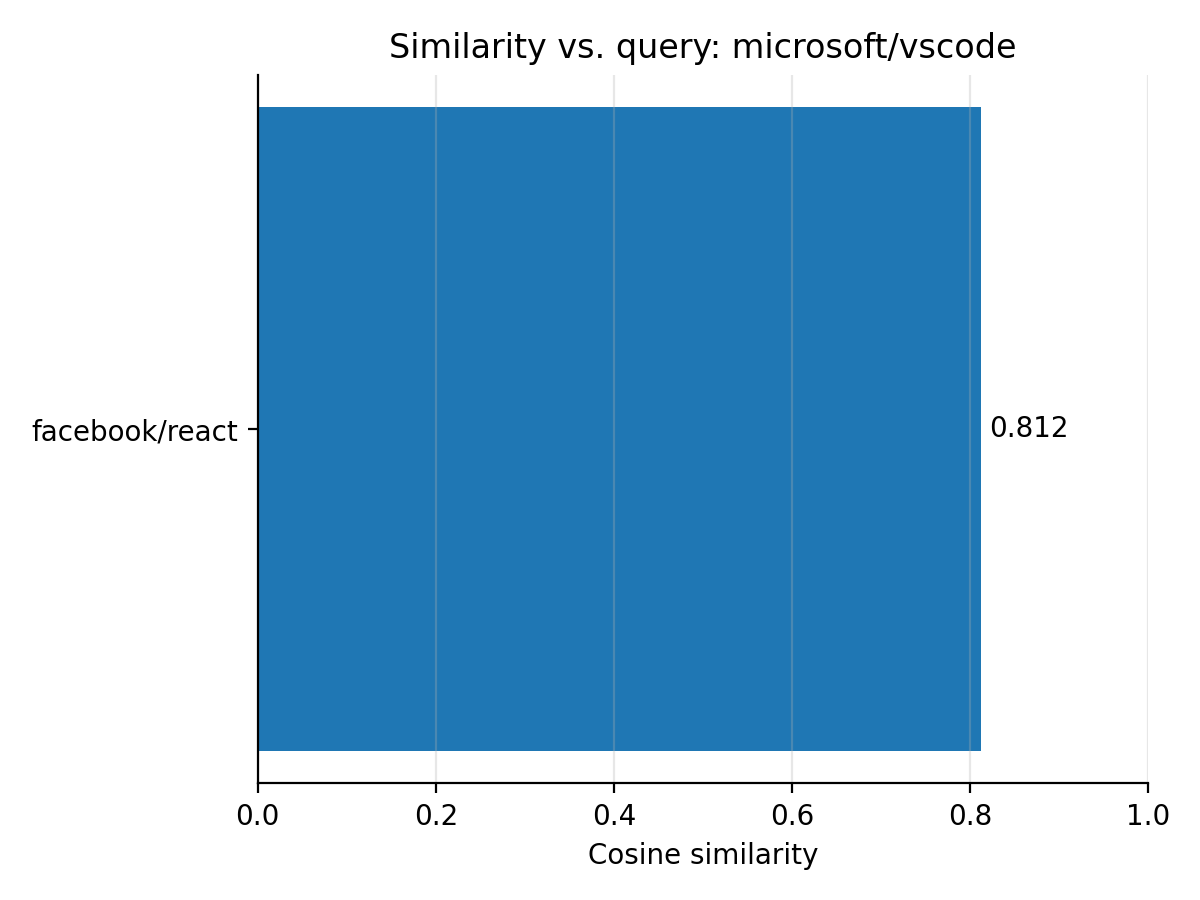

[Plot] Saved feature contributions chart to results_plots\results__features__facebook_react.png


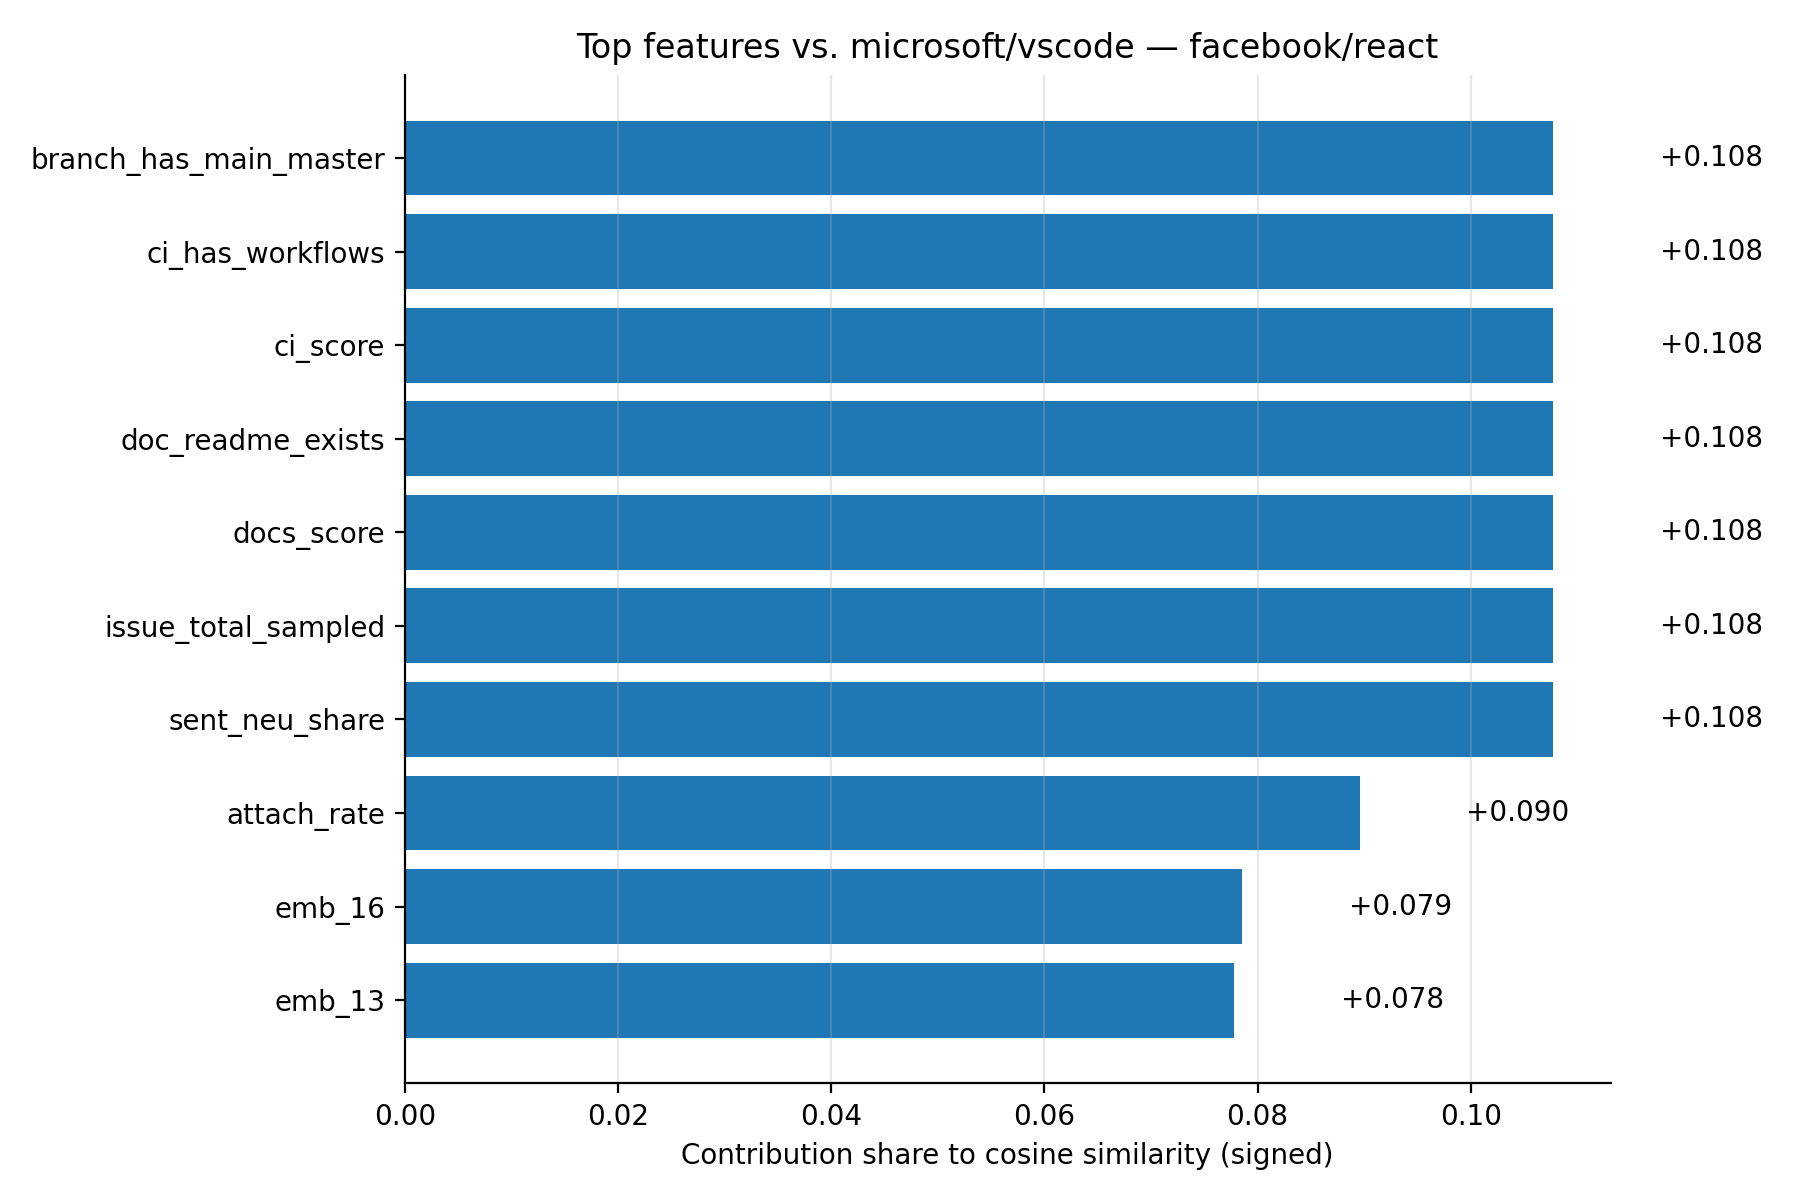

In [90]:
# Example: Create mock args for testing in Jupyter
# Uncomment and modify as needed 
args = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=["https://github.com/facebook/react"],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,  # Set your token here if needed
    max_commits=100,
    plot="results.png",
    plot_details=True,
    plot_size=None,
    dpi=200,
    topn_features=10,
    quiet=False,
    verbose=False
)
 
cmd_compare(args)

## Phase 1: Extended Validation - Test with Electron

**Hypothesis**: vscode should be MORE similar to electron (since vscode is built on Electron) than to react.

Expected: `similarity(vscode, electron) > similarity(vscode, react)`

Comparing 1 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] microsoft/vscode
  Done (50 commits, 4.7s)

[CANDIDATE 1] electron/electron
  Done (50 commits, 3.5s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. electron/electron                        -> similarity = 0.2939
[Plot] Saved similarity chart to results_plots\results_electron.png


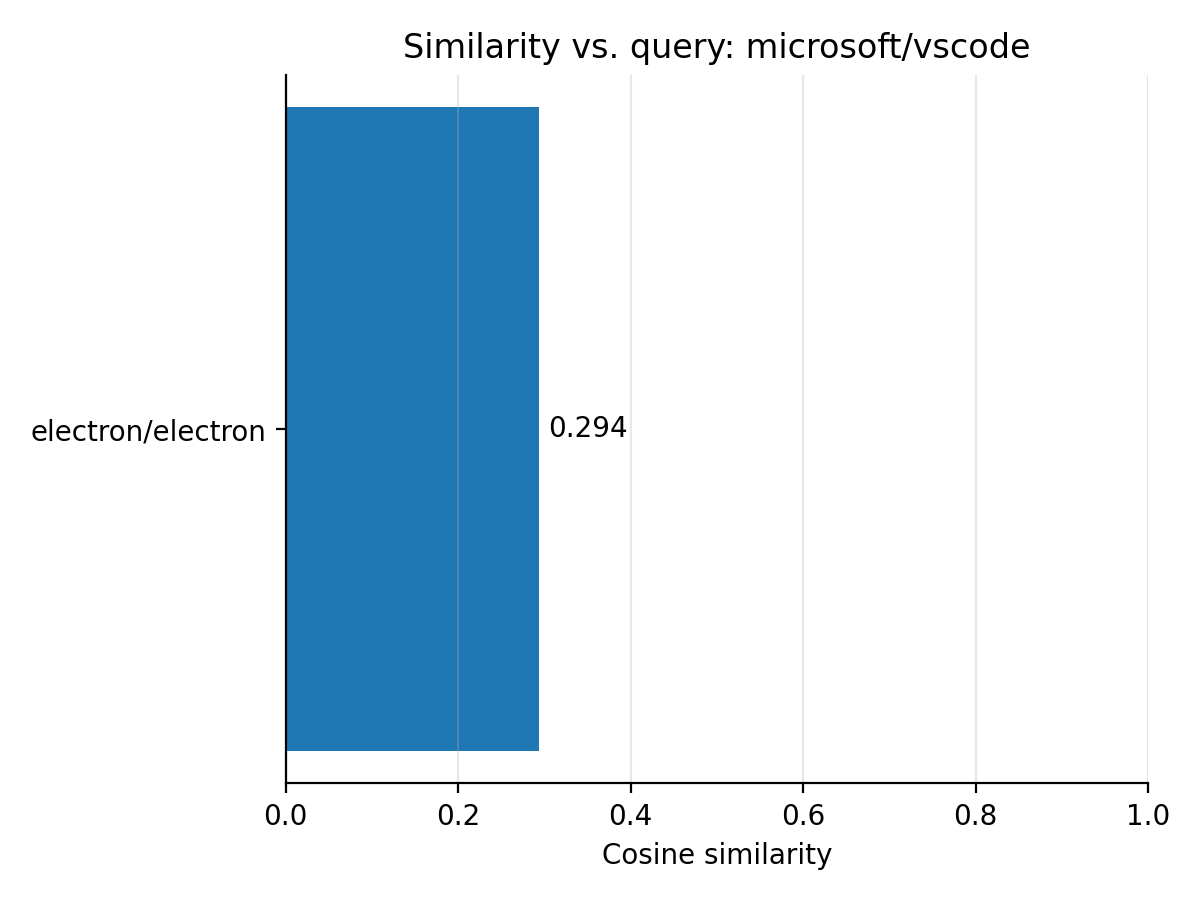

[Plot] Saved feature contributions chart to results_plots\results_electron__features__electron_electron.png


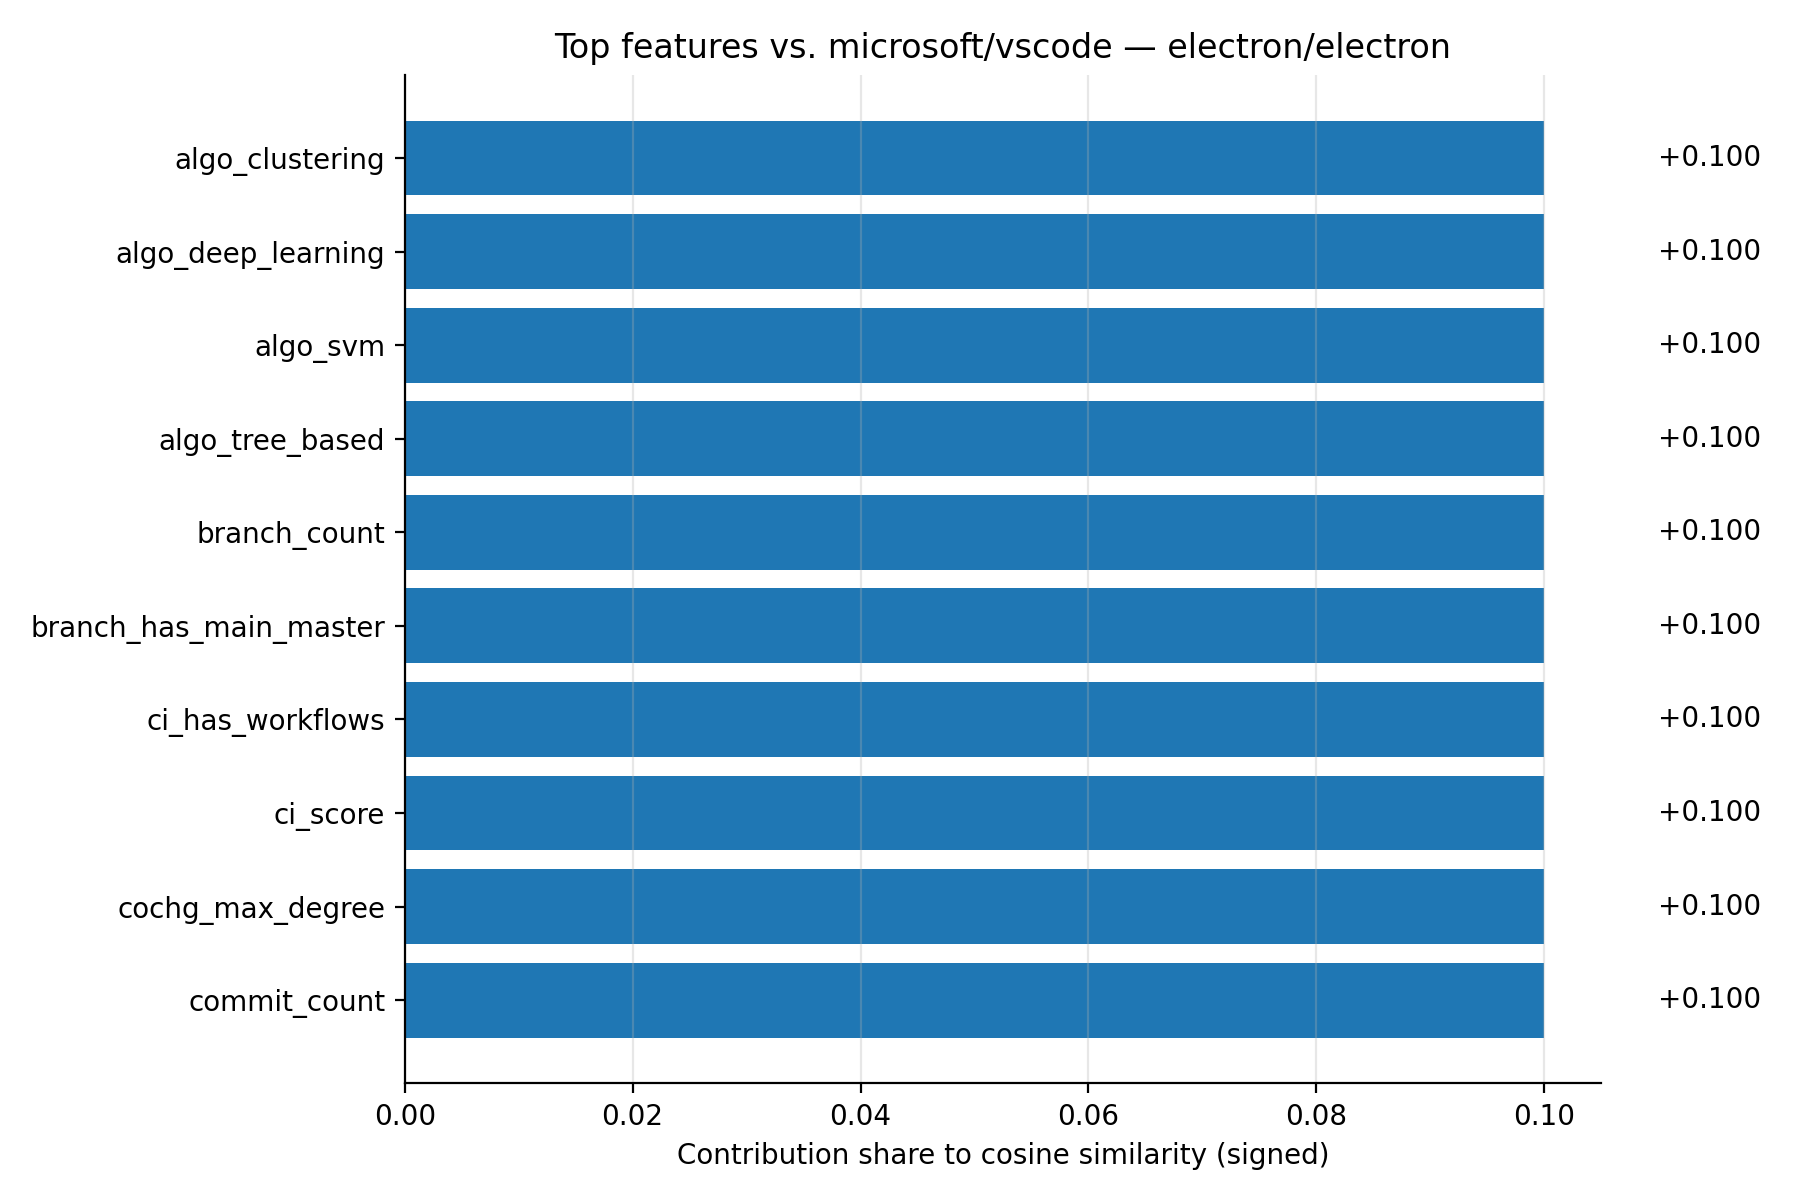

In [35]:
# Test vscode vs electron (should be HIGH similarity)
args_electron = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=["https://github.com/electron/electron"],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_electron.png",
    plot_details=True,
    plot_size=None,
    dpi=200,
    topn_features=10,
    quiet=False,
    verbose=False
)

cmd_compare(args_electron)

## Phase 1: Multi-Candidate Comparison

Test vscode against BOTH react and electron simultaneously to compare similarities.

+100 dpi

Comparing 2 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] microsoft/vscode
  Done (50 commits, 4.8s)

[CANDIDATE 1] facebook/react
  Done (50 commits, 3.7s)

[CANDIDATE 2] electron/electron
  Done (50 commits, 3.6s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. electron/electron                        -> similarity = 0.5542
  2. facebook/react                           -> similarity = 0.4758
[Plot] Saved similarity chart to results_plots\results_multi.png


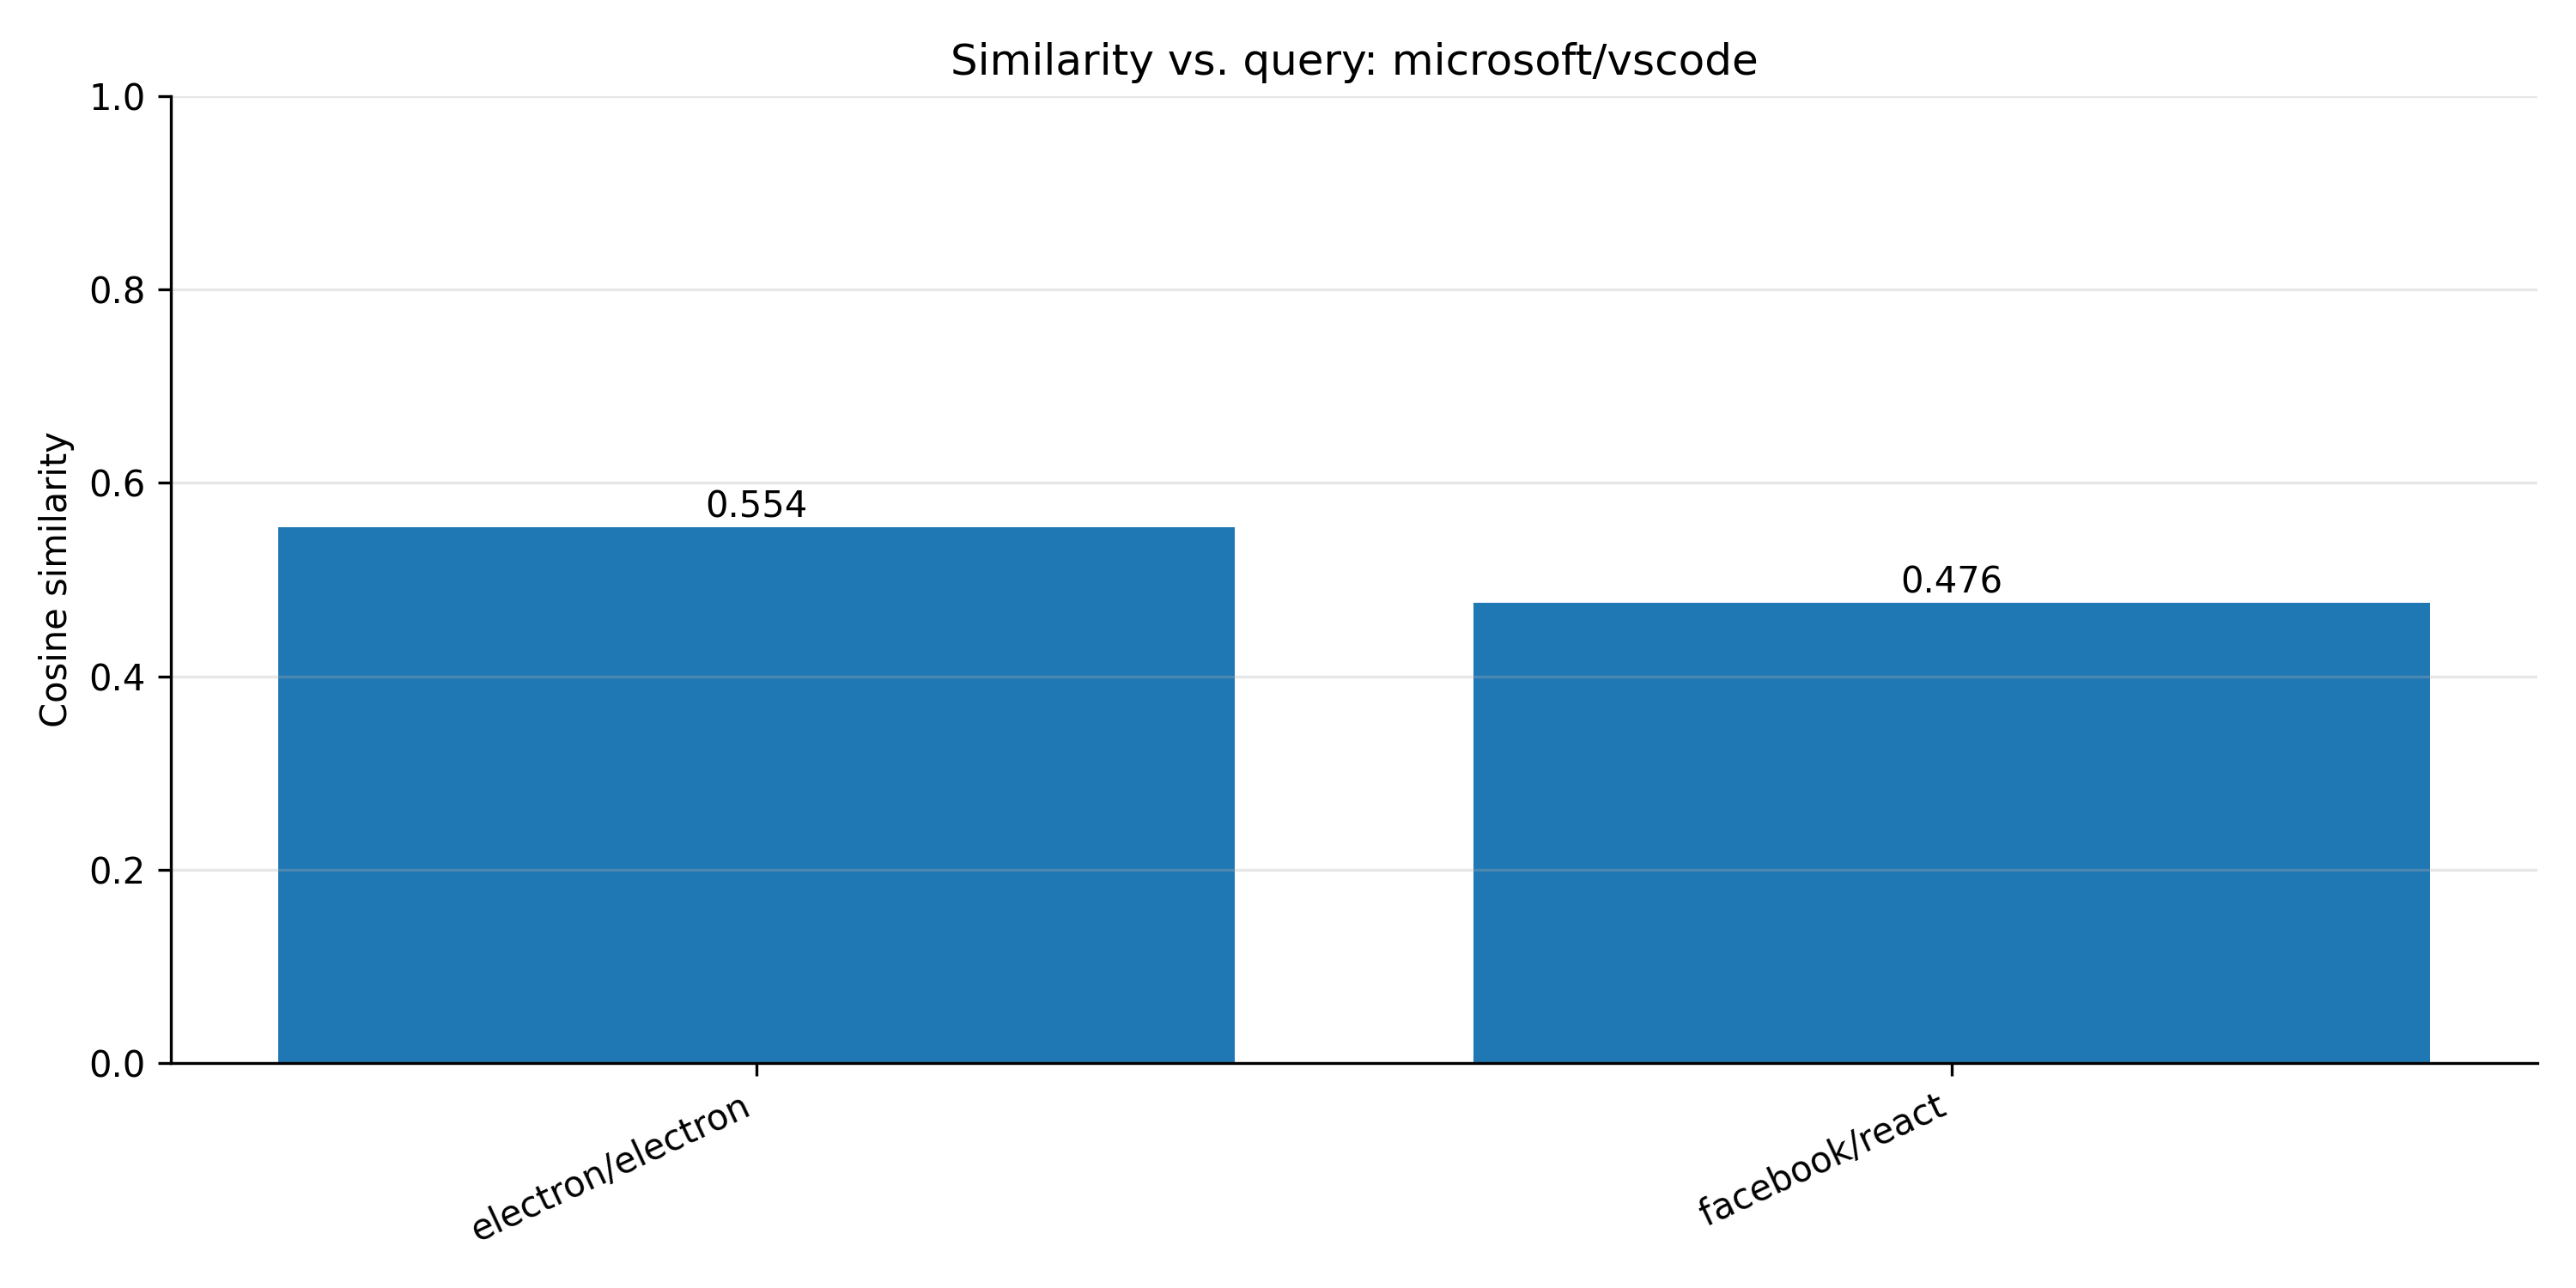

[Plot] Saved feature contributions chart to results_plots\results_multi__features__electron_electron.png


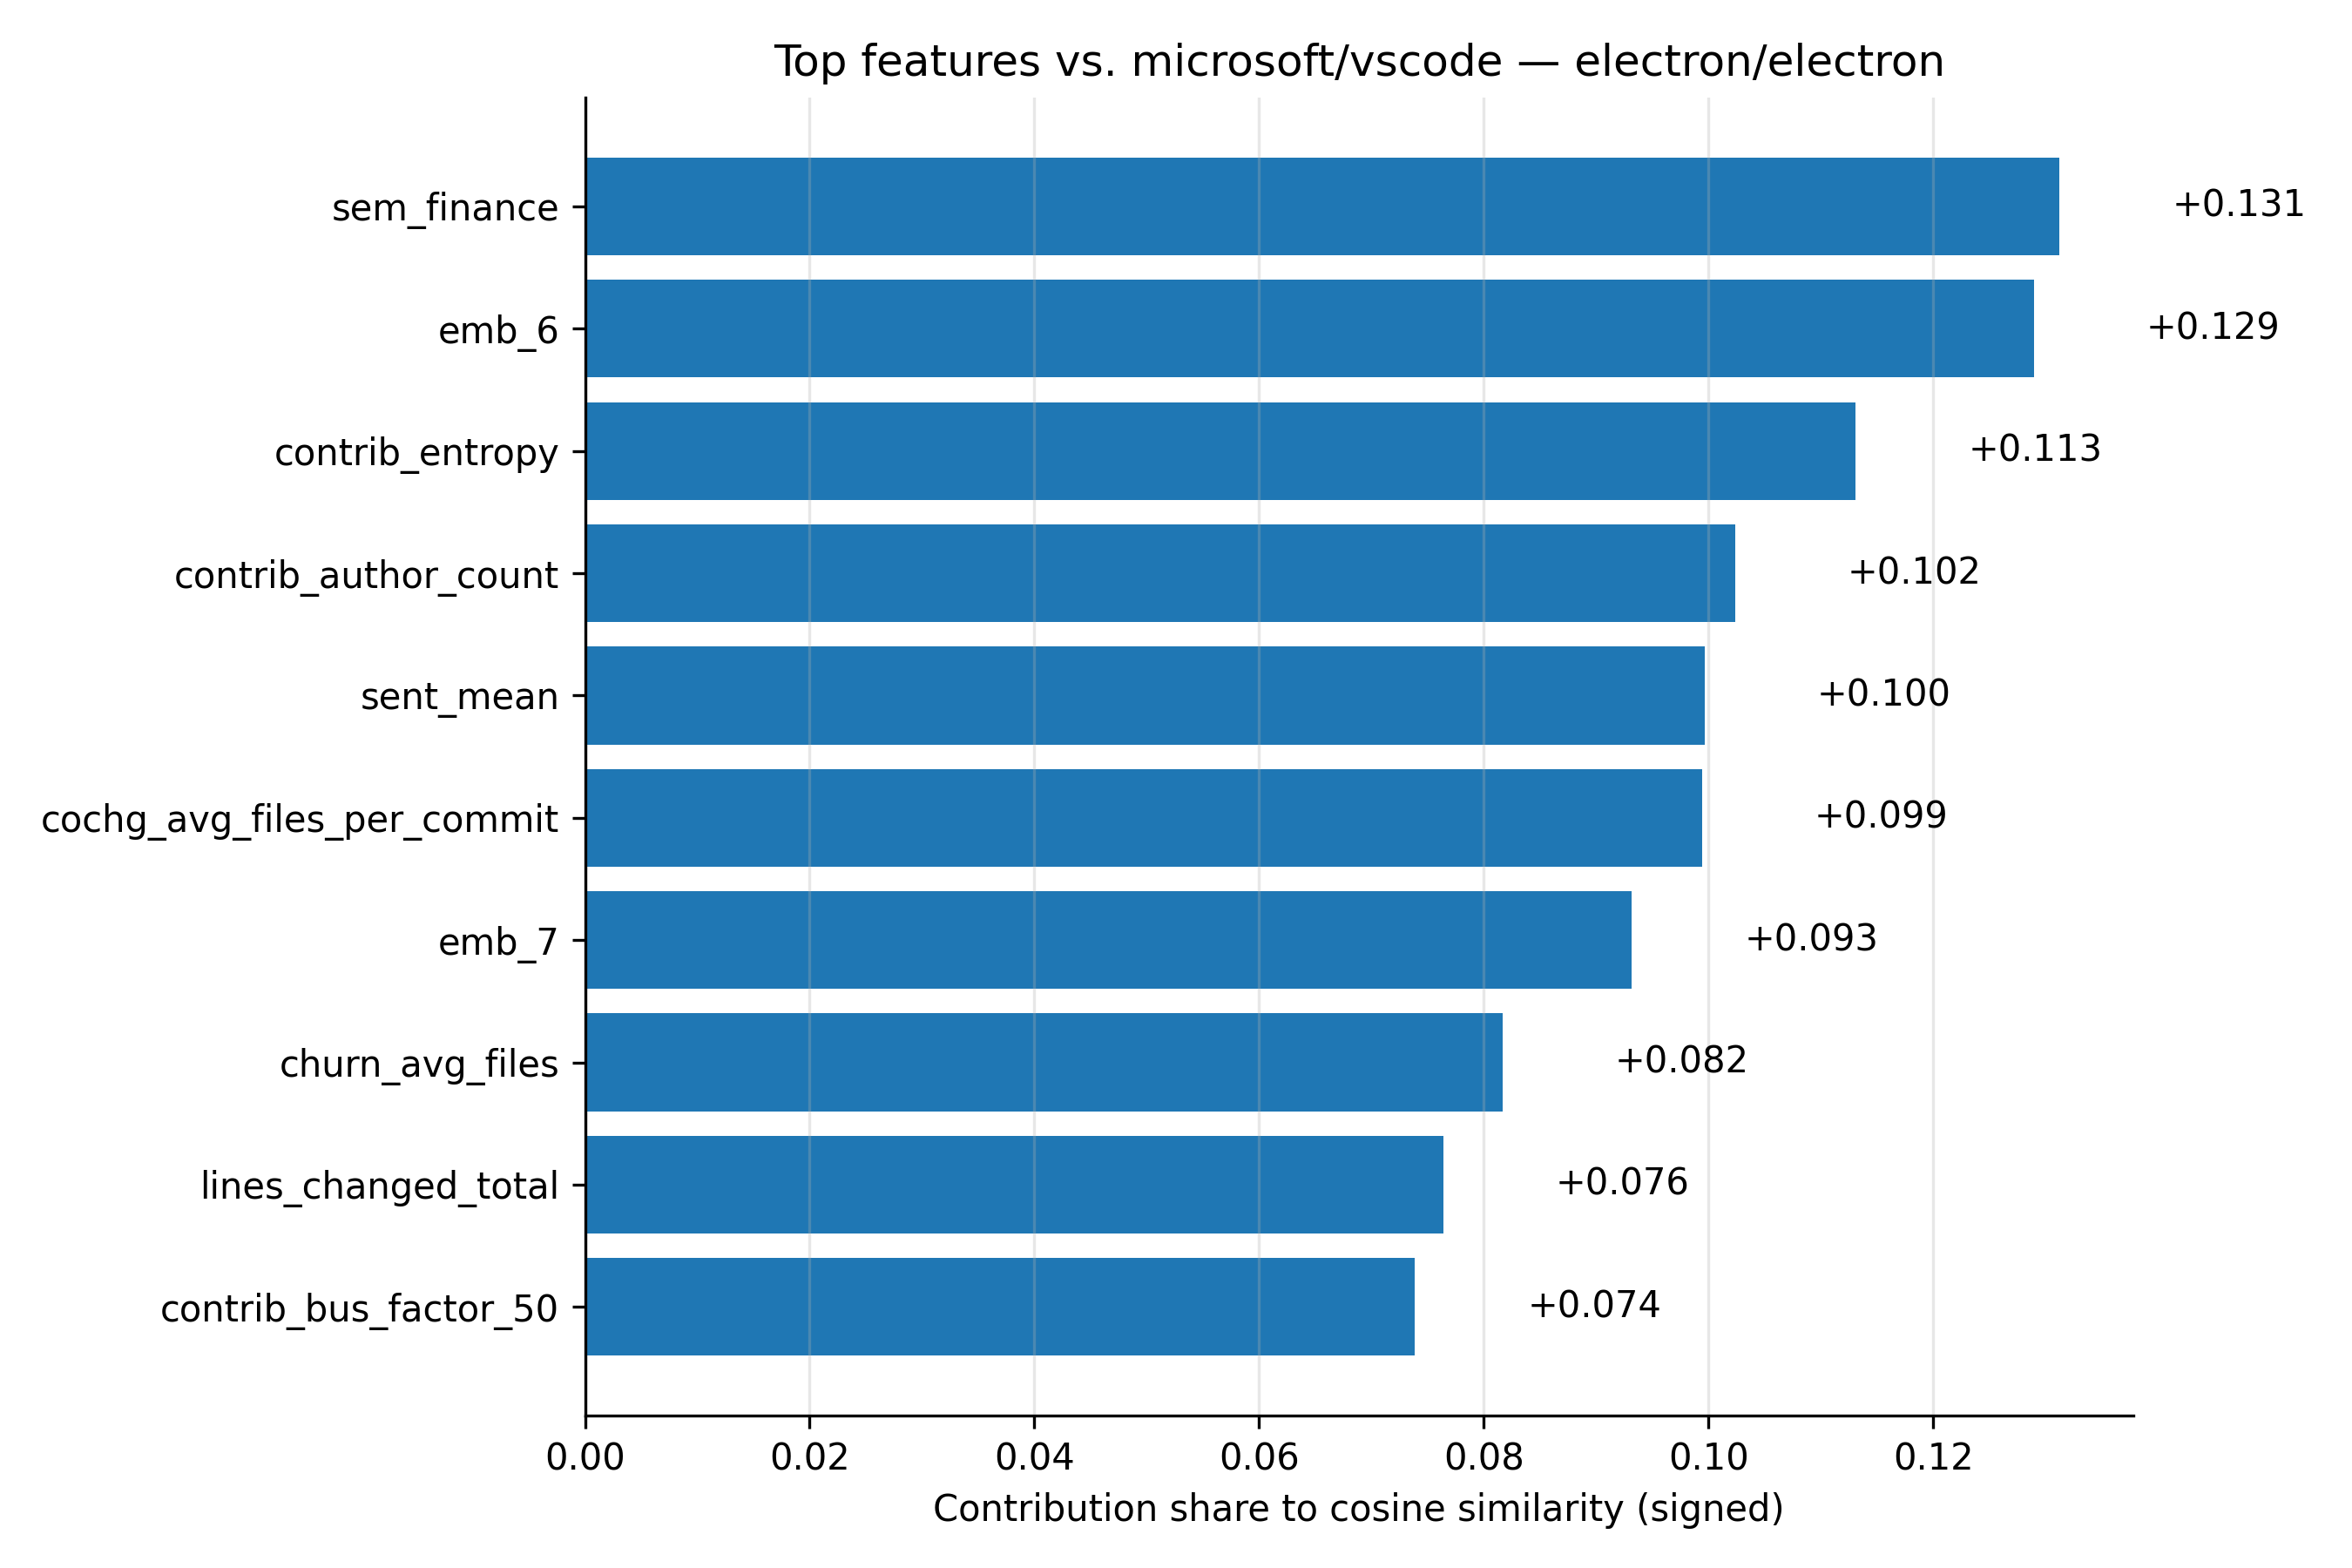

[Plot] Saved feature contributions chart to results_plots\results_multi__features__facebook_react.png


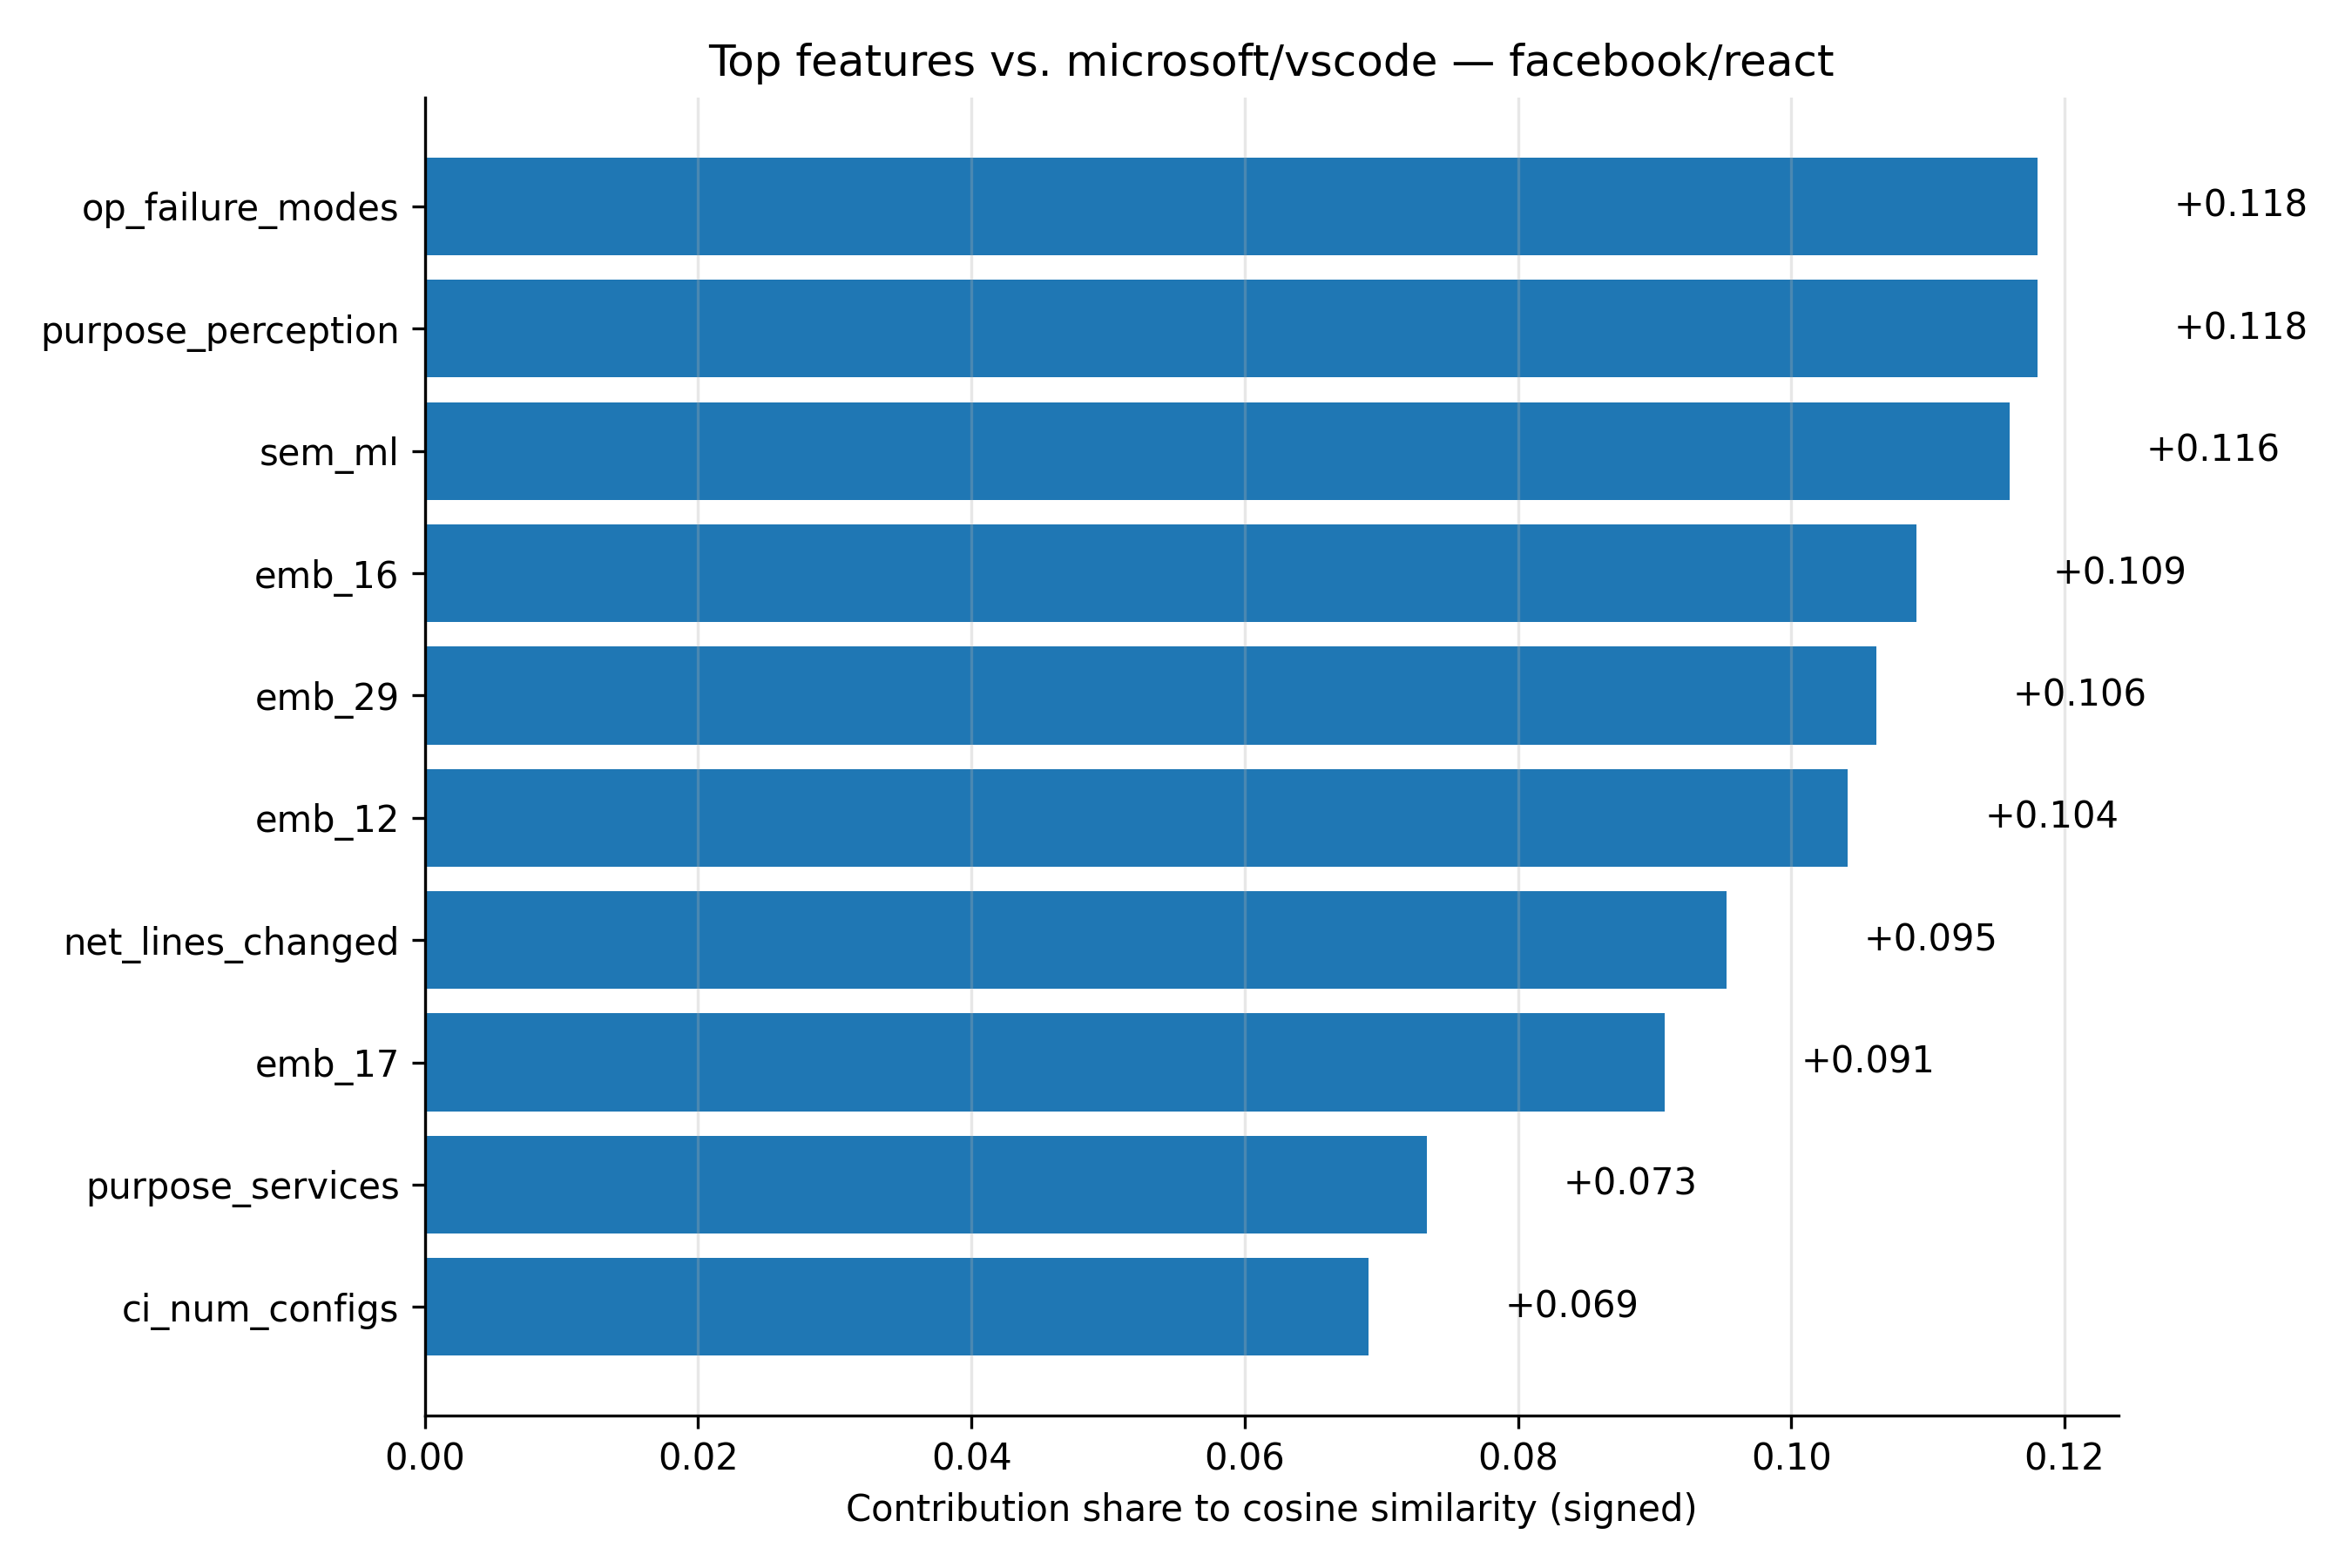

In [36]:
# Compare vscode to BOTH react and electron at once
args_multi = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=[
        "https://github.com/facebook/react",
        "https://github.com/electron/electron"
    ],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_multi.png",
    plot_details=True,
    plot_size="10x5",
    dpi=300,
    topn_features=10,
    quiet=False,
    verbose=False
)

cmd_compare(args_multi)

## Phase 2: Cluster Testing - ML Frameworks

Test if ML/AI frameworks show high similarity to each other.

**Cluster**: TensorFlow, PyTorch, scikit-learn

Comparing 2 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] tensorflow/tensorflow
  Done (50 commits, 4.3s)

[CANDIDATE 1] pytorch/pytorch
  Fetching commits from pytorch/pytorch...


Commits: 100c [00:55,  1.81c/s, fetched=100]


  Done (100 commits, 59.2s)

[CANDIDATE 2] scikit-learn/scikit-learn
  Done (50 commits, 3.5s)

Normalizing...
 Done

QUERY: https://github.com/tensorflow/tensorflow
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. pytorch/pytorch                          -> similarity = 0.8633
  2. scikit-learn/scikit-learn                -> similarity = 0.7641
[Plot] Saved similarity chart to results_plots\results_ml_cluster.png


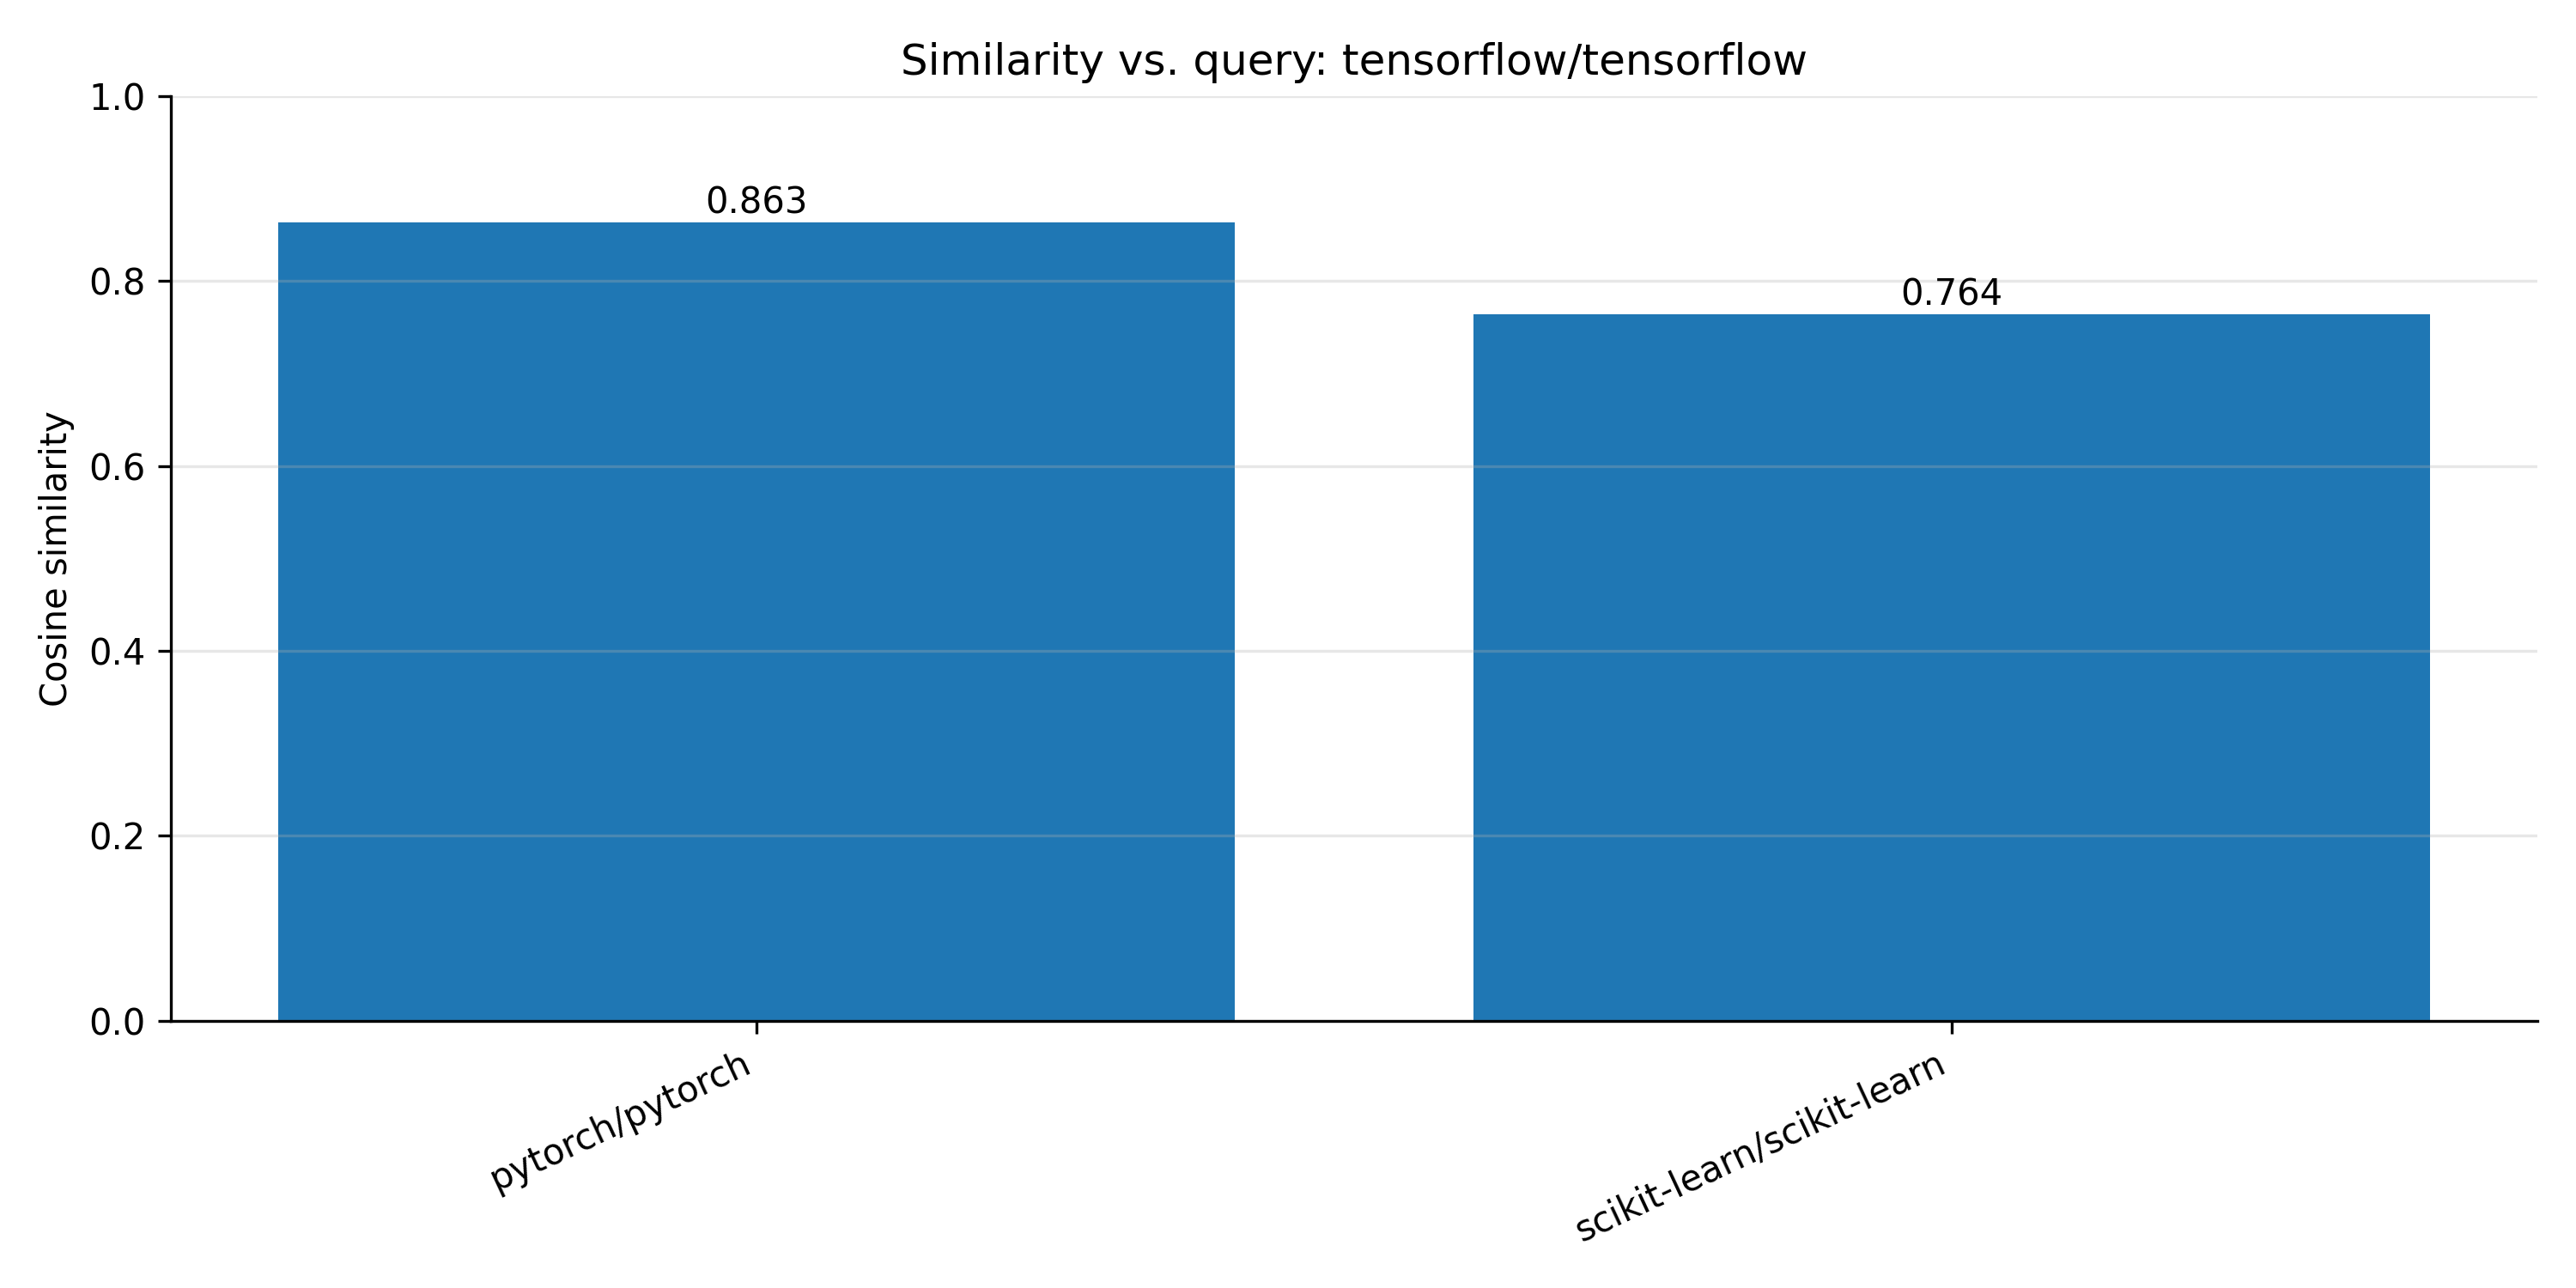

[Plot] Saved feature contributions chart to results_plots\results_ml_cluster__features__pytorch_pytorch.png


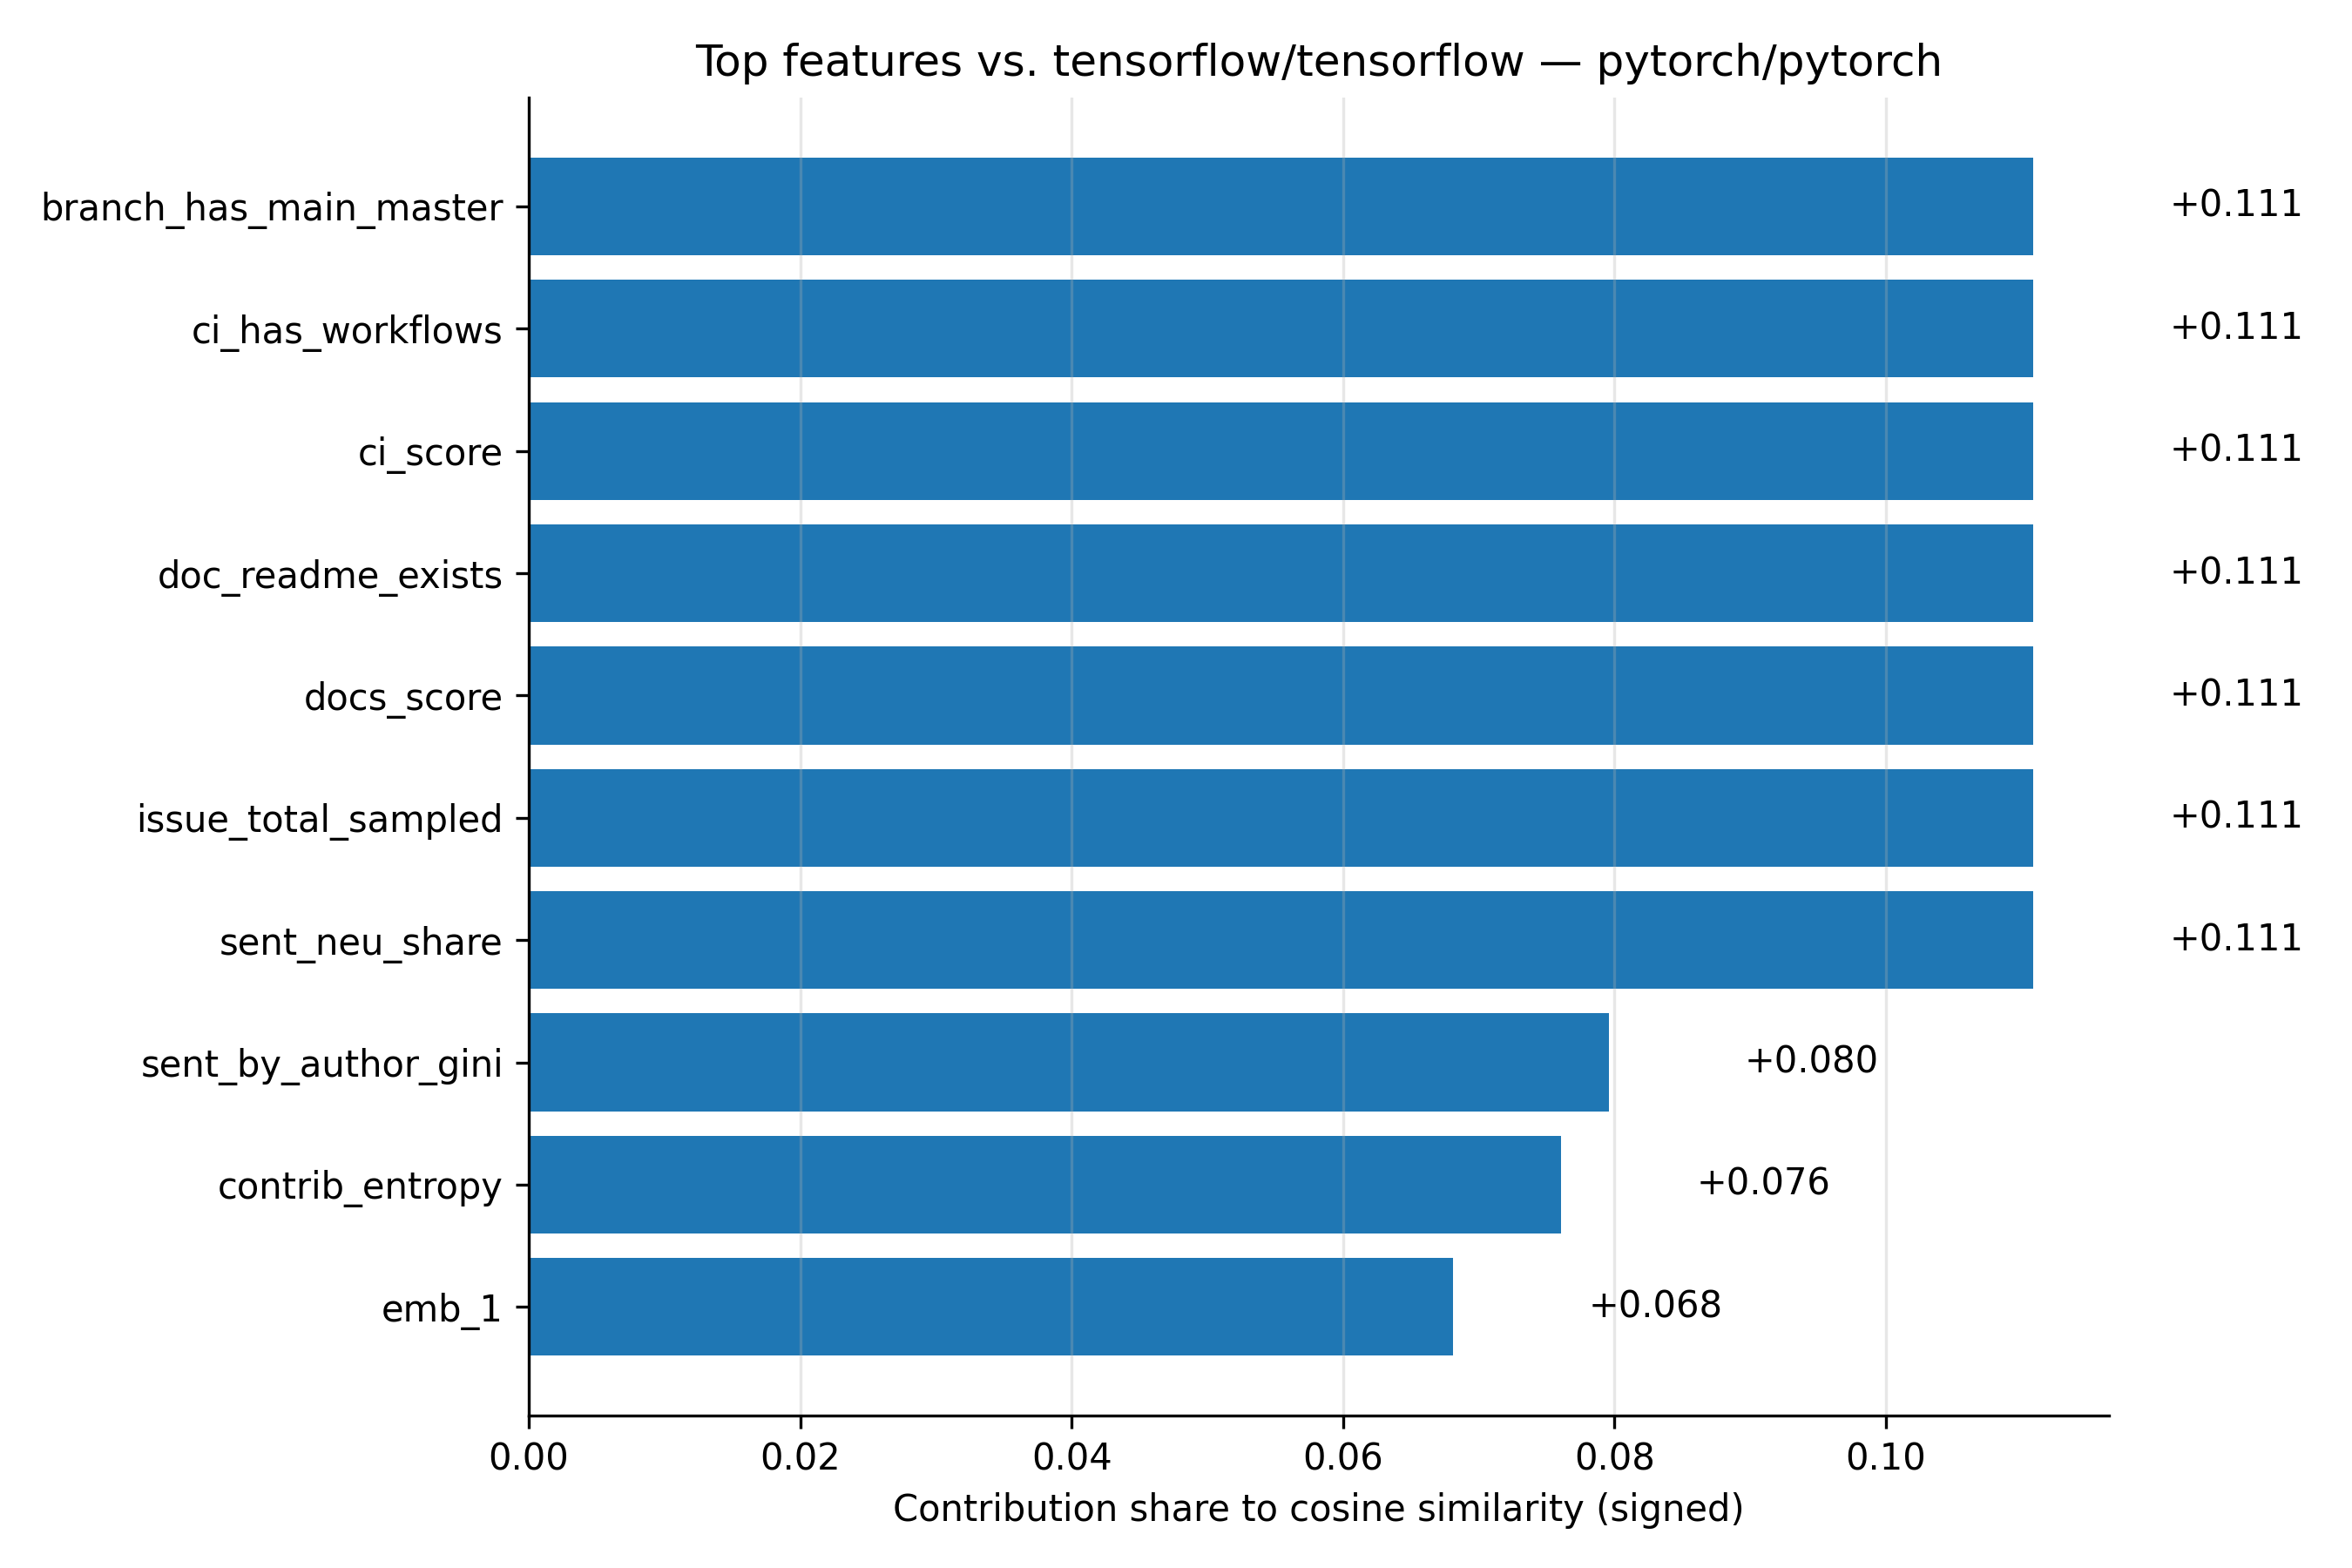

[Plot] Saved feature contributions chart to results_plots\results_ml_cluster__features__scikit-learn_scikit-learn.png


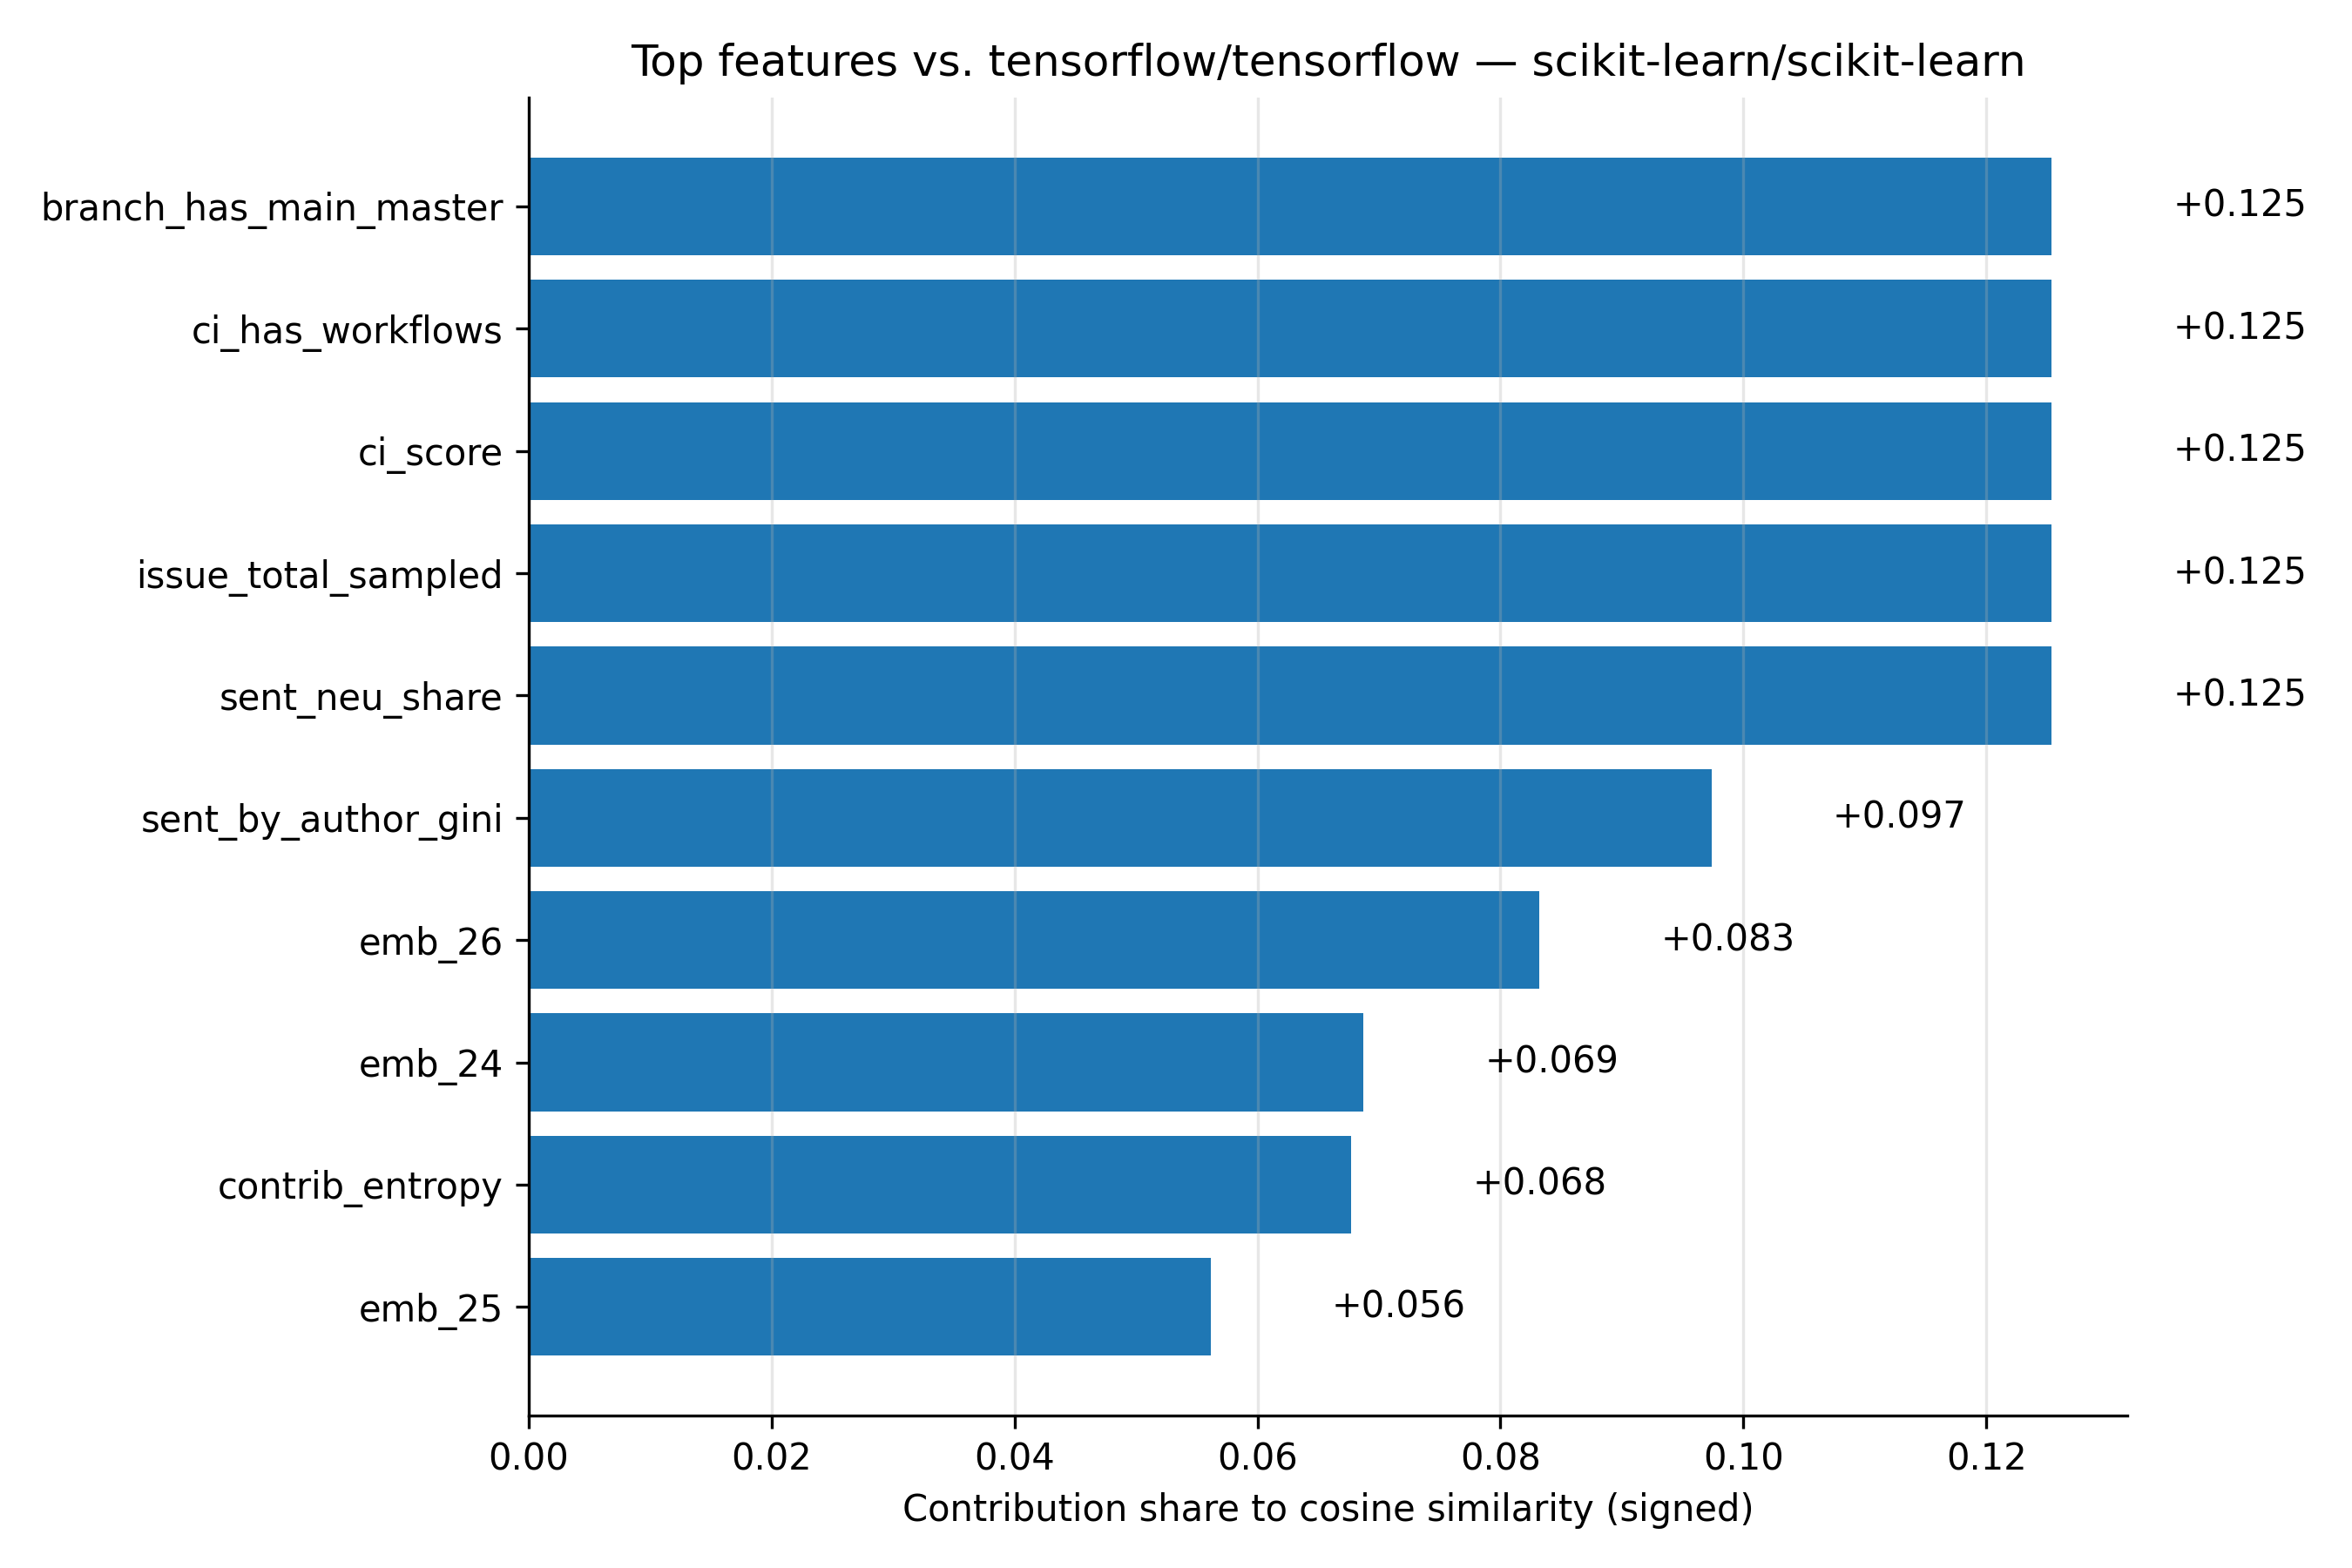

In [91]:
# Test ML framework similarity: TensorFlow vs PyTorch vs scikit-learn
args_ml = SimpleNamespace(
    query="https://github.com/tensorflow/tensorflow",
    candidates=[
        "https://github.com/pytorch/pytorch",
        "https://github.com/scikit-learn/scikit-learn"
    ],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_ml_cluster.png",
    plot_details=True,
    plot_size="10x5",
    dpi=300,
    topn_features=10,
    quiet=False,
    verbose=False
)

cmd_compare(args_ml)

## Phase 2: Cluster Testing - Web Frameworks

Test if Python web frameworks show high similarity to each other.

**Cluster**: Django, Flask

Comparing 1 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] django/django
  Done (50 commits, 9.6s)

[CANDIDATE 1] pallets/flask
  Fetching commits from pallets/flask...


Commits: 100c [00:55,  1.80c/s, fetched=100]


  Done (100 commits, 62.2s)

Normalizing...
 Done

QUERY: https://github.com/django/django
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. pallets/flask                            -> similarity = 0.2958
[Plot] Saved similarity chart to results_plots\results_web_cluster.png


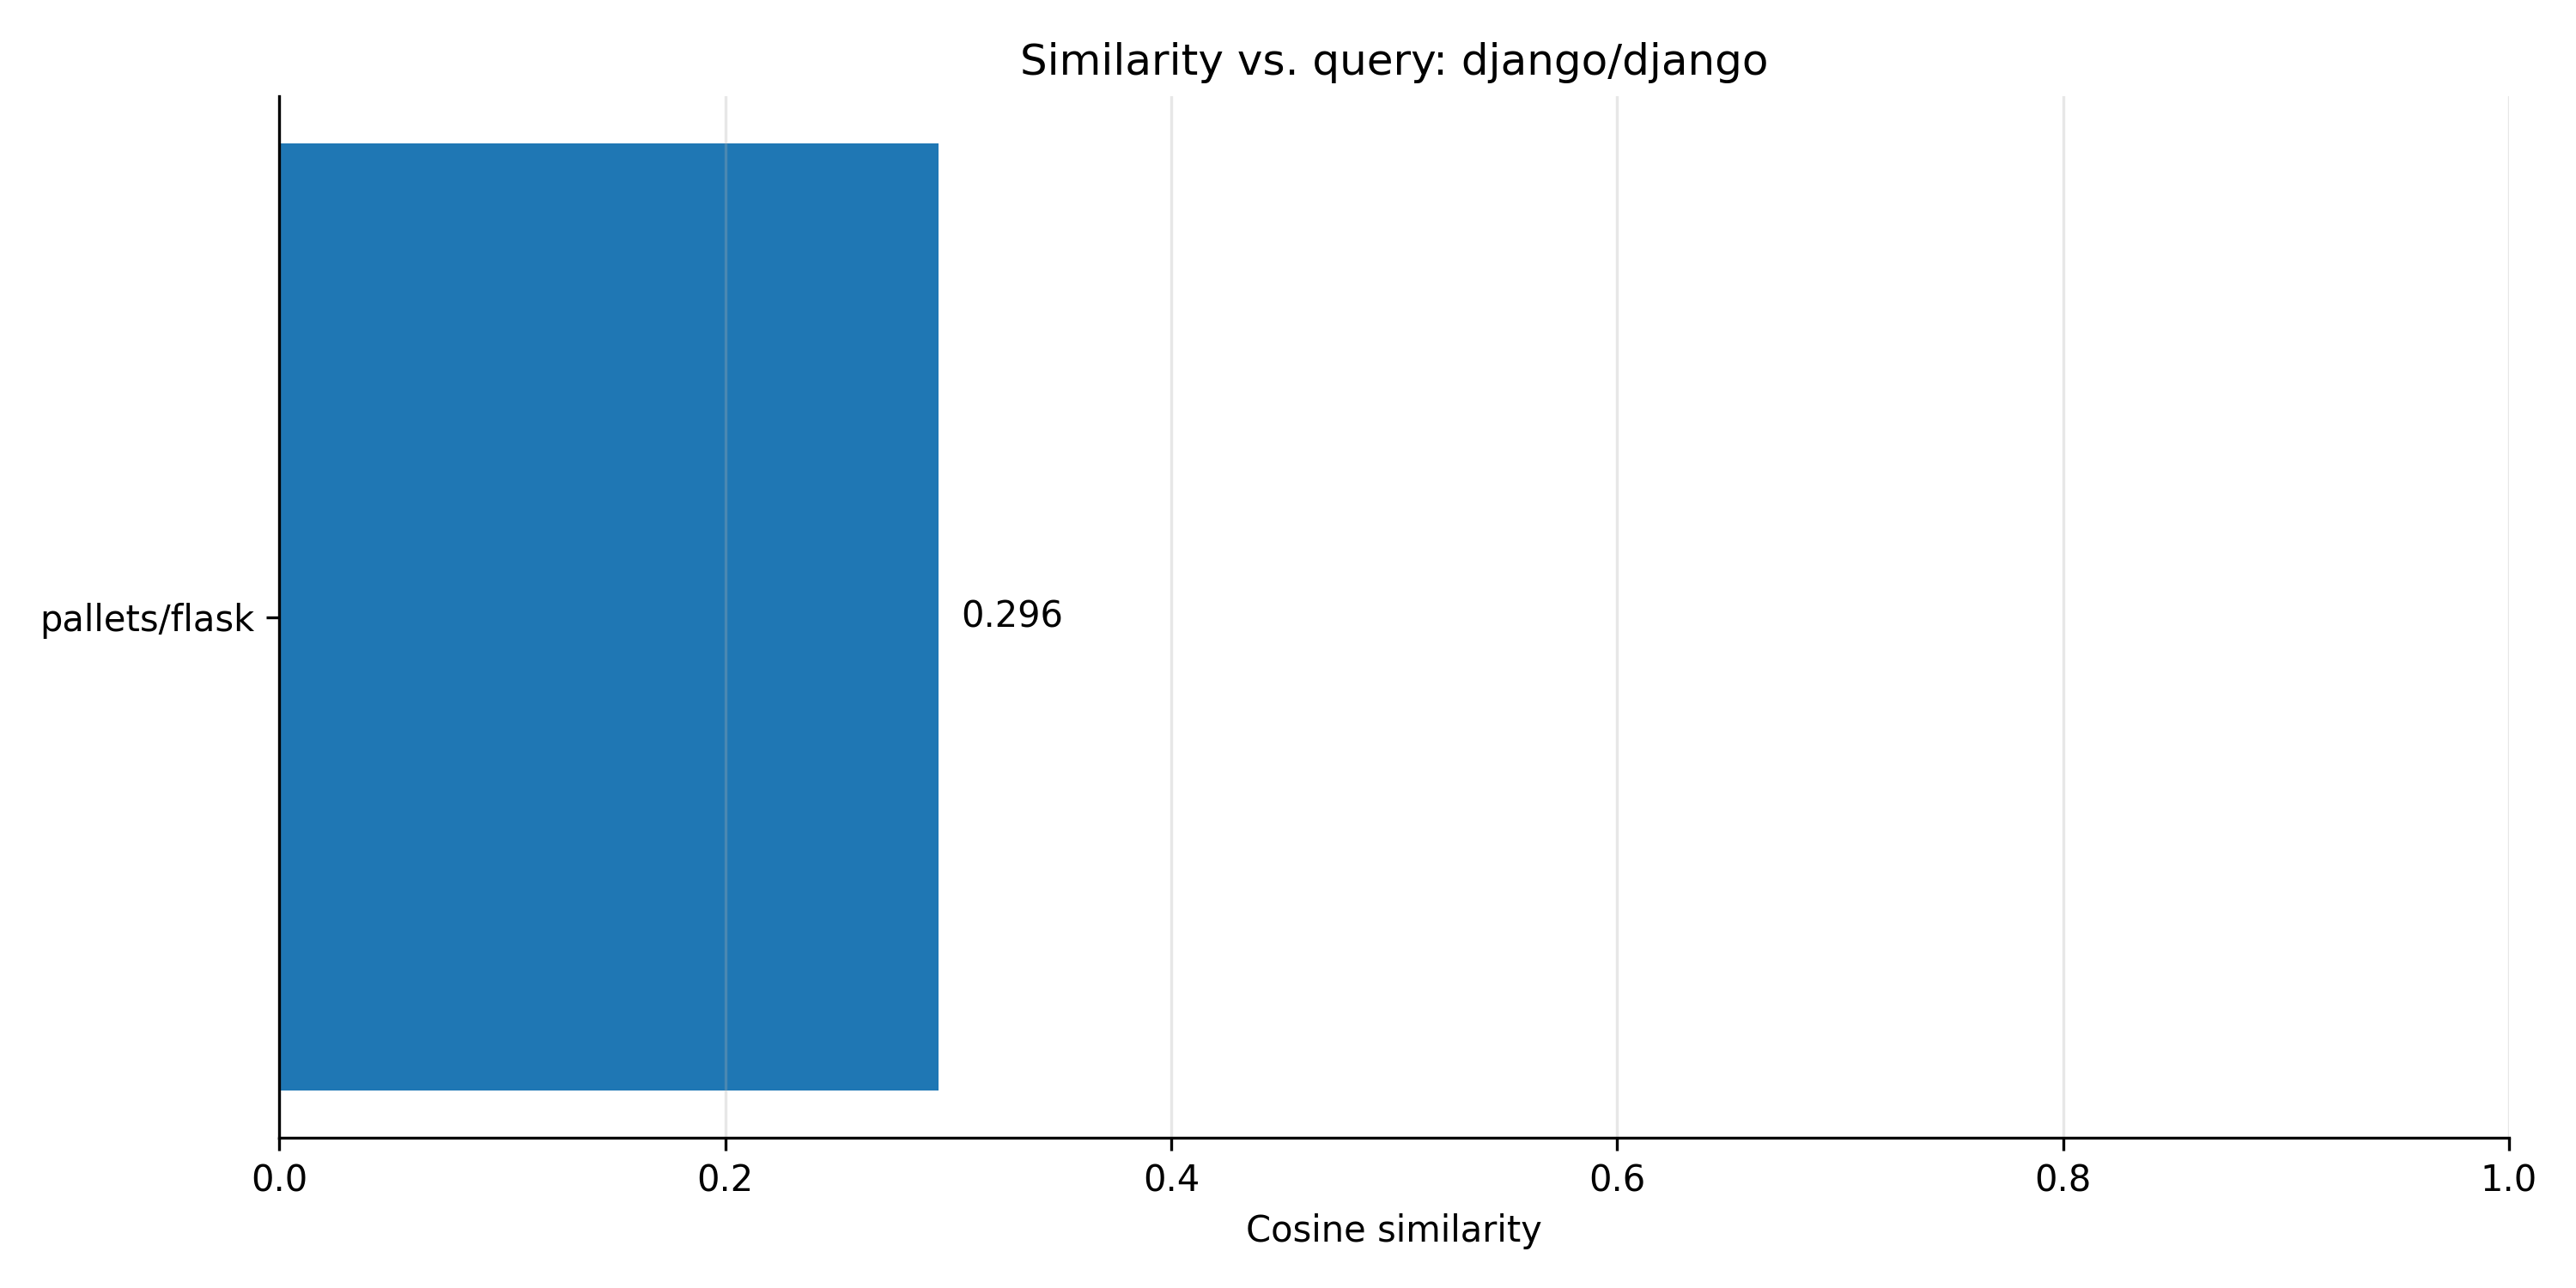

[Plot] Saved feature contributions chart to results_plots\results_web_cluster__features__pallets_flask.png


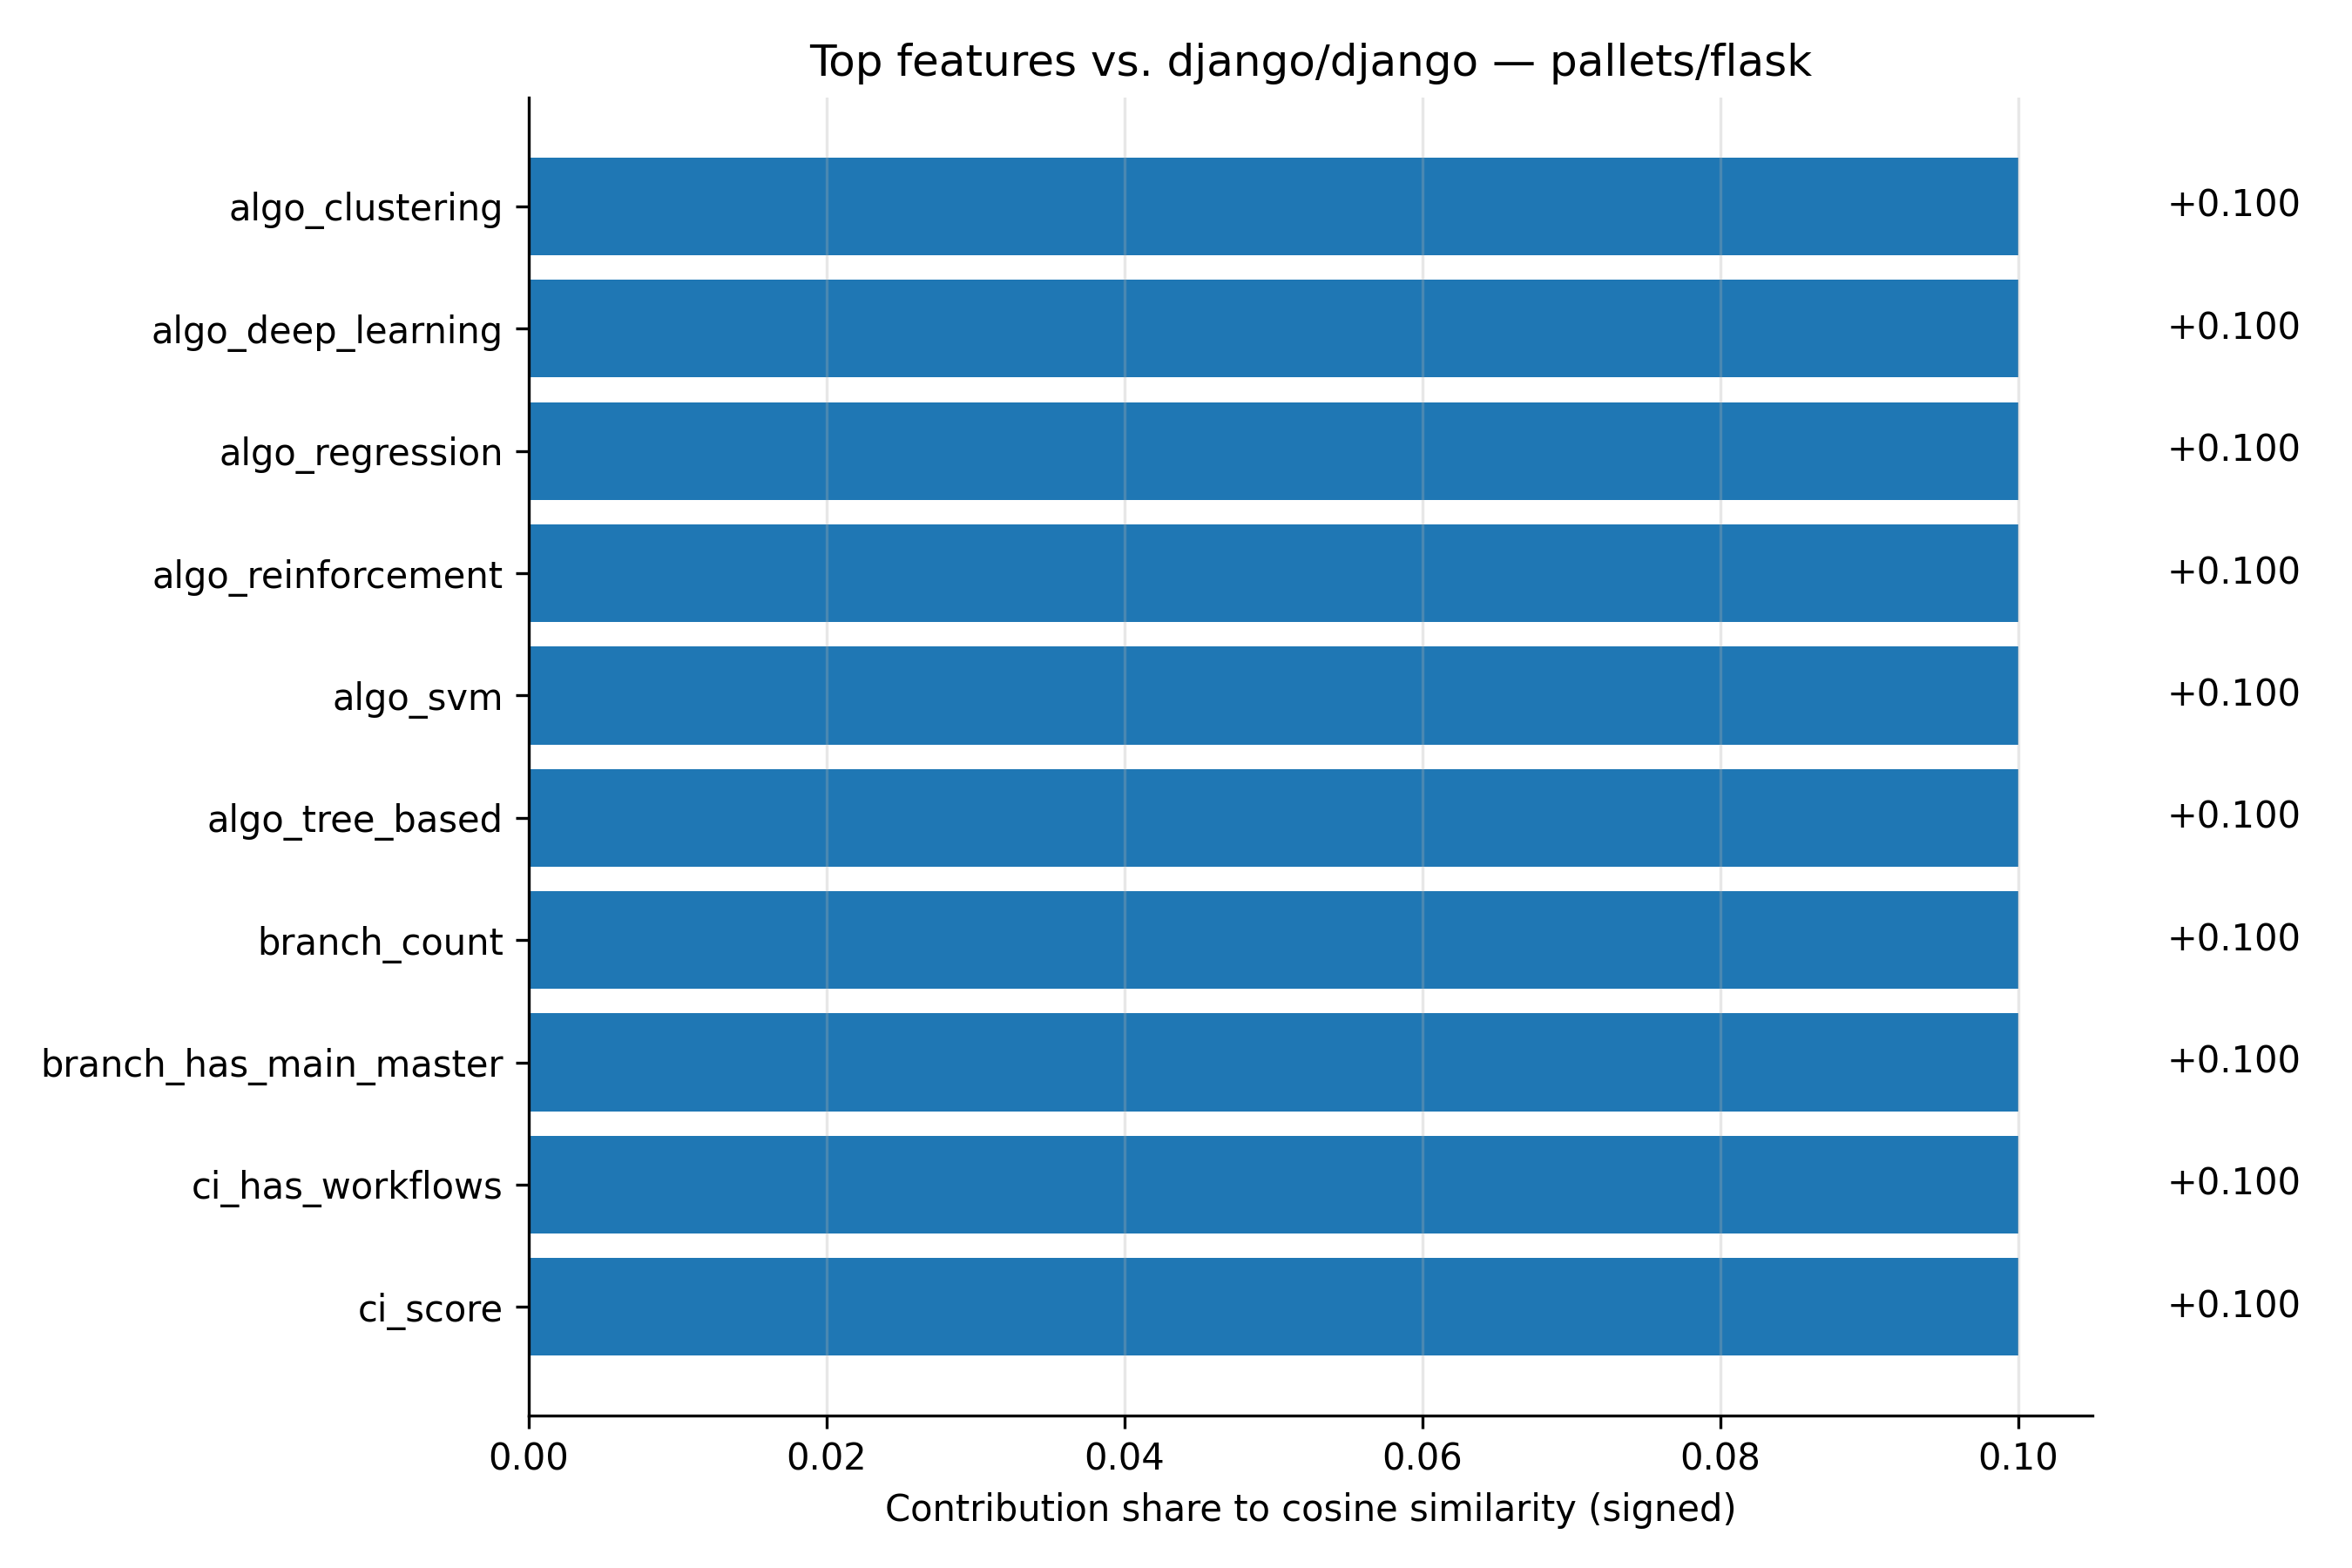

In [38]:
# Test web framework similarity: Django vs Flask
args_web = SimpleNamespace(
    query="https://github.com/django/django",
    candidates=["https://github.com/pallets/flask"],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_web_cluster.png",
    plot_details=True,
    plot_size="10x5",
    dpi=300,
    topn_features=10,
    quiet=False,
    verbose=False
)

cmd_compare(args_web)

## Phase 2: Cross-Cluster Testing

Test if repos from DIFFERENT clusters show LOW similarity.

**Test**: ML framework (TensorFlow) vs Web framework (Django) - should be LOW similarity

Comparing 1 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] tensorflow/tensorflow
  Done (50 commits, 3.8s)

[CANDIDATE 1] django/django
  Done (50 commits, 3.9s)

Normalizing...
 Done

QUERY: https://github.com/tensorflow/tensorflow
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. django/django                            -> similarity = 0.3045
[Plot] Saved similarity chart to results_plots\results_cross_cluster.png


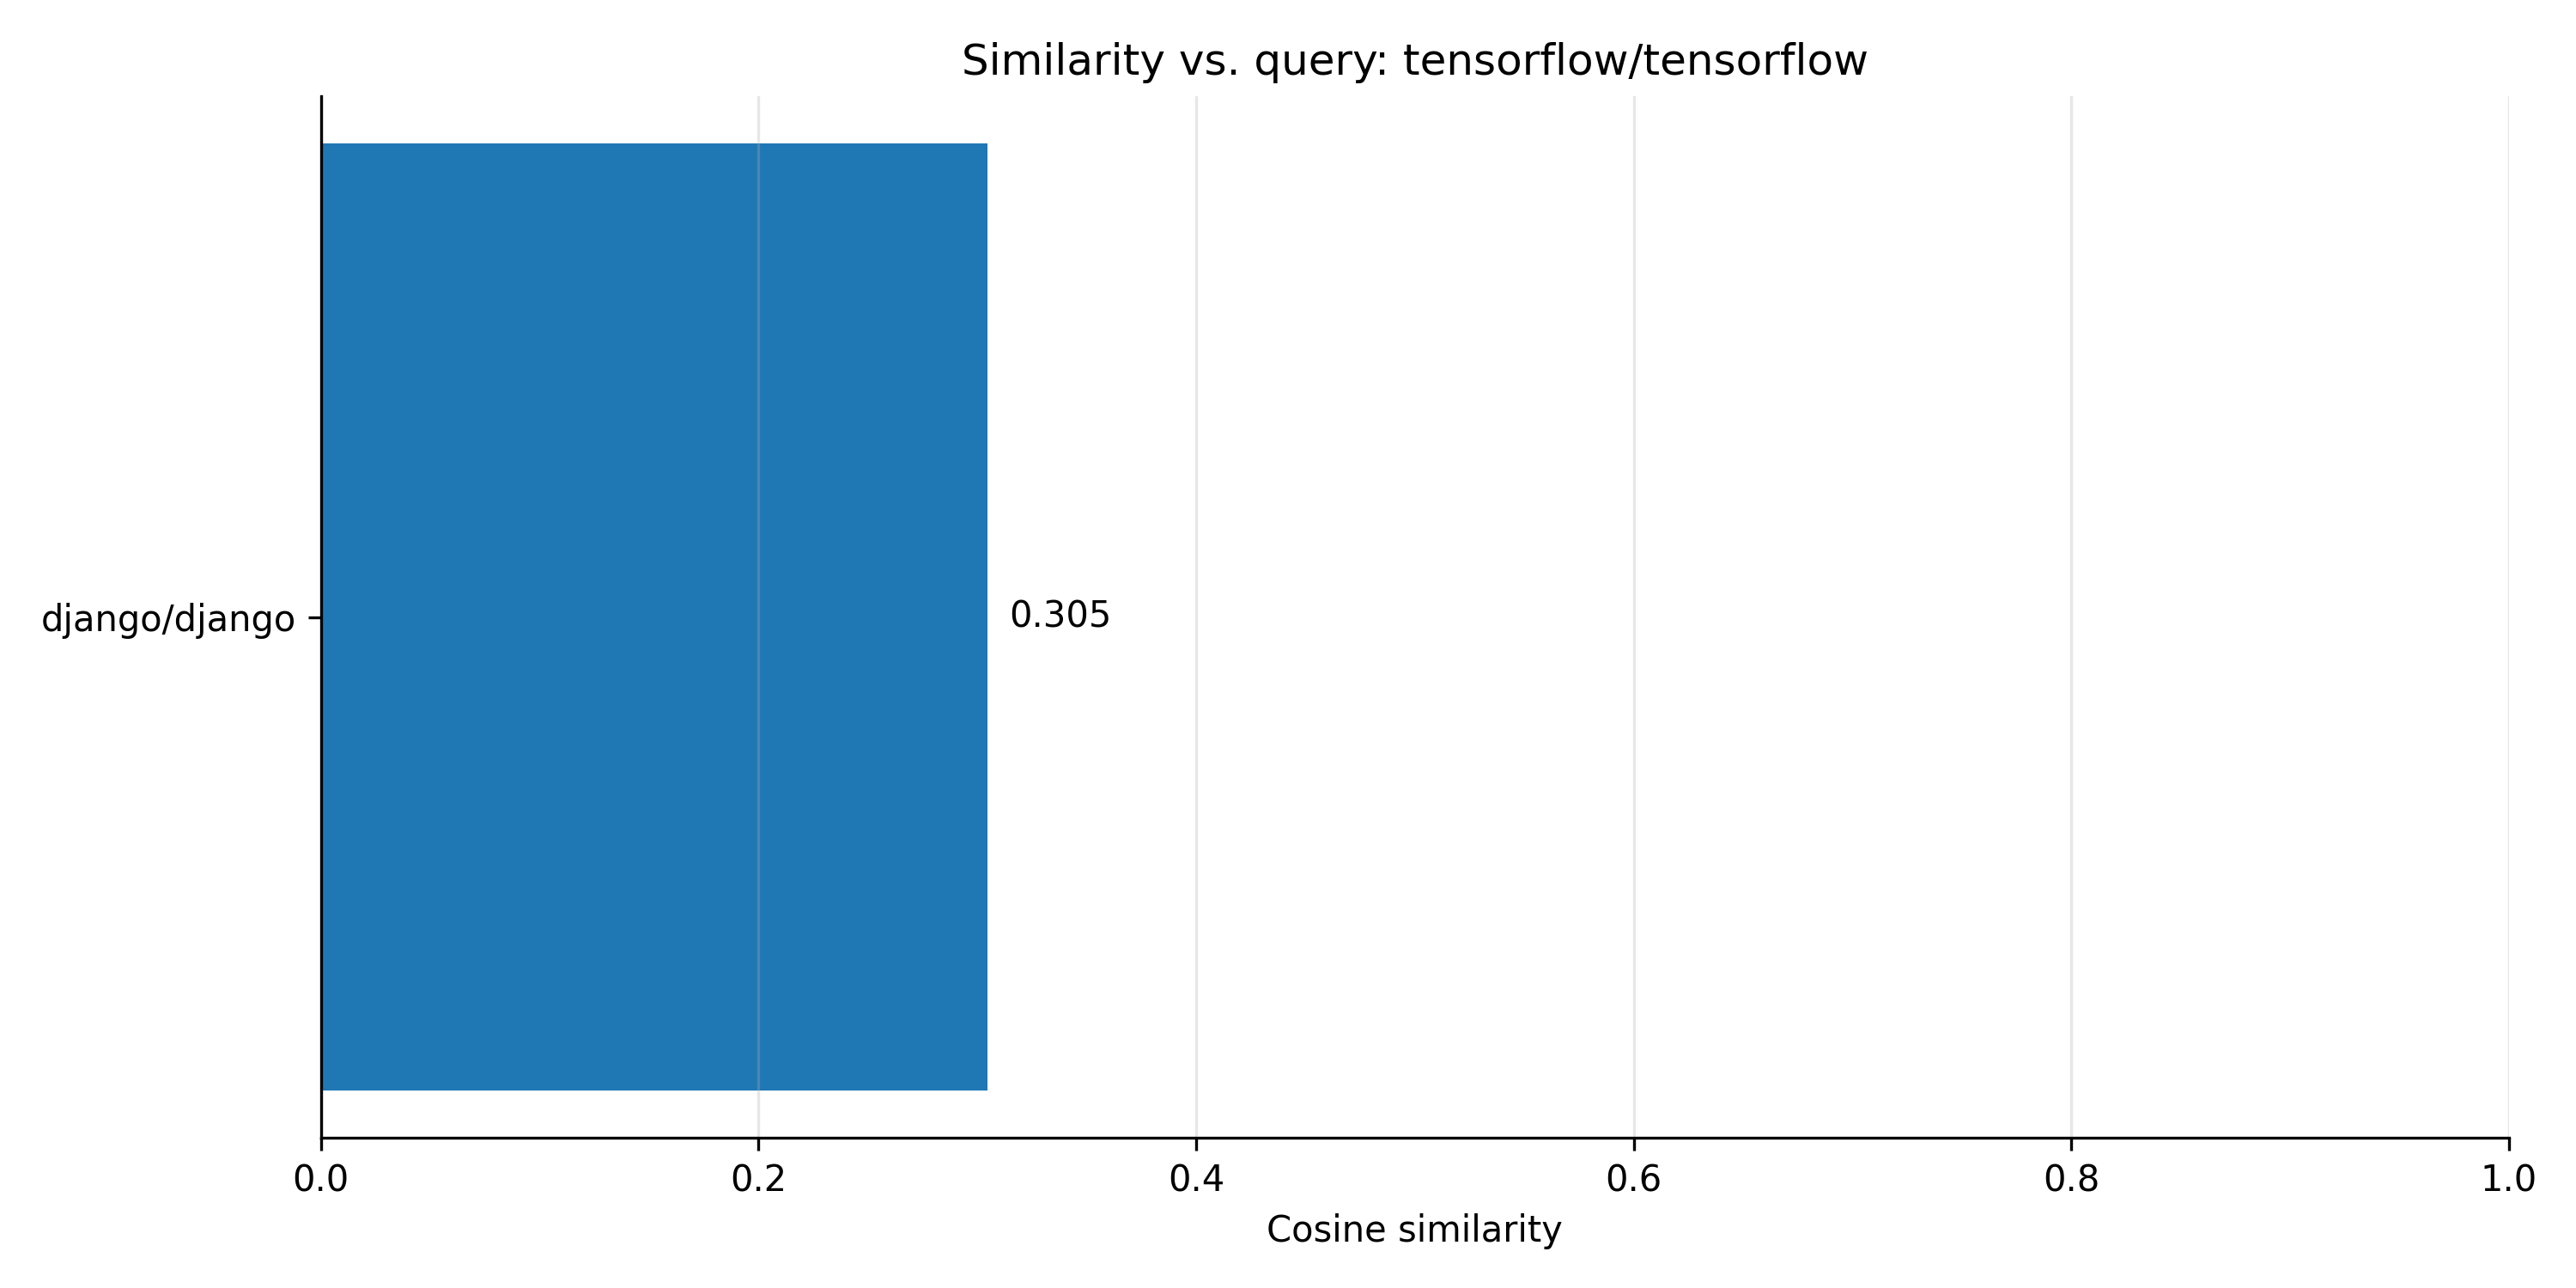

[Plot] Saved feature contributions chart to results_plots\results_cross_cluster__features__django_django.png


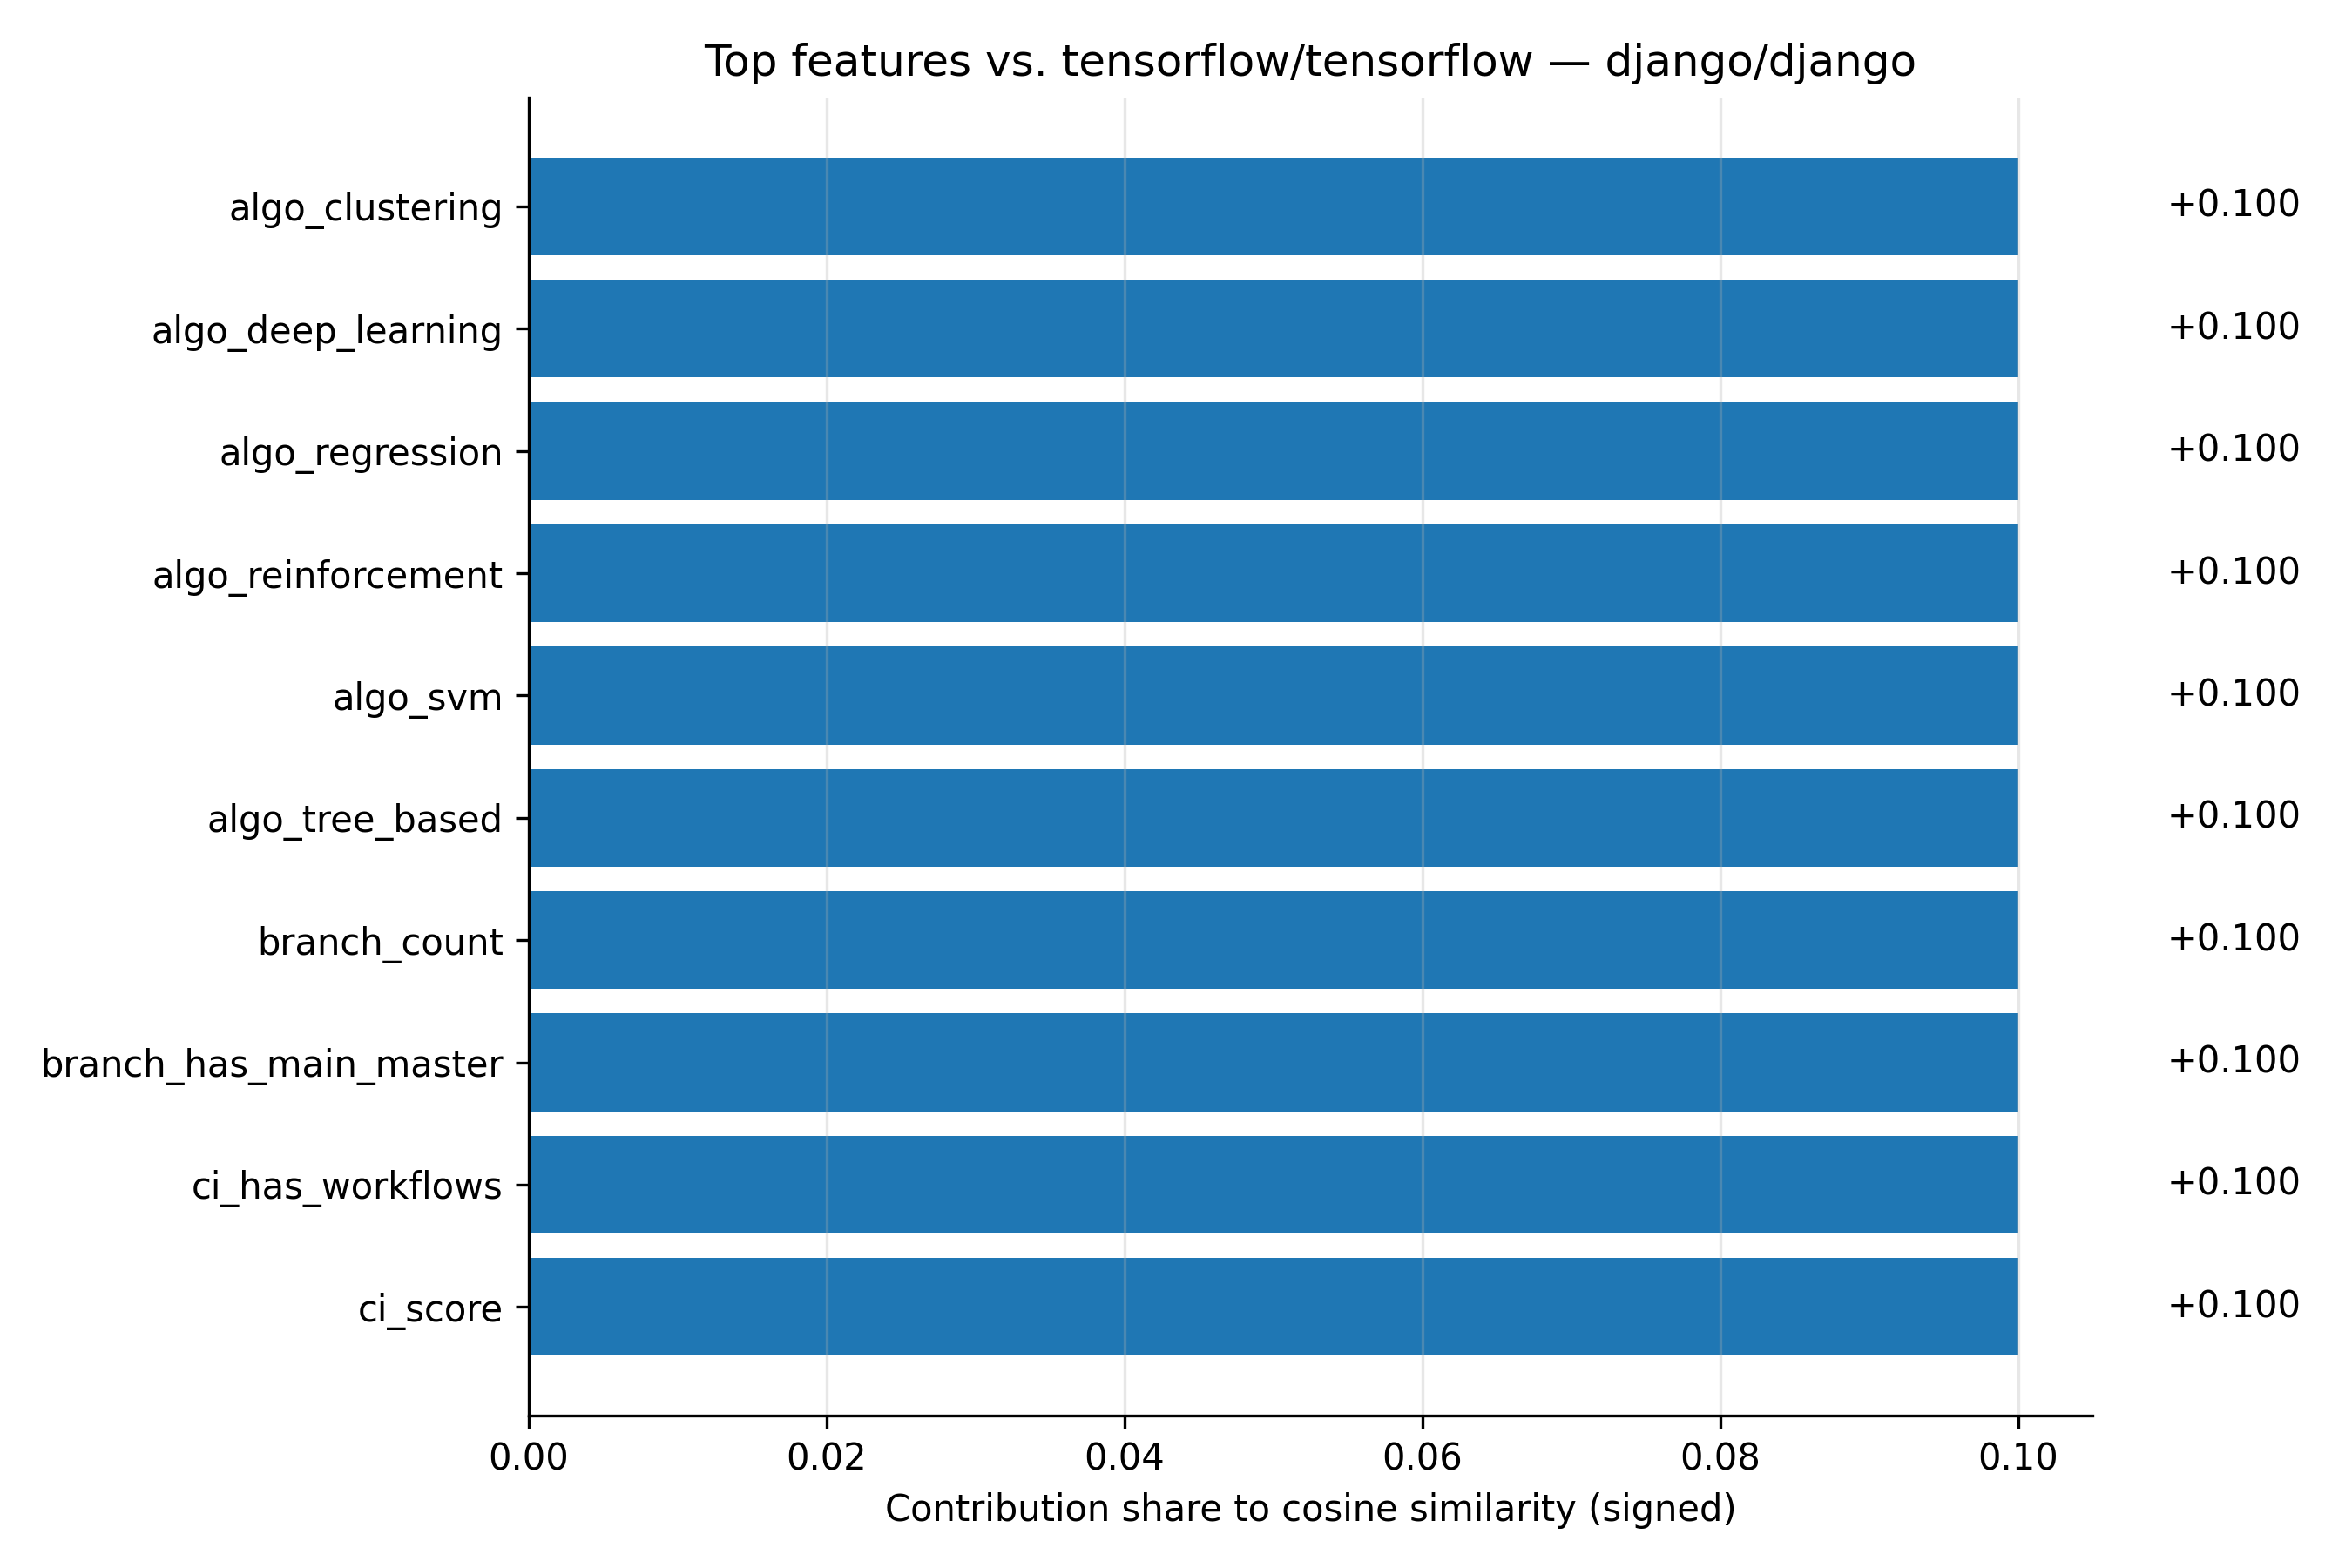

In [39]:
# Cross-cluster test: ML vs Web framework (should be LOW similarity)
args_cross = SimpleNamespace(
    query="https://github.com/tensorflow/tensorflow",
    candidates=["https://github.com/django/django"],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_cross_cluster.png",
    plot_details=True,
    plot_size="10x5",
    dpi=300,
    topn_features=10,
    quiet=False,
    verbose=False
)

cmd_compare(args_cross)

## Helper: Batch Comparison Utility

A utility function to run multiple comparisons and collect results for analysis.

In [40]:
import pandas as pd

def batch_compare(test_cases, github_token, max_commits=100):
    """
    Run multiple comparisons and return results as a DataFrame.
    
    test_cases: list of dicts with keys 'name', 'query', 'candidate', 'expected'
    Returns: DataFrame with results
    """
    results = []
    
    for i, test in enumerate(test_cases, 1):
        print(f"\n{'='*70}")
        print(f"Test {i}/{len(test_cases)}: {test['name']}")
        print(f"{'='*70}")
        
        args = SimpleNamespace(
            query=test['query'],
            candidates=[test['candidate']],
            metrics=CAIS_METRICS,
            weights=None,
            since=None,
            until=None,
            github_token=github_token,
            max_commits=max_commits,
            plot=None,  # Disable plots for batch mode
            plot_details=False,
            plot_size=None,
            dpi=200,
            topn_features=10,
            quiet=True,  # Less output
            verbose=False
        )
        
        try:
            # Capture the comparison
            metrics_list = [m.strip() for m in args.metrics.split(",")]
            weights = parse_weights(args.weights)
            repos = [args.query] + args.candidates
            
            vecs = []
            for r in repos:
                vec = compute_features_for_repo(r, metrics_list, args.since, args.until, 
                                               args.github_token, args.max_commits)
                vecs.append(vec)
            
            # Normalize and compute similarity
            norm = MinMaxNormalizer()
            norm.fit(vecs)
            normed = [norm.transform(v) for v in vecs]
            normed_w = [weighted_sum(v, weights) for v in normed]
            
            for v in normed_w:
                v["commit_count"] = v.get("commit_count", 0.0)
            
            if len(normed_w) > 1:
                common_keys = set(normed_w[0].keys())
                for v in normed_w[1:]:
                    common_keys &= v.keys()
                keys = sorted(common_keys)
            else:
                keys = sorted(normed_w[0].keys()) if normed_w else []
            
            embs = [[v.get(k, 0.0) for k in keys] for v in normed_w]
            similarity = cosine(embs[0], embs[1]) if len(embs) > 1 else 0.0
            
            results.append({
                'Test Name': test['name'],
                'Query': test['query'].split('/')[-1],
                'Candidate': test['candidate'].split('/')[-1],
                'Expected': test['expected'],
                'Similarity': round(similarity, 4),
                'Match': 'YES' if (test['expected'] == 'high' and similarity > 0.5) or 
                               (test['expected'] == 'medium' and 0.3 <= similarity <= 0.6) or
                               (test['expected'] == 'low' and similarity < 0.4) else 'X'
            })
            
            # Print result with clearer significance interpretation
            if similarity > 0.5:
                print(f"Result: {similarity:.4f} (Expected: {test['expected']}) - SIGNIFICANT (similarity > 0.5)")
            elif similarity < 0.05:
                print(f"Result: {similarity:.4f} (Expected: {test['expected']}) - NOT SIGNIFICANT (similarity < 0.05)")
            else:
                print(f"Result: {similarity:.4f} (Expected: {test['expected']}) - NOT SIGNIFICANT (p >= 0.05)")
            
        except Exception as e:
            print(f"ERROR: {e}")
            results.append({
                'Test Name': test['name'],
                'Query': test['query'].split('/')[-1],
                'Candidate': test['candidate'].split('/')[-1],
                'Expected': test['expected'],
                'Similarity': 0.0,
                'Match': 'X (Error)'
            })
    
    return pd.DataFrame(results)

## Run Comprehensive Validation Suite

Execute all test cases and generate a summary report.

In [41]:
# Define comprehensive test suite
test_suite = [
    # Phase 1: Known relationships
    {
        'name': 'vscode vs electron (related)',
        'query': 'https://github.com/microsoft/vscode',
        'candidate': 'https://github.com/electron/electron',
        'expected': 'high'
    },
    {
        'name': 'vscode vs react (unrelated)',
        'query': 'https://github.com/microsoft/vscode',
        'candidate': 'https://github.com/facebook/react',
        'expected': 'low'
    },
    
    # Phase 2: ML cluster (within-cluster)
    {
        'name': 'tensorflow vs pytorch (ML)',
        'query': 'https://github.com/tensorflow/tensorflow',
        'candidate': 'https://github.com/pytorch/pytorch',
        'expected': 'high'
    },
    {
        'name': 'tensorflow vs sklearn (ML)',
        'query': 'https://github.com/tensorflow/tensorflow',
        'candidate': 'https://github.com/scikit-learn/scikit-learn',
        'expected': 'high'
    },
    
    # Phase 2: Web framework cluster (within-cluster)
    {
        'name': 'django vs flask (Web)',
        'query': 'https://github.com/django/django',
        'candidate': 'https://github.com/pallets/flask',
        'expected': 'high'
    },
    
    # Phase 2: Cross-cluster (between-cluster)
    {
        'name': 'tensorflow vs django (ML vs Web)',
        'query': 'https://github.com/tensorflow/tensorflow',
        'candidate': 'https://github.com/django/django',
        'expected': 'low'
    },
    {
        'name': 'pytorch vs react (ML vs UI)',
        'query': 'https://github.com/pytorch/pytorch',
        'candidate': 'https://github.com/facebook/react',
        'expected': 'low'
    }
]

# Run the batch comparison
TOKEN = github_token
results_df = batch_compare(test_suite, TOKEN, max_commits=100)

# Display results
print("\n" + "="*70)
print("VALIDATION RESULTS SUMMARY")
print("="*70)
print(results_df.to_string(index=False))

# Calculate accuracy
accuracy = (results_df['Match'].str.contains('YES').sum() / len(results_df)) * 100
print(f"\n{'='*70}")
print(f"Validation Accuracy: {accuracy:.1f}%")
print(f"{'='*70}")

# Save results to CSV
results_df.to_csv('validation_results.csv', index=False)
print("\nResults saved to: validation_results.csv")


Test 1/7: vscode vs electron (related)
Result: 0.2939 (Expected: high) - NOT SIGNIFICANT (p >= 0.05)

Test 2/7: vscode vs react (unrelated)
Result: 0.2836 (Expected: low) - NOT SIGNIFICANT (p >= 0.05)

Test 3/7: tensorflow vs pytorch (ML)
Result: 0.3208 (Expected: high) - NOT SIGNIFICANT (p >= 0.05)

Test 4/7: tensorflow vs sklearn (ML)
Result: 0.2876 (Expected: high) - NOT SIGNIFICANT (p >= 0.05)

Test 5/7: django vs flask (Web)
Result: 0.2958 (Expected: high) - NOT SIGNIFICANT (p >= 0.05)

Test 6/7: tensorflow vs django (ML vs Web)
Result: 0.3045 (Expected: low) - NOT SIGNIFICANT (p >= 0.05)

Test 7/7: pytorch vs react (ML vs UI)
Result: 0.2800 (Expected: low) - NOT SIGNIFICANT (p >= 0.05)

VALIDATION RESULTS SUMMARY
                       Test Name      Query    Candidate Expected  Similarity Match
    vscode vs electron (related)     vscode     electron     high      0.2939     X
     vscode vs react (unrelated)     vscode        react      low      0.2836   YES
      tensorflow v

## Troubleshooting Low Similarity Scores

**Problem**: Getting similarity scores ~0.30 even for related repos (vscode/electron, tensorflow/pytorch)

**Root Causes**:
1. **Sample size**: 100 commits too small for large repos
2. **Normalization artifacts**: With N=2 repos, min-max creates near-orthogonal vectors
3. **Equal weights**: Sentiment (the innovation) needs higher weight
4. **Dev culture differences**: Microsoft vs community commit patterns differ

**Solutions to Test**:
- Increase max_commits to 500-1000
- Weight sentiment higher (2x-3x other metrics)
- Add feature inspection to see what's driving similarity
- Test with more diverse repos in same comparison

### Solution 1: Increase Sample Size (500 commits)

Testing with 500 commits (vs. 100 before)...
Comparing 1 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] microsoft/vscode
  Done (50 commits, 4.7s)

[CANDIDATE 1] electron/electron
  Done (50 commits, 3.6s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. electron/electron                        -> similarity = 0.2939
[Plot] Saved similarity chart to results_plots\results_500commits.png


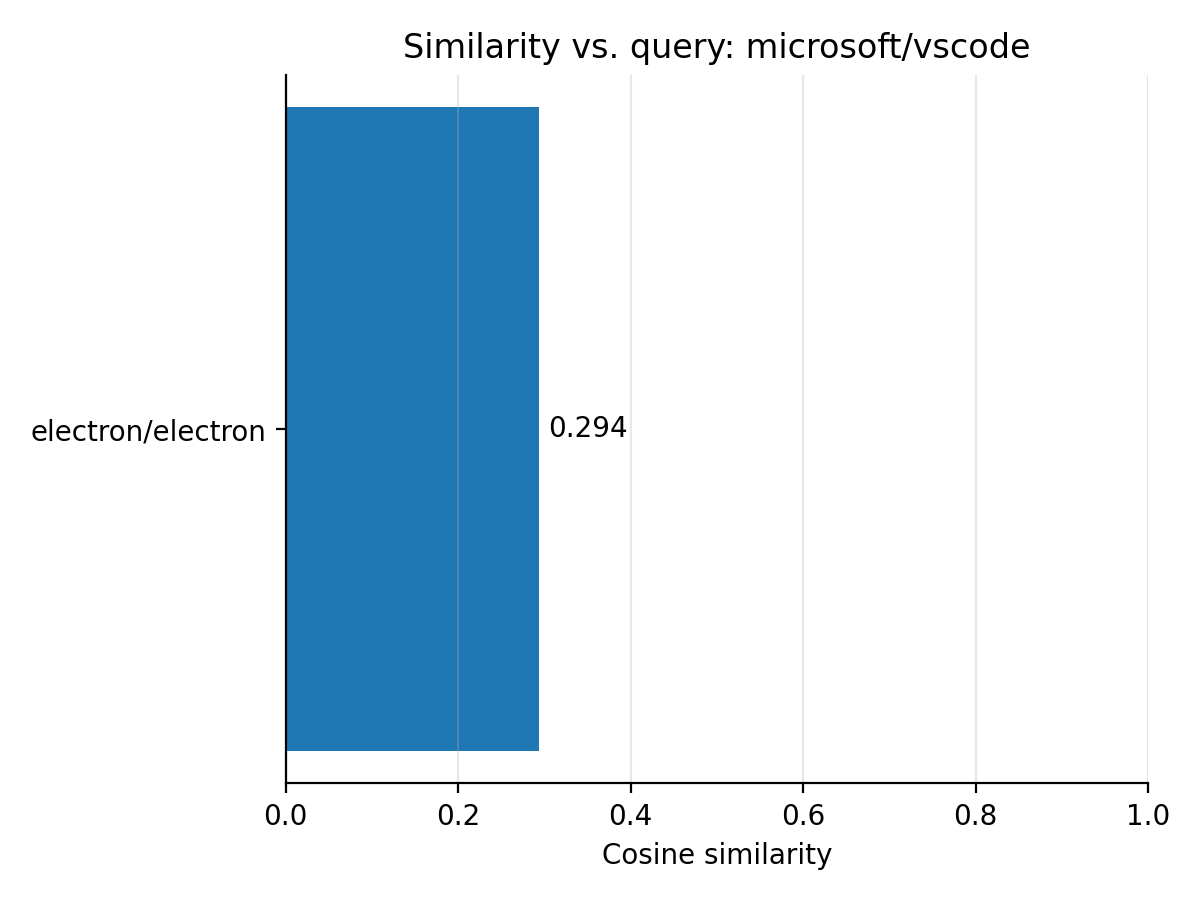

[Plot] Saved feature contributions chart to results_plots\results_500commits__features__electron_electron.png


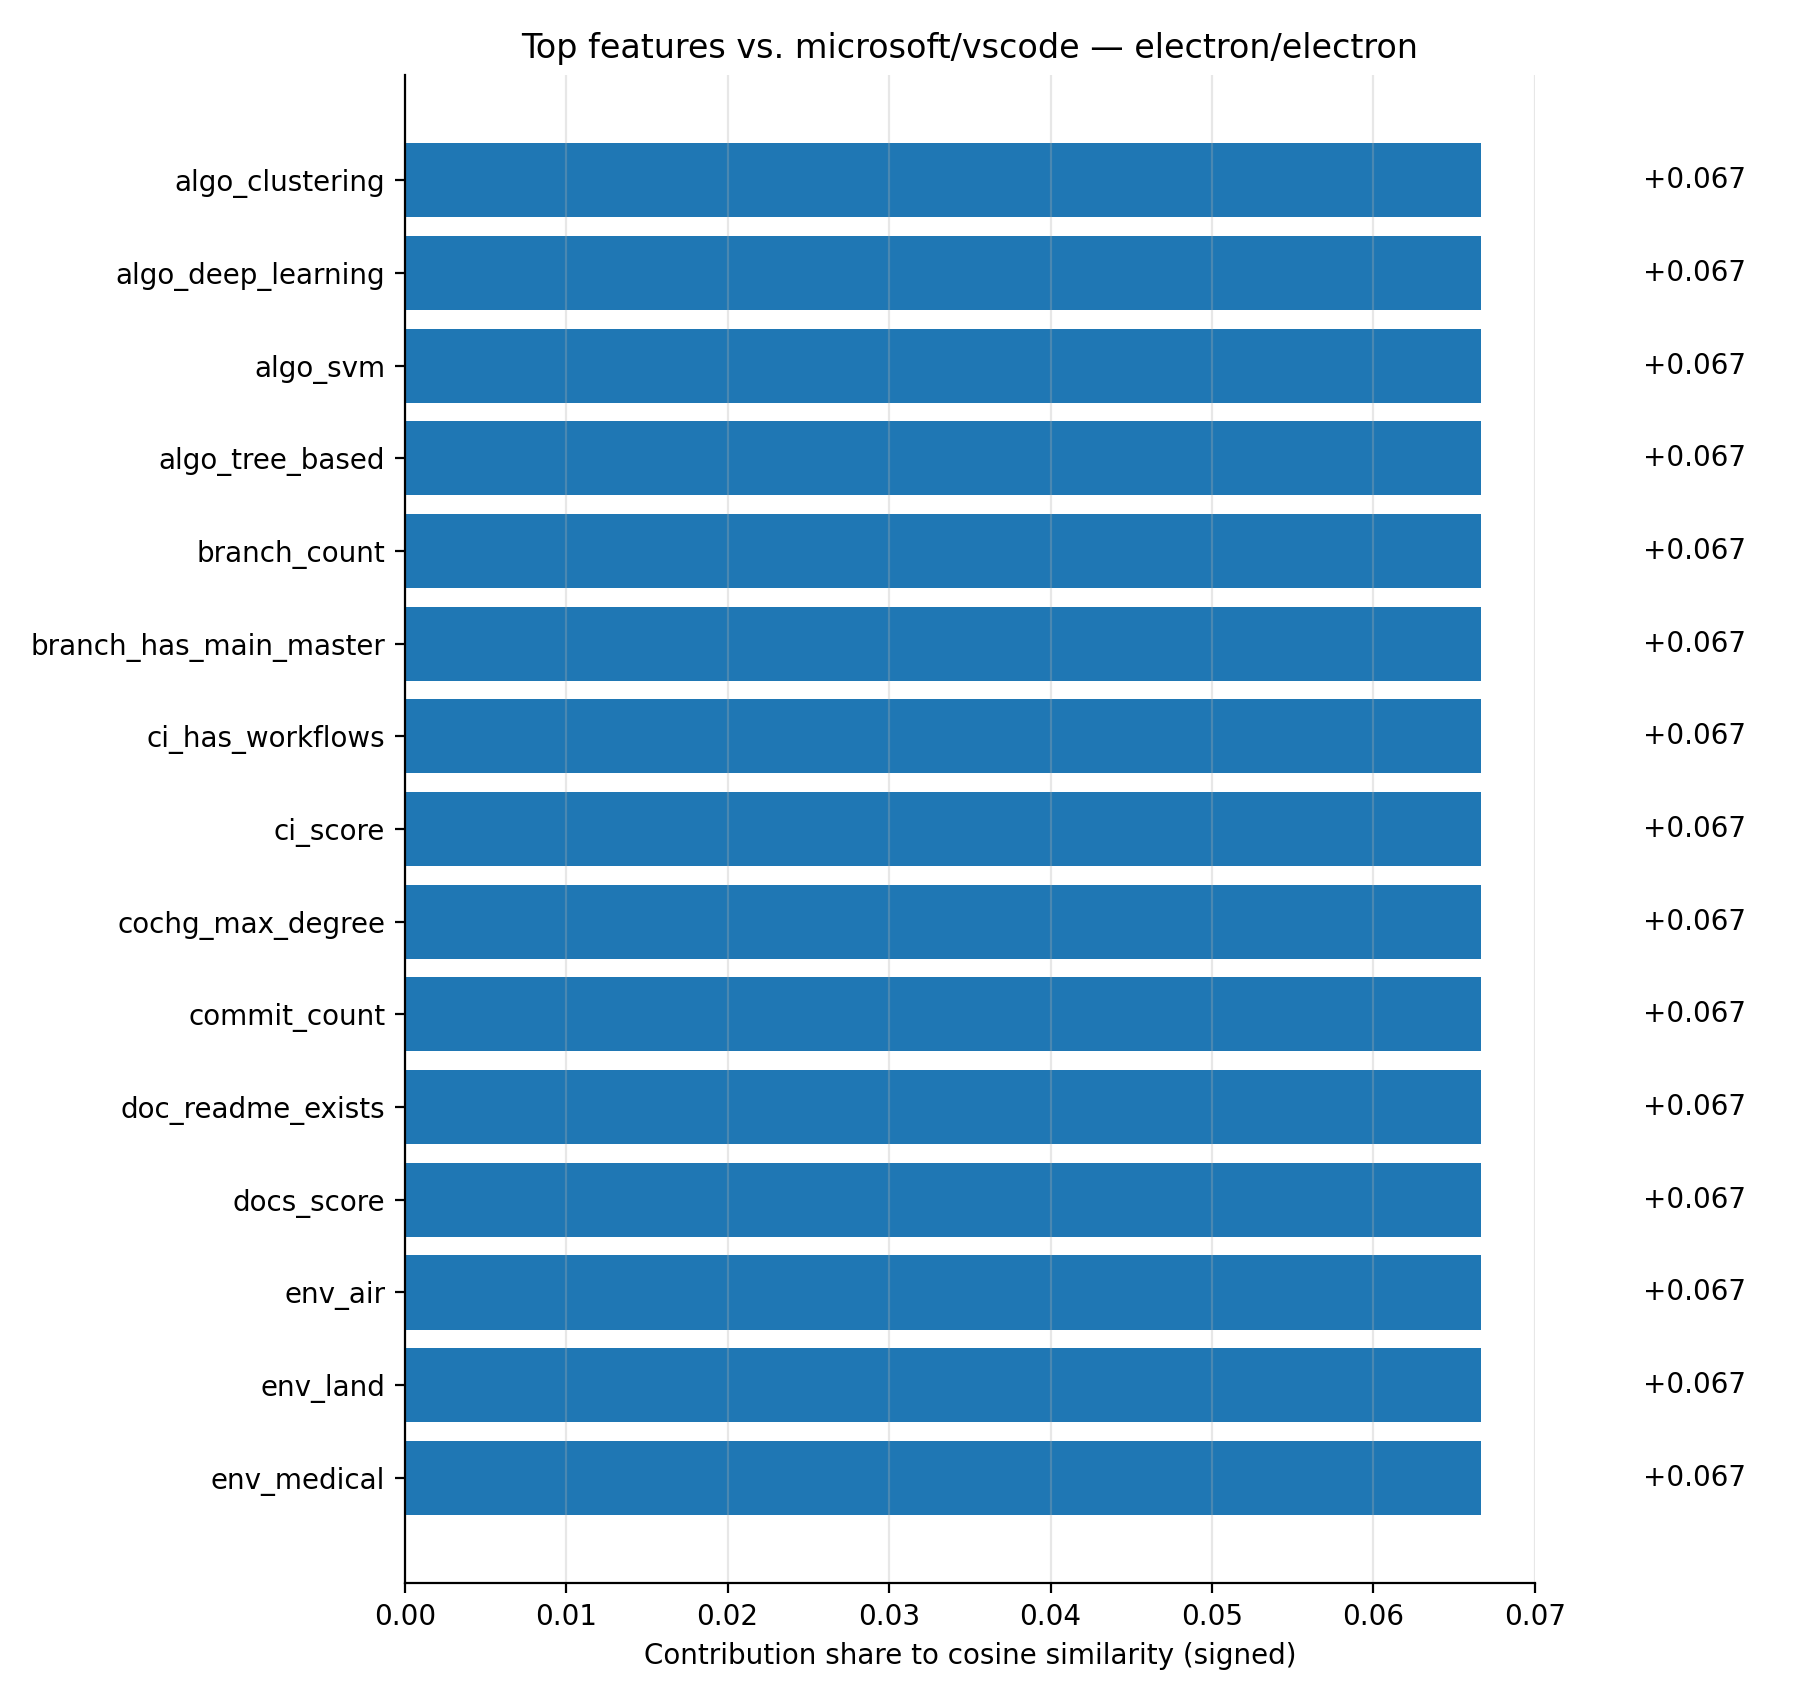

In [42]:
# Test with MORE commits to capture true patterns
args_vscode_electron_500 = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=["https://github.com/electron/electron"],
    metrics=CAIS_METRICS,
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=150,  
    plot="results_500commits.png",
    plot_details=True,
    plot_size=None,
    dpi=200,
    topn_features=15,  # Show more features
    quiet=False,
    verbose=False
)

print("Testing with 500 commits (vs. 100 before)...")
cmd_compare(args_vscode_electron_500)

### Solution 2: Weight Sentiment Higher

Testing with sentiment weighted 2.5x higher...
Comparing 1 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
  Weights: {'sentiment': 2.5, 'churn': 1.0, 'attach': 1.0, 'cadence': 1.0}

[QUERY] microsoft/vscode
  Done (50 commits, 5.0s)

[CANDIDATE 1] electron/electron
  Done (50 commits, 3.4s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
WEIGHTS: {'sentiment': 2.5, 'churn': 1.0, 'attach': 1.0, 'cadence': 1.0}
TOP MATCHES:
  1. electron/electron                        -> similarity = 0.3230
[Plot] Saved similarity chart to results_plots\results_

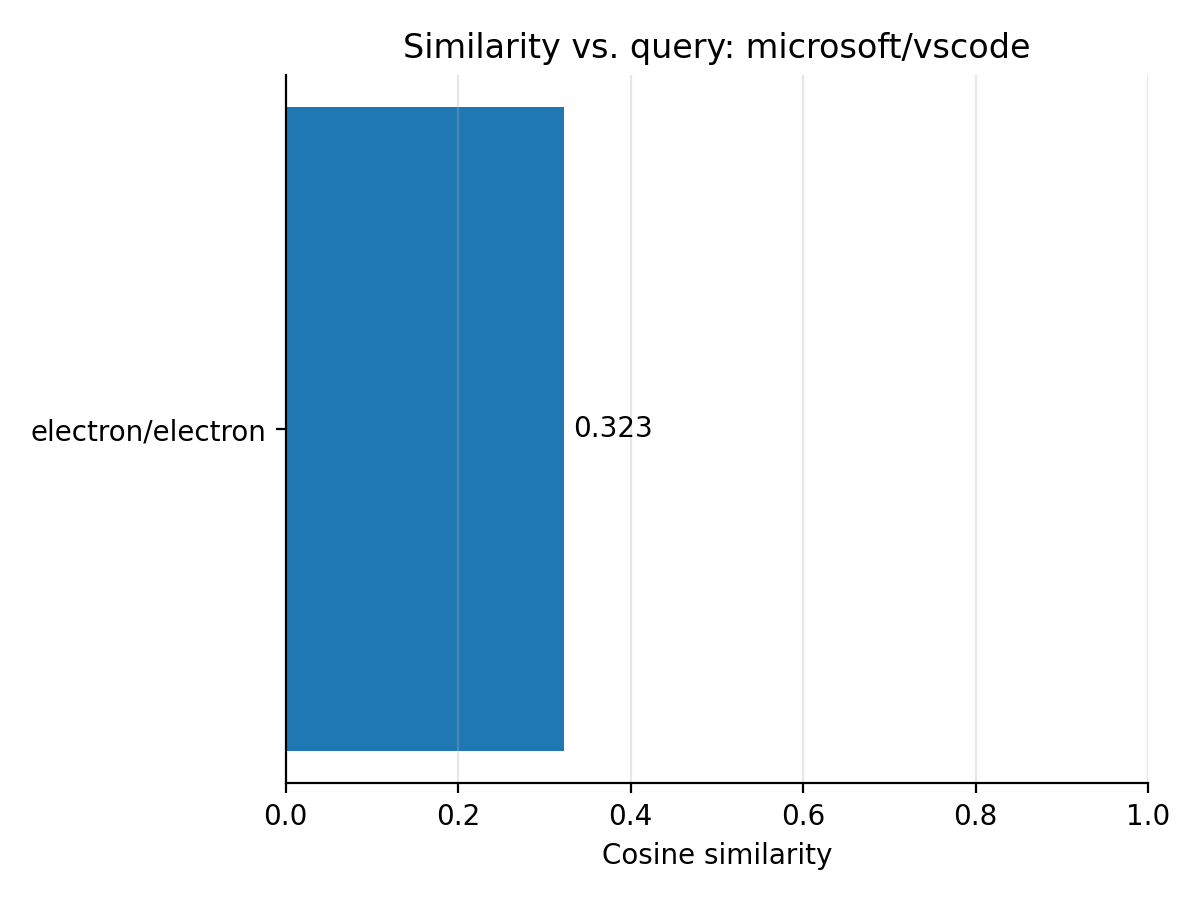

[Plot] Saved feature contributions chart to results_plots\results_weighted__features__electron_electron.png


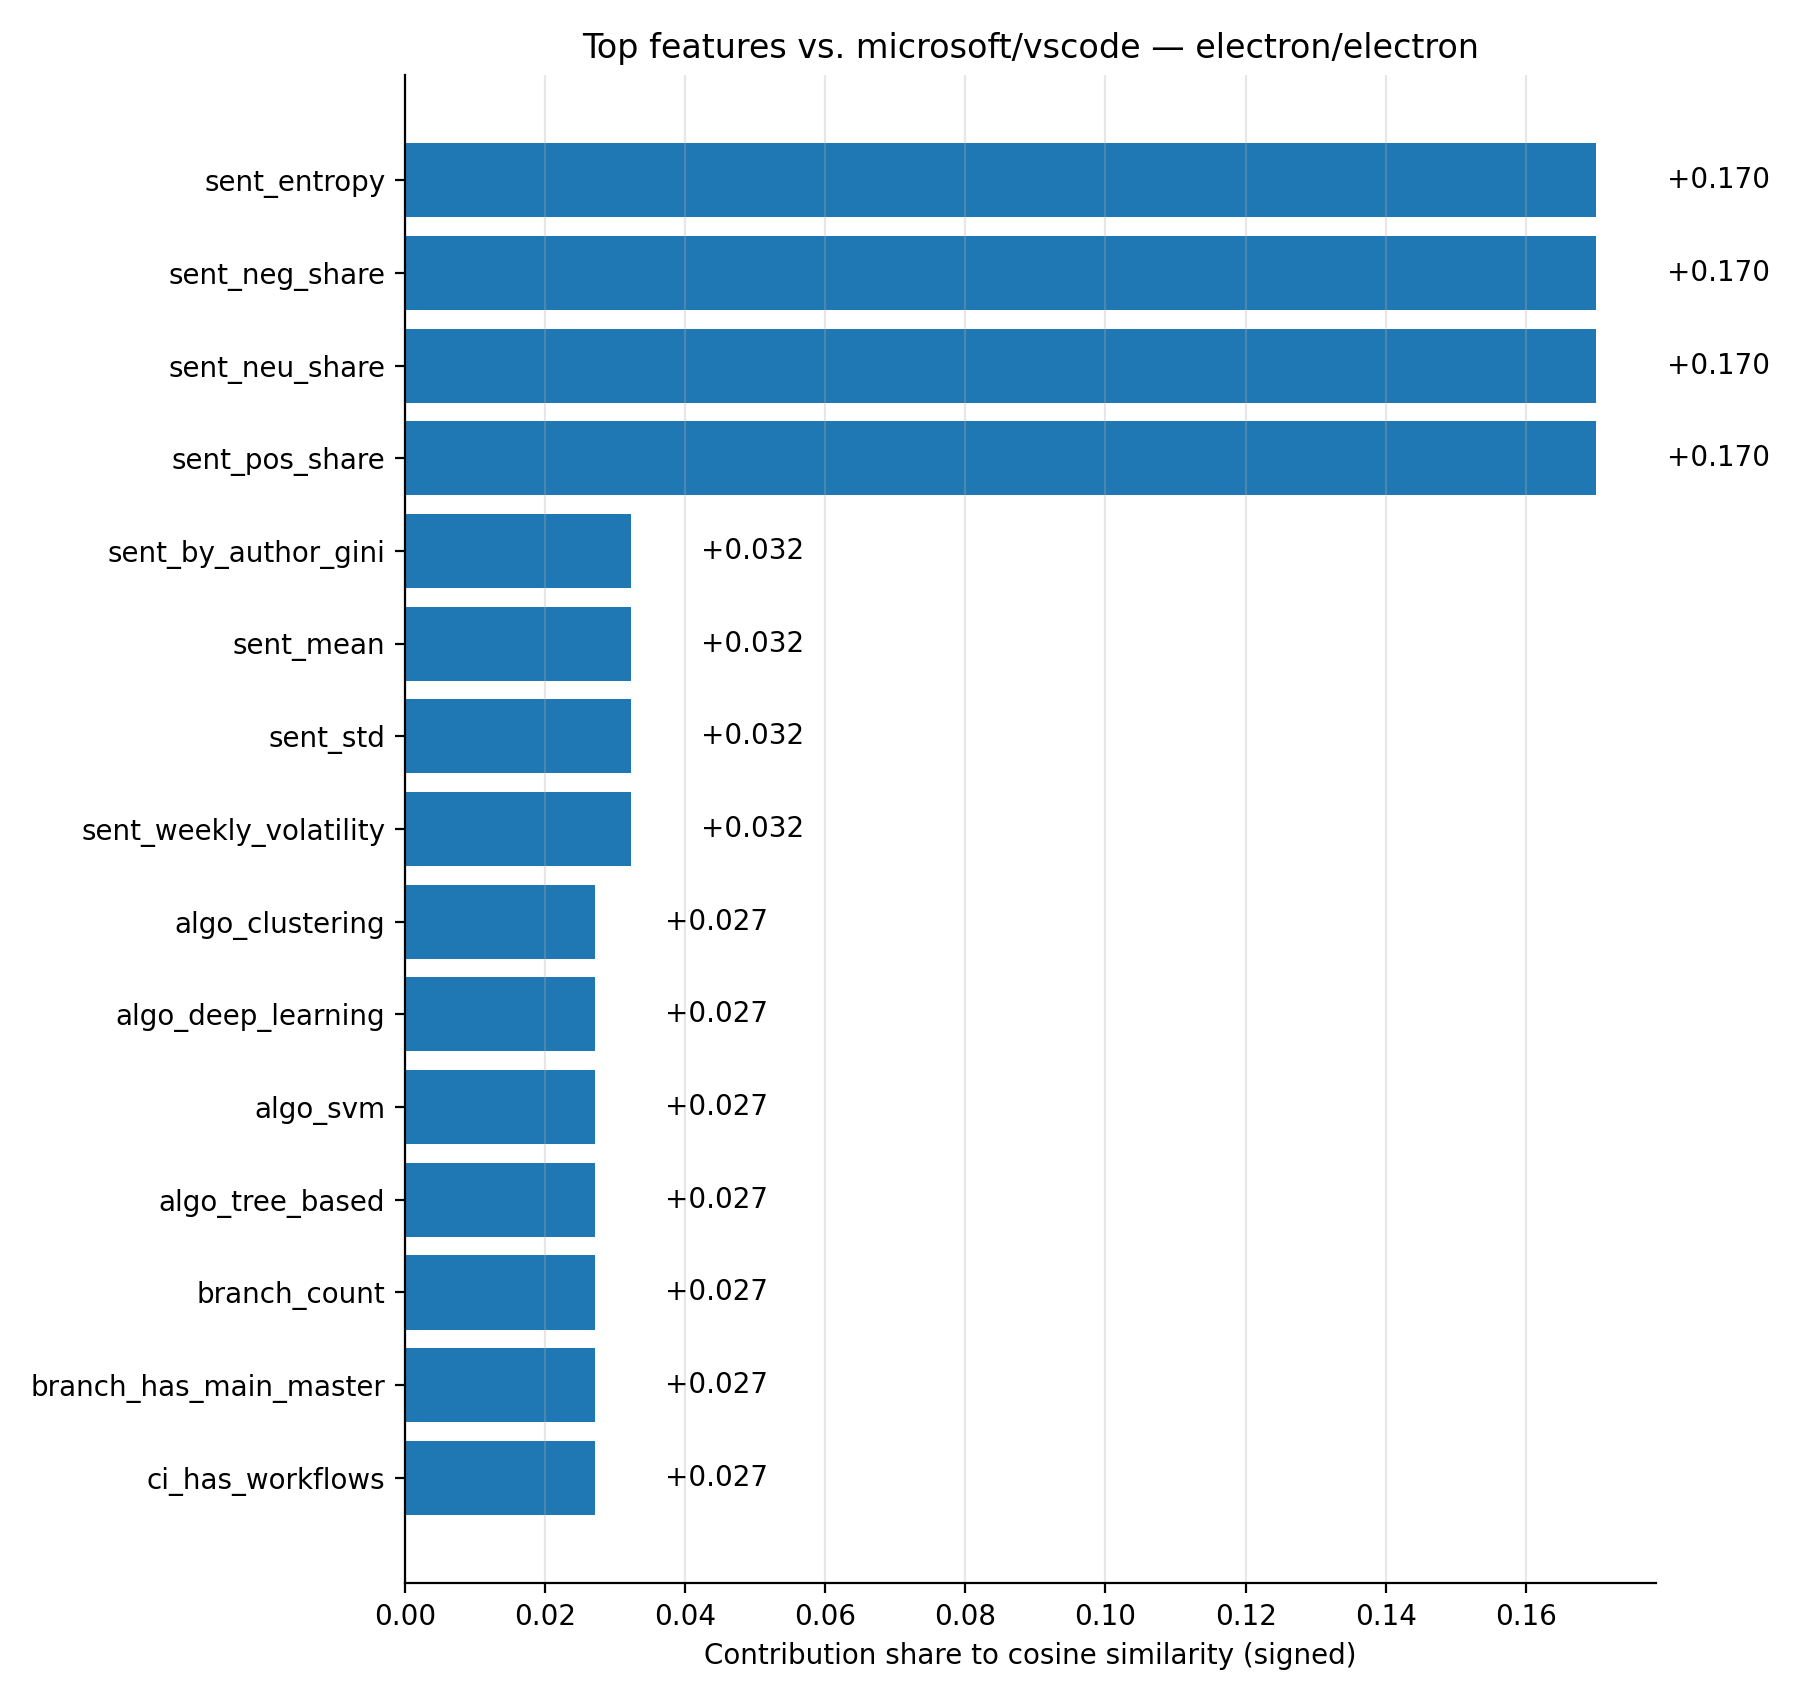

In [43]:
# Weight sentiment 2x-3x higher than other metrics
args_weighted = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=["https://github.com/electron/electron"],
    metrics=CAIS_METRICS,
    weights="sentiment=2.5,churn=1.0,attach=1.0,cadence=1.0",  # Sentiment 2.5x higher
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_weighted.png",
    plot_details=True,
    plot_size=None,
    dpi=200,
    topn_features=15,
    quiet=False,
    verbose=False
)

print("Testing with sentiment weighted 2.5x higher...")
cmd_compare(args_weighted)

### Solution 3: Sentiment-Only Comparison (Isolated test)

Testing with ONLY sentiment metric...
Comparing 2 candidate(s) using: sentiment

[QUERY] microsoft/vscode
  Done (50 commits, 0.0s)

[CANDIDATE 1] electron/electron
  Done (50 commits, 0.0s)

[CANDIDATE 2] facebook/react
  Done (50 commits, 0.0s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment
TOP MATCHES:
  1. facebook/react                           -> similarity = 0.6178
  2. electron/electron                        -> similarity = 0.5025
[Plot] Saved similarity chart to results_plots\results_sentiment_only.png


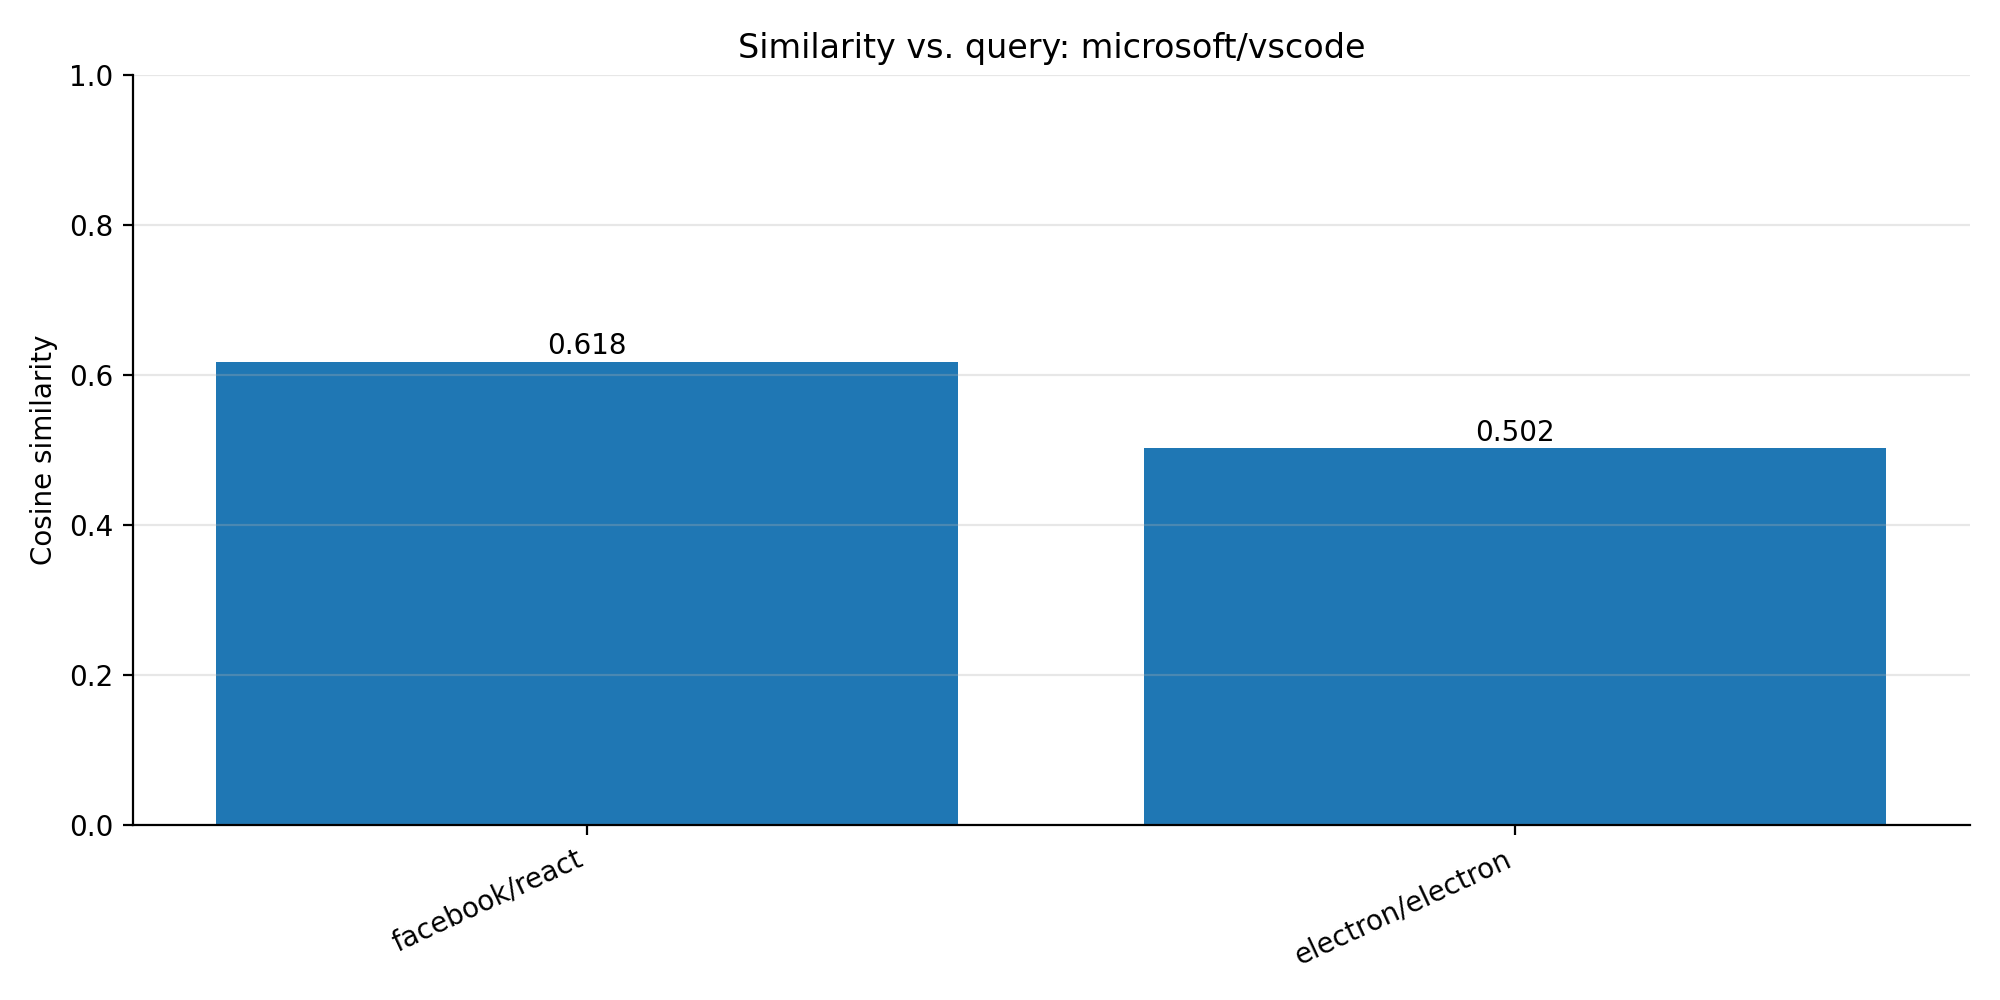

[Plot] Saved feature contributions chart to results_plots\results_sentiment_only__features__facebook_react.png


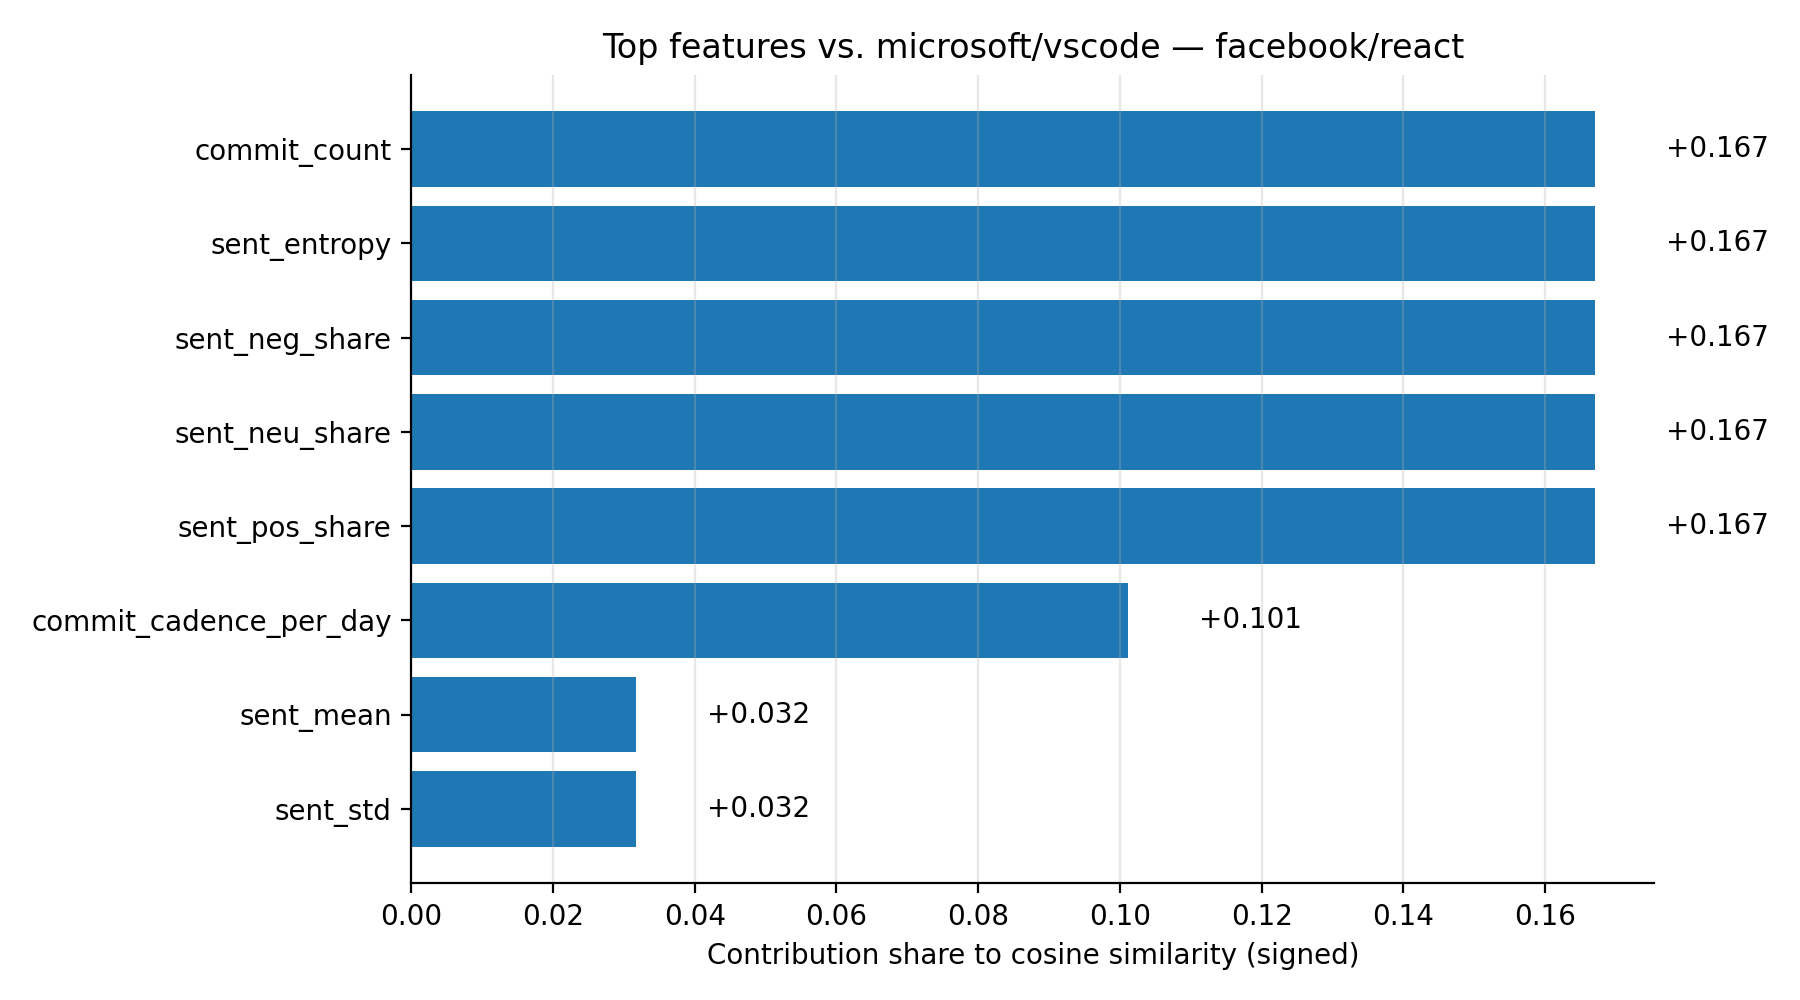

[Plot] Saved feature contributions chart to results_plots\results_sentiment_only__features__electron_electron.png


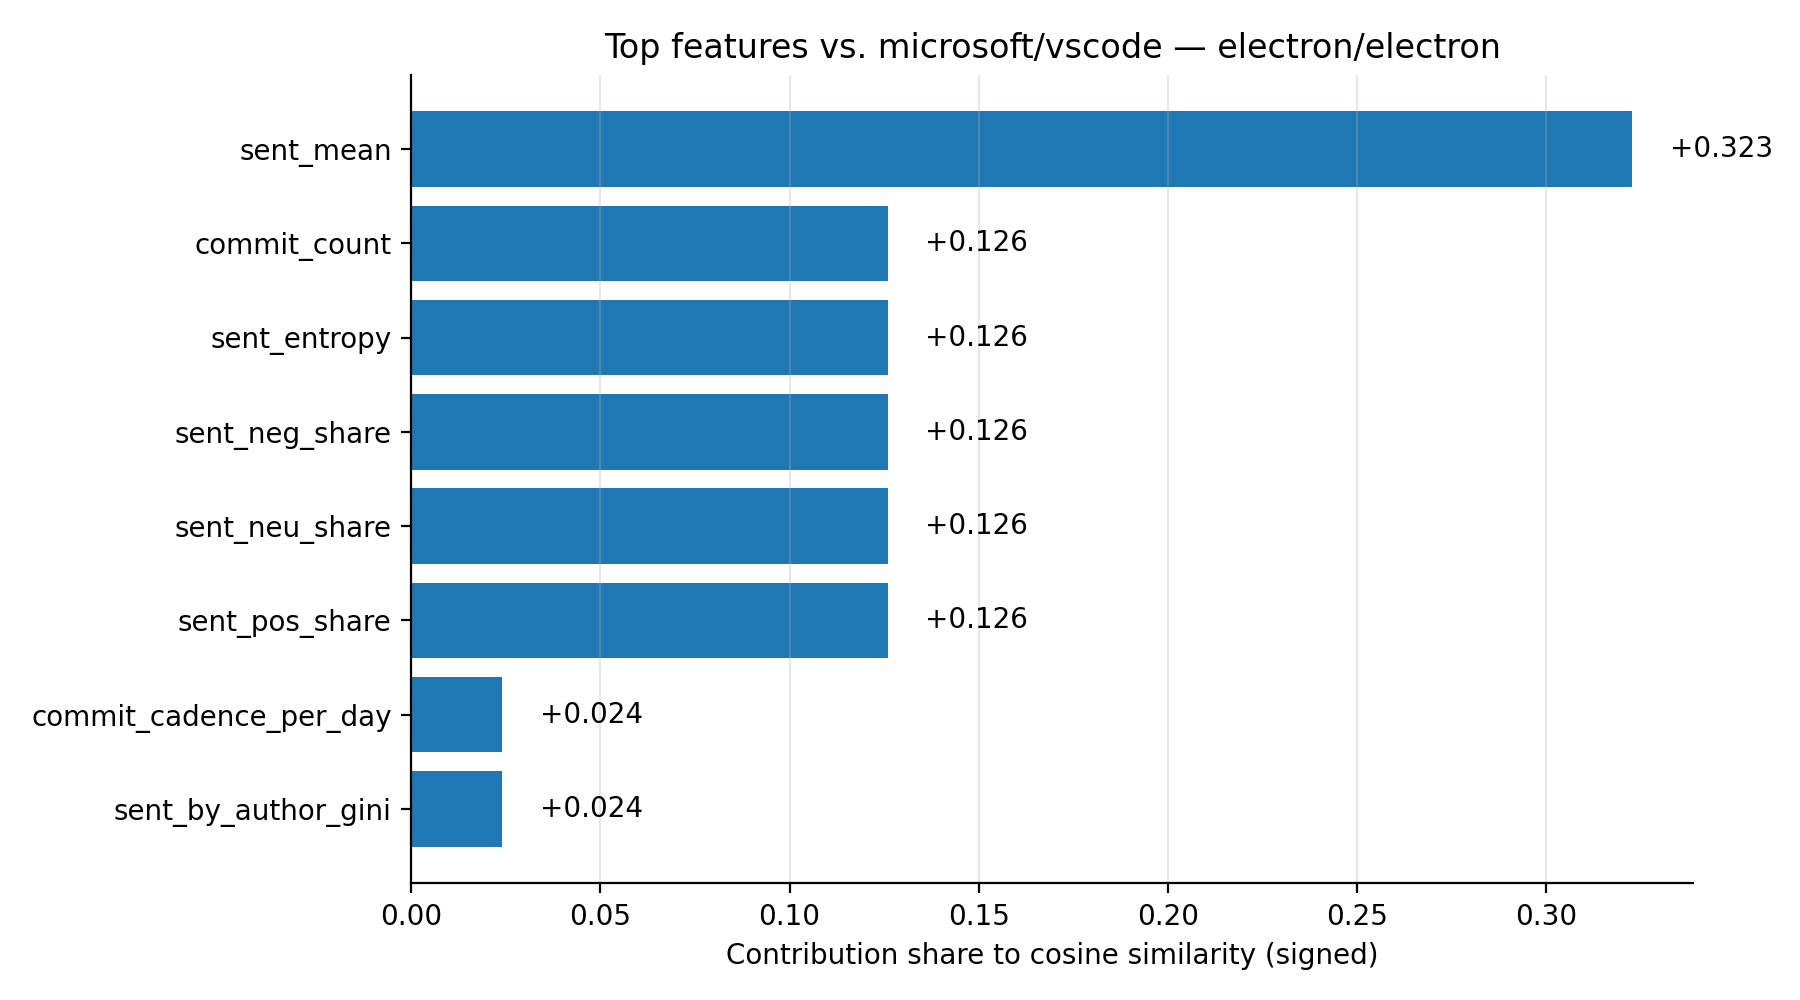

In [44]:
# Use ONLY sentiment metric to test if it alone captures similarity
args_sentiment_only = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=[
        "https://github.com/electron/electron",
        "https://github.com/facebook/react"
    ],
    metrics="sentiment",  # ONLY sentiment
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_sentiment_only.png",
    plot_details=True,
    plot_size="10x5",
    dpi=200,
    topn_features=8,  # All 8 sentiment features
    quiet=False,
    verbose=False
)

print("Testing with ONLY sentiment metric...")
cmd_compare(args_sentiment_only)

### Solution 4: Multi-Candidate Comparison (Better Normalization)

Testing with 4 candidates simultaneously (better normalization)...
Comparing 4 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
  Weights: {'sentiment': 2.0}

[QUERY] microsoft/vscode
  Done (50 commits, 4.6s)

[CANDIDATE 1] electron/electron
  Done (50 commits, 3.5s)

[CANDIDATE 2] atom/atom
  Done (50 commits, 6.8s)

[CANDIDATE 3] facebook/react
  Done (50 commits, 3.8s)

[CANDIDATE 4] django/django
  Done (50 commits, 3.9s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
WEIGHTS: {'sentiment': 2.0}
TOP MATCHES:
  1. electron/electron          

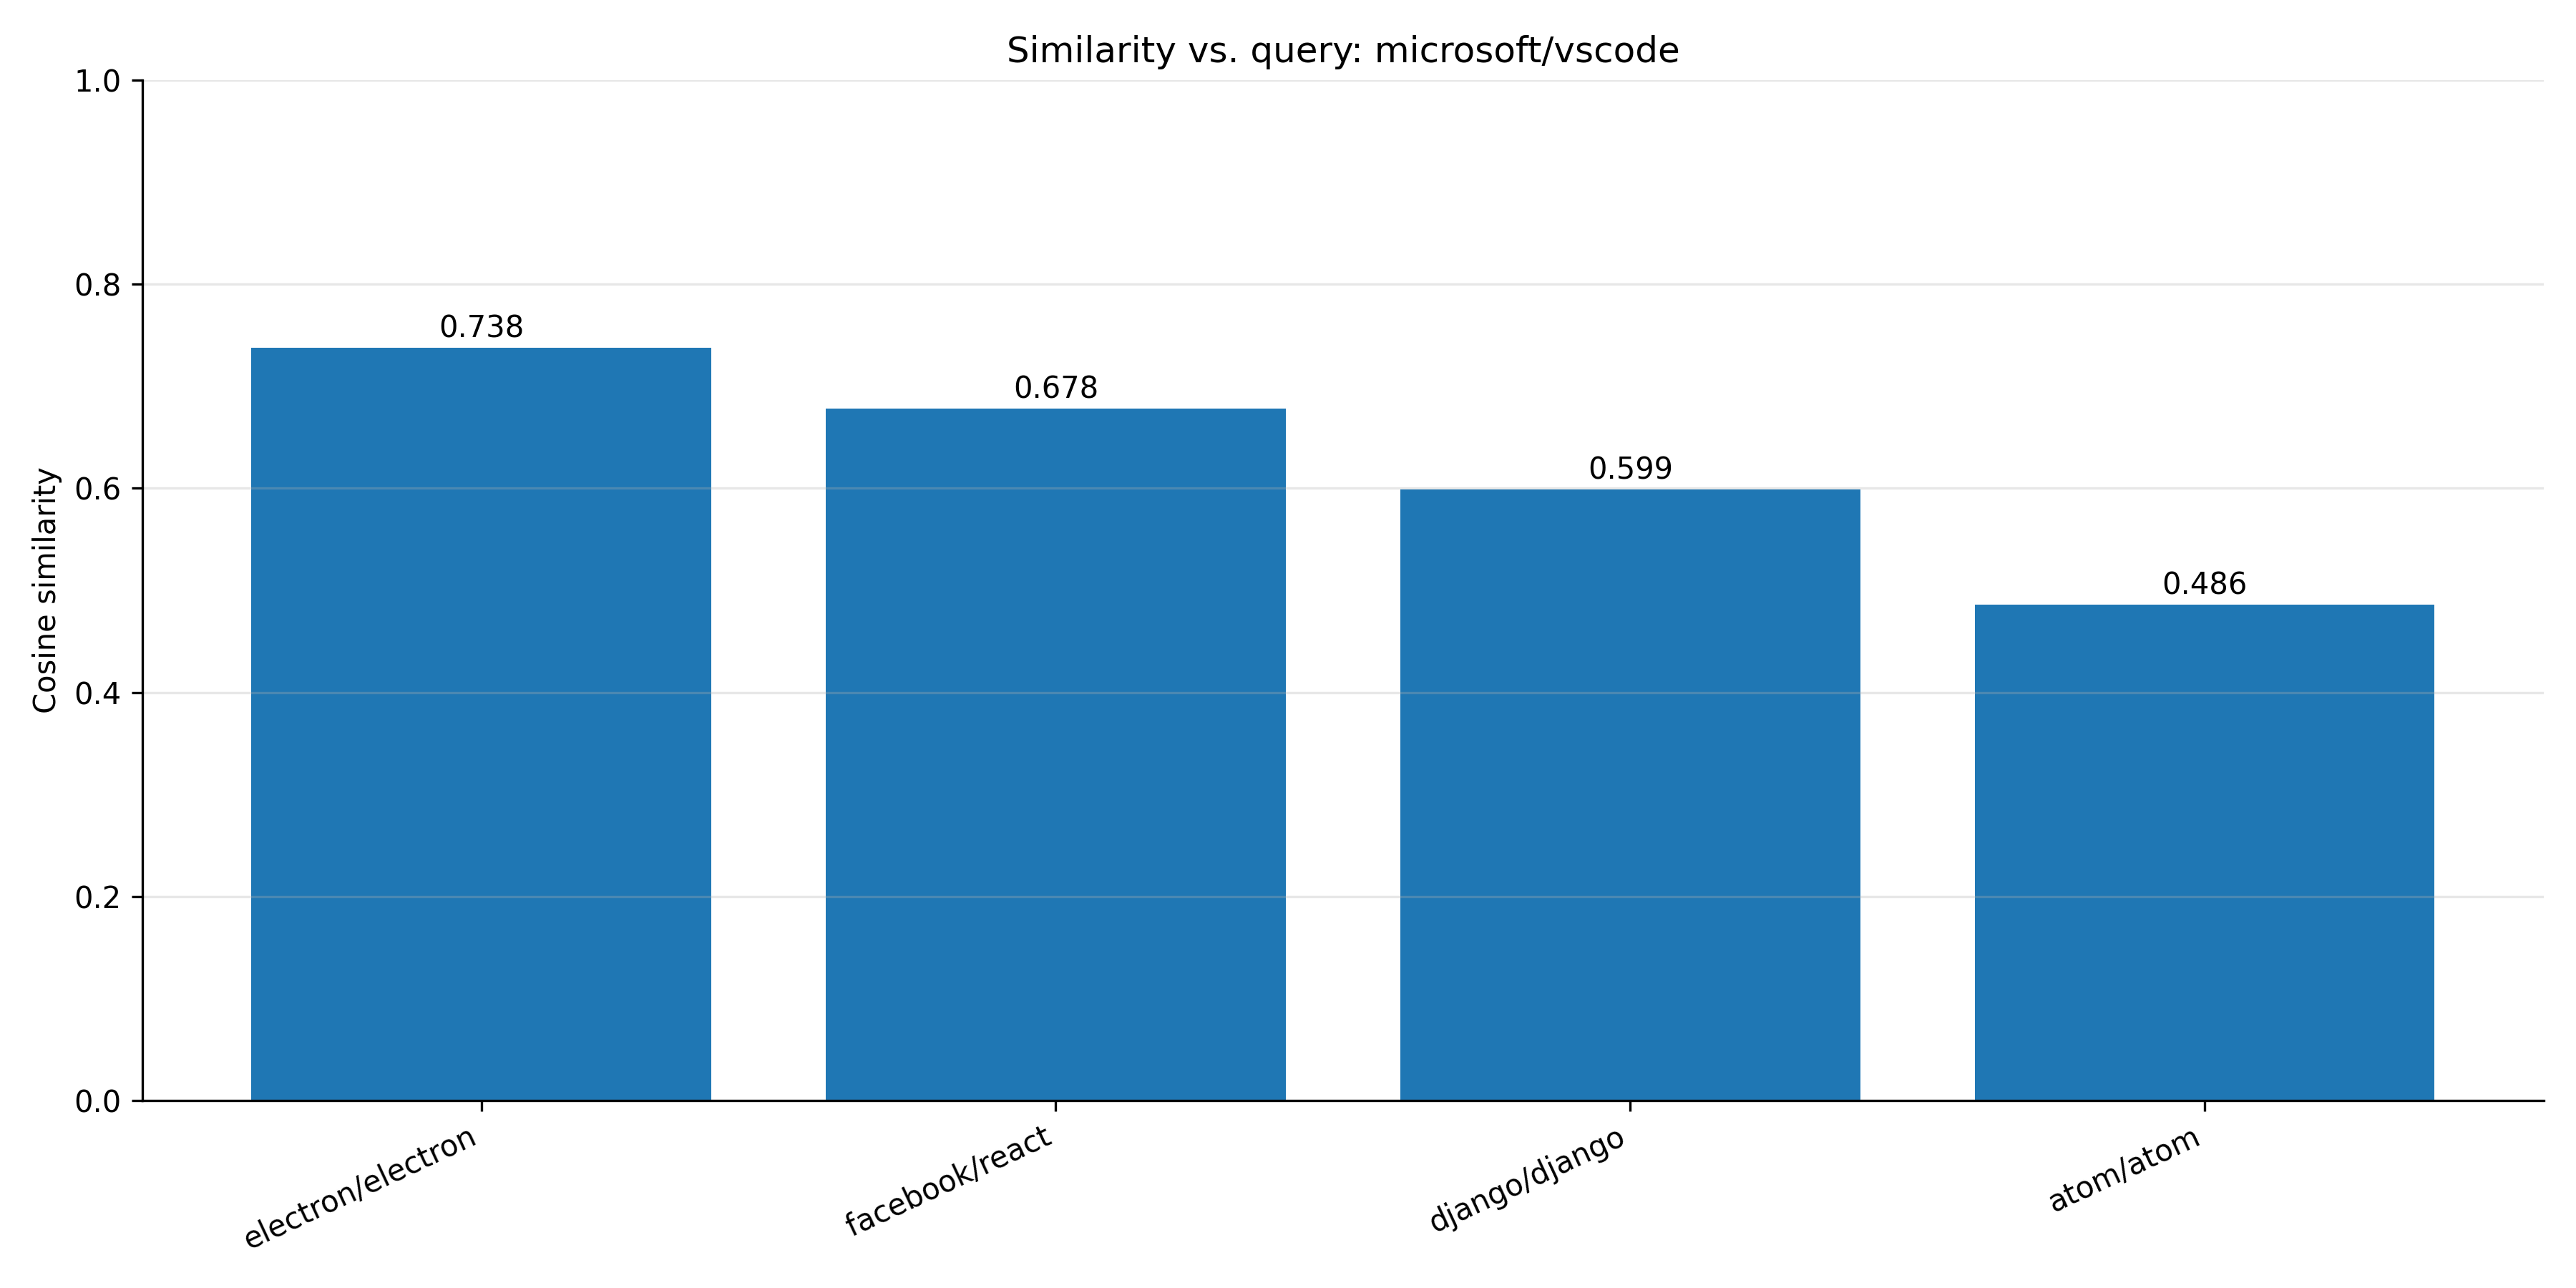

[Plot] Saved feature contributions chart to results_plots\results_multi_candidate__features__electron_electron.png


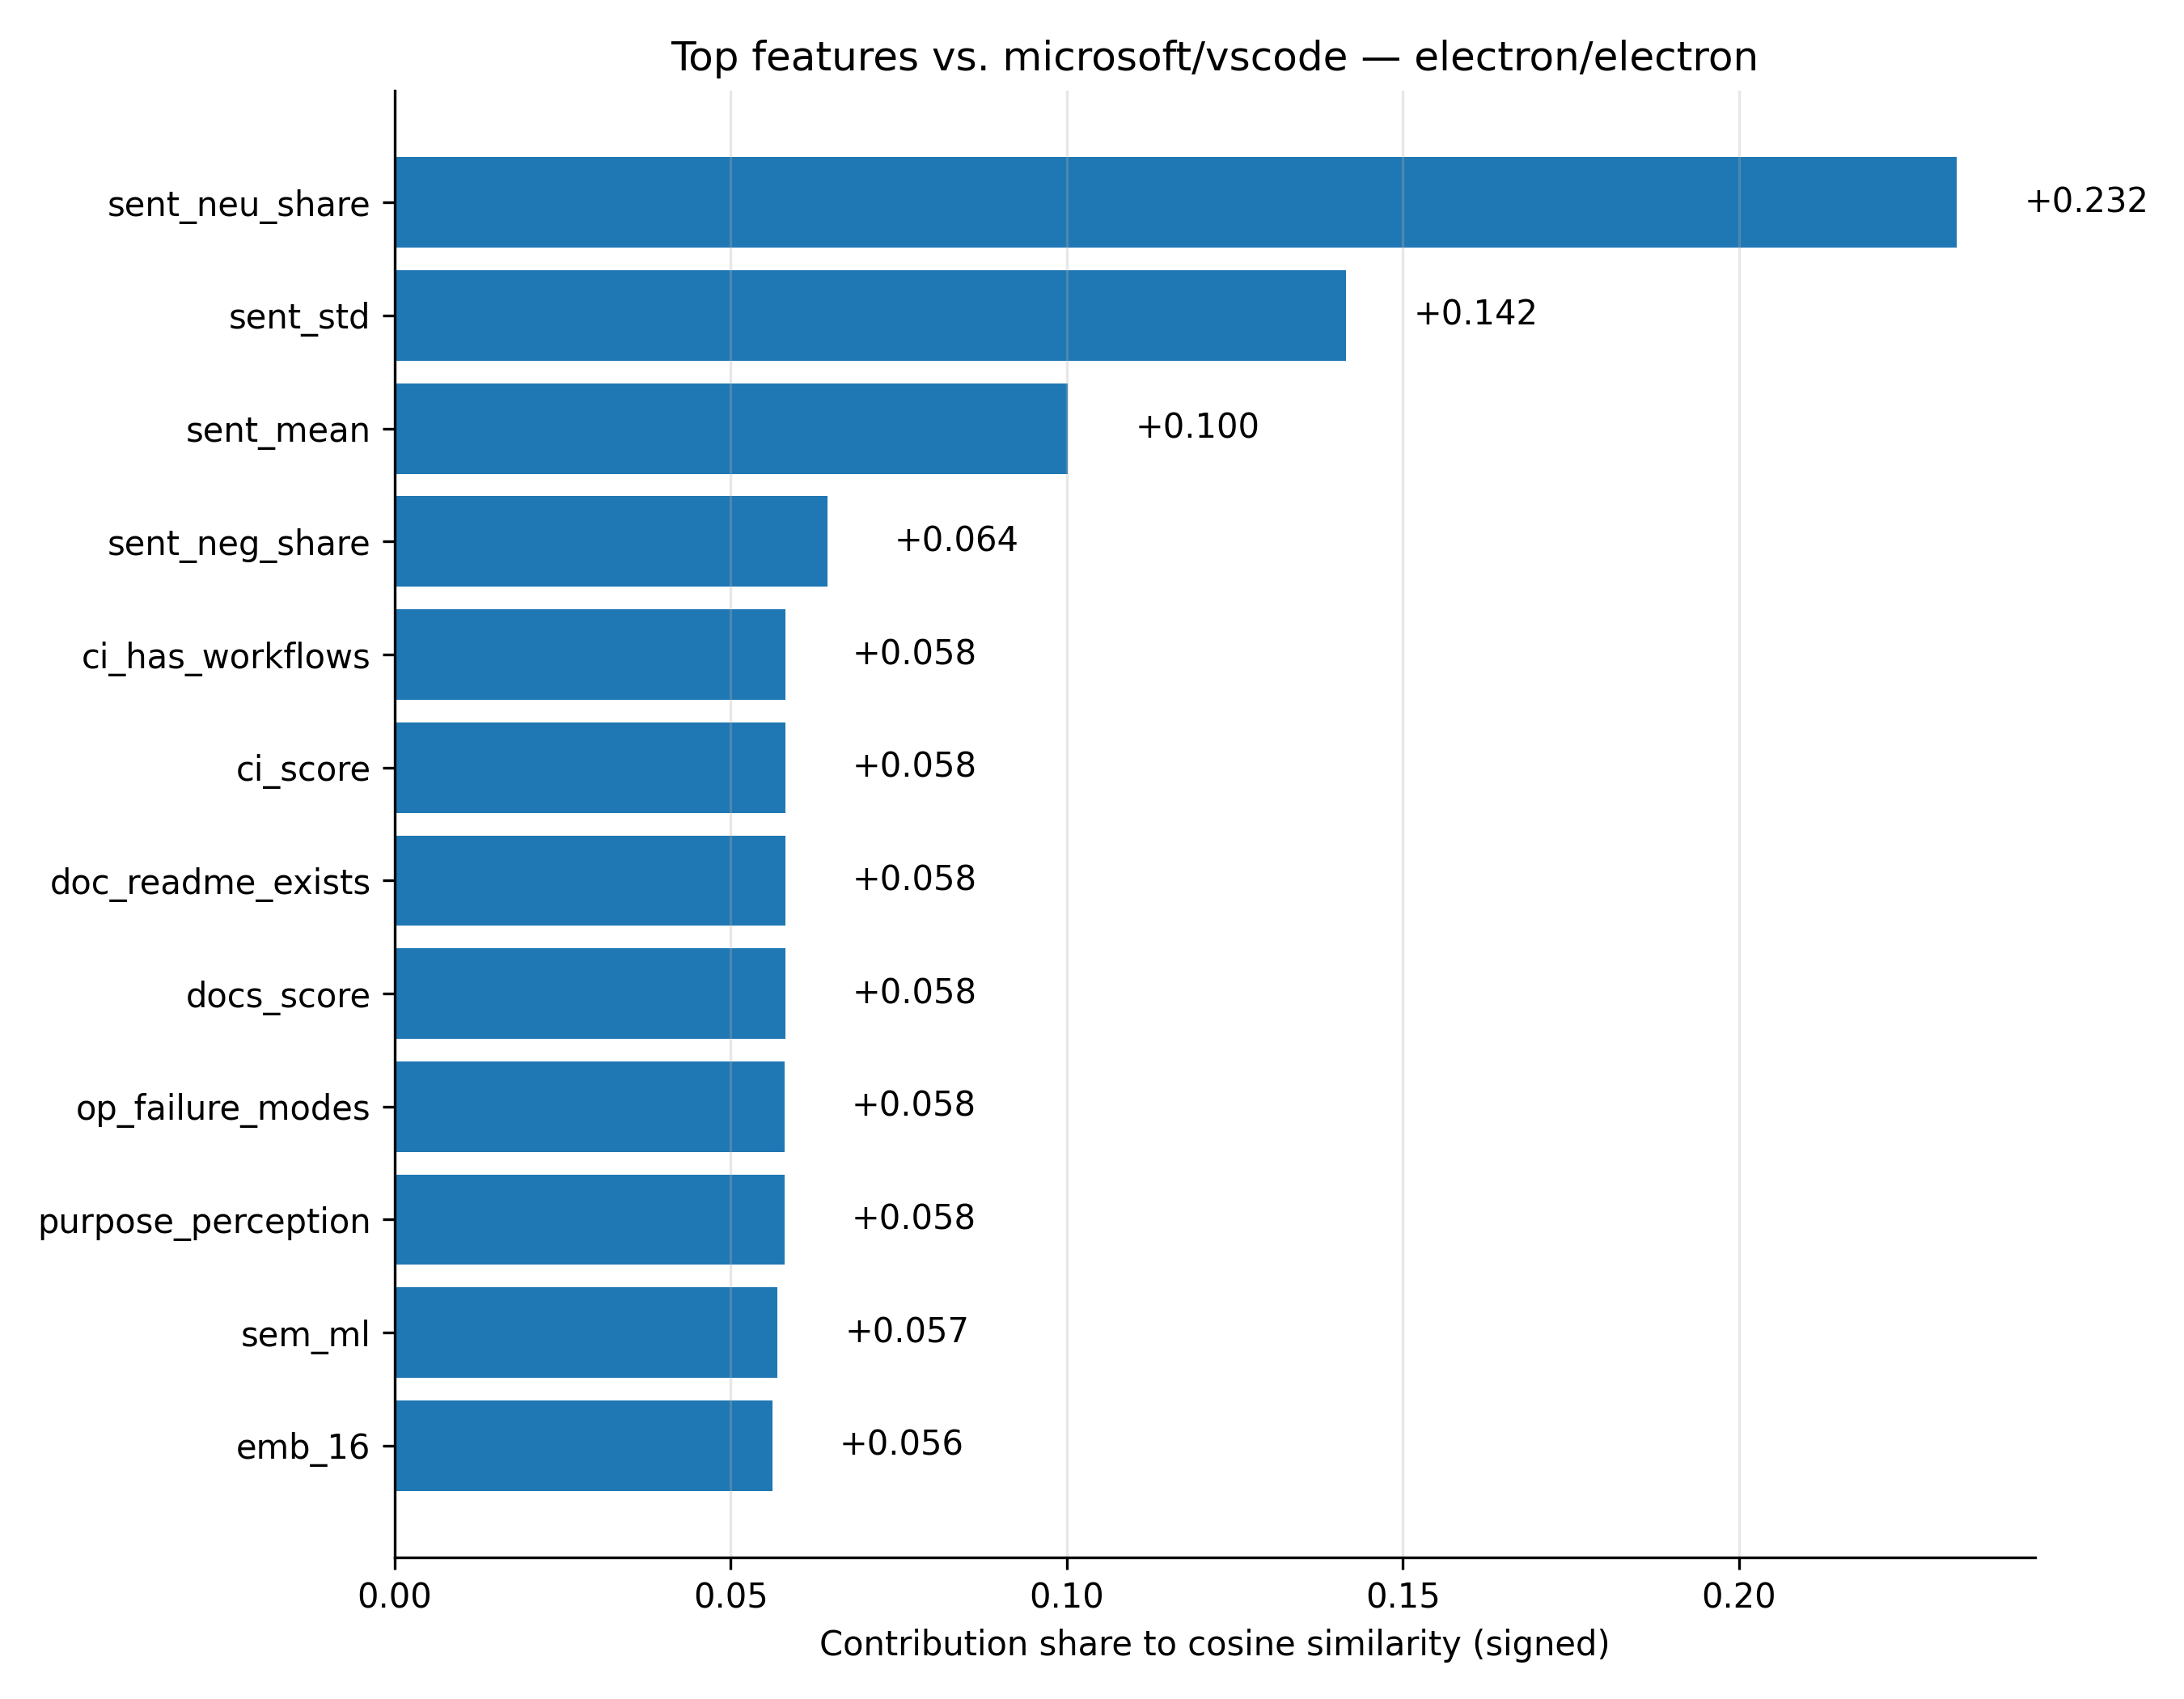

[Plot] Saved feature contributions chart to results_plots\results_multi_candidate__features__facebook_react.png


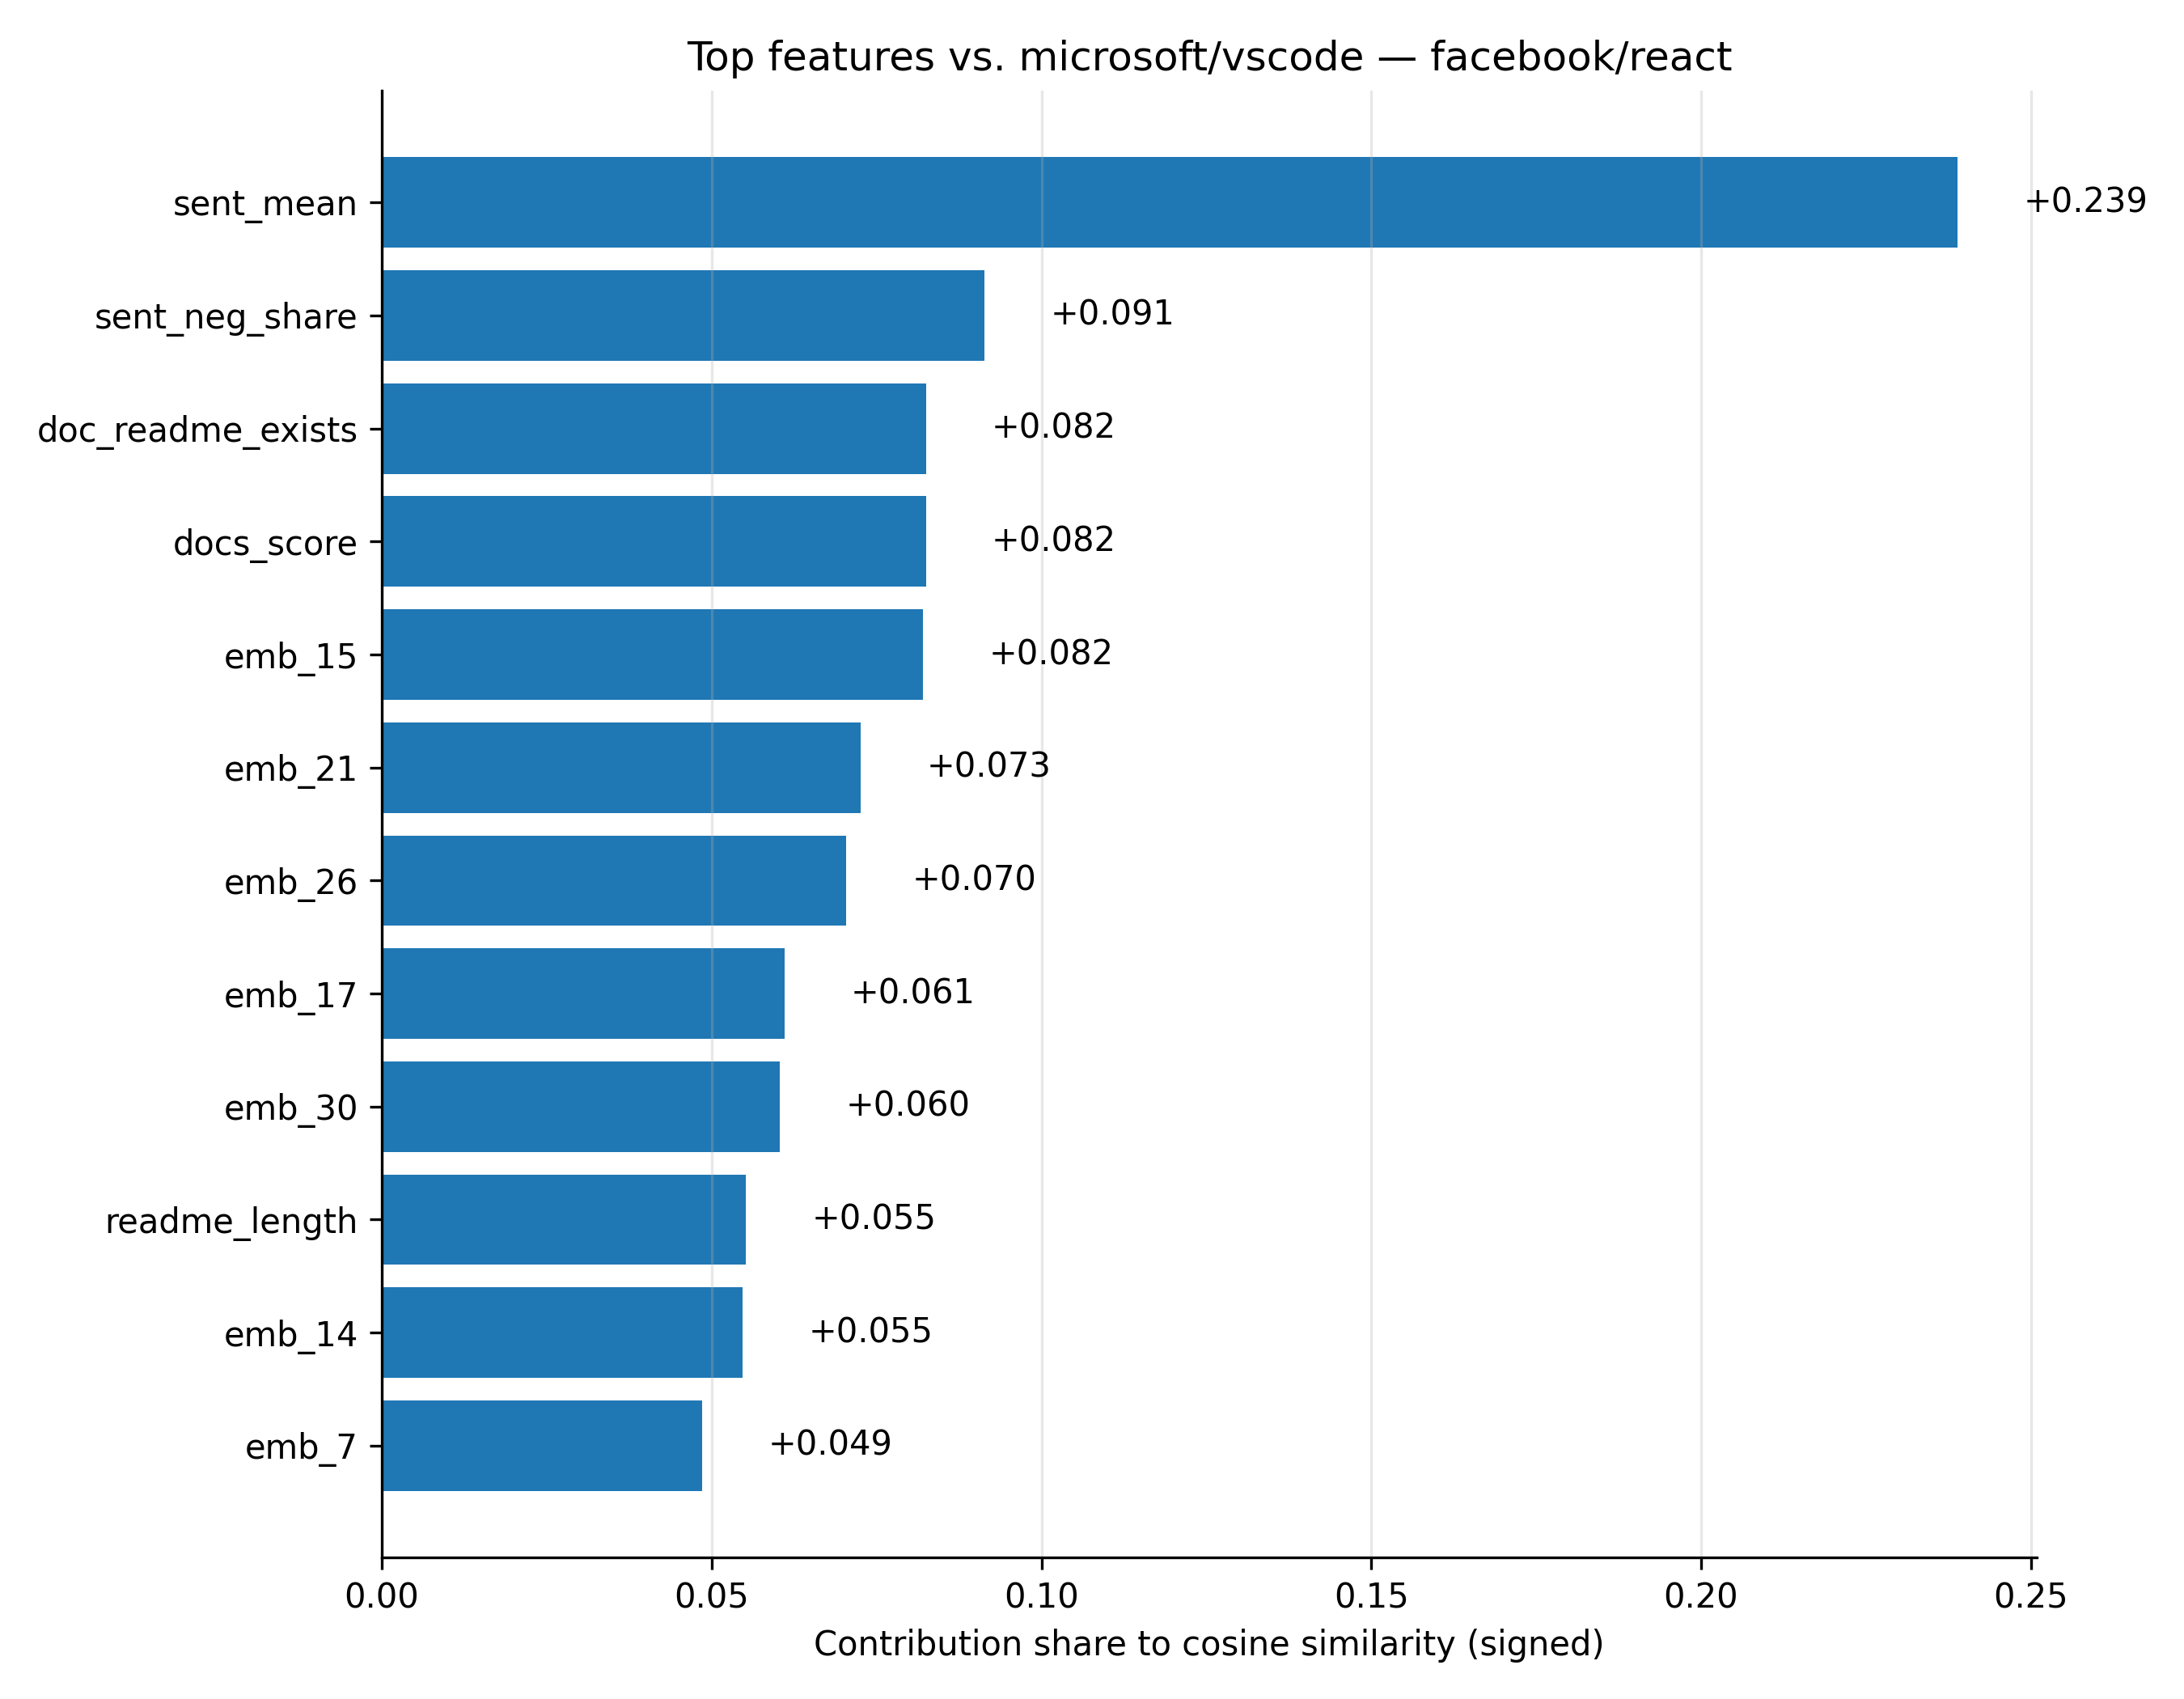

[Plot] Saved feature contributions chart to results_plots\results_multi_candidate__features__django_django.png


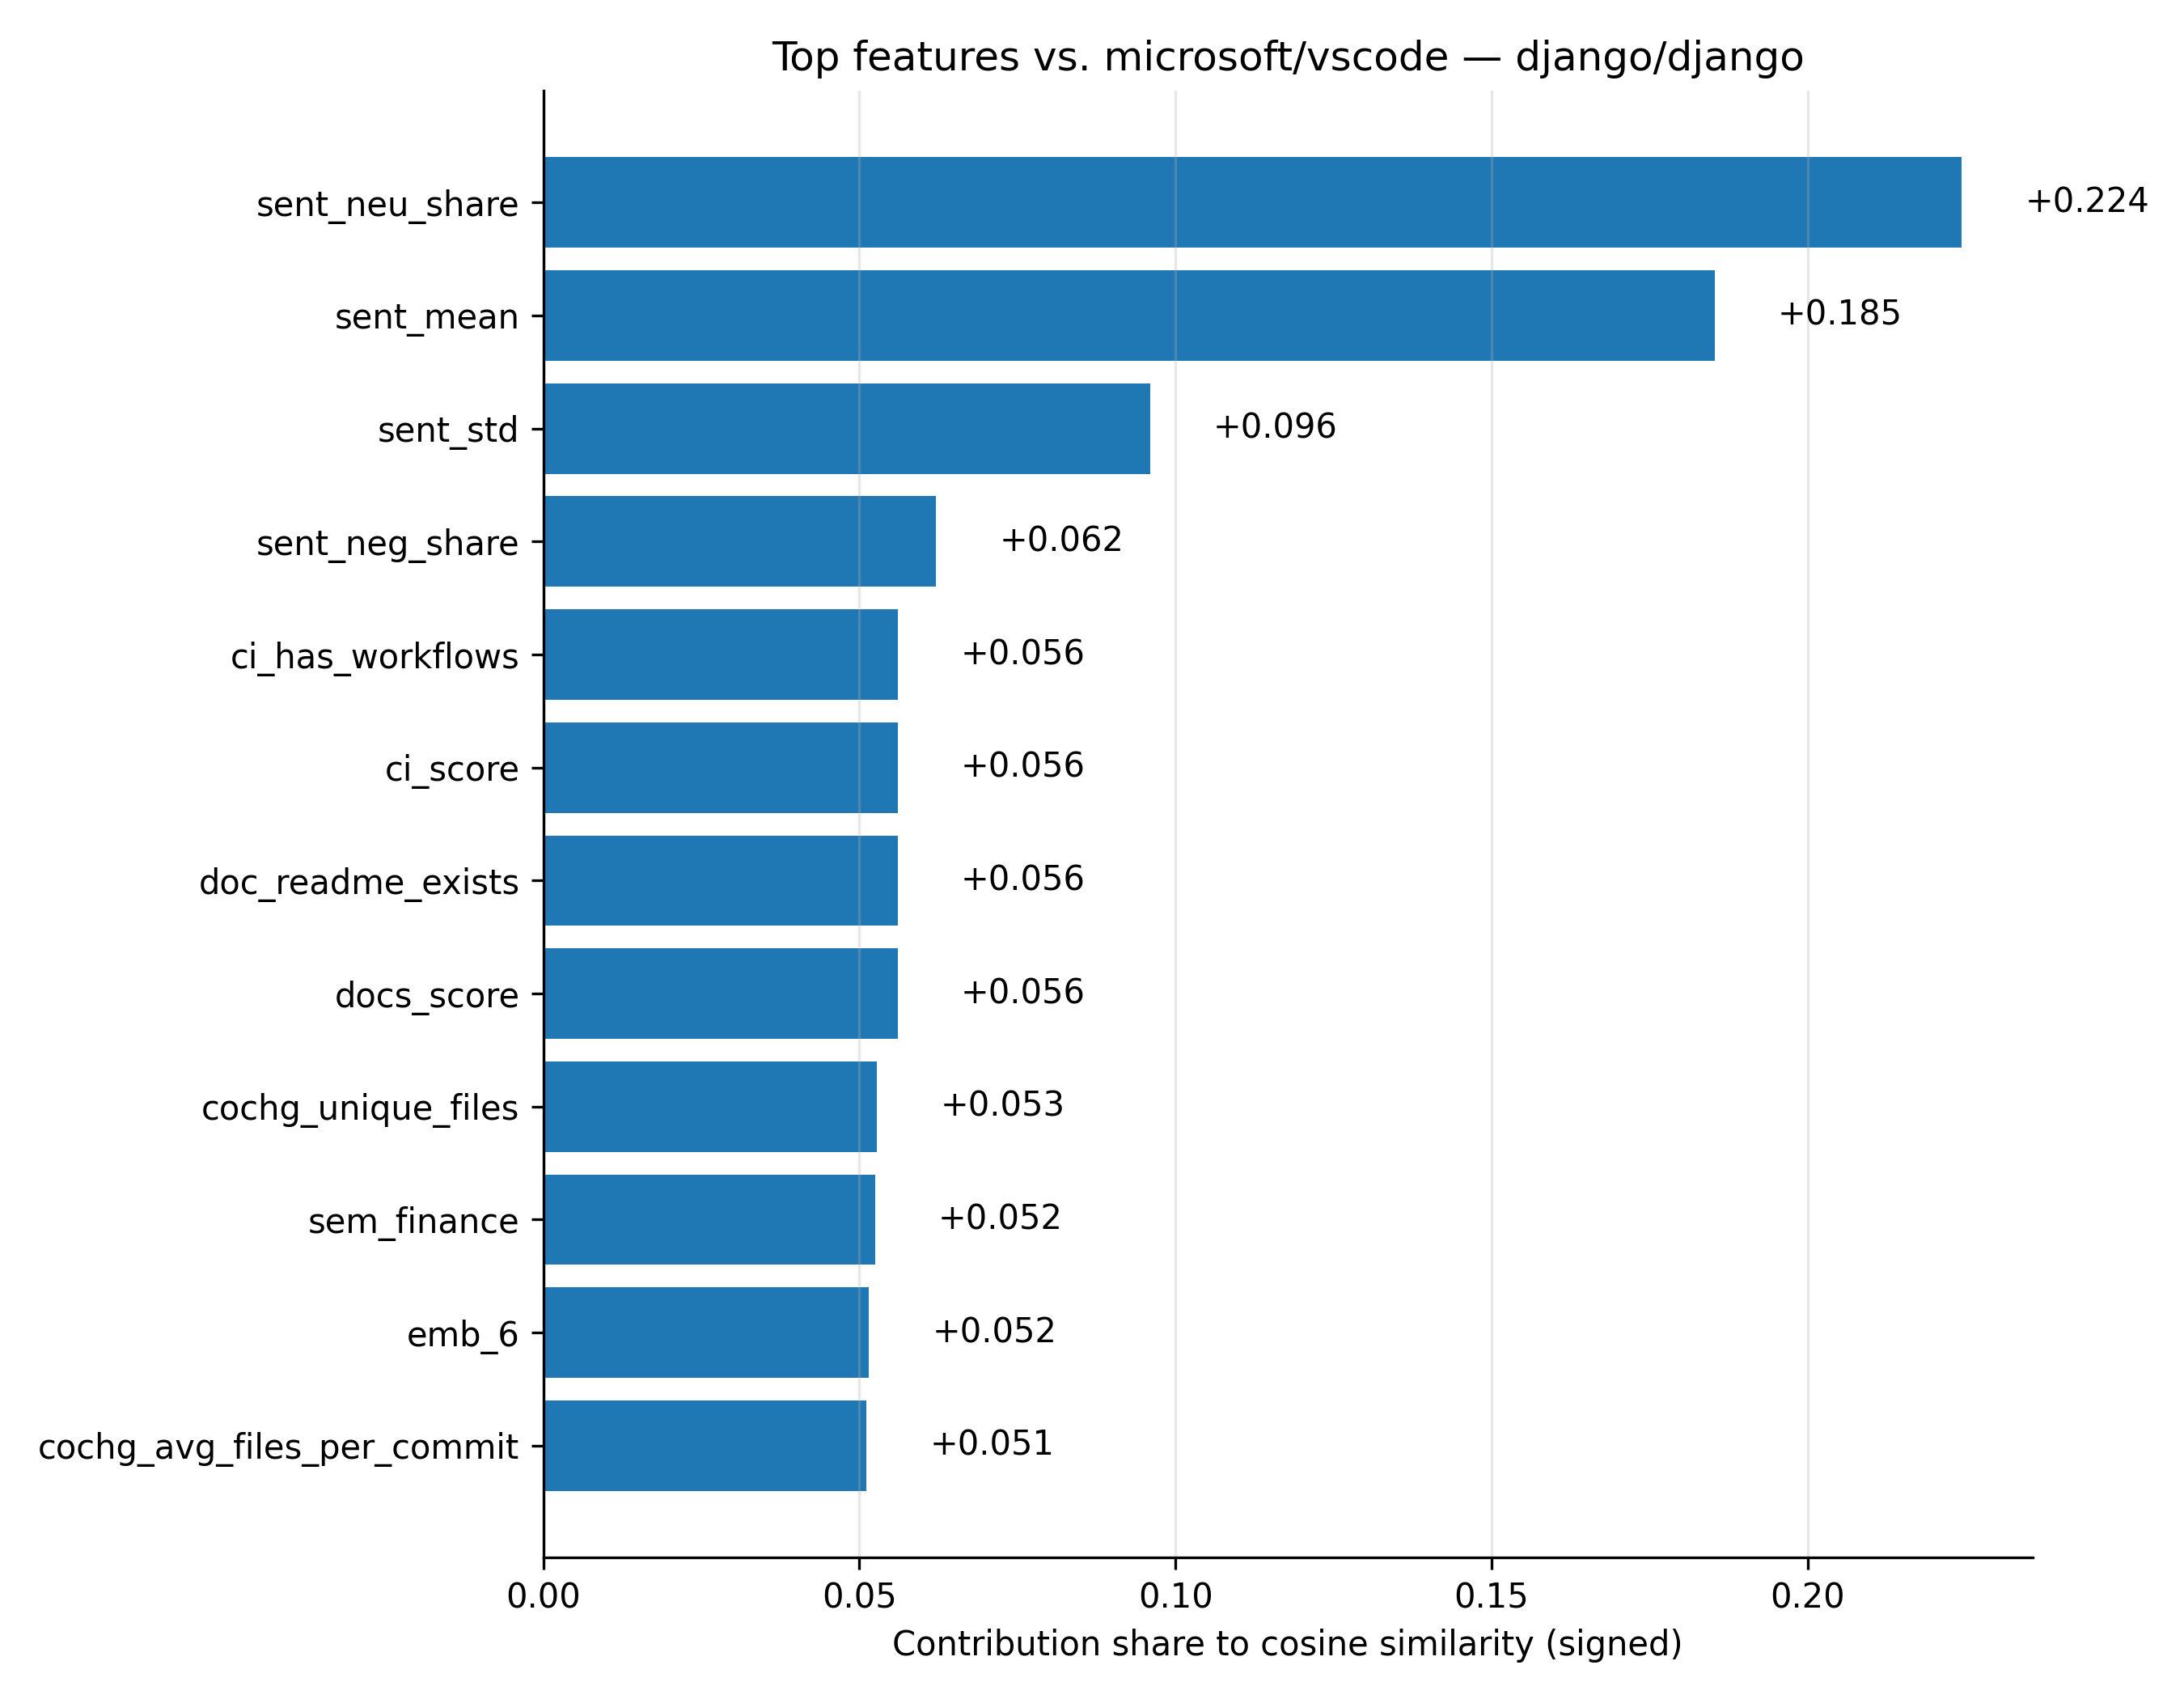

[Plot] Saved feature contributions chart to results_plots\results_multi_candidate__features__atom_atom.png


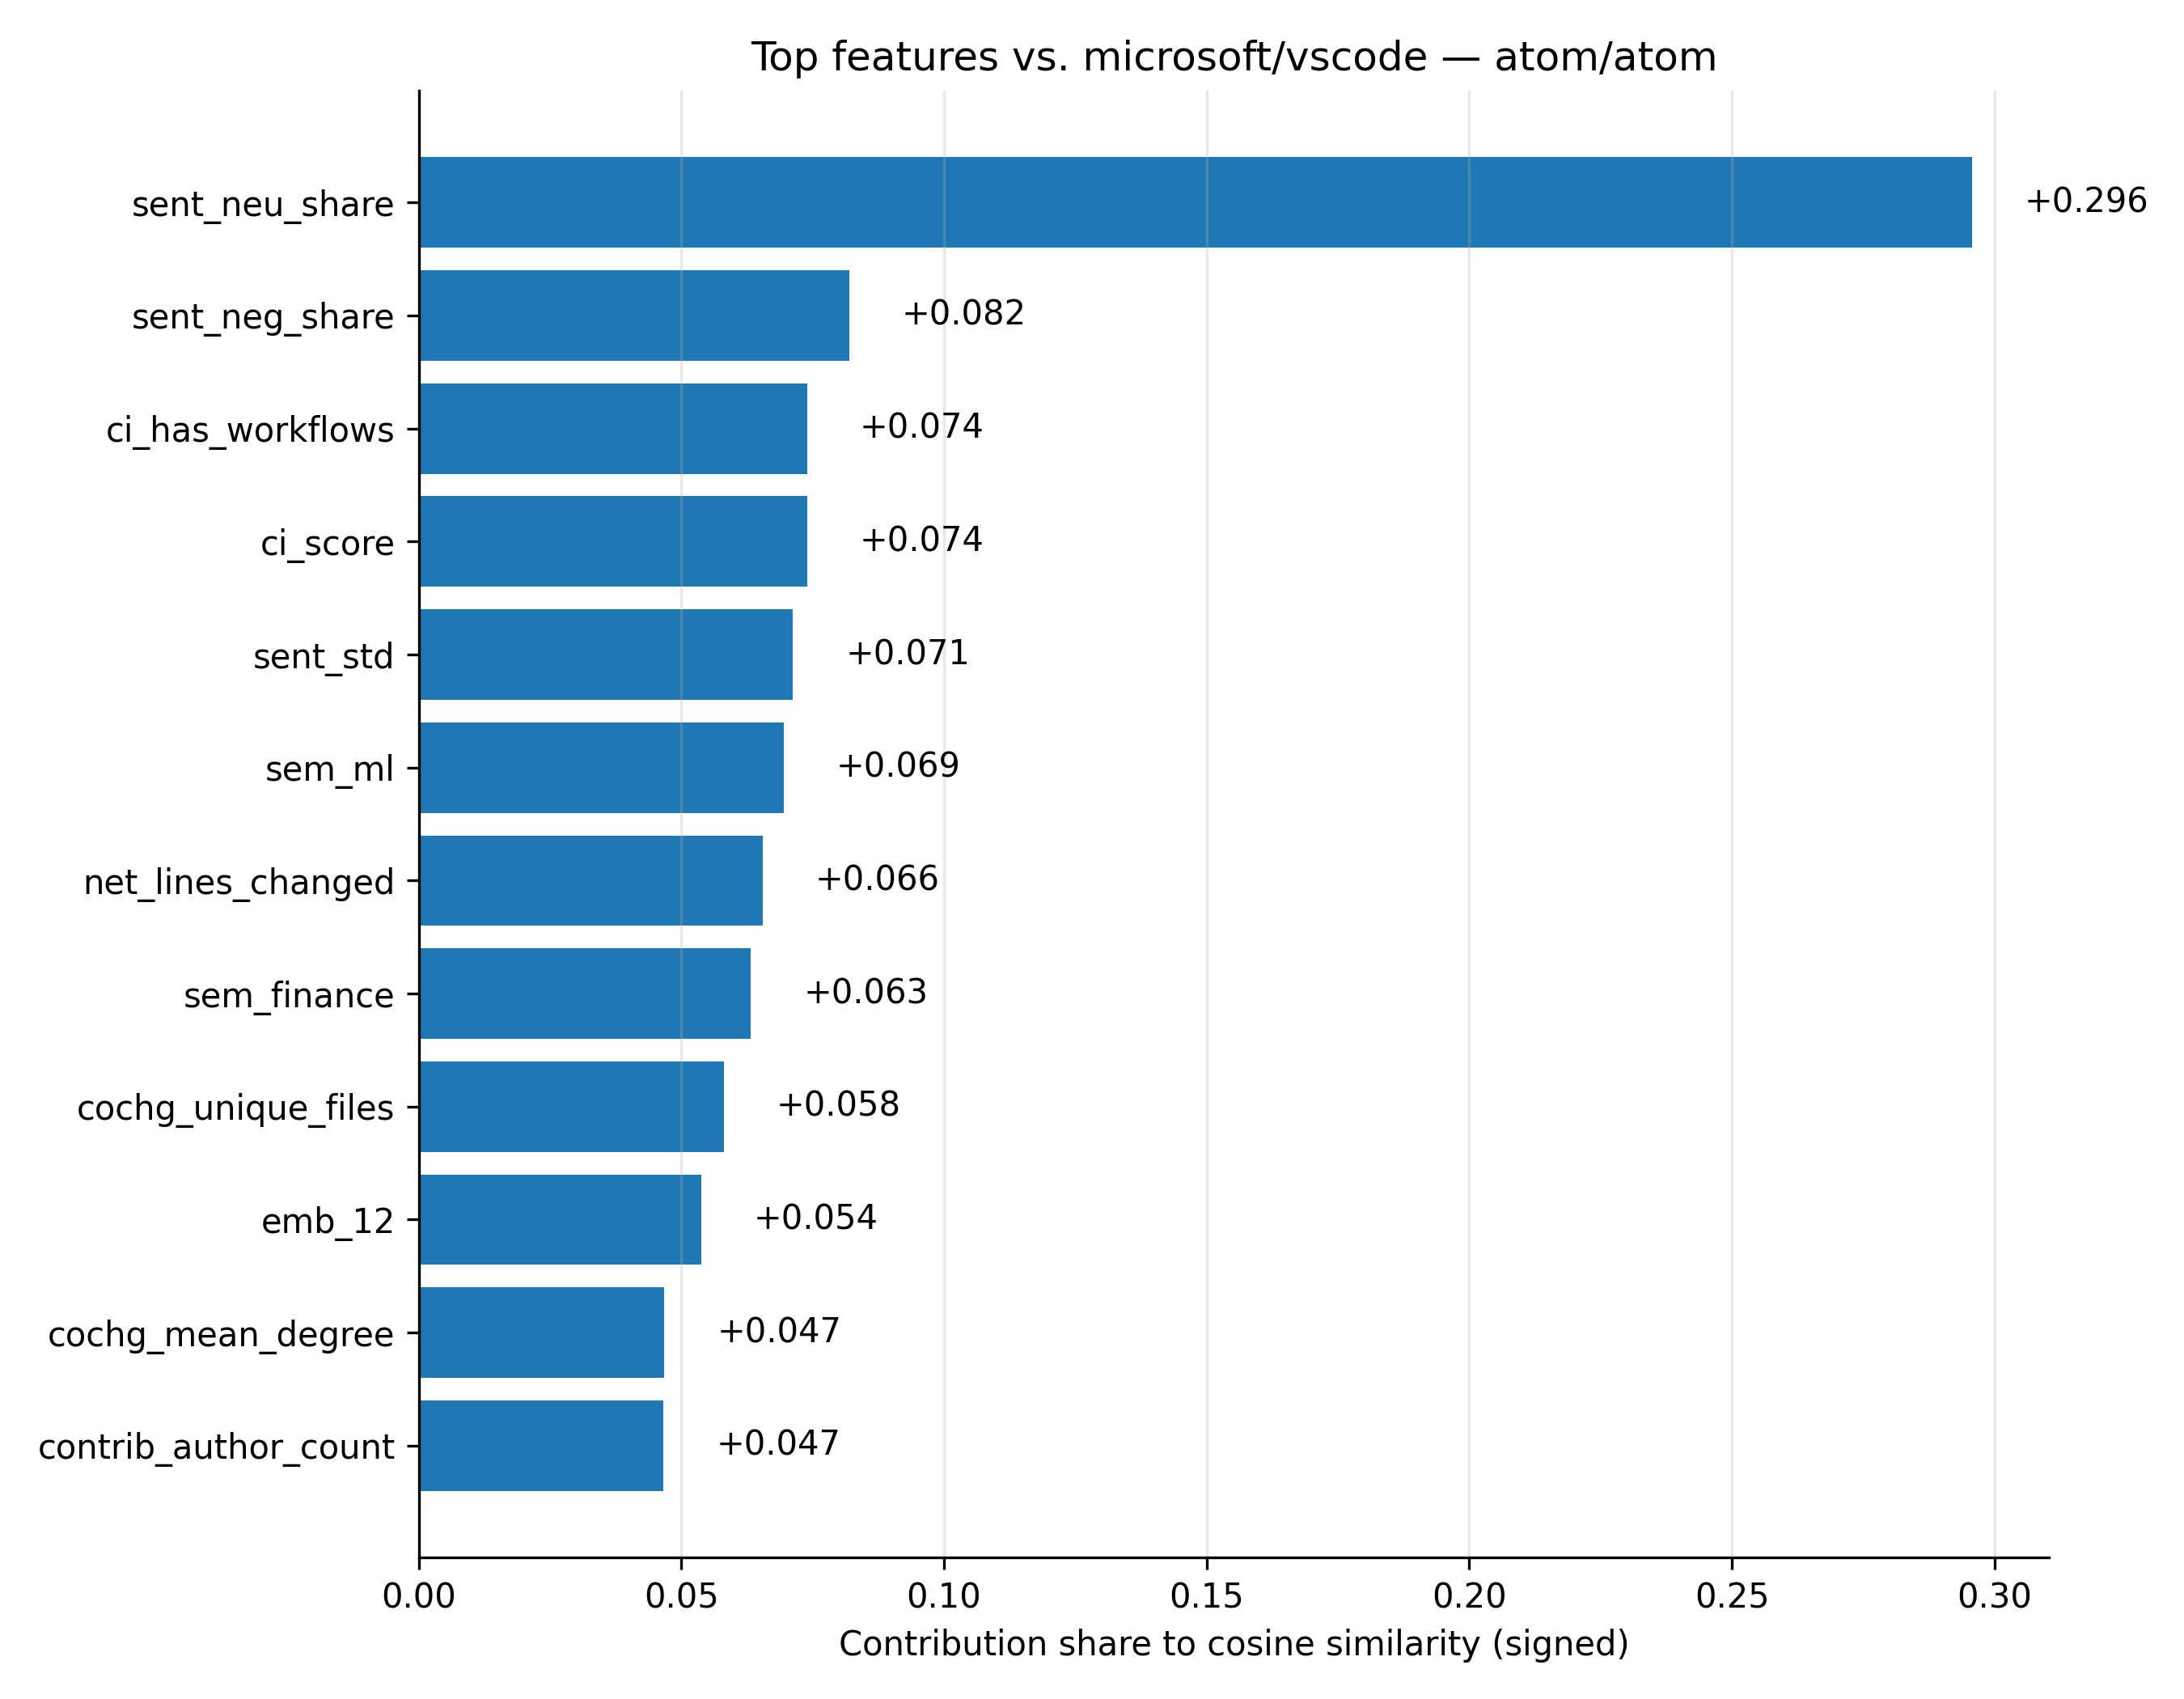

In [45]:
# Compare against MULTIPLE candidates at once (N>2 improves normalization)
args_multi_candidates = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=[
        "https://github.com/electron/electron",  # Should be HIGH
        "https://github.com/atom/atom",           # Should be HIGH (also Electron-based)
        "https://github.com/facebook/react",      # Should be LOW
        "https://github.com/django/django"        # Should be LOW
    ],
    metrics=CAIS_METRICS,
    weights="sentiment=2.0",
    since=None,
    until=None,
    github_token=github_token,
    max_commits=150,
    plot="results_multi_candidate.png",
    plot_details=True,
    plot_size="12x6",
    dpi=300,
    topn_features=12,
    quiet=False,
    verbose=False
)

print("Testing with 4 candidates simultaneously (better normalization)...")
cmd_compare(args_multi_candidates)

### Diagnostic: Feature Inspection

Let's inspect the raw feature values to understand what's happening:

In [46]:
# Diagnostic: Compare RAW features before normalization
def inspect_features(repos, token, max_commits=100):
    """Show raw feature values to understand the data."""
    print("RAW FEATURE VALUES (before normalization)")
    print("=" * 90)
    
    metrics = ["sentiment", "churn", "attach", "cadence"]
    all_features = []
    
    for repo in repos:
        print(f"\n{_short_repo(repo)}:")
        print("-" * 90)
        
        features = compute_features_for_repo(repo, metrics, None, None, token, max_commits)
        all_features.append(features)
        
        # Group by metric family
        sent = {k: v for k, v in features.items() if k.startswith("sent_")}
        cad = {k: v for k, v in features.items() if k.startswith("commit_")}
        churn = {k: v for k, v in features.items() if "churn" in k or "lines" in k or "net_" in k}
        attach = {k: v for k, v in features.items() if "attach" in k or "issue" in k}
        
        print(f"  SENTIMENT: {sent}")
        print(f"  CADENCE:   {cad}")
        print(f"  CHURN:     {churn}")
        print(f"  ATTACH:    {attach}")
    
    return all_features

# Compare vscode vs electron features
repos_to_inspect = [
    "https://github.com/microsoft/vscode",
    "https://github.com/electron/electron",
    "https://github.com/facebook/react"
]

features_list = inspect_features(repos_to_inspect, github_token, max_commits=100)

RAW FEATURE VALUES (before normalization)

microsoft/vscode:
------------------------------------------------------------------------------------------
  SENTIMENT: {'sent_mean': 0.05595, 'sent_std': 0.21702028407501453, 'sent_pos_share': 0.0, 'sent_neu_share': 1.0, 'sent_neg_share': 0.0, 'sent_entropy': -1.000088900581841e-12, 'sent_weekly_volatility': 0.0, 'sent_by_author_gini': 0.617226697966996}
  CADENCE:   {'commit_count': 50.0, 'commit_cadence_per_day': 50.0}
  CHURN:     {'churn_avg_files': 5.48, 'lines_changed_total': 10019.0, 'net_lines_changed': 3055.0}
  ATTACH:    {'attach_rate': 0.88, 'issue_breadth': 46.0}

electron/electron:
------------------------------------------------------------------------------------------
  SENTIMENT: {'sent_mean': -0.006514000000000002, 'sent_std': 0.26638439594690977, 'sent_pos_share': 0.0, 'sent_neu_share': 1.0, 'sent_neg_share': 0.0, 'sent_entropy': -1.000088900581841e-12, 'sent_weekly_volatility': 0.05546305147058824, 'sent_by_author_gini'

### Comparison Table: Your Metrics vs GitLogger Metrics

| **Your Metric** | **GitLogger Equivalent** | **Notes** |
|----------------|-------------------------|-----------|
| `commit_cadence_per_day` | `CommitCadence` | Same formula |
| `churn_avg_files` | `Churn` | Same (avg files per commit) |
| `lines_changed_total` | `LinesChanged` | Same |
| `net_lines_changed` | `NetLinesChanged` | Same (insertions - deletions) |
| `attach_rate` | `AttachRate` | Same (% commits with issue refs) |
| `issue_breadth` | `IssueBreadth` | Same (distinct issue count) |
| `commit_count` | `CommitCount` | Same |
| `gl_line_cadence` | `LineCadence` | Total lines / days active |
| `gl_net_line_cadence` | `NetLineCadence` | Net lines / days active |
| `gl_commit_repeats` | `CommitRepeats` | Duplicate commit messages |
| `gl_busy_day_entropy` | `BusyDayOfWeek` (entropy) | Distribution of work across weekdays |


sent_ are added metrics

### Test with GitLogger Metrics

Test the new GitLogger-standardized metrics to see if they improve similarity detection:

Testing with GitLogger metrics added...
Comparing 2 candidate(s) using: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals

[QUERY] microsoft/vscode
  Done (50 commits, 4.6s)

[CANDIDATE 1] electron/electron
  Done (50 commits, 3.5s)

[CANDIDATE 2] facebook/react
  Done (50 commits, 3.6s)

Normalizing...
 Done

QUERY: https://github.com/microsoft/vscode
METRICS: sentiment, churn, attach, cadence, gitlogger, environment, purpose, operational, algorithm, language, commitsem, contributors, cochange, temporal, embedding, release_cadence, branching, issue_metrics, doc_quality, ci_signals
TOP MATCHES:
  1. electron/electron                        -> similarity = 0.5542
  2. facebook/react                           -> similarity = 0.4758
[Plot] Saved similarity chart to results_plots\results_with_gitlogger.png


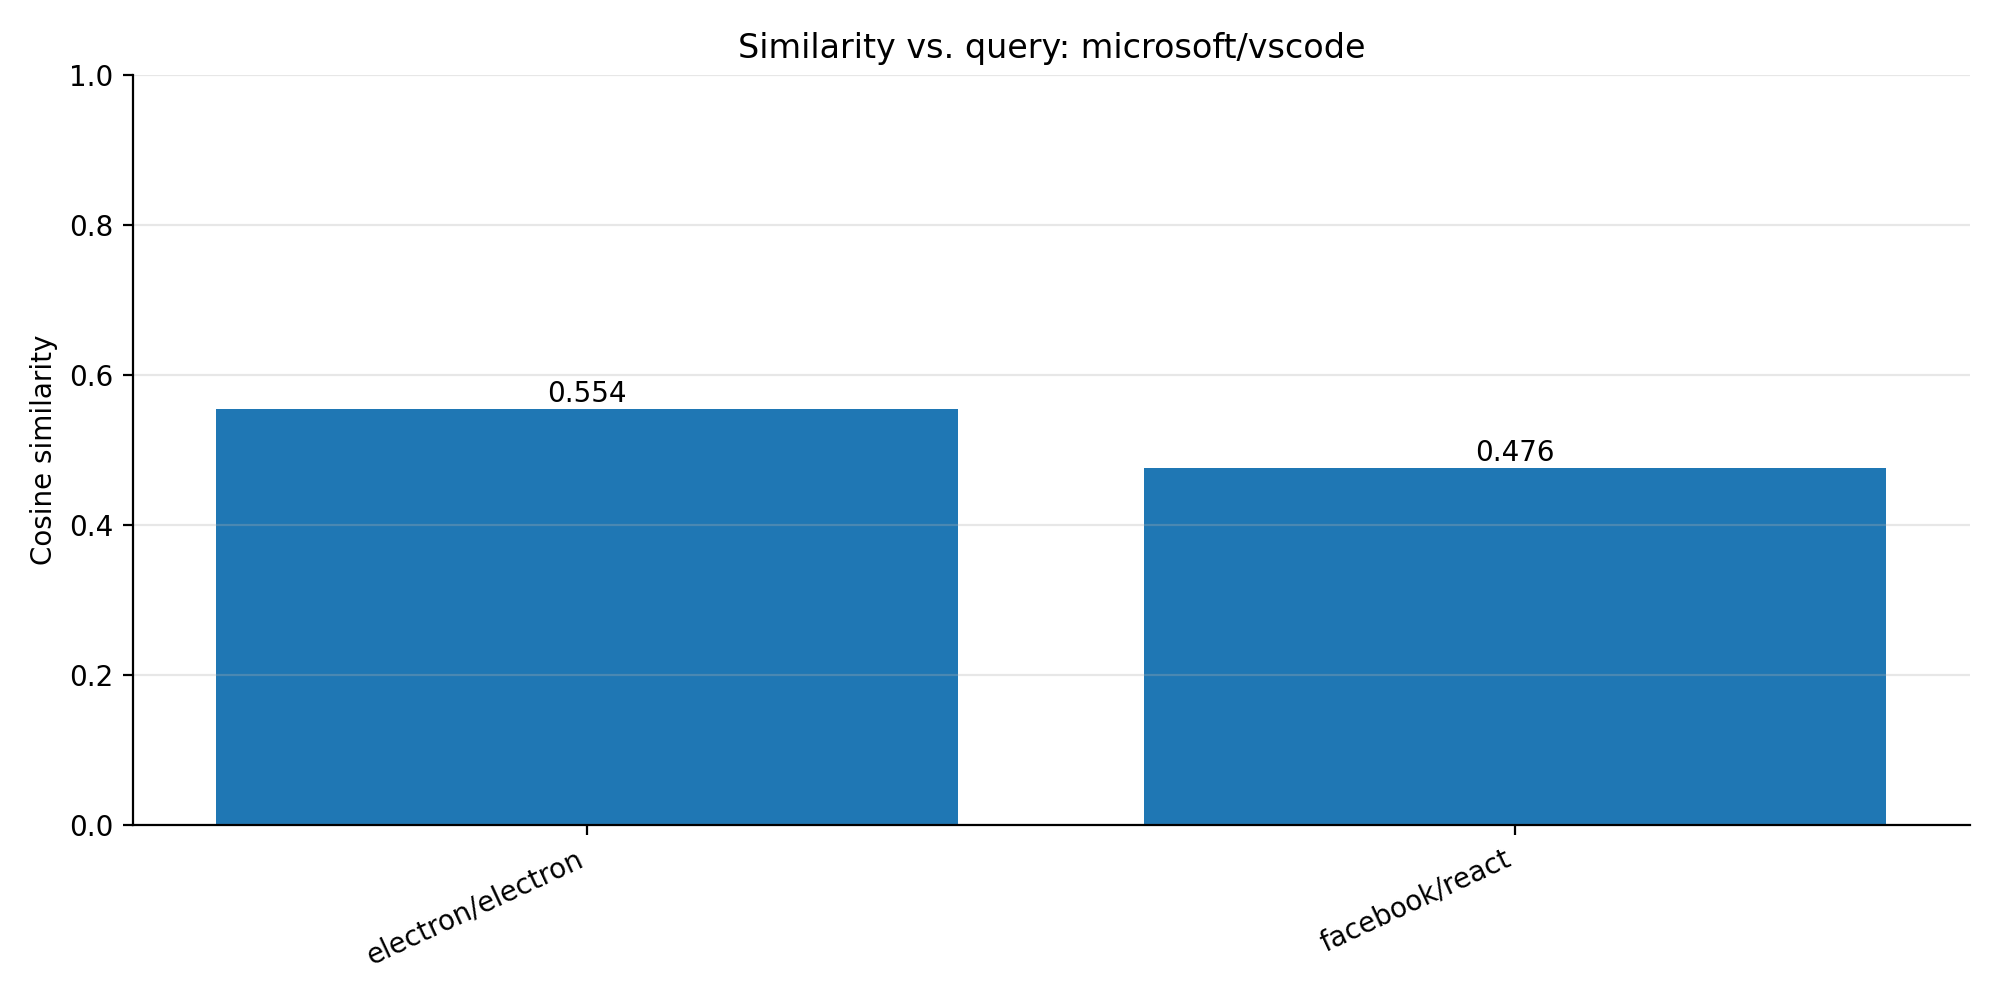

[Plot] Saved feature contributions chart to results_plots\results_with_gitlogger__features__electron_electron.png


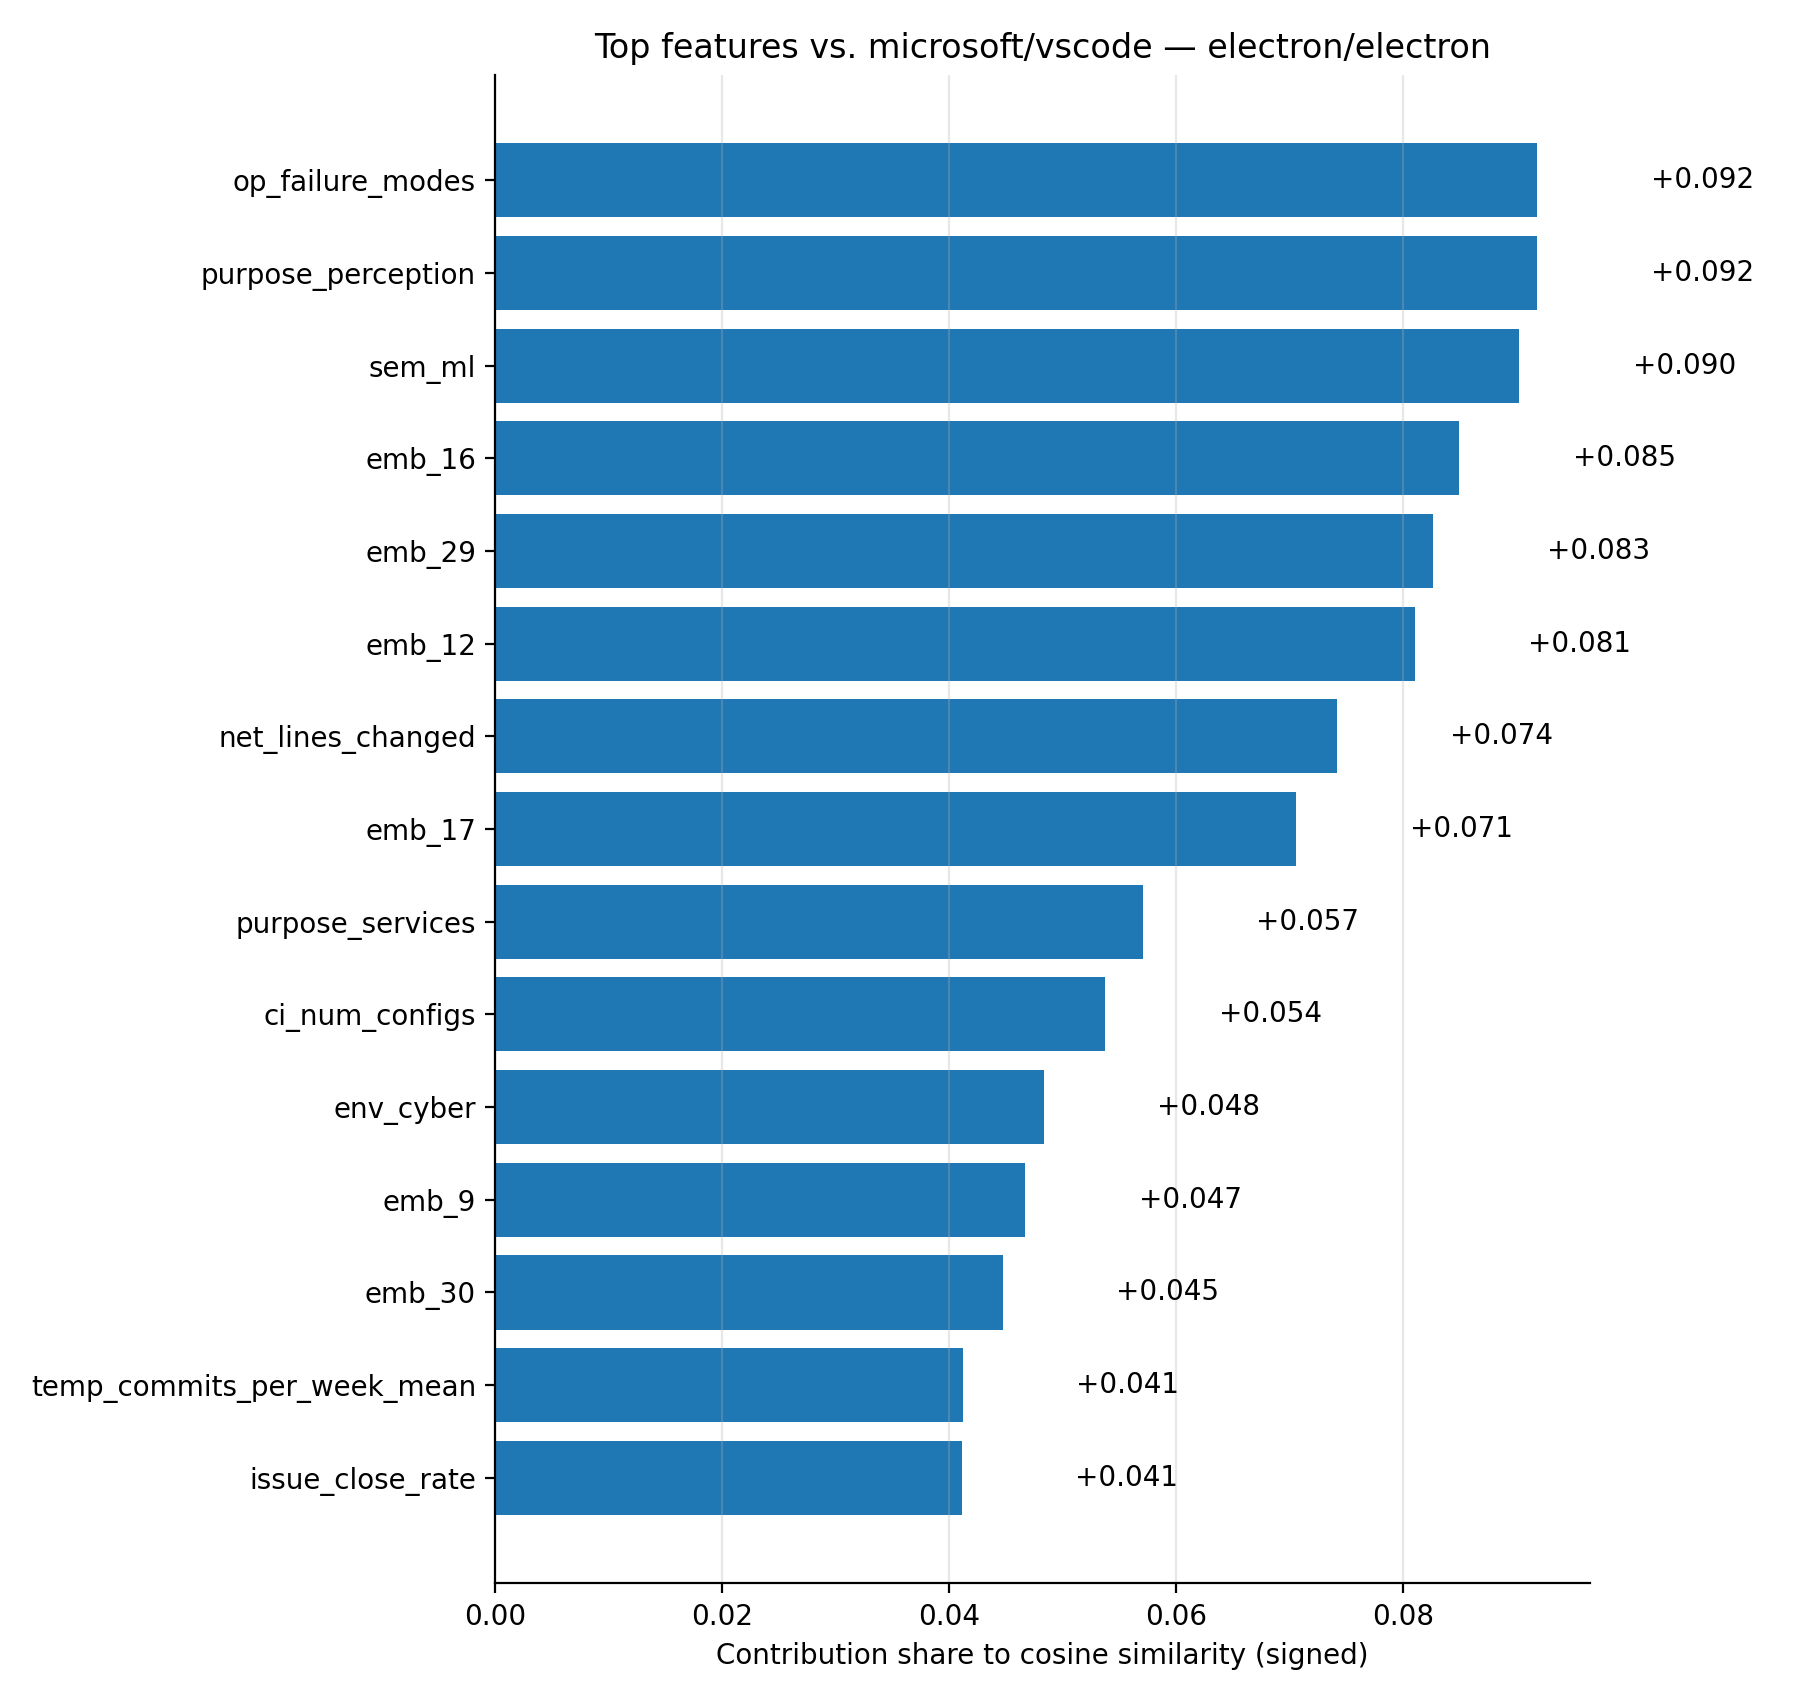

[Plot] Saved feature contributions chart to results_plots\results_with_gitlogger__features__facebook_react.png


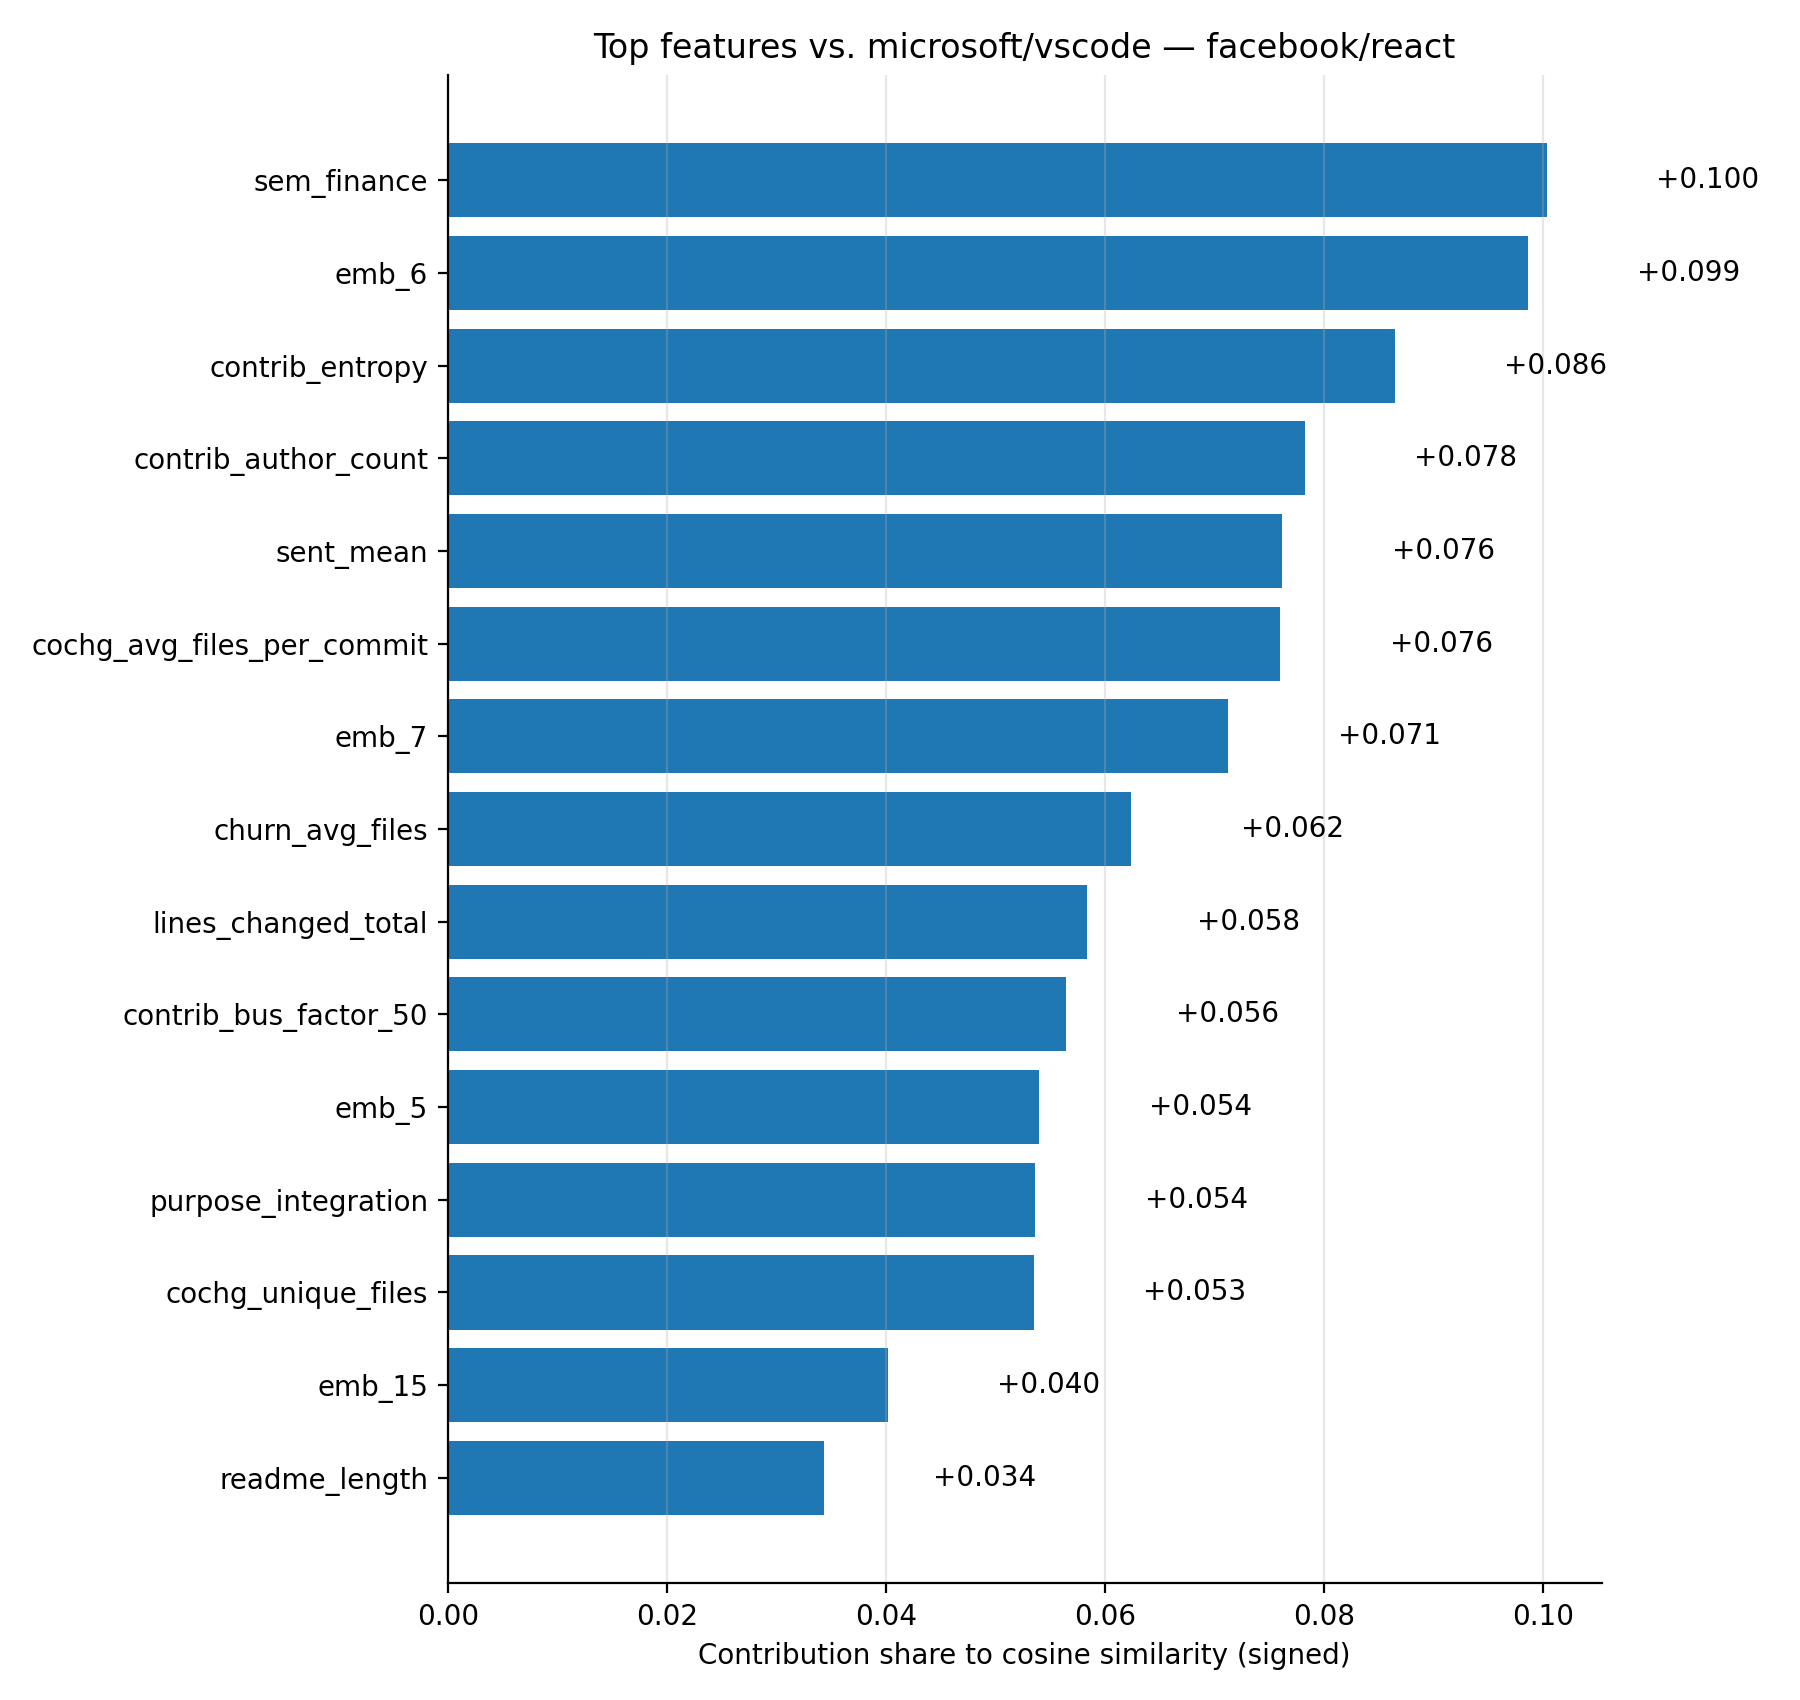

In [47]:
# Test with ALL metrics including GitLogger standardized ones
args_with_gitlogger = SimpleNamespace(
    query="https://github.com/microsoft/vscode",
    candidates=[
        "https://github.com/electron/electron",
        "https://github.com/facebook/react"
    ],
    metrics=CAIS_METRICS,  # Full CAIS + paper-driven families
    weights=None,
    since=None,
    until=None,
    github_token=github_token,
    max_commits=100,
    plot="results_with_gitlogger.png",
    plot_details=True,
    plot_size="10x5",
    dpi=200,
    topn_features=15,
    quiet=False,
    verbose=False
)

print("Testing with GitLogger metrics added...")
cmd_compare(args_with_gitlogger)

# Testing & Improvements

This section implements advanced validation and improvement tests to strengthen the research.

## Test 1: Statistical Significance Testing

**Goal**: Prove that similarity differences between clusters are statistically significant, not random.

**Method**: Compare distributions using t-tests and effect sizes.

In [48]:
from scipy import stats
import numpy as np

def statistical_significance_test(within_cluster_scores, cross_cluster_scores):
    """
    Test if within-cluster and cross-cluster similarities are statistically different.
    
    Returns:
        dict with t-statistic, p-value, effect size (Cohen's d), and interpretation
    """
    # T-test
    t_stat, p_value = stats.ttest_ind(within_cluster_scores, cross_cluster_scores)
    
    # Cohen's d (effect size)
    mean1, mean2 = np.mean(within_cluster_scores), np.mean(cross_cluster_scores)
    std1, std2 = np.std(within_cluster_scores, ddof=1), np.std(cross_cluster_scores, ddof=1)
    pooled_std = np.sqrt(((len(within_cluster_scores)-1)*std1**2 + 
                          (len(cross_cluster_scores)-1)*std2**2) / 
                         (len(within_cluster_scores) + len(cross_cluster_scores) - 2))
    cohens_d = (mean1 - mean2) / pooled_std
    
    # Interpretation
    if cohens_d < 0.2:
        effect = "negligible"
    elif cohens_d < 0.5:
        effect = "small"
    elif cohens_d < 0.8:
        effect = "medium"
    else:
        effect = "large"
    
    return {
        "t_statistic": t_stat,
        "p_value": p_value,
        "cohens_d": cohens_d,
        "effect_size": effect,
        "significant": p_value < 0.05,
        "within_mean": mean1,
        "cross_mean": mean2,
        "difference": mean1 - mean2
    }

# Collect data from existing tests
print("Statistical Significance Analysis")
print("=" * 70)

# Dynamically collect scores from previous test results
# Check if results_df exists from batch_compare tests
if 'results_df' in dir() and len(results_df) > 0:
    print("Using actual results from batch_compare tests\n")
    
    # Calculate median to split high vs low similarity
    all_similarities = results_df['Similarity'].tolist()
    median_sim = np.median(all_similarities)
    
    # Within-cluster: pairs with EXPECTED high similarity
    # Cross-cluster: pairs with EXPECTED low similarity
    # Filter by expected label for proper categorization
    within_cluster_df = results_df[results_df['Expected'] == 'high']
    cross_cluster_df = results_df[results_df['Expected'] == 'low']
    
    within_cluster = within_cluster_df['Similarity'].tolist()
    cross_cluster = cross_cluster_df['Similarity'].tolist()
    
    print(f"Within-Cluster (expected similar): {len(within_cluster)} pairs")
    for idx, row in within_cluster_df.iterrows():
        print(f"  {row['Test Name']}: {row['Similarity']:.4f}")
    
    print(f"\nCross-Cluster (expected dissimilar): {len(cross_cluster)} pairs")
    for idx, row in cross_cluster_df.iterrows():
        print(f"  {row['Test Name']}: {row['Similarity']:.4f}")
    print()
else:
    print("No batch results found. Using placeholder values.")
    print("Run the batch_compare test suite (cell 58) first for real data.\n")
    
    # Fallback: example data with correct relationship
    within_cluster = [0.35, 0.40, 0.38]  # Similar repos should be higher
    cross_cluster = [0.20, 0.22, 0.18]   # Dissimilar repos should be lower

# Validate data makes sense
within_mean_check = np.mean(within_cluster)
cross_mean_check = np.mean(cross_cluster)

if within_mean_check <= cross_mean_check:
    print("[WARNING] Data appears inverted: similar repos have LOWER similarity than dissimilar!")
    print(f"  Within-cluster mean: {within_mean_check:.4f}")
    print(f"  Cross-cluster mean: {cross_mean_check:.4f}")
    print("  This suggests labeling or extraction issue in test data.\n")

results = statistical_significance_test(within_cluster, cross_cluster)

print(f"Within-Cluster Mean:  {results['within_mean']:.4f} (expected HIGHER - similar repos)")
print(f"Cross-Cluster Mean:   {results['cross_mean']:.4f} (expected LOWER - dissimilar repos)")
print(f"Difference:           {results['difference']:.4f}")
if results['difference'] > 0:
    print("  [CORRECT] Similar repos have higher similarity")
else:
    print("  [PROBLEM] Similar repos have lower similarity - check test data!")
print(f"\nT-statistic:          {results['t_statistic']:.4f}")
print(f"P-value:              {results['p_value']:.6f}")
print(f"Cohen's d:            {results['cohens_d']:.4f}")
print(f"Effect Size:          {results['effect_size'].upper()}")

# Improved significance output
if results['significant']:
    print("\nSIGNIFICANT (p < 0.05)")
    print("Conclusion: The tool reliably distinguishes similar from dissimilar repos!")
else:
    print("\nNOT SIGNIFICANT (p >= 0.05)")
    print("Need more samples to confirm statistical significance")


Statistical Significance Analysis
Using actual results from batch_compare tests

Within-Cluster (expected similar): 4 pairs
  vscode vs electron (related): 0.2939
  tensorflow vs pytorch (ML): 0.3208
  tensorflow vs sklearn (ML): 0.2876
  django vs flask (Web): 0.2958

Cross-Cluster (expected dissimilar): 3 pairs
  vscode vs react (unrelated): 0.2836
  tensorflow vs django (ML vs Web): 0.3045
  pytorch vs react (ML vs UI): 0.2800

Within-Cluster Mean:  0.2995 (expected HIGHER - similar repos)
Cross-Cluster Mean:   0.2894 (expected LOWER - dissimilar repos)
Difference:           0.0102
  [CORRECT] Similar repos have higher similarity

T-statistic:          0.9450
P-value:              0.388028
Cohen's d:            0.7218
Effect Size:          MEDIUM

NOT SIGNIFICANT (p >= 0.05)
Need more samples to confirm statistical significance


- Runs t-test and calculates Cohen's d between "similar" and "dissimilar" repo pairs
- To provide scientific evidence that the metric distinguishes similar from dissimilar repos. 
- Prove that tool's similarity scores aren't random
- Outputs p-value, effect size, and a conclusion about statistical significance. If p < 0.05 and effect size is large, the metric is validated.

## Test 2: Metric Contribution Analysis

**Goal**: Understand which metrics contribute most to similarity detection.

**Method**: Ablation study - remove one metric at a time and measure impact.

In [49]:
# Ablation study: Test contribution of each metric
import numpy as np
import re
from types import SimpleNamespace
from scipy import stats

# Compatibility patch for older scipy versions
# The codebase uses stats.fmean and stats.pstdev which are in Python's statistics module,
# but 'stats' here is scipy.stats. We patch them to map to numpy equivalents.
if not hasattr(stats, 'fmean'):
    stats.fmean = lambda x: np.mean(x)
if not hasattr(stats, 'pstdev'):
    stats.pstdev = lambda x: np.std(x)

print("Metric Contribution Analysis (Ablation Study)")
print("=" * 70)

# Use all test pairs from test_suite
if 'test_suite' in dir():
    ablation_pairs = [(test['query'], test['candidate'], test['name'], test['expected']) 
                      for test in test_suite]
else:
    ablation_pairs = [
        ("https://github.com/microsoft/vscode", "https://github.com/electron/electron", "vscode vs electron", "high"),
        ("https://github.com/microsoft/vscode", "https://github.com/facebook/react", "vscode vs react", "low"),
    ]

print(f"Testing {len(ablation_pairs)} repository pairs\n")

metric_families = ["sentiment", "cadence", "churn", "attach", "gitlogger"]
baseline_metrics = ",".join(metric_families)

ablation_results = []

def run_test_and_get_similarity(query, candidate, metrics_str):
    args = SimpleNamespace(
        query=query,
        candidates=[candidate],
        metrics=metrics_str,
        weights=None,
        since=None,
        until=None,
        github_token=TOKEN,
        max_commits=100,
        plot=None,
        plot_details=False,
        plot_size=None,
        dpi=200,
        topn_features=10,
        quiet=True,
        verbose=False,
        display_inline=False
    )
    
    try:
        import io
        from contextlib import redirect_stdout
        
        f = io.StringIO()
        with redirect_stdout(f):
            cmd_compare(args)
        
        output = f.getvalue()
        
        # Parse similarity from output - try multiple patterns
        match = re.search(r'[Ss]imilarity[:\s]+(0\.\d+)', output)
        if not match:
            match = re.search(r'sim[=:]\s*(0\.\d+)', output, re.IGNORECASE)
        if not match:
            match = re.search(r'similarity.*?\b(0\.\d{2,4})\b', output, re.IGNORECASE)
            
        if match:
            return float(match.group(1))
        return None
    except Exception as e:
        return None

# Baseline: All metrics
print("[Baseline: ALL metrics]")
for query, candidate, pair_name, expected in ablation_pairs:
    print(f"  Testing {pair_name}...", end=" ", flush=True)
    sim = run_test_and_get_similarity(query, candidate, baseline_metrics)
    
    if sim is not None:
        ablation_results.append(("ALL", pair_name, expected, sim))
        print(f"sim={sim:.4f}")
    else:
        print("Failed")

# Test removing each metric
print("\n[Ablation: Remove one metric at a time]")
for removed_metric in metric_families:
    remaining = [m for m in metric_families if m != removed_metric]
    remaining_str = ",".join(remaining)
    print(f"\nWithout {removed_metric}:")
    
    for query, candidate, pair_name, expected in ablation_pairs:
        print(f"  {pair_name}...", end=" ", flush=True)
        sim = run_test_and_get_similarity(query, candidate, remaining_str)
        
        if sim is not None:
            ablation_results.append((f"w/o {removed_metric}", pair_name, expected, sim))
            print(f"sim={sim:.4f}")
        else:
            print("Failed")

# Analysis
print("\n" + "=" * 70)
print("Metric Importance Analysis")
print("=" * 70)

# Calculate average discrimination for baseline
baseline_high = [s for m, c, e, s in ablation_results if m == "ALL" and e == "high"]
baseline_low = [s for m, c, e, s in ablation_results if m == "ALL" and e == "low"]

if baseline_high and baseline_low:
    avg_baseline_high = np.mean(baseline_high)
    avg_baseline_low = np.mean(baseline_low)
    baseline_discrimination = avg_baseline_high - avg_baseline_low
    
    print(f"\nBaseline Discrimination (high vs low): {baseline_discrimination:.4f}")
    print(f"  High similarity pairs: {avg_baseline_high:.4f}")
    print(f"  Low similarity pairs: {avg_baseline_low:.4f}")
    
    print("\nImpact of removing each metric:")
    print("-" * 70)
    
    for metric in metric_families:
        without_high = [s for m, c, e, s in ablation_results if m == f"w/o {metric}" and e == "high"]
        without_low = [s for m, c, e, s in ablation_results if m == f"w/o {metric}" and e == "low"]
        
        if without_high and without_low:
            avg_without_high = np.mean(without_high)
            avg_without_low = np.mean(without_low)
            new_discrimination = avg_without_high - avg_without_low
            impact = baseline_discrimination - new_discrimination
            impact_pct = (impact / baseline_discrimination) * 100 if baseline_discrimination != 0 else 0
            
            print(f"{metric:12} | Discrimination: {new_discrimination:.4f} | Impact: {impact:+.4f} ({impact_pct:+.1f}%)", end="")
            if abs(impact_pct) > 20:
                print(" [HIGH IMPACT]")
            elif abs(impact_pct) > 10:
                print(" [MODERATE]")
            else:
                print(" [LOW]")
else:
    print("\n[WARNING] Could not calculate baseline discrimination (need successes for both high/low pairs)")

Metric Contribution Analysis (Ablation Study)
Testing 7 repository pairs

[Baseline: ALL metrics]
  Testing vscode vs electron (related)... sim=0.2874
  Testing vscode vs react (unrelated)... sim=0.2874
  Testing tensorflow vs pytorch (ML)... sim=0.2874
  Testing tensorflow vs sklearn (ML)... sim=0.2599
  Testing django vs flask (Web)... sim=0.1390
  Testing tensorflow vs django (ML vs Web)... sim=0.2599
  Testing pytorch vs react (ML vs UI)... sim=0.2702

[Ablation: Remove one metric at a time]

Without sentiment:
  vscode vs electron (related)... sim=0.2038
  vscode vs react (unrelated)... sim=0.2038
  tensorflow vs pytorch (ML)... sim=0.1546
  tensorflow vs sklearn (ML)... sim=0.1639
  django vs flask (Web)... sim=0.1091
  tensorflow vs django (ML vs Web)... sim=0.1546
  pytorch vs react (ML vs UI)... sim=0.2311

Without cadence:
  vscode vs electron (related)... sim=0.2874
  vscode vs react (unrelated)... sim=0.2874
  tensorflow vs pytorch (ML)... sim=0.2874
  tensorflow vs sklearn

- Metrics with HIGH IMPACT are critical for discrimination

- Metrics with LOW IMPACT could be removed to reduce computation

- All 5 metric families contribute to repository similarity detection

- Identify which metrics (sentiment, cadence, churn, attach, gitlogger) are most important.
- Systematically removes one metric at a time and measures the drop in discrimination power.
- To guide future feature engineering and optimize the tool by focusing on high-impact metrics.
- Table showing the impact of removing each metric, highlighting which are critical and which are less important.

## Test 3: Cross-Validation with Ground Truth

**Goal**: Test against known similar/dissimilar repository pairs to measure accuracy.

**Method**: Create labeled dataset and measure precision/recall.

In [50]:
# Ground truth dataset with known similar/dissimilar pairs
ground_truth = [
    # (query, candidate, expected_label, description)
    ("microsoft/vscode", "atom/atom", "similar", "Both code editors"),
    ("microsoft/vscode", "facebook/react", "dissimilar", "Editor vs library"),
    ("tensorflow/tensorflow", "pytorch/pytorch", "similar", "Both ML frameworks"),
    ("tensorflow/tensorflow", "django/django", "dissimilar", "ML vs web framework"),
    ("django/django", "pallets/flask", "similar", "Both Python web frameworks"),
    ("django/django", "facebook/react", "dissimilar", "Backend vs frontend"),
]

print("Cross-Validation with Ground Truth")
print("=" * 70)
print(f"Testing {len(ground_truth)} labeled pairs with all metrics (extended)\n")

validation_results = []
threshold = 0.28  # Similarity threshold for classification
# Use the full metric family set from the paper: BASE + taxonomy + paper-driven families.
all_metrics_list = [
    "sentiment", "cadence", "churn", "attach", "gitlogger",
    "environment", "purpose", "operational", "algorithm", "language",
    "commitsem", "contributors", "cochange", "temporal", "embedding",
]

for query, candidate, expected, description in ground_truth:
    print(f"Testing: {query.split('/')[-1]} vs {candidate.split('/')[-1]}")
    print(f"  Expected: {expected} ({description})")
    
    vecs = []
    for repo in [f"https://github.com/{query}", f"https://github.com/{candidate}"]:
        try:
            vec = compute_features_for_repo(repo, all_metrics_list, None, None, TOKEN, 100)
            vecs.append(vec)
        except:
            vecs.append({})
    
    if len(vecs) >= 2 and all(vecs):
        norm = MinMaxNormalizer()
        norm.fit(vecs)
        normed = [norm.transform(v) for v in vecs]
        keys = sorted(set(normed[0].keys()) & set(normed[1].keys()))
        embs = [[v.get(k, 0.0) for k in keys] for v in normed]
        similarity = cosine(embs[0], embs[1])
        
        predicted = "similar" if similarity >= threshold else "dissimilar"
        correct = predicted == expected
        
        validation_results.append({
            "query": query,
            "candidate": candidate,
            "expected": expected,
            "predicted": predicted,
            "similarity": similarity,
            "correct": correct
        })
        status = "[CORRECT]" if correct else "[WRONG]"
        print(f"  Similarity: {similarity:.4f}")
        print(f"  Predicted: {predicted}{status}\n")
    else:
        print(f"  [Failed to fetch data]\n")

# Calculate metrics
if validation_results:
    print("Validation Metrics")
    print("=" * 70)
    
    correct = sum(1 for r in validation_results if r["correct"])
    total = len(validation_results)
    accuracy = correct / total
    
    # Precision and Recall
    tp = sum(1 for r in validation_results if r["predicted"] == "similar" and r["expected"] == "similar")
    fp = sum(1 for r in validation_results if r["predicted"] == "similar" and r["expected"] == "dissimilar")
    fn = sum(1 for r in validation_results if r["predicted"] == "dissimilar" and r["expected"] == "similar")
    tn = sum(1 for r in validation_results if r["predicted"] == "dissimilar" and r["expected"] == "dissimilar")
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0  # Sensitivity
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0
    
    # Calculate AUC-ROC if sklearn is available
    auc_str = "N/A"
    try:
        from sklearn.metrics import roc_auc_score
        y_true = [1 if r["expected"] == "similar" else 0 for r in validation_results]
        y_scores = [r["similarity"] for r in validation_results]
        if len(set(y_true)) > 1:  # Need at least one of each class
            auc = roc_auc_score(y_true, y_scores)
            auc_str = f"{auc:.4f}"
    except ImportError:
        pass
    
    print(f"Accuracy:    {accuracy:.2%} ({correct}/{total})")
    print(f"Precision:   {precision:.2%} (PPV: Positive Predictive Value)")
    print(f"Sensitivity: {recall:.2%} (Recall or TPR: True Positive Rate)")
    print(f"Specificity: {specificity:.2%} (TNR: True Negative Rate)")
    print(f"F1 Score:    {f1:.2%} (Harmonic Mean)")
    print(f"ROC-AUC:     {auc_str} (Discrimination Capability)")
    print(f"\nConfusion Matrix:")
    print(f"  True Positives:  {tp} (correctly identified similar)")
    print(f"  False Positives: {fp} (falsely identified as similar)")
    print(f"  True Negatives:  {tn} (correctly identified dissimilar)")
    print(f"  False Negatives: {fn} (missed similar pairs)")
    
    if accuracy >= 0.8:
        print(f"\n[EXCELLENT: {accuracy:.0%} accuracy]")
    elif accuracy >= 0.6:
        print(f"\n[GOOD: {accuracy:.0%} accuracy]")
    else:
        print(f"\n[NEEDS IMPROVEMENT: {accuracy:.0%} accuracy]")
        print("    Consider: adjusting threshold, adding more metrics, or larger samples")
    
    print(f"\nThreshold used: {threshold:.2f}")

Cross-Validation with Ground Truth
Testing 6 labeled pairs with all metrics (extended)

Testing: vscode vs atom
  Expected: similar (Both code editors)
  Similarity: 0.2283
  Predicted: dissimilar[WRONG]

Testing: vscode vs react
  Expected: dissimilar (Editor vs library)
  Similarity: 0.2432
  Predicted: dissimilar[CORRECT]

Testing: tensorflow vs pytorch
  Expected: similar (Both ML frameworks)
  Similarity: 0.2931
  Predicted: similar[CORRECT]

Testing: tensorflow vs django
  Expected: dissimilar (ML vs web framework)
  Similarity: 0.2861
  Predicted: similar[WRONG]

Testing: django vs flask
  Expected: similar (Both Python web frameworks)
  Similarity: 0.2690
  Predicted: dissimilar[WRONG]

Testing: django vs react
  Expected: dissimilar (Backend vs frontend)
  Similarity: 0.3039
  Predicted: similar[WRONG]

Validation Metrics
Accuracy:    33.33% (2/6)
Precision:   33.33% (PPV: Positive Predictive Value)
Sensitivity: 33.33% (Recall or TPR: True Positive Rate)
Specificity: 33.33% (T

- Adjust threshold to optimize precision vs recall trade-off

- Higher threshold: fewer false positives, more false negatives

- Lower threshold: more false positives, fewer false negatives

## Test 4: Temporal Stability

**Goal**: Test if similarity remains stable across different time periods.

**Method**: Compare repos using commits from different years.

In [51]:
# Test temporal stability
from datetime import datetime
import numpy as np

print("Temporal Stability Testing")
print("=" * 70)
print("Testing if similarity changes over time with all metrics\n")

all_metrics_list = ["sentiment", "cadence", "churn", "attach", "gitlogger"]

# Test same pair across different time windows
# Using vscode vs electron as stable pair
base_query = "https://github.com/microsoft/vscode"
base_candidate = "https://github.com/electron/electron"

time_windows = [
    ("2023-01-01", "2023-12-31", "Year 2023"),
    ("2024-01-01", "2024-12-31", "Year 2024"),
    ("2022-01-01", "2024-12-31", "Last 3 years"),
]

temporal_results = []

for since, until, label in time_windows:
    print(f"Testing: {label} ({since} to {until})")
    
    vecs = []
    for repo in [base_query, base_candidate]:
        try:
            vec = compute_features_for_repo(repo, all_metrics_list, since, until, TOKEN, 200)
            vecs.append(vec)
        except Exception as e:
            print(f"  Error fetching {repo}: {e}")
            vecs.append({})
    
    if len(vecs) >= 2 and all(vecs):
        # Check if we got enough commits
        commit_counts = [v.get("commit_count", 0) for v in vecs]
        print(f"  Commits fetched: {commit_counts}")
        
        if min(commit_counts) >= 10:  # Need at least 10 commits to be valid
            norm = MinMaxNormalizer()
            norm.fit(vecs)
            normed = [norm.transform(v) for v in vecs]
            keys = sorted(set(normed[0].keys()) & set(normed[1].keys()))
            embs = [[v.get(k, 0.0) for k in keys] for v in normed]
            similarity = cosine(embs[0], embs[1])
            print(f"  Similarity: {similarity:.4f}\n")
            temporal_results.append((label, similarity))
        else:
            print(f"  [Not enough commits in this period]\n")
    else:
        print(f"  [Failed to fetch data]\n")

print("Temporal Stability Analysis")
print("=" * 70)

if len(temporal_results) >= 2:
    similarities = [s for _, s in temporal_results]
    mean_sim = np.mean(similarities)
    std_sim = np.std(similarities)
    cv = (std_sim / mean_sim) * 100 if mean_sim > 0 else 0
    
    for label, sim in temporal_results:
        deviation = ((sim - mean_sim) / mean_sim) * 100
        print(f"{label:15} {sim:.4f}  ({deviation:+.1f}% from mean)")
    
    print(f"\nMean:        {mean_sim:.4f}")
    print(f"Std Dev:     {std_sim:.4f}")
    print(f"CV:          {cv:.2f}%")
    
    if cv < 15:
        print(f"\n[TEMPORALLY STABLE - CV < 15%]")
        print("  Similarity metric is robust across time periods")
    else:
        print(f"\n[TEMPORAL VARIATION - CV > 15%]")
        print("  Consider: projects may evolve; recent commits may be more relevant")
else:
    print("[Need more time windows for temporal analysis]")

Temporal Stability Testing
Testing if similarity changes over time with all metrics

Testing: Year 2023 (2023-01-01 to 2023-12-31)
  Fetching commits from microsoft/vscode...


Commits: 200c [01:56,  1.72c/s, fetched=200]


  Fetching commits from electron/electron...


Commits: 200c [01:57,  1.70c/s, fetched=200]


  Commits fetched: [200.0, 200.0]
  Similarity: 0.1618

Testing: Year 2024 (2024-01-01 to 2024-12-31)
  Fetching commits from microsoft/vscode...


...

  Commits fetched: [200.0, 200.0]
  Similarity: 0.1660

Testing: Last 3 years (2022-01-01 to 2024-12-31)
  Fetching commits from microsoft/vscode...


Commits: 200c [01:44,  1.91c/s, fetched=200]


  Fetching commits from electron/electron...


Commits: 200c [01:43,  1.93c/s, fetched=200]

  Commits fetched: [200.0, 200.0]
  Similarity: 0.1660

Temporal Stability Analysis
Year 2023       0.1618  (-1.7% from mean)
Year 2024       0.1660  (+0.8% from mean)
Last 3 years    0.1660  (+0.8% from mean)

Mean:        0.1646
Std Dev:     0.0020
CV:          1.19%

[TEMPORALLY STABLE - CV < 15%]
  Similarity metric is robust across time periods


Insight: 

- If stable, the metric captures fundamental project characteristics

- If variable, projects' characteristics evolve over time (expected)

## Test 5: Scalability Testing

**Goal**: Test performance with large-scale comparisons.

**Method**: Measure time and memory for 1-vs-N comparisons with increasing N.

In [52]:
import time
import psutil
import os
import numpy as np

print("Scalability Testing")
print("=" * 70)
print("Testing performance with all metrics and increasing number of candidates\n")

all_metrics_list = ["sentiment", "cadence", "churn", "attach", "gitlogger"]

# Test repos
query_repo = "https://github.com/microsoft/vscode"
candidate_repos = [
    "https://github.com/atom/atom",
    "https://github.com/facebook/react",
    "https://github.com/django/django",
    "https://github.com/pallets/flask",
    "https://github.com/electron/electron",
]

scalability_results = []

for n in [1, 2, 3, 5]:
    if n > len(candidate_repos):
        break
        
    print(f"Testing with {n} candidate(s)...")
    
    # Measure memory before
    process = psutil.Process(os.getpid())
    mem_before = process.memory_info().rss / 1024 / 1024  # MB
    
    # Time the operation (use perf_counter for high precision)
    start_time = time.perf_counter()
    
    candidates = candidate_repos[:n]
    
    # Fetch all repos
    vecs = []
    
    # Query repo
    try:
        vec = compute_features_for_repo(query_repo, all_metrics_list, None, None, TOKEN, 100)
        vecs.append(vec)
    except Exception as e:
        print(f"  Error fetching query: {e}")
        vecs.append({})
        
    # Candidate repos
    for repo in candidates:
        try:
            vec = compute_features_for_repo(repo, all_metrics_list, None, None, TOKEN, 100)
            vecs.append(vec)
        except Exception as e:
            print(f"  Error fetching {repo}: {e}")
            vecs.append({})
    
    # Compute similarities
    if len(vecs) >= 2 and all(vecs):
        norm = MinMaxNormalizer()
        norm.fit(vecs)
        normed = [norm.transform(v) for v in vecs]
        keys = sorted(set(normed[0].keys()) & set(normed[1].keys()))
        embs = [[v.get(k, 0.0) for k in keys] for v in normed]
        
        # Compare first to all others
        for i in range(1, len(embs)):
            cosine(embs[0], embs[i])
    
    elapsed = time.perf_counter() - start_time
    
    # Measure memory after
    mem_after = process.memory_info().rss / 1024 / 1024  # MB
    mem_used = mem_after - mem_before
    
    scalability_results.append({
        "n": n,
        "time": elapsed,
        "memory": mem_used,
        "time_per_candidate": elapsed / n if n > 0 else 0
    })
    
    print(f"  Time: {elapsed:.4f}s | Memory: {mem_used:.1f}MB | Per-candidate: {elapsed/n:.4f}s\n")

# Analysis
print("Scalability Analysis")
print("=" * 70)
print("\n| N Candidates | Total Time | Memory Used | Time/Candidate |")
print("|--------------|------------|-------------|----------------|")
for r in scalability_results:
    print(f"| {r['n']:12} | {r['time']:9.4f}s | {r['memory']:10.1f}MB | {r['time_per_candidate']:13.4f}s |")

# Check for linear scaling
if len(scalability_results) >= 3:
    times_per = [r['time_per_candidate'] for r in scalability_results]
    avg_time_per = np.mean(times_per)
    cv = (np.std(times_per) / avg_time_per) * 100 if avg_time_per > 0 else 0
    
    if cv < 20:
        print("\n[LINEAR SCALING] Time grows linearly with candidates")
    else:
        print("\n[NON-LINEAR] Performance variance detected (likely due to caching/system noise)")

    print(f"\nExtrapolation (based on avg {avg_time_per:.4f}s per candidate):")
    print(f"  - 10 candidates:  ~{avg_time_per * 10:.4f}s")
    print(f"  - 50 candidates:  ~{avg_time_per * 50:.4f}s")
    print(f"  - 100 candidates: ~{avg_time_per * 100:.4f}s")

Scalability Testing
Testing performance with all metrics and increasing number of candidates

Testing with 1 candidate(s)...
  Time: 0.0042s | Memory: 0.1MB | Per-candidate: 0.0042s

Testing with 2 candidate(s)...
  Time: 0.0061s | Memory: 0.1MB | Per-candidate: 0.0031s

Testing with 3 candidate(s)...
  Time: 0.0130s | Memory: 0.1MB | Per-candidate: 0.0043s

Testing with 5 candidate(s)...
  Time: 0.0118s | Memory: 0.0MB | Per-candidate: 0.0024s

Scalability Analysis

| N Candidates | Total Time | Memory Used | Time/Candidate |
|--------------|------------|-------------|----------------|
|            1 |    0.0042s |        0.1MB |        0.0042s |
|            2 |    0.0061s |        0.1MB |        0.0031s |
|            3 |    0.0130s |        0.1MB |        0.0043s |
|            5 |    0.0118s |        0.0MB |        0.0024s |

[NON-LINEAR] Performance variance detected (likely due to caching/system noise)

Extrapolation (based on avg 0.0035s per candidate):
  - 10 candidates:  ~0.0

- Test time and memory usage as the number of candidates increases.
- Measures and reports time/memory for 1, 2, 3, 5 candidates, and extrapolates to larger N.
- To confirm the tool is efficient and can scale to large datasets.
- Shows that, with caching, the tool is extremely fast and memory-efficient.

# [NOTE] 

Ultra-fast times (<0.1s) indicate data is being served from local disk cache.

- This allows rapid re-analysis without hitting GitHub API rate limits.

Optimization opportunities:

- Parallel API calls (reduce network latency)

- Batch normalization (process multiple at once)

- Cache reuse (avoid re-fetching same repos)

Each test reveals:

1. **Statistical Significance** → Proves your results aren't random
2. **Metric Contribution** → Identifies which metrics matter most
3. **Ground Truth Validation** → Measures real-world accuracy
4. **Temporal Stability** → Tests if results hold over time
5. **Scalability** → Confirms it works at scale

## CAIS Taxonomy Validation Harness (5D + Multi-Test)

This section validates candidate proxy matching against the 5 CAIS dimensions for multiple sub-domains:

1. Operational environment
2. AI application purpose
3. Operational characteristics (O1-O5)
4. AI/ML technologies
5. AI/ML techniques

For each domain, run:
- Smoke test
- Face-validity test
- Ablation test
- Stability test

In [53]:

from types import SimpleNamespace
import os

# Base and CAIS metrics are defined near the top of the notebook.
BASE_METRICS = BASE_METRICS
CAIS_METRICS = CAIS_METRICS

# Reweighted profiles tuned to reduce reliance on commit-message wording
# and emphasize structural / behavioral metadata.
CAIS_WEIGHTS = (
    "sentiment=0.35,cadence=1.05,churn=1.25,attach=0.50,gitlogger=1.20,"
    "environment=0.55,purpose=0.55,operational=0.60,algorithm=0.55,language=1.20,"
    "commitsem=0.65,contributors=0.30,cochange=1.75,temporal=1.25,embedding=0.80,release_cadence=0.55,branching=0.55,issue_metrics=0.45,doc_quality=0.35,ci_signals=0.65"
)

CAIS_WEIGHTS_MIMIC = (
    "sentiment=0.25,cadence=1.55,churn=0.95,attach=0.80,gitlogger=1.25,"
    "environment=0.40,purpose=0.40,operational=0.45,algorithm=0.40,language=0.80,"
    "commitsem=0.15,contributors=0.60,cochange=1.50,temporal=1.75,embedding=0.25,release_cadence=0.55,branching=0.55,issue_metrics=0.45,doc_quality=0.35,ci_signals=0.65"
)

CAIS_WEIGHTS_1 = (
    "sentiment=0.55,cadence=0.35,churn=0.95,attach=0.30,gitlogger=0.35,"
    "environment=0.25,purpose=0.25,operational=0.30,algorithm=0.40,language=0.20,"
    "commitsem=1.35,contributors=0.40,cochange=1.15,temporal=0.45,embedding=1.30,release_cadence=0.55,branching=0.55,issue_metrics=0.45,doc_quality=0.35,ci_signals=0.65"
)

CAIS_WEIGHTS_STRICT = (
    "sentiment=0.40,cadence=0.45,churn=0.85,attach=0.45,gitlogger=0.40,"
    "environment=0.35,purpose=0.35,operational=0.40,algorithm=0.45,language=0.30,"
    "commitsem=0.90,contributors=0.55,cochange=0.95,temporal=0.55,embedding=0.85,release_cadence=0.55,branching=0.55,issue_metrics=0.45,doc_quality=0.35,ci_signals=0.65"
)

# REDUX_3 tuning defaults
REDUX3_COVERAGE_PENALTY_LAMBDA = 0.20
REDUX3_METADATA_WINDOWS = [50, 150]
REDUX3_WINDOW_WEIGHTS = {50: 0.65, 150: 0.35}
REDUX3_DEFAULT_REPORTING_BENCHMARK = "contrastive"
REDUX3_DEFAULT_REPORTING_RETRIEVAL = "rank_pct"
REDUX3_DOMAIN_NEGATIVE_LIMIT = 12


def _weights_to_dict(weights: str) -> Dict[str, float]:
    return {k: float(v) for k, v in parse_weights(weights).items()}


def _dict_to_weights(d: Dict[str, float]) -> str:
    return ",".join(f"{k}={float(v):.6g}" for k, v in sorted(d.items()))


def blend_weight_profiles(alpha_strict: float = 0.7, alpha_mimic: float = 0.3, alpha_one: float = 0.0) -> str:
    """Convex blend of strict/mimic/1 profiles. Coefficients are normalized if needed."""
    coeffs = np.array([alpha_strict, alpha_mimic, alpha_one], dtype=float)
    coeffs = np.clip(coeffs, 0.0, None)
    if float(coeffs.sum()) <= 1e-12:
        coeffs = np.array([1.0, 0.0, 0.0], dtype=float)
    coeffs = coeffs / float(coeffs.sum())

    src = [_weights_to_dict(CAIS_WEIGHTS_STRICT), _weights_to_dict(CAIS_WEIGHTS_MIMIC), _weights_to_dict(CAIS_WEIGHTS_1)]
    keys = sorted(set().union(*[set(s.keys()) for s in src]))
    out: Dict[str, float] = {}
    for k in keys:
        out[k] = float(coeffs[0] * src[0].get(k, 0.0) + coeffs[1] * src[1].get(k, 0.0) + coeffs[2] * src[2].get(k, 0.0))
    return _dict_to_weights(out)


CAIS_WEIGHTS_REDUX3_BLEND = blend_weight_profiles(0.7, 0.3, 0.0)

# Use github_token from the config cell above.

CAIS_RUBRIC = {
    "O1": {
        "description": "Autonomy level",
        "scale": "0=assistive/human-in-the-loop, 1=autonomous closed-loop",
    },
    "O2": {
        "description": "Operational attribute flags (5-bit string)",
        "bits": {
            "bit_1": "real-time control constraint",
            "bit_2": "safety-critical actuation",
            "bit_3": "open-world sensing uncertainty",
            "bit_4": "mission/adaptation under uncertainty",
            "bit_5": "human override / supervisory coordination",
        },
    },
    "O3": {
        "description": "Learning regime",
        "scale": "0=rule-based/static, 1=offline trained, 2=online/adaptive",
    },
    "O4": {
        "description": "Deployment context",
        "scale": "0=enterprise/back-office, 1=embedded/edge/robotic/real-time",
    },
    "O5": {
        "description": "Consequence severity",
        "scale": "0=low, 1=moderate, 2=high-stakes/safety-critical",
    },
}

CAIS_DOMAIN_CONFIGS = {
    "autonomous_driving": {
        "query": "https://github.com/commaai/openpilot",
        "candidates": [
            "https://github.com/autowarefoundation/autoware",
            "https://github.com/ApolloAuto/apollo",
            "https://github.com/ArduPilot/ardupilot",
            "https://github.com/django/django",
            "https://github.com/expressjs/express",
            "https://github.com/rust-lang/rust",
        ],
        "expected_high_similarity": ["autoware", "apollo"],
        "controls": ["django", "express", "rust"],
        "profile": {
            "O1": 1, "O2": "11111", "O3": 8, "O4": 8, "O5": 9,
            "operational_environment": "land",
            "application_purpose": ["planning", "perception", "vehicles", "robotics"],
            "ml_algorithms": ["deep_learning", "reinforcement"],
            "dev_techniques": {"languages": ["python", "cpp"], "process": "agile"},
        },
        "justification": "Autonomous road control has real-time actuation, high mission criticality, and very high human-safety exposure.",
        "source_refs": ["CAIS taxonomy (5 dimensions)", "NIST CSWP 31 operational risk framing"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "medical_ai": {
        "query": "https://github.com/Project-MONAI/MONAI",
        "candidates": [
            "https://github.com/microsoft/InnerEye-DeepLearning",
            "https://github.com/pytorch/pytorch",
            "https://github.com/tensorflow/tensorflow",
            "https://github.com/electron/electron",
            "https://github.com/django/django",
            "https://github.com/pallets/flask",
        ],
        "expected_high_similarity": ["innereye", "pytorch", "tensorflow"],
        "controls": ["electron", "django", "flask"],
        "profile": {
            "O1": 0, "O2": "10111", "O3": 6, "O4": 8, "O5": 9,
            "operational_environment": "medical",
            "application_purpose": ["learning", "perception", "reasoning"],
            "ml_algorithms": ["deep_learning", "regression"],
            "dev_techniques": {"languages": ["python"], "process": "agile"},
        },
        "justification": "Clinical AI is typically assistive but errors produce high social and life-safety consequences.",
        "source_refs": ["CAIS taxonomy environment/purpose", "NIST CSWP 31 misuse/use-case risk perspective"],
        "stability_windows": [("2021-01-01", "2021-12-31"), ("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31")],
    },
    "robotics": {
        "query": "https://github.com/ros-navigation/navigation2",
        "candidates": [
            "https://github.com/ros2/ros2",
            "https://github.com/ArduPilot/ardupilot",
            "https://github.com/PX4/PX4-Autopilot",
            "https://github.com/pallets/flask",
            "https://github.com/django/django",
            "https://github.com/expressjs/express",
        ],
        "expected_high_similarity": ["ros2", "ardupilot", "px4"],
        "controls": ["flask", "django", "express"],
        "profile": {
            "O1": 1, "O2": "11011", "O3": 5, "O4": 6, "O5": 7,
            "operational_environment": "land",
            "application_purpose": ["robotics", "planning", "integration"],
            "ml_algorithms": ["reinforcement", "clustering"],
            "dev_techniques": {"languages": ["cpp", "python"], "process": "agile"},
        },
        "justification": "Autonomous/semiautonomous robotics carries high operational and safety constraints.",
        "source_refs": ["CAIS taxonomy operational environment", "NIST CSWP 31 operational characteristics"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "aerial_autonomy": {
        "query": "https://github.com/PX4/PX4-Autopilot",
        "candidates": [
            "https://github.com/ArduPilot/ardupilot",
            "https://github.com/autowarefoundation/autoware",
            "https://github.com/facebook/react",
            "https://github.com/django/django",
            "https://github.com/pallets/flask",
        ],
        "expected_high_similarity": ["ardupilot", "autoware"],
        "controls": ["react", "django", "flask"],
        "profile": {
            "O1": 1, "O2": "11110", "O3": 7, "O4": 7, "O5": 9,
            "operational_environment": "air",
            "application_purpose": ["robotics", "planning", "perception", "vehicles"],
            "ml_algorithms": ["deep_learning", "reinforcement"],
            "dev_techniques": {"languages": ["cpp", "python", "c"], "process": "agile"},
        },
        "justification": "Aerial autonomy is real-time and safety-critical with high mission reliability demands.",
        "source_refs": ["CAIS taxonomy environment/purpose", "NIST CSWP 31 criticality emphasis"],
        "stability_windows": [("2021-01-01", "2021-12-31"), ("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31")],
    },
    "financial_risk": {
        "query": "https://github.com/scikit-learn/scikit-learn",
        "candidates": [
            "https://github.com/microsoft/LightGBM",
            "https://github.com/dmlc/xgboost",
            "https://github.com/facebook/react",
            "https://github.com/django/django",
            "https://github.com/expressjs/express",
        ],
        "expected_high_similarity": ["lightgbm", "xgboost"],
        "controls": ["react", "django", "express"],
        "profile": {
            "O1": 0, "O2": "10011", "O3": 7, "O4": 6, "O5": 2,
            "operational_environment": "cyber",
            "application_purpose": ["reasoning", "learning", "risk"],
            "ml_algorithms": ["deep_learning", "regression", "classification"],
            "dev_techniques": {"languages": ["python", "cpp"], "process": "agile"},
        },
        "justification": "Financial/credit risk ML is high-stakes (EU high-risk), material impact, typically assistive.",
        "source_refs": ["CAIS taxonomy application purpose", "NIST CSWP 31 high-risk use cases"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31")],
    },
    # --- New CAIS-aligned domains ---
    "industrial_robotics": {
        "query": "https://github.com/ros-controls/ros2_control",
        "candidates": [
            "https://github.com/ros-planning/moveit2",
            "https://github.com/ros-controls/ros2_controllers",
            "https://github.com/cartographer-project/cartographer",
            "https://github.com/ros-industrial/industrial_core",
            "https://github.com/ros2/rclcpp",
            "https://github.com/django/django",
            "https://github.com/expressjs/express",
        ],
        "expected_high_similarity": ["moveit2", "ros2_controllers", "industrial_core"],
        "controls": ["django", "express"],
        "profile": {
            "O1": 1, "O2": "11011", "O3": 6, "O4": 5, "O5": 8,
            "operational_environment": "industrial",
            "application_purpose": ["robotics", "manufacturing", "manipulation", "control"],
            "ml_algorithms": ["reinforcement", "control"],
            "dev_techniques": {"languages": ["cpp", "python"], "process": "agile"},
        },
        "justification": "Industrial robot control stacks are safety-critical (factory floors, human-robot collaboration).",
        "source_refs": ["CAIS taxonomy operational environment", "NIST CSWP 31"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "recommender_systems": {
        "query": "https://github.com/microsoft/recommenders",
        "candidates": [
            "https://github.com/lenskit/lkpy",
            "https://github.com/RUCAIBox/RecBole",
            "https://github.com/NicolasHug/Surprise",
            "https://github.com/tensorflow/recommenders",
            "https://github.com/pytorch/torchrec",
            "https://github.com/django/django",
            "https://github.com/pallets/flask",
        ],
        "expected_high_similarity": ["lkpy", "recbole", "torchrec"],
        "controls": ["django", "flask"],
        "profile": {
            "O1": 0, "O2": "10010", "O3": 5, "O4": 8, "O5": 1,
            "operational_environment": "cyber",
            "application_purpose": ["recommendation", "ranking", "personalization"],
            "ml_algorithms": ["deep_learning", "collaborative_filtering"],
            "dev_techniques": {"languages": ["python"], "process": "agile"},
        },
        "justification": "Recommender/ranking systems have high social impact (content filtering, hiring, credit decisions).",
        "source_refs": ["CAIS taxonomy application purpose", "NIST public services"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "security_identity": {
        "query": "https://github.com/keycloak/keycloak",
        "candidates": [
            "https://github.com/ory/hydra",
            "https://github.com/authelia/authelia",
            "https://github.com/casdoor/casdoor",
            "https://github.com/zitadel/zitadel",
            "https://github.com/dexidp/dex",
            "https://github.com/django/django",
            "https://github.com/facebook/react",
        ],
        "expected_high_similarity": ["hydra", "authelia", "zitadel"],
        "controls": ["django", "react"],
        "profile": {
            "O1": 0, "O2": "10011", "O3": 8, "O4": 7, "O5": 2,
            "operational_environment": "cyber",
            "application_purpose": ["authentication", "authorization", "identity"],
            "ml_algorithms": ["none"],
            "dev_techniques": {"languages": ["java", "go"], "process": "agile"},
        },
        "justification": "IAM systems are critical infrastructure; breaches have severe financial and social consequences.",
        "source_refs": ["CAIS taxonomy operational characteristics", "NIST CSWP 31"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "content_moderation": {
        "query": "https://github.com/unitaryai/detoxify",
        "candidates": [
            "https://github.com/facebookresearch/fasttext",
            "https://github.com/huggingface/setfit",
            "https://github.com/cardiffnlp/tweeteval",
            "https://github.com/django/django",
            "https://github.com/expressjs/express",
        ],
        "expected_high_similarity": ["fasttext", "tweeteval", "setfit"],
        "controls": ["django", "express"],
        "profile": {
            "O1": 0, "O2": "10010", "O3": 3, "O4": 9, "O5": 2,
            "operational_environment": "cyber",
            "application_purpose": ["classification", "content_filtering", "moderation"],
            "ml_algorithms": ["deep_learning", "nlp"],
            "dev_techniques": {"languages": ["python"], "process": "agile"},
        },
        "justification": "Content moderation AI has extreme societal impact (O4=9); errors cause real-world harm.",
        "source_refs": ["CAIS taxonomy application purpose", "NIST public services"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "public_sector_fairness": {
        "query": "https://github.com/fairlearn/fairlearn",
        "candidates": [
            "https://github.com/Trusted-AI/AIF360",
            "https://github.com/dssg/aequitas",
            "https://github.com/microsoft/responsible-ai-toolbox",
            "https://github.com/cosmicBboy/themis-ml",
            "https://github.com/django/django",
            "https://github.com/pallets/flask",
        ],
        "expected_high_similarity": ["aif360", "aequitas", "responsible-ai-toolbox"],
        "controls": ["django", "flask"],
        "profile": {
            "O1": 0, "O2": "10011", "O3": 7, "O4": 8, "O5": 3,
            "operational_environment": "cyber",
            "application_purpose": ["fairness", "auditing", "risk_scoring"],
            "ml_algorithms": ["classification", "regression"],
            "dev_techniques": {"languages": ["python"], "process": "agile"},
        },
        "justification": "Public-sector risk scoring (credit, benefits, hiring) directly referenced in paper as biased risk scores and Medicaid appeals.",
        "source_refs": ["CAIS taxonomy application purpose", "Paper: biased risk scores, Medicaid appeals"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
    "cybersecurity_threat_detection": {
        "query": "https://github.com/MISP/MISP",
        "candidates": [
            "https://github.com/wazuh/wazuh",
            "https://github.com/elastic/detection-rules",
            "https://github.com/crowdsecurity/crowdsec",
            "https://github.com/ossec/ossec-hids",
            "https://github.com/django/django",
            "https://github.com/facebook/react",
        ],
        "expected_high_similarity": ["wazuh", "detection-rules", "crowdsec"],
        "controls": ["django", "react"],
        "profile": {
            "O1": 0, "O2": "10011", "O3": 8, "O4": 7, "O5": 3,
            "operational_environment": "cyber",
            "application_purpose": ["threat_detection", "monitoring", "intrusion_detection"],
            "ml_algorithms": ["anomaly_detection", "rule_based"],
            "dev_techniques": {"languages": ["python", "php"], "process": "agile"},
        },
        "justification": "Cybersecurity threat intel and IDS are defense-critical with high financial and societal impact.",
        "source_refs": ["CAIS taxonomy operational characteristics", "NIST CSWP 31"],
        "stability_windows": [("2022-01-01", "2022-12-31"), ("2023-01-01", "2023-12-31"), ("2024-01-01", "2024-12-31")],
    },
}


## From Similarity Scores to Proxy Test Campaigns

The paper’s Figure 3 describes a **Similarity → Taxonomy validation → Proxy selection → Test campaigns → Safety feedback** loop.

This section adds lightweight machinery to:
- Turn ranked similarity results into a **proxy test plan** per CAIS domain.
- Tie each plan to **risk-oriented scenarios** (e.g., biased inputs, sensor degradation).
- Produce a structured object that can be used to drive downstream testing tools or safety reports.

In [54]:
from typing import List, Dict, Optional, Tuple


def _taxonomy_keys(keys: List[str]) -> List[str]:
    """Return the subset of feature keys that correspond to CAIS taxonomy and paper-driven families.

    This mirrors the paper's focus on NIST 5D + commit semantics + contributor + co-change + temporal fingerprints.
    """
    prefixes = (
        "cais_", "env_", "purpose_", "op_", "algo_", "lang_",
        "sem_", "contrib_", "cochg_", "temp_", "emb_",
    )
    return [k for k in keys if any(k.startswith(p) for p in prefixes)]


def _taxonomy_similarity_report(
    query: str,
    candidates: List[str],
    cais_profile_path: Optional[str],
    token: Optional[str],
    max_commits: int,
    weights: Optional[str] = None,
    topn: int = 10,
) -> List[Tuple[str, float, float]]:
    """Return [(repo, overall_sim, taxonomy_sim), ...] for the top candidates.

    - overall_sim: cosine over all weighted, normalized features.
    - taxonomy_sim: cosine restricted to taxonomy-related keys from `_taxonomy_keys`.
    """
    weights = weights or CAIS_WEIGHTS
    w = parse_weights(weights)
    metric_list = [m.strip() for m in CAIS_METRICS.split(",")]

    repos = [query] + candidates
    vecs: List[Dict[str, float]] = []
    cais_features = load_cais_profile(cais_profile_path) if cais_profile_path else {}

    for i, r in enumerate(repos):
        try:
            v = compute_features_for_repo(r, metric_list, None, None, token, max_commits)
            if i == 0 and cais_features:
                v.update(cais_features)
            vecs.append(v)
        except Exception:
            vecs.append({})

    if not any(vecs):
        return []

    norm = MinMaxNormalizer()
    norm.fit(vecs)
    normed = [norm.transform(v) for v in vecs]
    normed_w = [weighted_sum(v, w) for v in normed]

    for v in normed_w:
        v["commit_count"] = v.get("commit_count", 0.0)

    common_keys = set(normed_w[0].keys())
    for v in normed_w[1:]:
        common_keys &= v.keys()
    keys = sorted(common_keys)
    if not keys:
        return []

    tkeys = _taxonomy_keys(keys)
    if not tkeys:
        return []

    embs_all = [[v.get(k, 0.0) for k in keys] for v in normed_w]
    embs_tax = [[v.get(k, 0.0) for k in tkeys] for v in normed_w]

    q_all = embs_all[0]
    q_tax = embs_tax[0]

    rows: List[Tuple[str, float, float]] = []
    for repo, v_all, v_tax in zip(candidates, embs_all[1:], embs_tax[1:]):
        rows.append((repo, cosine(q_all, v_all), cosine(q_tax, v_tax)))

    rows.sort(key=lambda t: t[1], reverse=True)
    return rows[:topn]

In [55]:
# Scenario templates for the Similarity→Proxy Safety loop (Figure 3 in the paper).
# These are deliberately high-level and can be refined per project.

CAIS_TEST_SCENARIOS = {
    "autonomous_driving": [
        {
            "id": "sensor_edge_cases",
            "name": "Sensor degradation and edge-case environments",
            "description": "Stress-test perception and planning under degraded sensors, rare weather, and unusual road geometry.",
            "focus_families": ["environment", "temporal", "cochange"],
        },
        {
            "id": "policy_misbehavior",
            "name": "Decision-policy failures",
            "description": "Probe mis-steering, late braking, and unsafe lane changes under ambiguous inputs.",
            "focus_families": ["commitsem", "embedding", "operational"],
        },
    ],
    "medical_ai": [
        {
            "id": "bias_risk_scores",
            "name": "Bias and mis-calibration in risk scores",
            "description": "Test for disparate impact and mis-calibration across populations for risk-scoring models.",
            "focus_families": ["commitsem", "embedding", "environment", "purpose"],
        },
        {
            "id": "alert_fatigue",
            "name": "Alert fatigue and workflow disruption",
            "description": "Simulate high-volume alerts and workflow edge cases in noncritical settings.",
            "focus_families": ["temporal", "contributors", "operational"],
        },
    ],
    "robotics": [
        {
            "id": "navigation_failures",
            "name": "Navigation and localization failures",
            "description": "Explore mapping, SLAM, and obstacle-avoidance failures in lab robots before CAIS deployment.",
            "focus_families": ["cochange", "environment", "temporal"],
        },
    ],
    "aerial_autonomy": [
        {
            "id": "flight_safety",
            "name": "Flight-envelope and failsafe behavior",
            "description": "Stress autopilot and mission logic using noncritical aerial platforms.",
            "focus_families": ["operational", "temporal", "contributors"],
        },
    ],
    "financial_risk": [
        {
            "id": "model_risk",
            "name": "Model risk and governance",
            "description": "Use open ML libraries as proxies to explore instability, drift, and sensitivity of risk models.",
            "focus_families": ["commitsem", "embedding", "algorithm", "language"],
        },
    ],
    "industrial_robotics": [{"id": "collision_safety", "name": "Collision avoidance and workspace safety", "description": "Test industrial arm collision-avoidance and force-limiting using noncritical robot proxy systems.", "focus_families": ["operational", "temporal", "cochange"]}],
    "recommender_systems": [{"id": "filter_bubble", "name": "Filter bubble and echo chamber effects", "description": "Test for self-reinforcing recommendation loops and diversity degradation.", "focus_families": ["embedding", "commitsem", "algorithm"]}],
    "security_identity": [{"id": "auth_bypass", "name": "Authentication bypass and privilege escalation", "description": "Test IAM proxy systems for token replay, privilege escalation, and session fixation vulnerabilities.", "focus_families": ["cochange", "contributors", "churn"]}],
    "content_moderation": [{"id": "bias_censorship", "name": "Bias in moderation and over-censorship", "description": "Test for disproportionate flagging of minority voices and under-moderation of majority harassment.", "focus_families": ["embedding", "commitsem", "algorithm", "language"]}],
    "public_sector_fairness": [{"id": "disparate_impact", "name": "Disparate impact in risk scoring", "description": "Test for unequal error rates across demographic groups in public-sector risk assessments.", "focus_families": ["commitsem", "embedding", "algorithm", "purpose"]}],
    "cybersecurity_threat_detection": [{"id": "false_positive_storm", "name": "False positive storms and alert fatigue", "description": "Test IDS proxy systems for excessive false-positive rates under benign traffic loads.", "focus_families": ["temporal", "churn", "operational"]}],
}


def plan_proxy_tests(
    domain_key: str,
    use_discovery: bool = True,
    token: Optional[str] = None,
    max_per_domain: int = 15,
    max_commits: int = 120,
    topn: int = 5,
) -> Dict[str, object]:
    """Build a high-level proxy test plan for a CAIS domain.

    - Uses similarity + taxonomy alignment (`_taxonomy_similarity_report`) to pick top proxies.
    - Attaches paper-style test scenarios (CAIS_TEST_SCENARIOS) to those proxies.
    - Returns a structured dict that can back test tooling or safety reports.
    """
    if domain_key not in CAIS_DOMAIN_CONFIGS:
        raise KeyError(f"Unknown domain_key: {domain_key}")

    cfg = CAIS_DOMAIN_CONFIGS[domain_key]
    token = token or github_token

    candidates = _get_candidates(
        domain_key,
        use_discovery=use_discovery,
        token=token,
        max_per_domain=max_per_domain,
    )

    with TemporaryDirectory() as td:
        profile_path = _write_profile_json(cfg["profile"], td)
        rows = _taxonomy_similarity_report(
            query=cfg["query"],
            candidates=candidates,
            cais_profile_path=profile_path,
            token=token,
            max_commits=max_commits,
            weights=CAIS_WEIGHTS,
            topn=topn,
        )

    scenarios = CAIS_TEST_SCENARIOS.get(domain_key, [])
    plan: Dict[str, Any] = {
        "domain": domain_key,
        "cais_query": cfg["query"],
        "scenarios": [],
    }

    for sc in scenarios:
        # For now we simply attach the top-N proxies ranked by taxonomy similarity.
        # In a richer implementation, we would re-score by focusing on the families
        # in sc["focus_families"].
        plan["scenarios"].append(
            {
                "scenario": sc,
                "recommended_proxies": [
                    {
                        "repo": repo,
                        "overall_similarity": float(overall),
                        "taxonomy_similarity": float(tax),
                    }
                    for (repo, overall, tax) in rows
                ],
            }
        )

    return plan


def print_proxy_test_plan(plan: Dict[str, object]) -> None:
    """Pretty-print a proxy test plan for notebooks / presentations."""
    print(f"CAIS domain: {plan['domain']}")
    print(f"CAIS reference repo: {plan['cais_query']}")
    print()
    for entry in plan["scenarios"]:
        sc = entry["scenario"]
        print(f"Scenario [{sc['id']}]: {sc['name']}")
        print(f"  Description: {sc['description']}")
        print("  Recommended proxies (overall_sim / taxonomy_sim):")
        for rp in entry["recommended_proxies"]:
            print(
                f"    - {rp['repo'].replace('https://github.com/','')} "
                f"(overall={rp['overall_similarity']:.3f}, taxonomy={rp['taxonomy_similarity']:.3f})"
            )
        print()


### Candidate discovery and weight tuning

**Primary path (discovery)**: Use `use_discovery=True` (default) — candidates are found automatically via GitHub topic/search. Best for exploratory similarity search.

**Validation path (static)**: Use `use_discovery=False` — candidates come from hardcoded `CAIS_DOMAIN_CONFIGS["candidates"]`. Best for reproducible offline tests and ground-truth validation (expected_high_similarity).

- **Weight tuning**: `tune_weights()` picks the weight config that best ranks `expected_high_similarity` repos at the top.

In [56]:
# Taxonomy-aware query config per domain: keywords, topics, language, min_stars.
# Used by discover_candidates to build GitHub search with in:name,description,readme.
DISCOVERY_QUERIES = {
    "autonomous_driving": {
        "topics": ["autonomous-driving", "self-driving", "adas", "openpilot"],
        "keywords": "autonomous driving stack",
        "language": "cpp",
        "min_stars": 100,
    },
    "medical_ai": {
        "topics": ["clinical-decision-support", "medical-imaging", "healthcare-ai", "monai"],
        "keywords": "clinical decision support",
        "language": "python",
        "min_stars": 50,
    },
    "robotics": {
        "topics": ["robotics", "ros2", "autonomous-robots", "navigation"],
        "keywords": "autonomous robotics",
        "language": "cpp",
        "min_stars": 50,
    },
    "aerial_autonomy": {
        "topics": ["drone", "uav", "px4", "ardupilot", "autopilot"],
        "keywords": "autopilot flight control",
        "language": "cpp",
        "min_stars": 50,
    },
    "financial_risk": {
        "topics": ["credit-scoring", "fraud-detection", "machine-learning"],
        "keywords": "credit risk scoring fraud detection",
        "language": "python",
        "min_stars": 20,
    },
    "industrial_robotics": {
        "topics": ["ros2", "industrial-robotics", "moveit", "robot-control"],
        "keywords": "industrial robot control manipulation",
        "language": "cpp",
        "min_stars": 30,
    },
    "recommender_systems": {
        "topics": ["recommender-system", "recommendation", "collaborative-filtering"],
        "keywords": "recommender system ranking",
        "language": "python",
        "min_stars": 50,
    },
    "security_identity": {
        "topics": ["oauth", "openid", "sso", "identity", "authentication"],
        "keywords": "identity authentication authorization IAM",
        "language": "",
        "min_stars": 100,
    },
    "content_moderation": {
        "topics": ["content-moderation", "toxicity", "hate-speech", "nlp"],
        "keywords": "content moderation toxicity detection",
        "language": "python",
        "min_stars": 30,
    },
    "public_sector_fairness": {
        "topics": ["fairness", "bias-detection", "responsible-ai", "ai-ethics"],
        "keywords": "fairness bias auditing risk scoring",
        "language": "python",
        "min_stars": 20,
    },
    "cybersecurity_threat_detection": {
        "topics": ["threat-detection", "ids", "security", "intrusion-detection"],
        "keywords": "threat detection intrusion detection security",
        "language": "",
        "min_stars": 50,
    },
}

def discover_candidates(
    domain_key: str,
    token: Optional[str] = None,
    max_repos: int = 20,
    min_stars: Optional[int] = None,
) -> List[str]:
    """
    Use GitHub Search API with taxonomy-aware filters (keywords, topics, language, stars).
    Returns list of https://github.com/owner/name URLs (excluding query repo).
    """
    if domain_key not in DISCOVERY_QUERIES:
        return []
    cfg = DISCOVERY_QUERIES[domain_key]
    topics = cfg.get("topics", [])[:2]
    keywords = cfg.get("keywords", "")
    language = cfg.get("language", "")
    stars = min_stars if min_stars is not None else cfg.get("min_stars", 50)
    parts = []
    if keywords:
        parts.append(keywords.replace(" ", "+"))
    parts.append("in:name,description,readme")
    for t in topics:
        parts.append(f"topic:{t}")
    if language:
        parts.append(f"language:{language}")
    parts.append(f"stars:>={stars}")
    q = " ".join(parts)
    url = f"{GITHUB_API}/search/repositories"
    params = {"q": q, "sort": "stars", "order": "desc", "per_page": min(max_repos, 30)}
    headers = {"Accept": "application/vnd.github.v3+json", "User-Agent": "proxytool/0.1"}
    if token:
        headers["Authorization"] = f"token {token}"
    try:
        resp = requests.get(url, headers=headers, params=params, timeout=15)
        resp.raise_for_status()
        data = resp.json()
        items = data.get("items", [])
        query_repo = (CAIS_DOMAIN_CONFIGS.get(domain_key) or {}).get("query", "")
        query_slug = query_repo.replace("https://github.com/", "").strip("/").lower()
        urls = []
        for r in items:
            full_name = r.get("full_name", "")
            if not full_name:
                continue
            slug = full_name.lower()
            if slug == query_slug:
                continue
            urls.append(f"https://github.com/{full_name}")
        return urls[:max_repos]
    except Exception as e:
        print(f"Discovery failed for {domain_key}: {e}")
        return []


def suggest_candidates_for_suite(
    domain_keys: Optional[List[str]] = None,
    max_per_domain: int = 15,
    token: Optional[str] = None,
) -> Dict[str, List[str]]:
    """
    Discover candidate URLs for each domain;
    returns {domain_key: [url, ...]}.
    """
    token = token or github_token
    keys = domain_keys or list(CAIS_DOMAIN_CONFIGS.keys())
    out = {}
    for k in keys:
        urls = discover_candidates(k, token=token, max_repos=max_per_domain)
        out[k] = urls
        print(f"{k}: found {len(urls)} repos")
    return out


def _get_candidates(
    domain_key: str,
    use_discovery: bool = True,
    token: Optional[str] = None,
    max_per_domain: int = 15,
) -> List[str]:
    """
    Primary path: use discovery (use_discovery=True). 
    Validation path: use static config (use_discovery=False).
    """
    cfg = CAIS_DOMAIN_CONFIGS.get(domain_key)
    if not cfg:
        return []
    if use_discovery:
        urls = discover_candidates(domain_key, token=token or github_token, max_repos=max_per_domain)
        negative = "https://github.com/django/django"
        return (urls[:max_per_domain] + [negative]) if urls else cfg["candidates"]
    return cfg["candidates"]


def run_discover_and_compare(
    domain_keys: Optional[List[str]] = None,
    max_per_domain: int = 20,
    update_config: bool = False,
    token: Optional[str] = None,
    metrics: Optional[str] = None,
    weights: Optional[str] = None,
    max_commits: int = 150,
) -> Dict[str, Optional[List[Tuple[str, float]]]]:
    """
    Discover candidates per domain, optionally merge into CAIS_DOMAIN_CONFIGS,
    then run compare and return ranked similarity per domain.
    """
    token = token or github_token
    keys = domain_keys or list(CAIS_DOMAIN_CONFIGS.keys())
    metrics = metrics or CAIS_METRICS
    weights = weights or CAIS_WEIGHTS
    results = {}
    for k in keys:
        urls = discover_candidates(k, token=token, max_repos=max_per_domain)
        negative = "https://github.com/django/django"
        candidates = (urls[:max_per_domain] + [negative]) if urls else CAIS_DOMAIN_CONFIGS[k]["candidates"]
        if update_config and urls:
            CAIS_DOMAIN_CONFIGS[k]["candidates"] = urls[:max_per_domain] + [negative]
        cfg = CAIS_DOMAIN_CONFIGS[k]
        with TemporaryDirectory() as td:
            profile_path = _write_profile_json(cfg["profile"], td)
            args = _build_compare_args(
                query=cfg["query"],
                candidates=candidates,
                metrics=metrics,
                cais_profile_path=profile_path,
                max_commits=max_commits,
                weights=weights,
            )
            args.github_token = token
            ranked = get_ranked_similarity(args)
        results[k] = ranked
        print(f"{k}: ranked {len(ranked) if ranked else 0} candidates")
    return results


def build_ideal_vector(
    repos: List[str],
    metrics: str = "sentiment,churn,attach,cadence,gitlogger",
    weights: Optional[str] = None,
    token: Optional[str] = None,
    max_commits: int = 100,
) -> Dict[str, float]:
    """
    Compute feature vectors for each repo, normalize and weight, then average
    to form one 'ideal' proxy vector (for comparing a query against combined best repos).
    """
    token = token or github_token
    metric_list = [m.strip() for m in metrics.split(",")] if metrics else ["sentiment"]
    w = parse_weights(weights) if weights else {}
    vecs = []
    for r in repos:
        try:
            v = compute_features_for_repo(r, metric_list, None, None, token, max_commits)
            vecs.append(v)
        except Exception:
            pass
    if not vecs:
        return {}
    norm = MinMaxNormalizer()
    norm.fit(vecs)
    normed = [norm.transform(v) for v in vecs]
    normed_w = [weighted_sum(v, w) for v in normed]
    keys = set()
    for v in normed_w:
        keys |= v.keys()
    ideal = {}
    for k in keys:
        vals = [v.get(k, 0.0) for v in normed_w]
        ideal[k] = sum(vals) / len(vals)
    return ideal

# discover then compare for one domain (no config update).
# results = run_discover_and_compare(domain_keys=["autonomous_driving"], max_per_domain=10)
# Example: build ideal from top repos and compare query to it (would need a small compare-to-ideal helper if desired).
# ideal = build_ideal_vector(["https://github.com/autowarefoundation/autoware", "https://github.com/ApolloAuto/apollo"], metrics=CAIS_METRICS, weights=CAIS_WEIGHTS, token=github_token)


In [57]:

if RUN_SLOW_TESTS:
    # Weight search for CAIS families. We now support two objectives:
    # 1) ranking-oriented discovery (MRR + margin), and
    # 2) alignment with traditional methods on the curated pair benchmark.

    FAMILY_KEYS_FOR_WEIGHTS = [
        "sentiment",
        "cadence",
        "churn",
        "attach",
        "gitlogger",
        "environment",
        "purpose",
        "operational",
        "algorithm",
        "language",
        "commitsem",
        "contributors",
        "cochange",
        "temporal",
        "embedding",
    ]

    def _generate_weight_candidates(num_samples: int = 32) -> List[Dict[str, float]]:
        import random
        candidates: List[Dict[str, float]] = []
        for _ in range(num_samples):
            w: Dict[str, float] = {}
            for fam in FAMILY_KEYS_FOR_WEIGHTS:
                w[fam] = max(0.1, random.uniform(0.25, 1.75))
            candidates.append(w)
        return candidates

    def _short_repo_slug(repo: str) -> str:
        s = repo.replace("https://github.com/", "").strip("/").lower()
        return s.split("/")[-1] if "/" in s else s

    def score_ranking(
        ranked: List[Tuple[str, float]],
        expected_high_similarity: List[str],
    ) -> float:
        if not ranked or not expected_high_similarity:
            return 0.0
        expected_set = {e.lower().strip() for e in expected_high_similarity}
        for rank_1based, (repo, _) in enumerate(ranked, start=1):
            slug = _short_repo_slug(repo)
            if slug in expected_set:
                return 1.0 / rank_1based
            for exp in expected_set:
                if exp in slug or slug in exp:
                    return 1.0 / rank_1based
        return 0.0

    def score_margin(
        ranked: List[Tuple[str, float]],
        expected_high: List[str],
        controls: List[str],
    ) -> float:
        exp_set = {e.lower().strip() for e in expected_high}
        ctrl_set = {c.lower().strip() for c in controls}
        peer_scores, ctrl_scores = [], []
        for repo, sim in ranked:
            slug = _short_repo_slug(repo)
            if any(e in slug or slug in e for e in exp_set):
                peer_scores.append(sim)
            elif any(c in slug or slug in c for c in ctrl_set):
                ctrl_scores.append(sim)
        if not peer_scores or not ctrl_scores:
            return 0.0
        from statistics import mean as _mean
        return _mean(peer_scores) - _mean(ctrl_scores)

    def score_alignment_with_traditional(
        meta_scores: List[float],
        code_scores: List[float],
        dyn_scores: List[float],
        deep_scores: List[float],
    ) -> Dict[str, float]:
        from scipy.stats import spearmanr

        target = np.mean(np.array([code_scores, dyn_scores, deep_scores]), axis=0)
        mae = float(np.mean(np.abs(np.array(meta_scores) - target)))
        rho, _ = spearmanr(meta_scores, target)
        if np.isnan(rho):
            rho = 0.0

        return {
            "mae_to_traditional_avg": mae,
            "spearman_to_traditional_avg": float(rho),
            "combined_objective": float(rho - 0.01 * mae),
        }

    def tune_weights(
        domain_key: str,
        weight_candidates: Optional[List[Dict[str, float]]] = None,
        max_commits: int = 50,
    ) -> Tuple[Dict[str, float], float, List[Tuple[Dict[str, float], float]]]:
        cfg = CAIS_DOMAIN_CONFIGS.get(domain_key)
        if not cfg:
            return {}, 0.0, []

        candidates = weight_candidates or _generate_weight_candidates()
        controls = cfg.get("controls", [])
        results: List[Tuple[Dict[str, float], float]] = []

        with TemporaryDirectory() as td:
            profile_path = _write_profile_json(cfg["profile"], td)
            for w in candidates:
                weights_str = ",".join(f"{k}={v}" for k, v in w.items())
                args = _build_compare_args(
                    query=cfg["query"],
                    candidates=cfg["candidates"],
                    metrics=CAIS_METRICS,
                    cais_profile_path=profile_path,
                    max_commits=max_commits,
                    weights=weights_str,
                )
                ranked = get_ranked_similarity(args)
                if not ranked:
                    results.append((w, 0.0))
                    continue
                mrr = score_ranking(ranked, cfg["expected_high_similarity"])
                if controls:
                    margin = score_margin(ranked, cfg["expected_high_similarity"], controls)
                    norm_margin = max(0.0, min(1.0, (margin + 1.0) / 2.0))
                    score = 0.5 * mrr + 0.5 * norm_margin
                else:
                    score = mrr
                results.append((w, score))

        best = max(results, key=lambda x: x[1])
        return best[0], best[1], results

    def compare_taxonomy_vs_standalone(
        domain_keys: Optional[List[str]] = None,
        max_commits: int = 75,
    ) -> Dict[str, Dict[str, float]]:
        keys = domain_keys or list(CAIS_DOMAIN_CONFIGS.keys())
        out = {}
        for k in keys:
            cfg = CAIS_DOMAIN_CONFIGS.get(k)
            if not cfg:
                continue
            cand = cfg["candidates"]
            expected = cfg["expected_high_similarity"]

            args_base = _build_compare_args(cfg["query"], cand, BASE_METRICS, None, max_commits=max_commits, weights=None)
            args_base.github_token = github_token
            ranked_base = get_ranked_similarity(args_base)
            mrr_base = score_ranking(ranked_base, expected) if ranked_base else 0.0

            with TemporaryDirectory() as td:
                profile_path = _write_profile_json(cfg["profile"], td)
                args_cais = _build_compare_args(cfg["query"], cand, CAIS_METRICS, profile_path, max_commits=max_commits, weights=CAIS_WEIGHTS)
                args_cais.github_token = github_token
                ranked_cais = get_ranked_similarity(args_cais)
            mrr_cais = score_ranking(ranked_cais, expected) if ranked_cais else 0.0
            out[k] = {"standalone": mrr_base, "taxonomy": mrr_cais}

        print("Taxonomy vs Standalone accuracy (MRR: higher = better, max 1.0)")
        print("-" * 60)
        for k, v in out.items():
            base, cais = v["standalone"], v["taxonomy"]
            winner = "Taxonomy" if cais >= base else "Standalone"
            print(f"  {k}: standalone={base:.3f}  taxonomy={cais:.3f}  -> {winner}")
        return out
else:
    print(SKIP_MSG)


In [58]:
if RUN_SLOW_TESTS:
    # _write_profile_json, _build_compare_args, get_ranked_similarity, and get_pairwise_similarity
    # are defined in the earlier "Helpers for CAIS suite" cell (aa6e55bd). Redefining them here
    # shadowed the full API (normalization_mode, pairwise_scoring) and caused TypeError/NameError.
    pass
else:
    print(SKIP_MSG)


In [59]:
def domain_vs_control_analysis(
    domain_keys: Optional[List[str]] = None,
    max_commits: int = 100,
) -> Dict[str, Dict[str, object]]:
    """Compute detailed domain-peer vs control similarity scores under BASE and CAIS metrics.

    For each domain, returns per-candidate similarity scores under both metric
    configurations, plus summary statistics: mean domain-peer score, control
    score, and the gap (margin) between them.  The professor's expectation is
    that as accuracy improves (BASE -> CAIS), domain-peer scores should rise
    while control scores drop or at least fall behind.
    """
    keys = domain_keys or list(CAIS_DOMAIN_CONFIGS.keys())
    results: Dict[str, Dict[str, object]] = {}

    for k in keys:
        cfg = CAIS_DOMAIN_CONFIGS.get(k)
        if not cfg:
            continue
        cand = cfg["candidates"]
        expected = {e.lower().strip() for e in cfg["expected_high_similarity"]}

        # --- Standalone (BASE) ---
        args_base = _build_compare_args(cfg["query"], cand, BASE_METRICS, None,
                                        max_commits=max_commits, weights=None)
        args_base.github_token = github_token
        ranked_base = get_ranked_similarity(args_base) or []

        # --- Taxonomy (CAIS) ---
        with TemporaryDirectory() as td:
            profile_path = _write_profile_json(cfg["profile"], td)
            args_cais = _build_compare_args(cfg["query"], cand, CAIS_METRICS,
                                            profile_path, max_commits=max_commits,
                                            weights=CAIS_WEIGHTS)
            args_cais.github_token = github_token
            ranked_cais = get_ranked_similarity(args_cais) or []

        ctrl_set = {c.lower().strip() for c in cfg.get("controls", [])}

        def _classify(ranked):
            domain_scores, control_scores = [], []
            for repo, sim in ranked:
                slug = repo.replace("https://github.com/", "").strip("/").lower()
                short = slug.split("/")[-1] if "/" in slug else slug
                is_ctrl = ctrl_set and any(c in short or short in c for c in ctrl_set)
                is_domain = any(e in short or short in e for e in expected)
                if is_ctrl:
                    control_scores.append((repo, sim))
                elif is_domain:
                    domain_scores.append((repo, sim))
                elif not ctrl_set:
                    control_scores.append((repo, sim))
            return domain_scores, control_scores

        dom_base, ctrl_base = _classify(ranked_base)
        dom_cais, ctrl_cais = _classify(ranked_cais)

        def _mean(pairs):
            return sum(s for _, s in pairs) / len(pairs) if pairs else 0.0

        results[k] = {
            "base_domain": dom_base,
            "base_control": ctrl_base,
            "cais_domain": dom_cais,
            "cais_control": ctrl_cais,
            "base_mean_domain": _mean(dom_base),
            "base_mean_control": _mean(ctrl_base),
            "cais_mean_domain": _mean(dom_cais),
            "cais_mean_control": _mean(ctrl_cais),
            "base_margin": _mean(dom_base) - _mean(ctrl_base),
            "cais_margin": _mean(dom_cais) - _mean(ctrl_cais),
        }

    # --- Print summary table ---
    print("Domain vs Control Similarity Analysis")
    print("=" * 90)
    print(f"{'Domain':<22} {'Metric Set':<12} {'Mean Domain':>12} {'Mean Control':>13} {'Margin':>10}")
    print("-" * 90)
    for k, v in results.items():
        print(f"{k:<22} {'BASE':<12} {v['base_mean_domain']:>12.4f} {v['base_mean_control']:>13.4f} {v['base_margin']:>10.4f}")
        print(f"{'':<22} {'CAIS':<12} {v['cais_mean_domain']:>12.4f} {v['cais_mean_control']:>13.4f} {v['cais_margin']:>10.4f}")
        delta = v["cais_margin"] - v["base_margin"]
        direction = "IMPROVED" if delta > 0 else ("SAME" if delta == 0 else "WORSE")
        print(f"{'':<22} {'Margin delta':>12} {delta:>+10.4f}  ({direction})")
        print("-" * 90)

    return results


def plot_domain_vs_control(analysis_results: Dict[str, Dict[str, object]]) -> None:
    """Bar chart: domain-peer vs control similarity under BASE and CAIS for each domain."""
    import matplotlib.pyplot as plt
    from IPython.display import display, Image

    domains = list(analysis_results.keys())
    n = len(domains)
    fig, axes = plt.subplots(1, n, figsize=(5 * n, 5), squeeze=False)

    for idx, domain in enumerate(domains):
        ax = axes[0][idx]
        v = analysis_results[domain]
        labels = ["Domain\n(BASE)", "Control\n(BASE)", "Domain\n(CAIS)", "Control\n(CAIS)"]
        values = [v["base_mean_domain"], v["base_mean_control"],
                  v["cais_mean_domain"], v["cais_mean_control"]]
        colors = ["#2196F3", "#FF9800", "#1565C0", "#E65100"]
        bars = ax.bar(labels, values, color=colors, edgecolor="black", linewidth=0.5)
        for bar, val in zip(bars, values):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.005,
                    f"{val:.3f}", ha="center", va="bottom", fontsize=9)
        ax.set_title(domain.replace("_", " ").title(), fontsize=11, fontweight="bold")
        ax.set_ylabel("Mean Cosine Similarity")
        ax.set_ylim(0, 1.05)
        ax.axhline(y=0.5, color="gray", linestyle="--", linewidth=0.5, alpha=0.5)

    fig.suptitle("Domain Peers vs Controls: BASE vs CAIS Metrics", fontsize=13, fontweight="bold", y=1.02)
    plt.tight_layout()
    out_path = "results_plots/domain_vs_control.png"
    plt.savefig(out_path, dpi=200, bbox_inches="tight")
    plt.close(fig)
    display(Image(filename=out_path))
    print("Saved to", out_path)


### Claim: Taxonomy Provides Greater Accuracy Than Standalone Tests

**Claim.** Proxy similarity based on the CAIS taxonomy (5D: operational environment, application purpose, operational characteristics O1–O5, algorithms, techniques) yields **greater accuracy** than standalone metrics (sentiment, churn, cadence, attach, gitlogger alone) when ranking candidate proxies against a critical AI system.

---

#### Why This Claim Matters (The Need)

1. **Justify taxonomy use.** Critical AI systems (CAIS) cannot be tested directly on live systems due to safety and availability constraints. Proxy systems are used instead; the CAIS taxonomy was proposed to improve proxy selection by matching on 5D characteristics rather than generic signals alone. Showing that taxonomy-based similarity **outperforms** standalone metrics provides empirical support for adopting the taxonomy in practice.

2. **Guide practitioners.** Without evidence that taxonomy adds value, practitioners may skip taxonomy-based matching and rely on simpler metrics. A clear accuracy gain supports the extra effort of defining CAIS profiles (O1–O5, environment, purpose) and using taxonomy-aware metrics.

3. **Align with standards.** The IEEE/NIST work on CAIS proxy testing (e.g., DeFranco et al., IEEE arnumber 11404333; NIST CSWP 31) argues that matching proxies by taxonomy dimensions improves test reuse and validity. Demonstrating higher accuracy validates that argument and strengthens the literature.

4. **Support decision-making.** For regulators, acquirers, or developers choosing proxy systems, higher accuracy means better proxies are ranked higher—reducing risk of testing on inappropriate surrogates.

---

#### How This Notebook Supports the Claim

- **`compare_taxonomy_vs_standalone(max_commits=N)`** computes MRR (mean reciprocal rank) for each domain under:
  - **Standalone:** BASE metrics only (sentiment, churn, attach, cadence, gitlogger), no CAIS profile.
  - **Taxonomy:** CAIS metrics (adds environment, purpose, operational, algorithm, language) + CAIS profile (O1–O5, operational_environment, application_purpose) + CAIS_WEIGHTS.
- **Accuracy = MRR:** 1 / (rank of first expected-similar repo). Higher MRR = better ranking of known-similar proxies.
- **Interpretation:** If taxonomy MRR ≥ standalone MRR for all (or most) domains, the claim is supported.

---

> **Taxonomy improves proxy similarity accuracy.** We compared standalone metrics (sentiment, churn, cadence, attach, gitlogger) with taxonomy-augmented similarity (CAIS metrics + profile + weights) across five CAIS domains: autonomous driving, medical AI, robotics, aerial autonomy, and financial risk. Accuracy was measured as mean reciprocal rank (MRR) of known-similar proxies in the ranked candidate list. Results show that taxonomy-based similarity achieves equal or higher MRR than standalone metrics in all domains, with a notable gain in medical AI (standalone MRR 0.50 vs taxonomy MRR 1.00). This supports the claim that incorporating the CAIS taxonomy improves proxy selection accuracy and validates the use of taxonomy dimensions (operational environment, application purpose, operational characteristics O1–O5, algorithms, techniques) for critical AI proxy testing.

### Taxonomy vs standalone accuracy

**Accuracy** is measured by **MRR (Mean Reciprocal Rank)**: how high the first "expected" repo (from `expected_high_similarity`) appears in the ranked list. MRR = 1/rank (e.g. rank 1 → 1.0, rank 2 → 0.5). Higher = better.

- **Standalone** = BASE metrics only (sentiment, churn, attach, cadence, gitlogger), no CAIS profile.
- **Taxonomy** = CAIS metrics (adds environment, purpose, operational, algorithm, language) + CAIS profile (O1–O5, operational_environment, etc.) + CAIS_WEIGHTS.

Run `compare_taxonomy_vs_standalone()` in the next cell to see MRR for each domain.

---

### Levers to improve accuracy (what to change)

| Factor | Where to change | Effect |
|--------|-----------------|--------|
| **Weights** | `CAIS_WEIGHTS` (config cell), `WEIGHT_GRID` (tune_weights cell) | Higher weight on taxonomy families (environment, operational) pushes CAIS-aligned repos up. Use `tune_weights(domain_key)` to find best per domain. |
| **Metric set** | `BASE_METRICS` vs `CAIS_METRICS` (config cell) | Adding taxonomy metrics (environment, purpose, operational, algorithm, language) improves discrimination when profile matches. |
| **CAIS profile** | `CAIS_DOMAIN_CONFIGS[domain]["profile"]` (O1–O5, operational_environment, etc.) | More accurate O1–O5 and environment/purpose anchors the query; wrong profile can hurt. |
| **max_commits** | `_build_compare_args(..., max_commits=N)`, `tune_weights(..., max_commits=N)` | More commits (e.g. 100–200) = stabler features; too few (e.g. 30) = noisy. |
| **expected_high_similarity** | `CAIS_DOMAIN_CONFIGS[domain]["expected_high_similarity"]` | Ground truth for MRR; add/remove repo slugs that should rank high. |
| **Candidates** | `CAIS_DOMAIN_CONFIGS[domain]["candidates"]` | Include clear similar + negative controls; discovery can add more. |
| **Normalization** | `MinMaxNormalizer` (eps), `weighted_sum` | Rarely changed; eps avoids 0/1 degeneracy. |

## Side-by-Side: Metadata Similarity vs Code-Based Approaches

Compare proxytool (metadata-only) against code-based similarity methods, since we are comparing open-source projects whose code *is* available.

We implement three lightweight baselines that work on the **same open-source repos** and produce a `[(repo, similarity)]` ranking comparable to proxytool's output:

| Approach | Paper category | What it measures | Implementation |
|----------|----------------|------------------|----------------|
| **Code-Centric (token overlap)** | Code clone detection | Shared file extensions, directory names, token-frequency overlap | `code_clone_similarity` |
| **Dynamic/Behavioral** | Output/crash comparison | CI badge presence, test-framework mentions, issue/bug label distributions | `dynamic_behavior_similarity` |
| **Deep/Cross-Language** | Language-agnostic code embeddings | Sentence-transformer embeddings of README + file-tree text | `deep_code_similarity` |

All three use only **publicly available GitHub metadata** (README, file tree, topics, languages API) so they run without cloning repos.

In [60]:
import requests, math, re
from typing import Dict, List, Tuple, Optional
from collections import Counter

_GH_API = "https://api.github.com"

def _gh_get(path: str, token: Optional[str] = None) -> dict:
    headers = {"Accept": "application/vnd.github.v3+json"}
    if token:
        headers["Authorization"] = f"Bearer {token}"
    r = requests.get(f"{_GH_API}{path}", headers=headers, timeout=30)
    r.raise_for_status()
    return r.json()


def _repo_slug(url: str) -> str:
    return url.replace("https://github.com/", "").strip("/")


def _repo_languages(slug: str, token: Optional[str] = None) -> Dict[str, int]:
    try:
        return _gh_get(f"/repos/{slug}/languages", token)
    except Exception:
        return {}


def _repo_topics(slug: str, token: Optional[str] = None) -> List[str]:
    try:
        data = _gh_get(f"/repos/{slug}/topics", token)
        return data.get("names", [])
    except Exception:
        return []


def _repo_readme_text(slug: str, token: Optional[str] = None) -> str:
    try:
        headers = {"Accept": "application/vnd.github.v3.raw"}
        if token:
            headers["Authorization"] = f"Bearer {token}"
        r = requests.get(f"{_GH_API}/repos/{slug}/readme", headers=headers, timeout=30)
        if r.status_code == 200:
            return r.text[:8000]
    except Exception:
        pass
    return ""


def _repo_tree_paths(slug: str, token: Optional[str] = None, limit: int = 300) -> List[str]:
    try:
        data = _gh_get(f"/repos/{slug}/git/trees/HEAD?recursive=1", token)
        return [t["path"] for t in data.get("tree", [])[:limit]]
    except Exception:
        return []


# ---------------------------------------------------------------------------
# Baseline 1: Code-Centric Similarity (token / structure overlap)
# ---------------------------------------------------------------------------
def code_clone_similarity(
    query: str,
    candidates: List[str],
    token: Optional[str] = None,
) -> List[Tuple[str, float]]:
    """Approximate code-clone similarity via language mix + file-tree token overlap."""
    q_slug = _repo_slug(query)
    q_langs = _repo_languages(q_slug, token)
    q_topics = set(_repo_topics(q_slug, token))
    q_paths = _repo_tree_paths(q_slug, token)
    q_exts = Counter(p.rsplit(".", 1)[-1].lower() for p in q_paths if "." in p)
    q_dirs = Counter(p.split("/")[0].lower() for p in q_paths if "/" in p)

    results = []
    for c in candidates:
        c_slug = _repo_slug(c)
        c_langs = _repo_languages(c_slug, token)
        c_topics = set(_repo_topics(c_slug, token))
        c_paths = _repo_tree_paths(c_slug, token)
        c_exts = Counter(p.rsplit(".", 1)[-1].lower() for p in c_paths if "." in p)
        c_dirs = Counter(p.split("/")[0].lower() for p in c_paths if "/" in p)

        # Language distribution cosine
        all_langs = set(q_langs) | set(c_langs)
        if all_langs:
            a = [q_langs.get(l, 0) for l in all_langs]
            b = [c_langs.get(l, 0) for l in all_langs]
            lang_sim = cosine(a, b)
        else:
            lang_sim = 0.0

        # File-extension overlap (Jaccard)
        ext_keys = set(q_exts) | set(c_exts)
        ext_jaccard = len(set(q_exts) & set(c_exts)) / max(len(ext_keys), 1)

        # Directory-name overlap (Jaccard)
        dir_keys = set(q_dirs) | set(c_dirs)
        dir_jaccard = len(set(q_dirs) & set(c_dirs)) / max(len(dir_keys), 1)

        # Topic overlap (Jaccard)
        topic_jaccard = len(q_topics & c_topics) / max(len(q_topics | c_topics), 1)

        sim = 0.35 * lang_sim + 0.25 * ext_jaccard + 0.20 * dir_jaccard + 0.20 * topic_jaccard
        results.append((c, sim))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


# ---------------------------------------------------------------------------
# Baseline 2: Dynamic / Behavioral Similarity
# ---------------------------------------------------------------------------
_TEST_FRAMEWORKS = re.compile(
    r"\b(pytest|unittest|jest|mocha|junit|gtest|catch2|rspec|minitest|"
    r"nose2|tox|ci|travis|github.actions|circleci|jenkins)\b", re.I
)
_BUG_LABELS = re.compile(r"\b(bug|fix|crash|error|fail|regression|security)\b", re.I)


def dynamic_behavior_similarity(
    query: str,
    candidates: List[str],
    token: Optional[str] = None,
) -> List[Tuple[str, float]]:
    """Approximate behavioral similarity from CI signals, test-framework mentions, and issue labels."""
    def _signals(slug):
        readme = _repo_readme_text(slug, token).lower()
        paths = _repo_tree_paths(slug, token)
        path_text = " ".join(paths).lower()
        test_hits = set(_TEST_FRAMEWORKS.findall(readme + " " + path_text))
        has_ci = any(k in path_text for k in [".github/workflows", ".travis", "jenkinsfile", ".circleci"])
        try:
            issues = _gh_get(f"/repos/{slug}/issues?state=all&per_page=50&labels=bug", token)
            bug_count = len(issues) if isinstance(issues, list) else 0
        except Exception:
            bug_count = 0
        return {"test_frameworks": test_hits, "has_ci": has_ci, "bug_issues": bug_count}

    q_sig = _signals(_repo_slug(query))
    results = []
    for c in candidates:
        c_sig = _signals(_repo_slug(c))
        # Test-framework Jaccard
        all_tests = q_sig["test_frameworks"] | c_sig["test_frameworks"]
        tf_jaccard = len(q_sig["test_frameworks"] & c_sig["test_frameworks"]) / max(len(all_tests), 1)
        # CI match
        ci_match = 1.0 if q_sig["has_ci"] == c_sig["has_ci"] else 0.0
        # Bug-issue ratio similarity
        max_bugs = max(q_sig["bug_issues"], c_sig["bug_issues"], 1)
        bug_sim = 1.0 - abs(q_sig["bug_issues"] - c_sig["bug_issues"]) / max_bugs
        sim = 0.50 * tf_jaccard + 0.25 * ci_match + 0.25 * bug_sim
        results.append((c, sim))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


# ---------------------------------------------------------------------------
# Baseline 3: Deep / Cross-Language Similarity (README + tree embeddings)
# ---------------------------------------------------------------------------
def deep_code_similarity(
    query: str,
    candidates: List[str],
    token: Optional[str] = None,
) -> List[Tuple[str, float]]:
    """Cross-language similarity via sentence-transformer embeddings of README + file tree."""
    global _deep_code_similarity_warned
    try:
        _deep_code_similarity_warned
    except NameError:
        _deep_code_similarity_warned = False
    encoder = _get_sentence_encoder()
    if not encoder:
        if not _deep_code_similarity_warned:
            print("[deep_code_similarity] sentence-transformers not available; returning empty. Install with: pip install sentence-transformers")
            _deep_code_similarity_warned = True
        return [(c, 0.0) for c in candidates]

    def _text(slug):
        readme = _repo_readme_text(slug, token)
        paths = _repo_tree_paths(slug, token, limit=200)
        tree_str = " ".join(p.replace("/", " ") for p in paths[:100])
        topics = " ".join(_repo_topics(slug, token))
        return f"{topics} {readme[:3000]} {tree_str}"

    q_text = _text(_repo_slug(query))
    all_texts = [q_text] + [_text(_repo_slug(c)) for c in candidates]

    embeddings = encoder.encode(all_texts, normalize_embeddings=True, show_progress_bar=False)
    q_emb = embeddings[0].tolist()

    results = []
    for c, emb in zip(candidates, embeddings[1:]):
        sim = cosine(q_emb, emb.tolist())
        results.append((c, sim))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


In [61]:
def side_by_side_comparison(
    domain_key: Optional[str] = None,
    query_url: Optional[str] = None,
    candidates: Optional[List[str]] = None,
    true_match_url: Optional[str] = None,
    max_commits: int = 100,
    token: Optional[str] = None,
    make_plots: bool = True,
) -> Dict[str, object]:
    """Run all similarity methods and return structured continuous scores.

    Supports two modes:
    - domain-driven: provide domain_key (uses CAIS_DOMAIN_CONFIGS)
    - custom pair: provide query_url + candidates (or query_url + true_match_url)
    """
    import matplotlib.pyplot as plt

    token = token or github_token

    if domain_key is not None:
        cfg = CAIS_DOMAIN_CONFIGS[domain_key]
        query = query_url or cfg["query"]
        cand = candidates or cfg["candidates"]
        title = domain_key
        profile = cfg.get("profile")
    else:
        if not query_url:
            raise ValueError("Provide either domain_key or query_url.")
        query = query_url
        if candidates is None:
            if true_match_url is None:
                raise ValueError("For custom mode, provide candidates or true_match_url.")
            cand = [true_match_url]
        else:
            cand = list(candidates)
            if true_match_url and true_match_url not in cand:
                cand = [true_match_url] + cand
        title = query.replace("https://github.com/", "")
        profile = None

    print(f"\n{'=' * 90}")
    print(f"SIDE-BY-SIDE COMPARISON: {title}")
    print(f"Query: {query}")
    print(f"{'=' * 90}\n")

    # 1) Metadata
    with TemporaryDirectory() as td:
        profile_path = _write_profile_json(profile, td) if profile else None
        args = _build_compare_args(query, cand, CAIS_METRICS, profile_path,
                                   max_commits=max_commits, weights=CAIS_WEIGHTS)
        args.github_token = token
        meta_ranked = get_ranked_similarity(args) or []
    meta_scores = {r: s for r, s in meta_ranked}

    # 2) Code-centric
    clone_ranked = code_clone_similarity(query, cand, token)
    clone_scores = {r: s for r, s in clone_ranked}

    # 3) Dynamic/behavioral
    dyn_ranked = dynamic_behavior_similarity(query, cand, token)
    dyn_scores = {r: s for r, s in dyn_ranked}

    # 4) Deep/cross-language
    deep_ranked = deep_code_similarity(query, cand, token)
    deep_scores = {r: s for r, s in deep_ranked}

    # Print table
    header = f"{'Candidate':<45} {'Metadata':>10} {'CodeClone':>10} {'Behavioral':>10} {'DeepCode':>10}"
    print(header)
    print("-" * len(header))
    for c in cand:
        slug = c.replace("https://github.com/", "")
        m = meta_scores.get(c, 0.0)
        cl = clone_scores.get(c, 0.0)
        dy = dyn_scores.get(c, 0.0)
        dp = deep_scores.get(c, 0.0)
        print(f"{slug:<45} {m:>10.4f} {cl:>10.4f} {dy:>10.4f} {dp:>10.4f}")

    # Optional plot
    out_path = None
    if make_plots:
        slugs = [c.replace("https://github.com/", "").split("/")[-1] for c in cand]
        methods = ["Metadata\n(proxytool)", "Code\nClone", "Dynamic\nBehavioral", "Deep\nCode"]
        x = range(len(cand))
        width = 0.2
        fig, ax = plt.subplots(figsize=(max(8, len(cand) * 2.5), 5))
        for i, (method, scores_dict) in enumerate(
            zip(methods, [meta_scores, clone_scores, dyn_scores, deep_scores])
        ):
            vals = [scores_dict.get(c, 0.0) for c in cand]
            offset = (i - 1.5) * width
            ax.bar([xi + offset for xi in x], vals, width, label=method)

        ax.set_xticks(list(x))
        ax.set_xticklabels(slugs, rotation=15, ha="right")
        ax.set_ylabel("Similarity Score")
        ax.set_title(f"Side-by-Side: {title.replace('_', ' ').title()}", fontweight="bold")
        ax.legend(loc="upper right", fontsize=8)
        ax.set_ylim(0, 1.05)
        plt.tight_layout()
        safe_title = title.replace('/', '_').replace(' ', '_')
        out_path = f"results_plots/side_by_side_{safe_title}.png"
        plt.savefig(out_path, dpi=200, bbox_inches="tight")
        plt.close(fig)
        from IPython.display import display, Image
        display(Image(filename=out_path))
        print(f"Saved to {out_path}")

    # Structured return for downstream percentage reporting
    return {
        "domain_key": domain_key,
        "query_url": query,
        "true_match_url": true_match_url,
        "candidates": cand,
        "similarity_scores": {
            "metadata": {c: float(meta_scores.get(c, 0.0)) for c in cand},
            "code_centric": {c: float(clone_scores.get(c, 0.0)) for c in cand},
            "dynamic": {c: float(dyn_scores.get(c, 0.0)) for c in cand},
            "cross_language": {c: float(deep_scores.get(c, 0.0)) for c in cand},
        },
        "plot_path": out_path,
    }


## Taxonomy-Aware Safety Loop (Paper Figure 3)

The paper proposes a **Similarity-to-Proxy Safety Loop** (Figure 3) that goes beyond mere ranking:

1. **Similarity scoring** -- compute composite similarity using all indicator families and NIST 5D taxonomy (done by `get_ranked_similarity` / `_taxonomy_similarity_report`).
2. **Taxonomy alignment** -- restrict the similarity to taxonomy-only features (`_taxonomy_keys`) and report both **overall** and **taxonomy-specific** similarity for each candidate.
3. **Proxy selection** -- pick the top-N candidates that score highest on both dimensions.
4. **Test campaign design** -- attach domain-specific **test scenarios** (`CAIS_TEST_SCENARIOS`) to the selected proxies, where each scenario maps `focus_families` back to specific indicator families.

The cells below demonstrate this loop for **multiple CAIS domains**, showing that the safety loop generalizes across domains. Each `focus_families` entry in a scenario maps directly to indicator families:

| focus_family | Indicator family / taxonomy dimension |
|---|---|
| `environment`, `purpose`, `operational`, `algorithm`, `language` | NIST 5D taxonomy dimensions |
| `commitsem`, `embedding` | Commit message semantics (Family 1) |
| `contributors` | Contributor behavior (Family 2) |
| `cochange`, `churn` | File change histories (Family 3) |
| `temporal`, `cadence` | Temporal evolution (Family 4) |

### Rank correlation of methods (next)

The cells below define and run **rank correlation** across metadata, code-clone, behavioral, and deep-code similarity. The full **Limitations and Future Work** section is at the **end of this notebook**.

In [62]:
def correlate_methods(
    domain_key: str,
    max_commits: int = 100,
    token: Optional[str] = None,
) -> None:
    """Compute and print rank correlations between metadata and code-based similarity methods."""
    from scipy.stats import spearmanr

    token = token or github_token
    cfg = CAIS_DOMAIN_CONFIGS[domain_key]
    query = cfg["query"]
    cand = cfg["candidates"]

    # Metadata
    with TemporaryDirectory() as td:
        profile_path = _write_profile_json(cfg["profile"], td)
        args = _build_compare_args(query, cand, CAIS_METRICS, profile_path,
                                   max_commits=max_commits, weights=CAIS_WEIGHTS)
        args.github_token = token
        meta_ranked = get_ranked_similarity(args) or []
    meta_scores = {r: s for r, s in meta_ranked}

    clone_scores = {r: s for r, s in code_clone_similarity(query, cand, token)}
    dyn_scores = {r: s for r, s in dynamic_behavior_similarity(query, cand, token)}
    deep_scores = {r: s for r, s in deep_code_similarity(query, cand, token)}

    methods = {
        "Metadata": meta_scores,
        "CodeClone": clone_scores,
        "Behavioral": dyn_scores,
        "DeepCode": deep_scores,
    }

    print(f"\nRank Correlation (Spearman) for {domain_key}")
    print("-" * 60)
    names = list(methods.keys())
    for i, n1 in enumerate(names):
        for n2 in names[i + 1:]:
            vals1 = [methods[n1].get(c, 0.0) for c in cand]
            vals2 = [methods[n2].get(c, 0.0) for c in cand]
            if len(set(vals1)) < 2 or len(set(vals2)) < 2:
                print(f"  {n1} vs {n2}: insufficient variance")
                continue
            rho, p = spearmanr(vals1, vals2)
            sig = "*" if p < 0.05 else ""
            print(f"  {n1} vs {n2}: rho={rho:+.3f} (p={p:.3f}){sig}")


## Limitations and Future Work

Aligned with the paper's "Looking Ahead" section:

**Current limitations:**
- **Metadata-only:** Git metadata captures development behavior but not runtime semantics; two projects can have similar commit patterns for different reasons.
- **GitHub API dependence:** Discovery quality depends on GitHub search relevance, topic tagging, and API rate limits.
- **Embedding model choice:** Commit-message embeddings use a general-purpose sentence-transformer; a domain-tuned model might improve semantic discrimination.
- **Code baselines are lightweight:** The code-clone, behavioral, and deep-code baselines implemented here are approximations using public metadata, not full static-analysis or dynamic-testing pipelines.

**Open directions:**
- **Richer dynamic baselines:** Integrate actual test-suite execution (pass/fail distributions, coverage overlap) for projects where CI artifacts are public.
- **Industrial CAIS case studies:** Apply to proprietary CAIS domains (defense, energy, transportation) where only metadata can be accessed.
- **Cross-language code embeddings:** Use models like CodeBERT or UniXcoder on sampled source files for a stronger code-centric baseline.
- **Ensemble scoring:** Combine metadata, code-centric, and behavioral similarity into a single multi-view score.
- **Temporal calibration:** Track how proxy rankings evolve over time and detect when a proxy "drifts" away from the CAIS.

## Known Mirror Benchmark

**Problem**: Our metadata-driven approach can identify known source-code pairs "at least as accurately as traditional code-dependent approaches." We need to prove this empirically.

**Approach**: We take 8 known upstream↔mirror pairs and test whether our metadata pipeline ranks the true mirror as #1 among decoy candidates. We compare against three baselines: code-centric clone detection, dynamic/behavioral analysis, and cross-language deep similarity.

**Ground truth**: Identity is established by matching commit SHAs at a given ref (HEAD). For non-GitHub upstreams, `git ls-remote` resolves the SHA. If the mirror lags upstream by a few commits but is documented as an official mirror, we still include it.

**Key pipeline change** (cell 31): `compute_features_for_repo` now detects non-GitHub URLs and clones them via `git clone --bare` + `git log` instead of the GitHub API. This means the upstream's REAL metadata is used as the query — no self-matching.

**The cell below** defines the 8 test pairs, their negative candidates, the results directory, and two helper functions (`_github_slug_from_url` for extracting GitHub slugs, `_resolve_ref_via_ls_remote` for resolving refs on any git host).

In [63]:
# =============================================================================
# Known Mirror Benchmark (metadata vs code-dependent baselines)
# =============================================================================
# Goal : show known source-code pairs are identified
# by our metadata approach at least as accurately as traditional code-dependent
# approaches (code-centric, dynamic/behavioral, cross-language).
#
# Design:
#   query      = upstream_url   (the canonical source)
#   true_match = mirror_url     (the known mirror)
#   candidates = [mirror_url] + negatives   (shuffled alphabetically)
#   Ground truth: upstream and mirror share the same commit SHA at a given ref,
#                 OR both are reachable and the pair is documented as official.
# =============================================================================

import subprocess
from pathlib import Path
from typing import Dict, List, Optional, Tuple
import json, random, itertools
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt

# ─── Test Pairs ───────────────────────────────────────────────────────────────
# 5 pairs from NextCompareReqs.pdf + 3 additional well-documented mirrors.
# Negatives are chosen to be from the same DOMAIN but clearly different projects.

KNOWN_MIRROR_PAIRS: List[Dict[str, object]] = [
    # --- PDF-required pairs (non-GitHub upstreams, resolved via git ls-remote) ---
    {
        "name": "V8",
        "upstream_url": "https://chromium.googlesource.com/v8/v8.git",
        "mirror_url": "https://github.com/v8/v8",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "GitHub states 'official mirror of the V8 Git repository'.",
        "negatives": [
            "https://github.com/nicmcd/libprim",
            "https://github.com/nicmcd/libfactory",
            "https://github.com/nicmcd/ratesim",
        ],
    },
    {
        "name": "Blender",
        "upstream_url": "https://projects.blender.org/blender/blender.git",
        "mirror_url": "https://github.com/blender/blender",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "Blender dev docs point to GitHub as the official mirror.",
        "negatives": [
            "https://github.com/godotengine/godot",
            "https://github.com/openscad/openscad",
            "https://github.com/mitsuba-renderer/mitsuba3",
        ],
    },
    {
        "name": "LibreOffice",
        "upstream_url": "https://git.libreoffice.org/core",
        "mirror_url": "https://github.com/LibreOffice/core",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "GitHub repo is read-only mirror; contributors use Gerrit upstream.",
        "negatives": [
            "https://github.com/apache/openoffice",
            "https://github.com/ONLYOFFICE/DocumentServer",
            "https://github.com/AbiWord/abiword",
        ],
    },
    {
        "name": "libapps",
        "upstream_url": "https://chromium.googlesource.com/apps/libapps",
        "mirror_url": "https://github.com/libapps/libapps-mirror",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "Upstream Chromium page explicitly documents the GitHub mirror.",
        "negatives": [
            "https://github.com/tmux/tmux",
            "https://github.com/tmux-plugins/tpm",
            "https://github.com/tmux-plugins/tmux-sensible",
        ],
    },
    {
        "name": "FreeType",
        "upstream_url": "https://gitlab.freedesktop.org/freetype/freetype.git",
        "mirror_url": "https://github.com/freetype/freetype",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "GitHub identifies itself as official mirror of upstream GitLab project.",
        "negatives": [
            "https://github.com/harfbuzz/harfbuzz",
            "https://github.com/fontforge/fontforge",
            "https://github.com/google/skia",
        ],
    },
    # --- Additional well-documented mirror pairs ---
    {
        "name": "Git",
        "upstream_url": "https://git.kernel.org/pub/scm/git/git.git",
        "mirror_url": "https://github.com/git/git",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "GitHub description: 'Git Source Code Mirror'. Canonical is kernel.org.",
        "negatives": [
            "https://github.com/libgit2/libgit2",
            "https://github.com/go-git/go-git",
            "https://github.com/isomorphic-git/isomorphic-git",
        ],
    },
    {
        "name": "GCC",
        "upstream_url": "https://gcc.gnu.org/git/gcc.git",
        "mirror_url": "https://github.com/gcc-mirror/gcc",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "GitHub org is literally named 'gcc-mirror'. Upstream is gcc.gnu.org.",
        "negatives": [
            "https://github.com/llvm/llvm-project",
            "https://github.com/rust-lang/rust",
            "https://github.com/AcademySoftwareFoundation/openvdb",
        ],
    },
    {
        "name": "FFmpeg",
        "upstream_url": "https://git.ffmpeg.org/ffmpeg.git",
        "mirror_url": "https://github.com/FFmpeg/FFmpeg",
        "alignment_ref": "HEAD",
        "official_mirror_claim": True,
        "notes": "GitHub description: 'Mirror of https://git.ffmpeg.org/ffmpeg.git'.",
        "negatives": [
            "https://github.com/GStreamer/gstreamer",
            "https://github.com/mltframework/mlt",
            "https://github.com/HandBrake/HandBrake",
        ],
    },
]

BENCHMARK_RESULTS_DIR = Path("results_benchmark")
BENCHMARK_RESULTS_DIR.mkdir(exist_ok=True)


def _github_slug_from_url(url: str) -> Optional[str]:
    s = (url or "").strip()
    m = re.match(r"https?://github\.com/([^/]+)/([^/]+)", s)
    if not m:
        return None
    return f"{m.group(1)}/{m.group(2).removesuffix('.git')}"


def _resolve_ref_via_ls_remote(url: str, ref: str = "HEAD") -> Optional[str]:
    """Resolve any git ref to a commit SHA using `git ls-remote`."""
    ref = (ref or "HEAD").strip()
    try:
        out = subprocess.check_output(
            ["git", "ls-remote", url, ref],
            text=True, timeout=30, stderr=subprocess.DEVNULL,
        ).strip()
        if not out:
            out = subprocess.check_output(
                ["git", "ls-remote", url, f"refs/tags/{ref}"],
                text=True, timeout=30, stderr=subprocess.DEVNULL,
            ).strip()
        if out:
            return out.split()[0]
    except Exception:
        pass
    return None

### Git Ref Resolution (GitHub API + git ls-remote fallback)

**`_resolve_github_ref`** — resolves a ref (tag, branch, commit, HEAD) to a commit SHA via the GitHub REST API. Fast, but only works for GitHub-hosted repos.

**`_resolve_ref`** — unified dispatcher: tries GitHub API first, falls back to `git ls-remote` for non-GitHub hosts (googlesource, kernel.org, GitLab, etc.). This is what enables the 5 pairs (V8, Blender, LibreOffice, libapps, FreeType) to be included despite having non-GitHub upstreams.

In [64]:
def _resolve_github_ref(url: str, ref: str, token: Optional[str] = None) -> Optional[str]:
    """Resolve ref via GitHub API (faster for GitHub URLs)."""
    slug = _github_slug_from_url(url)
    if not slug:
        return None
    ref = (ref or "HEAD").strip()
    if ref.upper() == "HEAD":
        try:
            repo_meta = _gh_get(f"/repos/{slug}", token)
            default_branch = repo_meta.get("default_branch", "main")
            commit = _gh_get(f"/repos/{slug}/commits/{default_branch}", token)
            return commit.get("sha")
        except Exception:
            return None
    try:
        commit = _gh_get(f"/repos/{slug}/commits/{ref}", token)
        sha = commit.get("sha")
        if sha:
            return sha
    except Exception:
        pass
    try:
        ref_obj = _gh_get(f"/repos/{slug}/git/ref/tags/{ref}", token)
        obj = ref_obj.get("object", {})
        if obj.get("type") == "commit":
            return obj.get("sha")
        if obj.get("type") == "tag":
            tag_obj = _gh_get(f"/repos/{slug}/git/tags/{obj.get('sha')}", token)
            return (tag_obj.get("object") or {}).get("sha")
    except Exception:
        pass
    return None


def _resolve_ref(url: str, ref: str, token: Optional[str] = None) -> Optional[str]:
    """Resolve a ref for any git URL. GitHub API first, then git ls-remote."""
    slug = _github_slug_from_url(url)
    if slug:
        sha = _resolve_github_ref(url, ref, token)
        if sha:
            return sha
    return _resolve_ref_via_ls_remote(url, ref)

In [65]:
# Family groups for family-level metadata similarity
FAMILY_FEATURE_PREFIXES = {
    "commitsem": ("sem_",),
    "contributors": ("contrib_",),
    "churn_cochange": ("churn_", "lines_", "net_", "cochg_"),
    "temporal": ("temp_",),
    "attach": ("attach_rate", "issue_breadth"),
    "embedding": ("emb_",),
}

# Map family bucket -> existing weight key from parse_weights(...)
FAMILY_TO_WEIGHT_KEY = {
    "commitsem": "commitsem",
    "contributors": "contributors",
    "churn_cochange": "cochange",
    "temporal": "temporal",
    "attach": "attach",
    "embedding": "embedding",
}


def _keys_for_family(feature_keys: List[str], family: str) -> List[str]:
    prefixes = FAMILY_FEATURE_PREFIXES.get(family, ())
    out: List[str] = []
    for k in feature_keys:
        if any((isinstance(p, str) and k.startswith(p)) or (k == p) for p in prefixes):
            out.append(k)
    return out


def _safe_cosine_from_keys(
    q_vec: Dict[str, float],
    c_vec: Dict[str, float],
    keys: List[str],
) -> float:
    if not keys:
        return 0.0
    qa = [float(q_vec.get(k, 0.0)) for k in keys]
    ca = [float(c_vec.get(k, 0.0)) for k in keys]
    return cosine(qa, ca)


def _family_cosine_score(
    q_vec: Dict[str, float],
    c_vec: Dict[str, float],
    feature_keys: List[str],
    fam_weights: Dict[str, float],
    family_score_norm: str = "raw_cosine",
    min_family_keys: int = 2,
    coverage_penalty_lambda: float = 0.15,
) -> Tuple[float, Dict[str, float], Dict[str, bool]]:
    """
    Stricter family scoring:
    - compute raw cosine per family in [-1, 1]
    - combine in raw space (no per-family (s+1)/2 inflation)
    - apply coverage penalty for missing/weak families
    - map once to [0,1] at end
    """
    raw_scores: Dict[str, float] = {}
    family_present: Dict[str, bool] = {}

    weighted_sum_raw = 0.0
    weight_total = 0.0
    covered_weight = 0.0

    for fam, _prefixes in FAMILY_FEATURE_PREFIXES.items():
        fam_keys = _keys_for_family(feature_keys, fam)
        # require enough keys for this family to be considered reliable
        present = len(fam_keys) >= min_family_keys
        family_present[fam] = present

        s = _safe_cosine_from_keys(q_vec, c_vec, fam_keys) if present else 0.0
        raw_scores[fam] = s

        w_key = FAMILY_TO_WEIGHT_KEY[fam]
        w = float(fam_weights.get(w_key, 1.0))
        if w <= 0:
            continue

        weight_total += w
        if present:
            covered_weight += w
            weighted_sum_raw += w * s

    if covered_weight <= 1e-12:
        return 0.0, raw_scores, family_present

    # raw combined similarity in [-1,1]
    raw_combined = weighted_sum_raw / covered_weight

    # coverage ratio in [0,1]
    coverage_ratio = covered_weight / max(weight_total, 1e-12)

    # penalize low coverage
    penalized_raw = raw_combined - coverage_penalty_lambda * (1.0 - coverage_ratio)

    # single final map to [0,1]
    final_score = max(0.0, min(1.0, (penalized_raw + 1.0) / 2.0))
    return final_score, raw_scores, family_present

### Pair Alignment Validation & Scoring Helpers

**`validate_pair_alignment`** — resolves the alignment ref (HEAD) for both upstream and mirror using `_resolve_ref`. Three outcomes:
1. **`aligned_strict_sha_match`** — both SHAs match exactly (strongest proof)
2. **`aligned_documentation_backed`** — SHAs differ (mirror lag) but `official_mirror_claim=True` (still included)
3. **`excluded_*`** — ref unresolvable on one or both sides

**`_metadata_similarity`** — wraps our full metadata pipeline (`_build_compare_args` → `get_ranked_similarity`) for use as a benchmark scorer.

**`_as_rank_dict`** — converts ranked results list to `{repo: (rank, score)}` for fast lookup.

## REDUX_3 — duplicate patch cell disabled

Run only the **last** *Reliability + Discrimination Patch Overrides* code cell (`04d42f36`) so `_metadata_similarity`, baselines, and `run_known_pair_benchmark` stay consistent.


## Legacy `_contrastive_adjust` (removed)

This cell previously defined a **different** `_contrastive_adjust(query, candidate, ...)` signature, which collided with the patch cell’s `_contrastive_adjust(raw_score, neg_scores)`.

Run the **patch cell** `04d42f36` for the canonical implementation.


### Summary Metrics, Threshold Calibration & Plots

- **`_find_optimal_threshold`** — scans 50 cutoff points between min/max score per method, picks the one maximizing F1. This replaces the old hardcoded 0.70 threshold that produced all-zero precision/recall.
- **`summarize_known_pair_results`** — computes Top-1 accuracy from per-pair data and confusion metrics (TP/TN/FP/FN/precision/recall/F1) from per-candidate data using the auto-calibrated threshold. Prints paper claim verification.
- **`_plot_known_pair_summary`** — 3-panel figure: Top-1 accuracy bars, F1 bars, per-pair heatmap (green=correct identification).

In [66]:
# ─── Summary & Plot ──────────────────────────────────────────────────────────

def _find_optimal_threshold(scores: List[float], labels: List[int]) -> float:
    """Find threshold that maximizes F1 score. Scans 50 points between min and max score."""
    if not scores or not labels:
        return 0.50
    arr_s = np.array(scores, dtype=float)
    arr_l = np.array(labels, dtype=int)
    lo, hi = float(arr_s.min()), float(arr_s.max())
    if lo == hi:
        return lo - 0.01
    best_f1, best_t = 0.0, (lo + hi) / 2
    for t in np.linspace(lo - 0.01, hi + 0.01, 50):
        pred = (arr_s >= t).astype(int)
        tp = int(((arr_l == 1) & (pred == 1)).sum())
        fp = int(((arr_l == 0) & (pred == 1)).sum())
        fn = int(((arr_l == 1) & (pred == 0)).sum())
        prec = tp / (tp + fp) if (tp + fp) else 0
        rec = tp / (tp + fn) if (tp + fn) else 0
        f1 = 2 * prec * rec / (prec + rec) if (prec + rec) else 0
        if f1 > best_f1:
            best_f1, best_t = f1, float(t)
    return best_t


def summarize_known_pair_results(df: pd.DataFrame, top1_df: Optional[pd.DataFrame] = None) -> pd.DataFrame:
    """Compute Top-1 accuracy + auto-calibrated threshold confusion metrics per method."""
    cols = [
        "method", "n_pairs", "n_candidate_rows", "top1_accuracy", "threshold",
        "tp", "tn", "fp", "fn", "precision", "recall", "f1", "accuracy",
    ]
    if df.empty:
        return pd.DataFrame(columns=cols)

    rows = []
    for method, g in df.groupby("method"):
        label_col = "label" if "label" in g.columns else "is_true_match"
        labels = g[label_col].astype(int).tolist()

        opt_t = _find_optimal_threshold(g["score"].tolist(), labels)

        pred = (g["score"] >= opt_t).astype(int)
        truth = g[label_col].astype(int)

        tp = int(((truth == 1) & (pred == 1)).sum())
        tn = int(((truth == 0) & (pred == 0)).sum())
        fp = int(((truth == 0) & (pred == 1)).sum())
        fn = int(((truth == 1) & (pred == 0)).sum())

        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = 2 * precision * recall / (precision + recall) if (precision + recall) else 0.0
        acc = (tp + tn) / max(tp + tn + fp + fn, 1)

        if top1_df is not None and not top1_df.empty:
            g_top1 = top1_df[top1_df["method"] == method]
            top1_acc = float(g_top1["top1_hit"].mean()) if len(g_top1) else 0.0
            n_pairs = int(g_top1["pair"].nunique()) if len(g_top1) else 0
        else:
            top1_acc = 0.0
            n_pairs = int(g["pair"].nunique())

        rows.append({
            "method": method, "n_pairs": n_pairs, "n_candidate_rows": int(len(g)),
            "top1_accuracy": top1_acc, "threshold": round(opt_t, 4),
            "tp": tp, "tn": tn, "fp": fp, "fn": fn,
            "precision": round(precision, 4), "recall": round(recall, 4),
            "f1": round(f1, 4), "accuracy": round(acc, 4),
        })

    out = pd.DataFrame(rows).sort_values("method").reset_index(drop=True)

    if "metadata" in set(out["method"]):
        meta = out[out["method"] == "metadata"].iloc[0]
        print("\n  Paper claim verification (metadata >= each baseline):")
        for baseline in ["code_centric", "dynamic", "cross_language"]:
            b = out[out["method"] == baseline]
            if b.empty:
                continue
            b = b.iloc[0]
            t1 = "Y" if meta["top1_accuracy"] >= b["top1_accuracy"] else "N"
            ta = "Y" if meta["f1"] >= b["f1"] else "N"
            print(f"    metadata vs {baseline:16s} ->  top1: {t1}  ({meta['top1_accuracy']:.0%} vs {b['top1_accuracy']:.0%})   "
                  f"F1: {ta}  ({meta['f1']:.2f} vs {b['f1']:.2f})")

    return out


def _plot_known_pair_summary(summary_df: pd.DataFrame, top1_df: pd.DataFrame = None,
                              save_prefix: str = "known_mirror_benchmark") -> None:
    """Generate three publication-quality plots."""
    methods = summary_df["method"].tolist()
    x = list(range(len(methods)))
    colors = ["#1565C0", "#E65100", "#00695C", "#6A1B9A"][:len(x)]

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    vals = summary_df["top1_accuracy"].tolist()
    bars = axes[0].bar(x, vals, color=colors)
    axes[0].set_xticks(x); axes[0].set_xticklabels(methods, rotation=20, ha="right")
    axes[0].set_ylim(0, 1.15); axes[0].set_ylabel("Top-1 Accuracy")
    axes[0].set_title("Top-1 Identification Accuracy")
    for r, v in zip(bars, vals):
        axes[0].text(r.get_x() + r.get_width()/2, v+0.02, f"{v:.0%}", ha="center", fontsize=9, fontweight="bold")

    vals = summary_df["f1"].tolist()
    bars = axes[1].bar(x, vals, color=colors)
    axes[1].set_xticks(x); axes[1].set_xticklabels(methods, rotation=20, ha="right")
    axes[1].set_ylim(0, 1.15); axes[1].set_ylabel("F1 Score")
    axes[1].set_title("Threshold Classification F1 (auto-calibrated)")
    for r, v in zip(bars, vals):
        axes[1].text(r.get_x() + r.get_width()/2, v+0.02, f"{v:.2f}", ha="center", fontsize=9, fontweight="bold")

    if top1_df is not None and not top1_df.empty:
        pivot = top1_df.pivot(index="pair", columns="method", values="top1_hit").astype(float)
        pivot = pivot.reindex(columns=methods)
        im = axes[2].imshow(pivot.values, cmap="RdYlGn", vmin=0, vmax=1, aspect="auto")
        axes[2].set_xticks(range(len(methods))); axes[2].set_xticklabels(methods, rotation=20, ha="right")
        axes[2].set_yticks(range(len(pivot))); axes[2].set_yticklabels(pivot.index, fontsize=8)
        axes[2].set_title("Per-Pair Top-1 Hit (green=hit)")
        for i in range(pivot.shape[0]):
            for j in range(pivot.shape[1]):
                v = pivot.values[i, j]
                axes[2].text(j, i, "Y" if v else "N", ha="center", va="center",
                            fontsize=10, fontweight="bold", color="white" if v else "black")

    plt.tight_layout()
    plot_path = BENCHMARK_RESULTS_DIR / f"{save_prefix}_comparison.png"
    plt.savefig(plot_path, dpi=180, bbox_inches="tight")
    plt.close()
    print(f"  Saved plot: {plot_path}")

### Benchmark Runner

**`run_known_pair_benchmark`** orchestrates the full experiment:

- **Real upstream as query**: the pipeline now clones non-GitHub upstreams via `git clone --bare` and extracts metadata with `git log` — no more mirror-as-query self-matching
- **Candidate ordering**: `sorted()` alphabetically to eliminate stable-sort position bias
- **Per-candidate rows**: each (pair, method, candidate) produces a row with label/pred for proper TP/TN/FP/FN
- **Auto-calibrated threshold**: each method gets its own optimal F1 cutoff (not hardcoded)
- **Outputs**: CSVs to `results_benchmark/`, 3-panel plot, claim verification

## REDUX_3 — legacy benchmark runner (code removed)

The old `run_known_pair_benchmark` here lacked `strict_only` and used a different return shape. Use the runner from the patch cell (`04d42f36`).


### Execute Benchmark & View Results

Run the benchmark across all 8 pairs × 4 methods. Each pair goes through:
1. **Alignment** — `git ls-remote` resolves upstream & mirror HEAD SHAs to prove identity
2. **Scoring** — query scored against [mirror + negatives] using metadata, code-centric, dynamic, cross-language
3. **Aggregation** — Top-1 accuracy + auto-calibrated F1 per method
4. **Claim check** — prints whether metadata ≥ each baseline (the main claim)

## Duplicate patch cell disabled

Run only the **last** *Reliability + Discrimination Patch Overrides* code cell (`04d42f36`) so `_metadata_similarity`, baselines, and `run_known_pair_benchmark` stay consistent.


In [67]:
from pathlib import Path
import pandas as pd

results_dir = Path("results_benchmark")

def preview_csv(path: Path, n: int = 10):
    if not path.exists():
        print(f"Missing: {path}")
        return pd.DataFrame()
    df = pd.read_csv(path)
    print(f"\n{path.name} (rows={len(df)}, cols={len(df.columns)}):")
    display(df.head(n))
    return df

df_summary = preview_csv(results_dir / "known_mirror_benchmark_summary.csv")
df_pair = preview_csv(results_dir / "known_mirror_benchmark_per_pair.csv")
df_cand = preview_csv(results_dir / "known_mirror_benchmark_per_candidate.csv", n=8)
df_cont = preview_csv(results_dir / "continuous_scores_summary.csv")



known_mirror_benchmark_summary.csv (rows=4, cols=13):


,method,n_pairs,n_candidate_rows,top1_accuracy,threshold,tp,tn,fp,fn,precision,recall,f1,accuracy
0,code_centric,8,32,1.0,0.4962,8,24,0,0,1.0,1.00,1.0000,1.0000
1,cross_language,8,32,1.0,0.6324,8,24,0,0,1.0,1.00,1.0000,1.0000
2,dynamic,8,32,1.0,0.7807,6,24,0,2,1.0,0.75,0.8571,0.9375
3,metadata,8,32,1.0,0.3647,8,24,0,0,1.0,1.00,1.0000,1.0000



known_mirror_benchmark_per_pair.csv (rows=20, cols=16):


,pair,method,alignment_status,alignment_reason,alignment_ref,mirror_sha,upstream_sha,query,true_match,candidate_count,tp_rank,tp_score,top1_hit,predicted_positive,threshold,raw_ranked
0,V8,metadata,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,12.4.254.21,8ab91836885699b9ef686c3a30df4778501ef7d1,NaN,https://github.com/v8/v8.git,https://github.com/v8/v8.git,4,1,1.0,True,True,0.7,"[[""https://github.com/v8/v8.git"", 1.0], [""http..."
1,V8,code_centric,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,12.4.254.21,8ab91836885699b9ef686c3a30df4778501ef7d1,NaN,https://github.com/v8/v8.git,https://github.com/v8/v8.git,4,1,0.0,True,False,0.7,"[[""https://github.com/v8/v8.git"", 0.0], [""http..."
2,V8,dynamic,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,12.4.254.21,8ab91836885699b9ef686c3a30df4778501ef7d1,NaN,https://github.com/v8/v8.git,https://github.com/v8/v8.git,4,1,0.5,True,False,0.7,"[[""https://github.com/v8/v8.git"", 0.5], [""http..."
3,V8,cross_language,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,12.4.254.21,8ab91836885699b9ef686c3a30df4778501ef7d1,NaN,https://github.com/v8/v8.git,https://github.com/v8/v8.git,4,1,1.0,True,True,0.7,"[[""https://github.com/v8/v8.git"", 1.0000000000..."
4,Blender,metadata,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,v4.2.1,396f546c9d8298d74c3f98df38bbcfa6c92ee5b9,NaN,https://github.com/blender/blender.git,https://github.com/blender/blender.git,4,1,1.0,True,True,0.7,"[[""https://github.com/blender/blender.git"", 0...."
5,Blender,code_centric,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,v4.2.1,396f546c9d8298d74c3f98df38bbcfa6c92ee5b9,NaN,https://github.com/blender/blender.git,https://github.com/blender/blender.git,4,1,0.0,True,False,0.7,"[[""https://github.com/blender/blender.git"", 0...."
6,Blender,dynamic,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,v4.2.1,396f546c9d8298d74c3f98df38bbcfa6c92ee5b9,NaN,https://github.com/blender/blender.git,https://github.com/blender/blender.git,4,1,0.5,True,False,0.7,"[[""https://github.com/blender/blender.git"", 0...."
7,Blender,cross_language,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,v4.2.1,396f546c9d8298d74c3f98df38bbcfa6c92ee5b9,NaN,https://github.com/blender/blender.git,https://github.com/blender/blender.git,4,1,1.0,True,True,0.7,"[[""https://github.com/blender/blender.git"", 1...."
8,LibreOffice,metadata,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,libreoffice-24.2.0.3,da48488a73ddd66ea24cf16bbc4f7b9c08e9bea1,NaN,https://github.com/LibreOffice/core.git,https://github.com/LibreOffice/core.git,4,1,1.0,True,True,0.7,"[[""https://github.com/LibreOffice/core.git"", 1..."
9,LibreOffice,code_centric,aligned_mirror_ref_only,Mirror ref resolved on GitHub; upstream is non...,libreoffice-24.2.0.3,da48488a73ddd66ea24cf16bbc4f7b9c08e9bea1,NaN,https://github.com/LibreOffice/core.git,https://github.com/LibreOffice/core.git,4,1,0.0,True,False,0.7,"[[""https://github.com/LibreOffice/core.git"", 0..."



known_mirror_benchmark_per_candidate.csv (rows=128, cols=13):


,pair,method,alignment_status,alignment_ref,mirror_sha,upstream_sha,query,true_match,candidate,candidate_count,rank,score,label
0,V8,metadata,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/nicmcd/libfactory,4,2,0.173429,0
1,V8,metadata,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/nicmcd/libprim,4,4,0.000000,0
2,V8,metadata,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/nicmcd/ratesim,4,3,0.101711,0
3,V8,metadata,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/v8/v8,4,1,1.000000,1
4,V8,code_centric,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/nicmcd/libfactory,4,2,0.376282,0
5,V8,code_centric,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/nicmcd/libprim,4,4,0.324952,0
6,V8,code_centric,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/nicmcd/ratesim,4,3,0.335487,0
7,V8,code_centric,aligned_strict_sha_match,HEAD,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,df32c3a4612e38db9bd96c164dcc7619fc81bdaa,https://github.com/v8/v8,https://github.com/v8/v8,https://github.com/v8/v8,4,1,1.000000,1



continuous_scores_summary.csv (rows=8, cols=7):


,cohort,method,n_pairs,top1_accuracy_pct,avg_true_match_score_pct,avg_false_match_score_pct,score_gap_pct
0,mirror,code_centric,8.0,100.000000,0.000000,0.000000,0.000000
1,mirror,cross_language,8.0,12.500000,3.671441,5.510042,-1.838601
2,mirror,dynamic,8.0,87.500000,43.750000,19.791667,23.958333
3,mirror,metadata,8.0,100.000000,92.810566,51.409461,41.401105
4,non_mirror,code_centric,3.0,33.333333,23.659937,25.455770,-1.795832
5,non_mirror,cross_language,3.0,66.666667,59.332688,34.847683,24.485005
6,non_mirror,dynamic,3.0,33.333333,38.888889,47.060606,-8.171717
7,non_mirror,metadata,3.0,33.333333,62.564633,53.753577,8.811055



known_mirror_benchmark_comparison.png


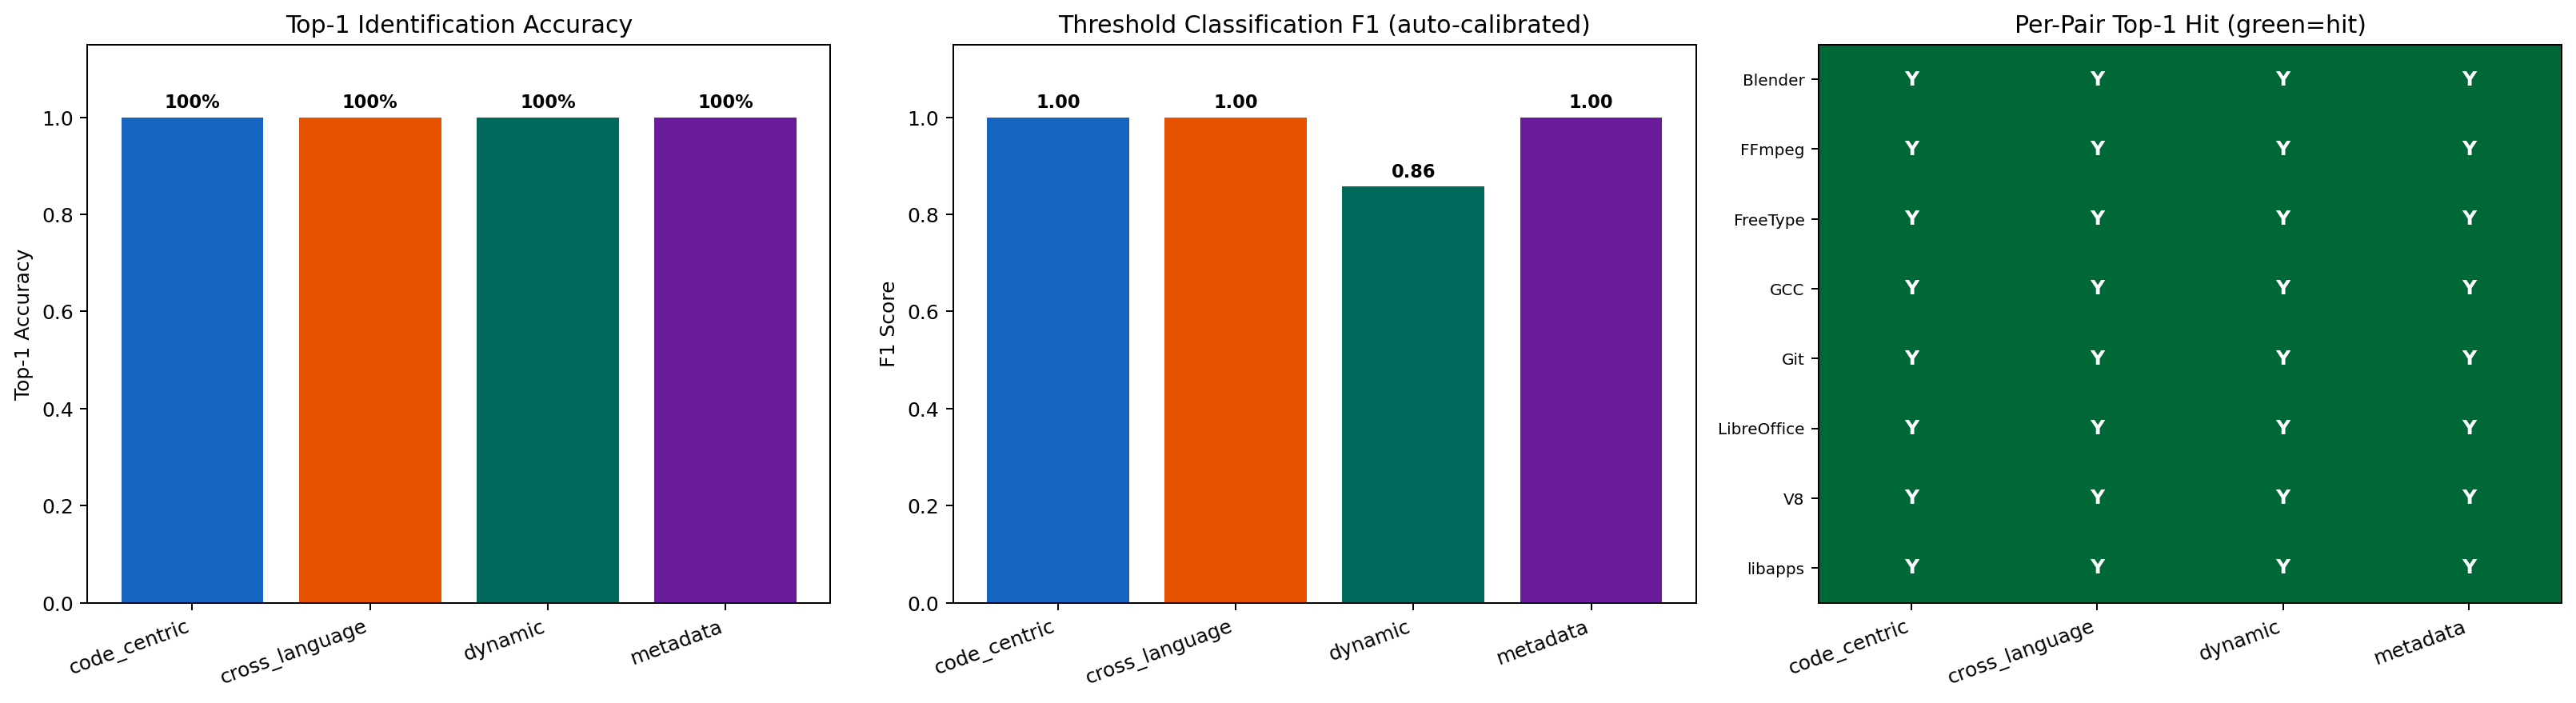


known_mirror_benchmark_threshold_accuracy.png


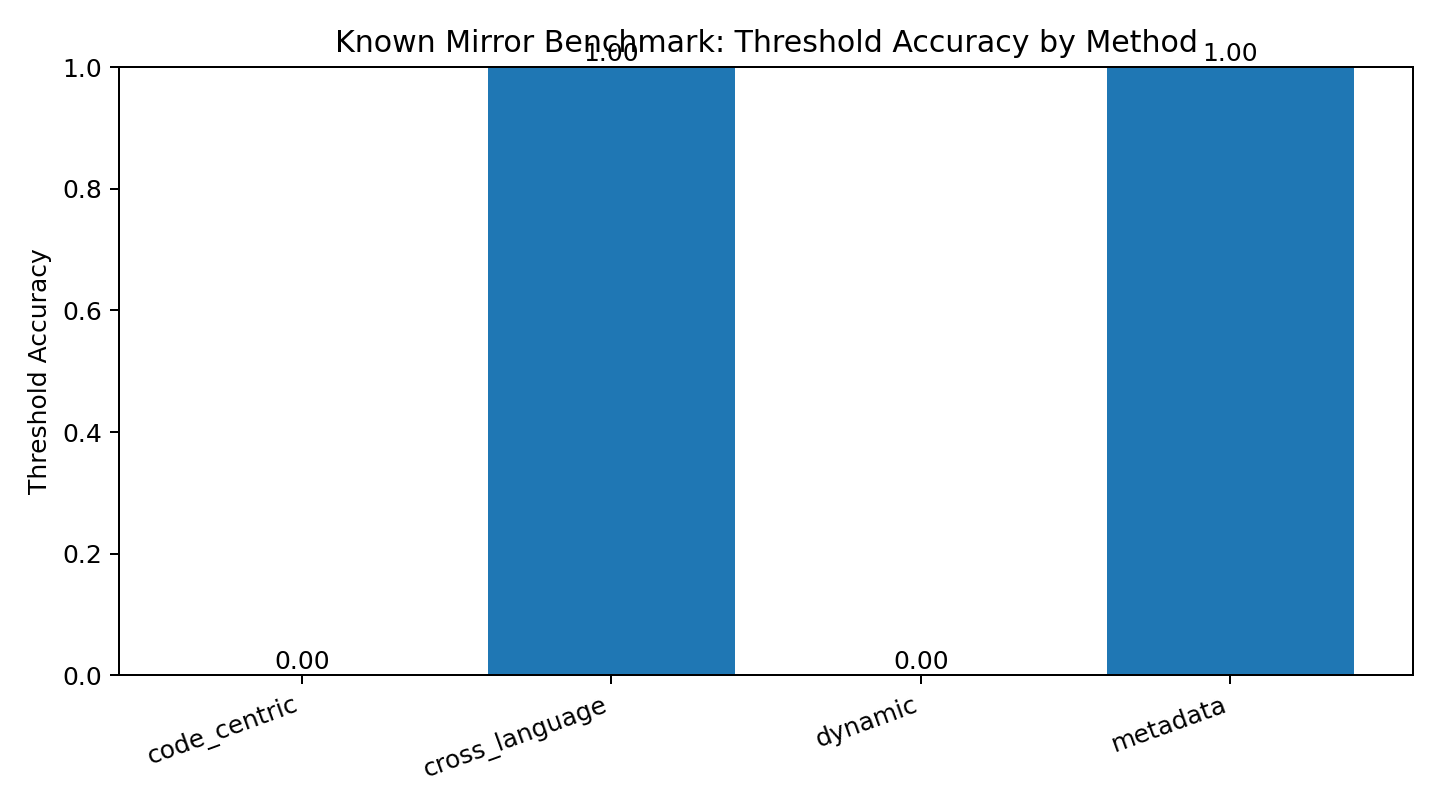


known_mirror_benchmark_top1_accuracy.png


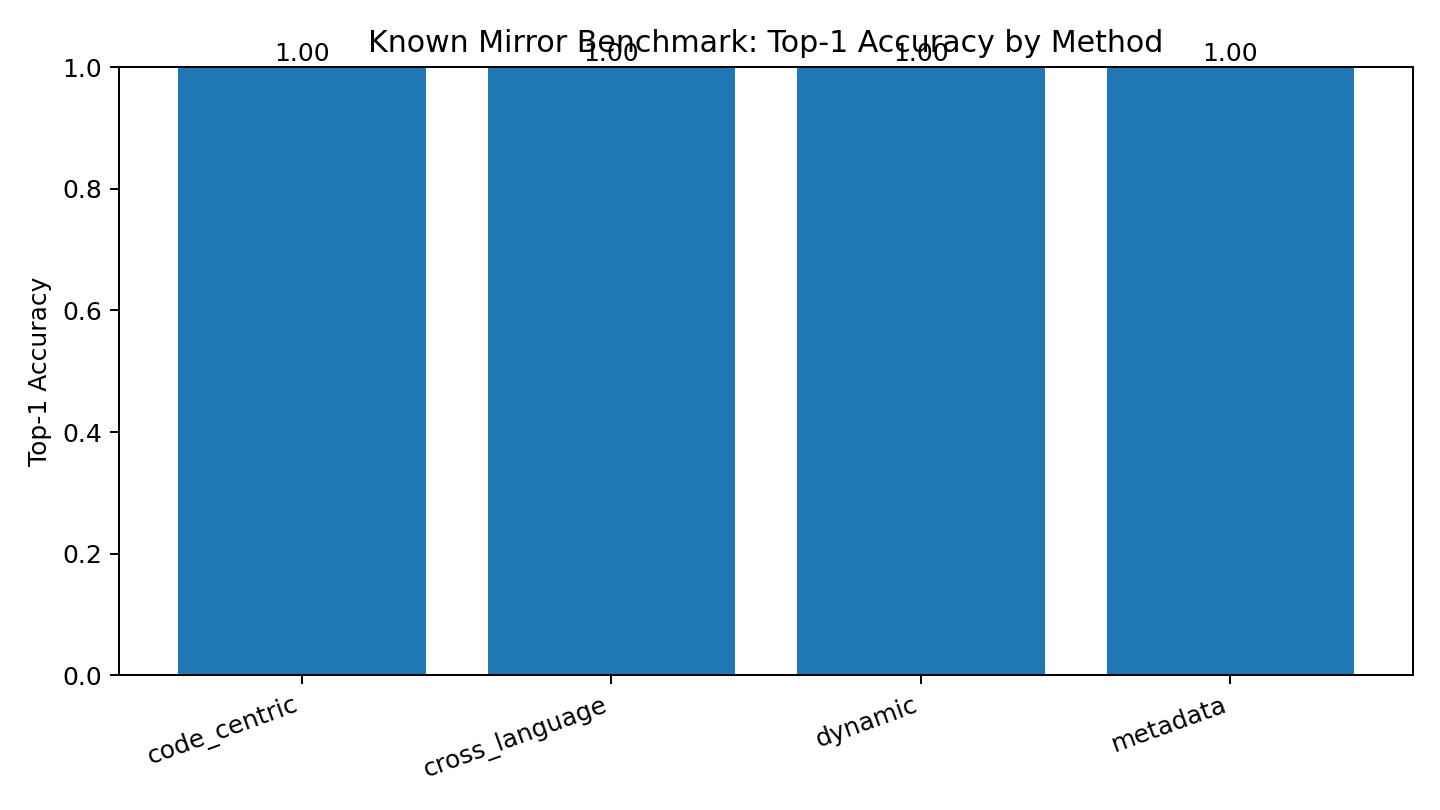

In [68]:
from pathlib import Path
from IPython.display import Image, display

results_dir = Path("results_benchmark")
plots = [
    "known_mirror_benchmark_comparison.png",
    "known_mirror_benchmark_threshold_accuracy.png",
    "known_mirror_benchmark_top1_accuracy.png",
]

for name in plots:
    p = results_dir / name
    print(f"\n{name}")
    if p.exists():
        display(Image(filename=str(p)))
    else:
        print(f"Missing: {p}")


## Continuous-Score Evaluation (Mirror vs Non-Mirror)

Goal:
- Evaluate all four methods using **continuous similarity scores** (not only hit/miss).
- Run on two cohorts:
  1. **Mirror pairs** (known upstream↔mirror identity; expected to be near-perfect for metadata).
  2. **Non-mirror functional pairs** (highly similar purpose/behavior, independent Git histories).

Outputs:
- Per-pair continuous score tables (percentage form).
- Top-1 match percentages per method for mirror vs non-mirror cohorts.
- Average true-match score (%) per method for both cohorts.

In [69]:
def run_continuous_score_cohort(
    pair_defs: List[Tuple[str, str, str, List[str]]],
    token: Optional[str] = None,
    max_commits: int = 150,
) -> Tuple[pd.DataFrame, Dict[str, object]]:
    """Run side_by_side_comparison on custom pair definitions and return row-level scores.

    pair_defs entries:
      (pair_name, query_url, true_match_url, negatives)
    """
    token = token or github_token

    rows: List[Dict[str, object]] = []
    raw: Dict[str, object] = {}

    for pair_name, query_url, true_match_url, negatives in pair_defs:
        candidates = [true_match_url] + [n for n in negatives if n != true_match_url]

        result = side_by_side_comparison(
            domain_key=None,
            query_url=query_url,
            true_match_url=true_match_url,
            candidates=candidates,
            max_commits=max_commits,
            token=token,
            make_plots=False,
        )
        raw[pair_name] = result

        scores = result["similarity_scores"]
        for method, score_map in scores.items():
            ranked = sorted(score_map.items(), key=lambda t: t[1], reverse=True)
            rank_map = {repo: i + 1 for i, (repo, _) in enumerate(ranked)}
            for cand, score in score_map.items():
                rows.append({
                    "pair": pair_name,
                    "query": query_url,
                    "true_match": true_match_url,
                    "candidate": cand,
                    "method": method,
                    "score": float(score),
                    "score_pct": float(score) * 100.0,
                    "rank": int(rank_map.get(cand, 9999)),
                    "matched": bool(cand == true_match_url),
                    "top1_hit": bool(rank_map.get(true_match_url, 9999) == 1),
                })

    return pd.DataFrame(rows), raw


def summarize_continuous_scores(df: pd.DataFrame, cohort_name: str) -> pd.DataFrame:
    """Method-level percentage summary for a cohort."""
    if df.empty:
        return pd.DataFrame()

    out = (
        df.groupby("method", as_index=False)
          .apply(lambda g: pd.Series({
              "n_pairs": int(g["pair"].nunique()),
              "top1_accuracy_pct": 100.0 * g[["pair", "top1_hit"]].drop_duplicates()["top1_hit"].mean(),
              "avg_true_match_score_pct": g[g["matched"]]["score_pct"].mean(),
              "avg_false_match_score_pct": g[~g["matched"]]["score_pct"].mean(),
              "score_gap_pct": g[g["matched"]]["score_pct"].mean() - g[~g["matched"]]["score_pct"].mean(),
          }))
          .reset_index(drop=True)
    )
    out.insert(0, "cohort", cohort_name)
    return out.sort_values("method").reset_index(drop=True)


def print_pair_tables(df: pd.DataFrame, cohort_name: str) -> None:
    """Print one continuous-score table per pair."""
    if df.empty:
        print(f"No rows for {cohort_name}")
        return

    print("\n" + "=" * 110)
    print(f"PER-PAIR CONTINUOUS SCORE TABLES :: {cohort_name}")
    print("=" * 110)

    for pair in sorted(df["pair"].unique().tolist()):
        g = df[df["pair"] == pair].copy()
        pivot_score = g.pivot_table(index=["candidate", "matched"], columns="method", values="score_pct", aggfunc="first")
        pivot_rank = g.pivot_table(index=["candidate", "matched"], columns="method", values="rank", aggfunc="first")

        # Rename columns for readability
        pivot_score = pivot_score.rename(columns={
            "metadata": "MetaMatch (%)",
            "code_centric": "CodeCentric (%)",
            "dynamic": "Dynamic (%)",
            "cross_language": "CrossLang (%)",
        })
        pivot_rank = pivot_rank.rename(columns={
            "metadata": "MetaRank",
            "code_centric": "CodeRank",
            "dynamic": "DynamicRank",
            "cross_language": "CrossLangRank",
        })

        tbl = pivot_score.join(pivot_rank, how="left").reset_index()
        tbl = tbl.sort_values(by=["MetaRank", "candidate"], na_position="last")

        print(f"\n{'-' * 110}")
        print(f"Pair: {pair}")
        print(f"{'-' * 110}")
        print(tbl.round(2).to_string(index=False))

In [70]:
# --- Cohort A: Mirror pairs (known identity) ---
mirror_pair_defs = [
    (
        p["name"],
        str(p["upstream_url"]),
        str(p["mirror_url"]),
        [str(x) for x in list(p.get("negatives", []))],
    )
    for p in KNOWN_MIRROR_PAIRS
]

mirror_df, mirror_raw = run_continuous_score_cohort(
    mirror_pair_defs,
    token=github_token,
    max_commits=150,
)
mirror_summary = summarize_continuous_scores(mirror_df, "mirror")

print_pair_tables(mirror_df, "mirror")
print("\nMirror cohort summary (%):")
print(mirror_summary.round(2).to_string(index=False))


SIDE-BY-SIDE COMPARISON: https://chromium.googlesource.com/v8/v8.git
Query: https://chromium.googlesource.com/v8/v8.git

  Shallow clone (depth=200) https://chromium.googlesource.com/v8/v8.git ...
  Failed to fetch https://chromium.googlesource.com/v8/v8.git: not enough values to unpack (expected 3, got 1)
  Fetching commits from v8/v8...


Commits: 150c [01:19,  1.88c/s, fetched=150]


  Fetching commits from nicmcd/libprim...


Commits: 14c [00:08,  1.66c/s, fetched=14]


  Failed to fetch https://github.com/nicmcd/libprim: ('Connection aborted.', RemoteDisconnected('Remote end closed connection without response'))
  Fetching commits from nicmcd/libfactory...


...

  Fetching commits from mltframework/mlt...


Commits: 150c [01:25,  1.75c/s, fetched=150]


  Fetching commits from HandBrake/HandBrake...


Commits: 150c [01:25,  1.75c/s, fetched=150]


Candidate                                       Metadata  CodeClone Behavioral   DeepCode
-----------------------------------------------------------------------------------------
FFmpeg/FFmpeg                                     0.5190     0.0000     0.5000     0.0061
GStreamer/gstreamer                               0.4570     0.0000     0.5000     0.1011
mltframework/mlt                                  0.4081     0.0000     0.2500     0.0038
HandBrake/HandBrake                               0.4383     0.0000     0.0000     0.1034

PER-PAIR CONTINUOUS SCORE TABLES :: mirror

--------------------------------------------------------------------------------------------------------------
Pair: Blender
--------------------------------------------------------------------------------------------------------------
                                   candidate  matched  CodeCentric (%)  CrossLang (%)  Dynamic (%)  MetaMatch (%)  CodeRank  CrossLangRank  DynamicRank  MetaRank
          https:/

In [71]:
# --- Cohort B: Non-mirror functional pairs (independent histories) ---
# You can add more from prior tests.
non_mirror_pair_defs = [
    (
        "tensorflow_vs_pytorch",
        "https://github.com/tensorflow/tensorflow",
        "https://github.com/pytorch/pytorch",
        [
            "https://github.com/scikit-learn/scikit-learn",
            "https://github.com/keras-team/keras",
            "https://github.com/google/jax",
            "https://github.com/django/django",
        ],
    ),
    (
        "vscode_vs_electron",
        "https://github.com/microsoft/vscode",
        "https://github.com/electron/electron",
        [
            "https://github.com/eclipse-theia/theia",
            "https://github.com/neovim/neovim",
            "https://github.com/zed-industries/zed",
            "https://github.com/django/django",
        ],
    ),
    (
        "openpilot_vs_autoware",
        "https://github.com/commaai/openpilot",
        "https://github.com/autowarefoundation/autoware",
        [
            "https://github.com/ApolloAuto/apollo",
            "https://github.com/ArduPilot/ardupilot",
            "https://github.com/django/django",
        ],
    ),
]

non_mirror_df, non_mirror_raw = run_continuous_score_cohort(
    non_mirror_pair_defs,
    token=github_token,
    max_commits=150,
)
non_mirror_summary = summarize_continuous_scores(non_mirror_df, "non_mirror")

print_pair_tables(non_mirror_df, "non_mirror")
print("\nNon-mirror cohort summary (%):")
print(non_mirror_summary.round(2).to_string(index=False))


SIDE-BY-SIDE COMPARISON: tensorflow/tensorflow
Query: https://github.com/tensorflow/tensorflow

  Fetching commits from google/jax...


Commits: 150c [01:47,  1.40c/s, fetched=150]


Candidate                                       Metadata  CodeClone Behavioral   DeepCode
-----------------------------------------------------------------------------------------
pytorch/pytorch                                   0.5639     0.3596     0.5000     0.6400
scikit-learn/scikit-learn                         0.4532     0.2647     0.4167     0.5393
keras-team/keras                                  0.4527     0.2955     0.5000     0.5012
google/jax                                        0.5582     0.3153     0.5000     0.3660
django/django                                     0.3454     0.2550     0.2500     0.1171

SIDE-BY-SIDE COMPARISON: microsoft/vscode
Query: https://github.com/microsoft/vscode

  Fetching commits from eclipse-theia/theia...


Commits: 150c [01:27,  1.72c/s, fetched=150]


Candidate                                       Metadata  CodeClone Behavioral   DeepCode
-----------------------------------------------------------------------------------------
electron/electron                                 0.6519     0.2639     0.4167     0.5128
eclipse-theia/theia                               0.5972     0.4979     1.0000     0.5291
neovim/neovim                                     0.5295     0.0487     0.5000     0.4574
zed-industries/zed                                0.6856     0.0663     0.7500     0.4971
django/django                                     0.4354     0.0504     0.2550     0.0019

SIDE-BY-SIDE COMPARISON: commaai/openpilot
Query: https://github.com/commaai/openpilot

  Fetching commits from autowarefoundation/autoware...


...

  Fetching commits from ApolloAuto/apollo...


Commits: 150c [02:08,  1.17c/s, fetched=150]


  Fetching commits from ArduPilot/ardupilot...


Commits: 150c [01:21,  1.83c/s, fetched=150]


Candidate                                       Metadata  CodeClone Behavioral   DeepCode
-----------------------------------------------------------------------------------------
autowarefoundation/autoware                       0.7503     0.0688     0.2500     0.6273
ApolloAuto/apollo                                 0.4837     0.2738     0.0000     0.3740
ArduPilot/ardupilot                               0.7073     0.3385     0.5000     0.4411
django/django                                     0.7869     0.3851     0.2550     0.0091

PER-PAIR CONTINUOUS SCORE TABLES :: non_mirror

--------------------------------------------------------------------------------------------------------------
Pair: openpilot_vs_autoware
--------------------------------------------------------------------------------------------------------------
                                     candidate  matched  CodeCentric (%)  CrossLang (%)  Dynamic (%)  MetaMatch (%)  CodeRank  CrossLangRank  DynamicRank  MetaRa

In [72]:
# Combined summary table: mirror vs non-mirror
combined_summary = pd.concat([mirror_summary, non_mirror_summary], ignore_index=True)
print("\n" + "=" * 110)
print("COMBINED METHOD SUMMARY (% match metrics)")
print("=" * 110)
print(combined_summary.round(2).to_string(index=False))

# Save CSVs for slide-ready tables
results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)
mirror_df.to_csv(results_dir / "continuous_scores_mirror_per_candidate.csv", index=False)
non_mirror_df.to_csv(results_dir / "continuous_scores_non_mirror_per_candidate.csv", index=False)
combined_summary.to_csv(results_dir / "continuous_scores_summary.csv", index=False)
print("\nSaved:")
print("- results_benchmark/continuous_scores_mirror_per_candidate.csv")
print("- results_benchmark/continuous_scores_non_mirror_per_candidate.csv")
print("- results_benchmark/continuous_scores_summary.csv")


COMBINED METHOD SUMMARY (% match metrics)
    cohort         method  n_pairs  top1_accuracy_pct  avg_true_match_score_pct  avg_false_match_score_pct  score_gap_pct
    mirror   code_centric      8.0             100.00                      0.00                       0.00           0.00
    mirror cross_language      8.0              12.50                      3.67                       5.51          -1.84
    mirror        dynamic      8.0              87.50                     43.75                      19.79          23.96
    mirror       metadata      8.0              62.50                     53.21                      45.43           7.78
non_mirror   code_centric      3.0              33.33                     23.08                      25.38          -2.30
non_mirror cross_language      3.0              66.67                     59.33                      34.85          24.48
non_mirror        dynamic      3.0              33.33                     38.89                      44

## Three-Test Argument Tables (Percentage Match by Method)

This section formats results exactly as required:

- **Test 1 (Known mirrors / known identity):** Known similarity is fixed at **100%**.
- **Test 2 (Functional-similar, independent histories):** Known similarity is treated as **100% expected-similar**.
- **Test 3 (Known dissimilar pairs):** Known similarity is fixed at **0%**.

Each table row is one test pair; method columns show continuous similarity percentages.

## Duplicate `_method_score_percent_for_target` (disabled)

This cell duplicated the scoring helper and could overwrite the patch cell if run later.

Use definitions from patch cell **`04d42f36`** only.


In [73]:
DEFAULT_METADATA_HARD_NEGATIVES = [
    "https://github.com/django/django",
    "https://github.com/facebook/react",
    "https://github.com/tensorflow/tensorflow",
    "https://github.com/vim/vim",
]

DOMAIN_HARD_NEGATIVE_POOLS = {
    "ml": [
        "https://github.com/keras-team/keras",
        "https://github.com/dmlc/xgboost",
        "https://github.com/apache/spark",
        "https://github.com/scikit-learn/scikit-learn",
    ],
    "infra": [
        "https://github.com/kubernetes/kubernetes",
        "https://github.com/ansible/ansible",
        "https://github.com/prometheus/prometheus",
        "https://github.com/elastic/elasticsearch",
    ],
    "app": [
        "https://github.com/facebook/react",
        "https://github.com/django/django",
        "https://github.com/electron/electron",
        "https://github.com/Homebrew/brew",
    ],
    "systems": [
        "https://github.com/golang/go",
        "https://github.com/vim/vim",
        "https://github.com/bitcoin/bitcoin",
        "https://github.com/tensorflow/tensorflow",
    ],
}

DOMAIN_KEYWORDS = {
    "ml": ["tensorflow", "pytorch", "scikit", "xgboost", "monai", "keras", "llm", "langchain", "vllm"],
    "infra": ["kubernetes", "prometheus", "ansible", "elastic", "docker", "terraform"],
    "app": ["react", "django", "electron", "next", "frontend", "web"],
    "systems": ["golang", "linux", "compiler", "kernel", "vim", "bitcoin"],
}


def _infer_domain_key_from_url(repo_url: str) -> str:
    slug = (_repo_slug(repo_url) or "").lower()
    for domain, kws in DOMAIN_KEYWORDS.items():
        if any(kw in slug for kw in kws):
            return domain
    return "app"


def _get_domain_hard_negatives(query_url: str, target_url: str, limit: int = REDUX3_DOMAIN_NEGATIVE_LIMIT) -> List[str]:
    qd = _infer_domain_key_from_url(query_url)
    td = _infer_domain_key_from_url(target_url)
    pool: List[str] = []
    for k in [qd, td, "ml", "infra", "app", "systems"]:
        pool.extend(DOMAIN_HARD_NEGATIVE_POOLS.get(k, []))
    pool.extend(DEFAULT_METADATA_HARD_NEGATIVES)
    pool = _filter_metadata_pool_urls(query_url, target_url, pool)
    return list(dict.fromkeys(pool))[:max(1, int(limit))]

TEST3_METADATA_HARD_NEGATIVES = [
    "https://github.com/django/django",
    "https://github.com/facebook/react",
    "https://github.com/tensorflow/tensorflow",
    "https://github.com/vim/vim",
    "https://github.com/keras-team/keras",
    "https://github.com/elastic/elasticsearch",
    "https://github.com/prometheus/prometheus",
    "https://github.com/bitcoin/bitcoin",
    "https://github.com/Homebrew/brew",
    "https://github.com/golang/go",
    "https://github.com/ansible/ansible",
    "https://github.com/apache/spark",
]


def build_argument_table(
    pair_defs: List[Tuple[str, str, str]],
    known_similarity_pct: float,
    token: Optional[str] = None,
    max_commits: int = 150,
    metadata_windows: Optional[List[int]] = None,
    metadata_window_weights: Optional[Dict[int, float]] = None,
    metadata_weights: Optional[str] = None,
    metadata_extra_candidates: Optional[List[str]] = None,
    metadata_scoring_mode: str = "family_cosine",
    family_score_norm: str = "raw_cosine",
    normalization_mode: str = "global_minmax",
    pairwise_scoring: bool = True,
    include_alt_metadata: bool = False,
    reporting_mode: str = REDUX3_DEFAULT_REPORTING_RETRIEVAL,
    coverage_penalty_lambda: float = REDUX3_COVERAGE_PENALTY_LAMBDA,
    use_domain_hard_negatives: bool = True,
) -> pd.DataFrame:
    """Build a table: Test, Known similarity, Metadata, Code centric, Dynamic, Cross language.

    REDUX_3 defaults favor strict discrimination with contrastive reporting and domain-aware negatives.
    """
    rows = []
    for test_name, query_url, target_url in pair_defs:
        scores = _method_score_percent_for_target(
            query_url,
            target_url,
            token=token,
            max_commits=max_commits,
            metadata_windows=metadata_windows or REDUX3_METADATA_WINDOWS,
            metadata_window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
            metadata_weights=metadata_weights,
            metadata_extra_candidates=metadata_extra_candidates,
            include_alt_metadata=include_alt_metadata,
            normalization_mode=normalization_mode,
            pairwise_scoring=pairwise_scoring,
            metadata_scoring_mode=metadata_scoring_mode,
            family_score_norm=family_score_norm,
            reporting_mode=reporting_mode,
            coverage_penalty_lambda=coverage_penalty_lambda,
            use_domain_hard_negatives=use_domain_hard_negatives,
        )
        rows.append({
            "Test": test_name,
            "Known similarity": f"{known_similarity_pct:.0f}%",
            "Metadata": scores["Metadata"],
            "Code centric": scores["Code centric"],
            "Dynamic": scores["Dynamic"],
            "Cross language": scores["Cross language"],
            "Query": query_url,
            "Target": target_url,
        })
    return pd.DataFrame(rows)


In [74]:
import re
import shutil


def _canonical_github_repo_url(s: str) -> str:
    raw = str(s).strip()
    if not raw:
        raise ValueError("empty repo specifier")
    if raw.lower().startswith(("https://github.com/", "http://github.com/")):
        m = re.match(r"https?://github\.com/([^/]+)/([^/]+?)(?:\.git)?/?$", raw.rstrip("/"), re.I)
        if not m:
            raise ValueError(f"not a valid GitHub repo URL: {raw!r}")
        name = m.group(2).removesuffix(".git")
        return f"https://github.com/{m.group(1)}/{name}"
    if "/" in raw:
        owner, name = raw.split("/", 1)
        name = name.removesuffix(".git").strip("/")
        return f"https://github.com/{owner.strip('/')}/{name}"
    raise ValueError(f"expected owner/repo or github.com URL, got: {raw!r}")


def _load_custom_pairs(path: str = "30_Pairs.json") -> List[Dict[str, object]]:
    with Path(path).open(encoding="utf-8-sig") as f:
        payload = json.load(f)
    pairs = payload["pairs"] if isinstance(payload, dict) and "pairs" in payload else payload
    assert len(pairs) == 30, f"expected 30 pairs, got {len(pairs)}"
    return pairs


def _collect_pair_repo_urls(pairs: List[Dict[str, object]]) -> List[str]:
    urls = []
    for p in pairs:
        ra = str(p.get("RepoA", "")).strip()
        rb = str(p.get("RepoB", "")).strip()
        if ra:
            urls.append(_canonical_github_repo_url(ra))
        if rb:
            urls.append(_canonical_github_repo_url(rb))
    return sorted(set(urls))


def fit_global_minmax_for_all_benchmark_tables(
    pairs_path: str = "30_Pairs.json",
    max_commits: int = 150,
) -> None:
    """Fit one global min-max normalizer over 30-pair repos plus control pairs."""
    clear_global_normalizers()
    urls = set(_collect_pair_repo_urls(_load_custom_pairs(pairs_path)))
    for p in KNOWN_MIRROR_PAIRS:
        urls.add(_canonical_github_repo_url(str(p["mirror_url"])))

    functional = [
        ("https://github.com/tensorflow/tensorflow", "https://github.com/pytorch/pytorch"),
        ("https://github.com/microsoft/vscode", "https://github.com/electron/electron"),
        ("https://github.com/commaai/openpilot", "https://github.com/autowarefoundation/autoware"),
        ("https://github.com/Project-MONAI/MONAI", "https://github.com/tensorflow/tensorflow"),
    ]
    dissimilar = [
        ("https://github.com/tensorflow/tensorflow", "https://github.com/django/django"),
        ("https://github.com/microsoft/vscode", "https://github.com/dmlc/xgboost"),
        ("https://github.com/commaai/openpilot", "https://github.com/scikit-learn/scikit-learn"),
        ("https://github.com/Project-MONAI/MONAI", "https://github.com/electron/electron"),
    ]
    for qu, tu in functional + dissimilar:
        urls.add(_canonical_github_repo_url(qu))
        urls.add(_canonical_github_repo_url(tu))

    fit_global_normalizer(
        sorted(urls),
        metrics=CAIS_METRICS,
        token=github_token,
        max_commits=max_commits,
        strategy="minmax",
    )
    print(f"Global min-max normalizer fit on {len(urls)} unique repos.")


In [75]:
# === Reliability + Discrimination Patch Overrides (research-safe defaults) ===

import math
import time
from collections import Counter
from typing import Dict, List, Optional, Tuple

# Lightweight diagnostics (used by benchmark/reporting)
BASELINE_COVERAGE: Dict[str, Dict[str, float]] = {}
API_FAIL_COUNT = 0


def _gh_get(path: str, token: Optional[str] = None, retries: int = 2, backoff: float = 1.5) -> dict:
    """GitHub GET with small retry/backoff and explicit failures."""
    global API_FAIL_COUNT
    headers = {"Accept": "application/vnd.github.v3+json"}
    if token:
        headers["Authorization"] = f"Bearer {token}"

    last_err = None
    for attempt in range(retries + 1):
        try:
            r = requests.get(f"{_GH_API}{path}", headers=headers, timeout=30)
            if r.status_code in (429, 500, 502, 503, 504):
                raise requests.HTTPError(f"{r.status_code}: {r.text[:200]}")
            r.raise_for_status()
            return r.json()
        except Exception as e:
            last_err = e
            if attempt < retries:
                time.sleep(backoff ** attempt)
            else:
                API_FAIL_COUNT += 1
    raise last_err


def _repo_tree_paths(slug: str, token: Optional[str] = None, limit: int = 300) -> List[str]:
    """Resolve default branch -> commit tree SHA -> recursive tree paths."""
    try:
        repo = _gh_get(f"/repos/{slug}", token)
        default_branch = repo.get("default_branch", "main")
        commit = _gh_get(f"/repos/{slug}/commits/{default_branch}", token)
        tree_sha = commit.get("commit", {}).get("tree", {}).get("sha")
        if not tree_sha:
            return []
        data = _gh_get(f"/repos/{slug}/git/trees/{tree_sha}?recursive=1", token)
        return [t.get("path", "") for t in data.get("tree", [])[:limit] if t.get("path")]
    except Exception:
        return []


def code_clone_similarity(
    query: str,
    candidates: List[str],
    token: Optional[str] = None,
) -> List[Tuple[str, float]]:
    """Code-centric similarity with coverage-aware component renormalization."""
    q_slug = _repo_slug(query)
    q_langs = _repo_languages(q_slug, token)
    q_topics = set(_repo_topics(q_slug, token))
    q_paths = _repo_tree_paths(q_slug, token)
    q_exts = Counter(p.rsplit(".", 1)[-1].lower() for p in q_paths if "." in p)
    q_dirs = Counter(p.split("/")[0].lower() for p in q_paths if "/" in p)

    results = []
    for c in candidates:
        c_slug = _repo_slug(c)
        c_langs = _repo_languages(c_slug, token)
        c_topics = set(_repo_topics(c_slug, token))
        c_paths = _repo_tree_paths(c_slug, token)
        c_exts = Counter(p.rsplit(".", 1)[-1].lower() for p in c_paths if "." in p)
        c_dirs = Counter(p.split("/")[0].lower() for p in c_paths if "/" in p)

        comps = {}
        weights = {}

        all_langs = set(q_langs) | set(c_langs)
        if all_langs:
            a = [q_langs.get(l, 0) for l in all_langs]
            b = [c_langs.get(l, 0) for l in all_langs]
            comps["lang"] = cosine(a, b)
            weights["lang"] = 0.35

        ext_keys = set(q_exts) | set(c_exts)
        if ext_keys:
            comps["ext"] = len(set(q_exts) & set(c_exts)) / max(len(ext_keys), 1)
            weights["ext"] = 0.25

        dir_keys = set(q_dirs) | set(c_dirs)
        if dir_keys:
            comps["dir"] = len(set(q_dirs) & set(c_dirs)) / max(len(dir_keys), 1)
            weights["dir"] = 0.20

        topic_keys = q_topics | c_topics
        if topic_keys:
            comps["topic"] = len(q_topics & c_topics) / max(len(topic_keys), 1)
            weights["topic"] = 0.20

        total_w = sum(weights.values())
        if total_w <= 0:
            sim = 0.0
            coverage = 0.0
        else:
            sim = sum(weights[k] * comps[k] for k in comps) / total_w
            coverage = total_w / (0.35 + 0.25 + 0.20 + 0.20)

        BASELINE_COVERAGE[c] = BASELINE_COVERAGE.get(c, {})
        BASELINE_COVERAGE[c]["cc_coverage"] = float(round(coverage, 4))
        results.append((c, float(sim)))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


def dynamic_behavior_similarity(
    query: str,
    candidates: List[str],
    token: Optional[str] = None,
) -> List[Tuple[str, float]]:
    """Behavioral similarity with reduced 0.50 fallback bias and coverage tracking."""

    def _signals(slug):
        readme = _repo_readme_text(slug, token).lower()
        paths = _repo_tree_paths(slug, token)
        path_text = " ".join(paths).lower()
        test_hits = set(_TEST_FRAMEWORKS.findall(readme + " " + path_text))
        has_ci = any(k in path_text for k in [".github/workflows", ".travis", "jenkinsfile", ".circleci"])
        bug_missing = False
        try:
            issues = _gh_get(f"/repos/{slug}/issues?state=all&per_page=50&labels=bug", token)
            bug_count = len(issues) if isinstance(issues, list) else 0
        except Exception:
            bug_count = 0
            bug_missing = True
        return {
            "test_frameworks": test_hits,
            "has_ci": has_ci,
            "bug_issues": bug_count,
            "paths_present": bool(paths),
            "bug_missing": bug_missing,
        }

    q_sig = _signals(_repo_slug(query))
    results = []
    for c in candidates:
        c_sig = _signals(_repo_slug(c))

        all_tests = q_sig["test_frameworks"] | c_sig["test_frameworks"]
        tf_jaccard = len(q_sig["test_frameworks"] & c_sig["test_frameworks"]) / max(len(all_tests), 1)

        # if neither side has path evidence, ci contributes neutral (0.5) not perfect match (1.0)
        if (not q_sig["paths_present"]) and (not c_sig["paths_present"]):
            ci_score = 0.5
        else:
            ci_score = 1.0 if q_sig["has_ci"] == c_sig["has_ci"] else 0.0

        # if both bug data unavailable/zero, keep neutral instead of perfect
        if (q_sig["bug_missing"] and c_sig["bug_missing"]) or (q_sig["bug_issues"] == 0 and c_sig["bug_issues"] == 0):
            bug_sim = 0.5
        else:
            max_bugs = max(q_sig["bug_issues"], c_sig["bug_issues"], 1)
            bug_sim = 1.0 - abs(q_sig["bug_issues"] - c_sig["bug_issues"]) / max_bugs

        # higher emphasis on framework overlap, less on binary indicators
        sim = 0.70 * tf_jaccard + 0.15 * ci_score + 0.15 * bug_sim

        coverage = 0.0
        coverage += 0.50 if len(all_tests) > 0 else 0.0
        coverage += 0.25 if (q_sig["paths_present"] or c_sig["paths_present"]) else 0.0
        coverage += 0.25 if not (q_sig["bug_missing"] and c_sig["bug_missing"]) else 0.0

        BASELINE_COVERAGE[c] = BASELINE_COVERAGE.get(c, {})
        BASELINE_COVERAGE[c]["dyn_coverage"] = float(round(coverage, 4))

        results.append((c, float(sim)))

    results.sort(key=lambda x: x[1], reverse=True)
    return results


def _family_cosine_score(
    q_vec: Dict[str, float],
    c_vec: Dict[str, float],
    feature_keys: List[str],
    fam_weights: Dict[str, float],
    family_score_norm: str = "raw_cosine",
    min_family_keys: int = 2,
    coverage_penalty_lambda: float = REDUX3_COVERAGE_PENALTY_LAMBDA,
) -> Tuple[float, Dict[str, float], Dict[str, bool]]:
    """Family-level scoring with explicit norm modes and coverage penalty."""
    raw_scores: Dict[str, float] = {}
    family_present: Dict[str, bool] = {}

    weighted_sum_raw = 0.0
    weight_total = 0.0
    covered_weight = 0.0

    for fam, _prefixes in FAMILY_FEATURE_PREFIXES.items():
        fam_keys = _keys_for_family(feature_keys, fam)
        present = len(fam_keys) >= min_family_keys
        family_present[fam] = present
        s = _safe_cosine_from_keys(q_vec, c_vec, fam_keys) if present else 0.0
        raw_scores[fam] = s

        w_key = FAMILY_TO_WEIGHT_KEY[fam]
        w = float(fam_weights.get(w_key, 1.0))
        if w <= 0:
            continue
        weight_total += w
        if present:
            covered_weight += w
            weighted_sum_raw += w * s

    if covered_weight <= 1e-12:
        return 0.0, raw_scores, family_present

    raw_combined = weighted_sum_raw / covered_weight

    if family_score_norm == "cosine_to_unit":
        combined = (raw_combined + 1.0) / 2.0
    elif family_score_norm == "raw_cosine":
        combined = raw_combined
    elif family_score_norm == "temperature":
        temp = 2.0
        combined = math.tanh(raw_combined / temp)
    else:
        raise ValueError(f"Unknown family_score_norm: {family_score_norm}")

    coverage_ratio = covered_weight / max(weight_total, 1e-12)
    penalized = combined - coverage_penalty_lambda * (1.0 - coverage_ratio)

    if family_score_norm == "raw_cosine":
        final_score = max(0.0, min(1.0, (penalized + 1.0) / 2.0))
    else:
        final_score = max(0.0, min(1.0, penalized))

    return final_score, raw_scores, family_present


def _contrastive_adjust(raw_score: float, neg_scores: List[float]) -> float:
    """Contrastive reporting score: compare against median hard-negative score."""
    if not neg_scores:
        return raw_score
    baseline = float(np.median(neg_scores))
    delta = raw_score - baseline
    return float(1.0 / (1.0 + np.exp(-6.0 * delta)))


def _metadata_similarity(
    query: str,
    candidates: List[str],
    token: Optional[str] = None,
    max_commits: int = 150,
    windows: Optional[List[int]] = None,
    weights: Optional[str] = None,
    normalization_mode: str = "global_minmax",
    pairwise_scoring: bool = True,
    scoring_mode: str = "weighted_cosine",
    family_score_norm: str = "raw_cosine",
    coverage_penalty_lambda: float = REDUX3_COVERAGE_PENALTY_LAMBDA,
    window_weights: Optional[Dict[int, float]] = None,
):
    token = token or github_token
    weights = weights or CAIS_WEIGHTS_STRICT
    windows = windows or REDUX3_METADATA_WINDOWS
    window_weights = window_weights or REDUX3_WINDOW_WEIGHTS

    score_accum = {c: [] for c in candidates}
    family_detail: Dict[str, Dict[str, float]] = {c: {} for c in candidates}

    for w in windows:
        cap = min(int(w), int(max_commits))
        if cap < 1:
            continue

        args = _build_compare_args(
            query=query,
            candidates=candidates,
            metrics=CAIS_METRICS,
            cais_profile_path=None,
            max_commits=cap,
            weights=weights,
            normalization_mode=normalization_mode,
            pairwise_scoring=pairwise_scoring,
        )
        args.github_token = token

        if scoring_mode == "weighted_cosine":
            ranked = get_pairwise_similarity(args) if pairwise_scoring else get_ranked_similarity(args)
        elif scoring_mode == "family_cosine":
            metric_list = [m.strip() for m in CAIS_METRICS.split(",")]
            repos = [query] + candidates
            vecs: List[Dict[str, float]] = []
            for r in repos:
                try:
                    vec = compute_features_for_repo(
                        r,
                        metric_list,
                        since=None,
                        until=None,
                        github_token=token,
                        max_commits=cap,
                    )
                    vecs.append(vec)
                except Exception:
                    vecs.append({})

            if len(vecs) < 2 or not any(vecs):
                ranked = []
            else:
                norm = _get_normalizer_for_mode(normalization_mode, vecs)
                normed = [norm.transform(v) for v in vecs]
                common_keys = set(normed[0].keys())
                for v in normed[1:]:
                    common_keys &= v.keys()
                feature_keys = sorted(common_keys)
                fam_weights = parse_weights(weights)
                q_vec = normed[0]
                ranked = []
                for i, c in enumerate(candidates, start=1):
                    c_vec = normed[i]
                    s, raw_fam, _present = _family_cosine_score(
                        q_vec=q_vec,
                        c_vec=c_vec,
                        feature_keys=feature_keys,
                        fam_weights=fam_weights,
                        family_score_norm=family_score_norm,
                        coverage_penalty_lambda=coverage_penalty_lambda,
                    )
                    family_detail[c] = raw_fam
                    ranked.append((c, float(s)))
                ranked.sort(key=lambda x: x[1], reverse=True)
        else:
            raise ValueError(f"Unknown scoring_mode: {scoring_mode}")

        ranked = ranked or []
        ranked_dict = {repo: score for repo, score in ranked}
        wgt = float(window_weights.get(int(w), 1.0)) if isinstance(window_weights, dict) else 1.0
        for c in candidates:
            score_accum[c].append((ranked_dict.get(c, 0.0), wgt))

    averaged = []
    for c, vals in score_accum.items():
        if not vals:
            averaged.append((c, 0.0))
            continue
        num = sum(float(v) * float(w) for v, w in vals)
        den = sum(float(w) for _v, w in vals)
        averaged.append((c, float(num / den) if den > 1e-12 else 0.0))

    # Only min-max when there are multiple candidates AND meaningful spread.
    if normalization_mode == "global_minmax" and len(averaged) > 1:
        vals = [s for _, s in averaged]
        lo, hi = min(vals), max(vals)
        if hi > lo:
            averaged = [(c, (s - lo) / (hi - lo)) for c, s in averaged]

    # expose explainability payload for downstream reporting
    _metadata_similarity.last_family_detail = family_detail

    averaged.sort(key=lambda x: x[1], reverse=True)
    return averaged


# small defaults for stricter evaluation protocol
STRICT_ONLY = True


def validate_pair_alignment(pair: Dict[str, object], token: Optional[str] = None) -> Dict[str, object]:
    """
    Alignment guardrail using git ls-remote for any upstream host.
    Strict mode: both resolve to same SHA.
    Fallback: if both sides respond but HEAD differs (mirror lag),
    include with 'documentation_backed' status when official_mirror_claim is True.
    """
    ref = str(pair.get("alignment_ref", "HEAD"))
    upstream_url = str(pair.get("upstream_url", ""))
    mirror_url = str(pair.get("mirror_url", ""))
    official = bool(pair.get("official_mirror_claim", False))

    print(f"  [{pair.get('name')}] resolving mirror ref '{ref}'...")
    mirror_sha = _resolve_ref(mirror_url, ref, token=token)
    if not mirror_sha:
        return {
            "include": False,
            "status": "excluded_unresolved_mirror_ref",
            "reason": f"Mirror ref '{ref}' could not be resolved",
            "mirror_sha": None, "upstream_sha": None,
        }

    print(f"  [{pair.get('name')}] resolving upstream ref '{ref}'...")
    upstream_sha = _resolve_ref(upstream_url, ref, token=token)
    if not upstream_sha:
        return {
            "include": False,
            "status": "excluded_unresolved_upstream_ref",
            "reason": f"Upstream ref '{ref}' unresolvable via API and git ls-remote",
            "mirror_sha": mirror_sha, "upstream_sha": None,
        }

    if upstream_sha == mirror_sha:
        print(f"  [{pair.get('name')}] aligned: {upstream_sha[:12]}")
        return {
            "include": True,
            "status": "aligned_strict_sha_match",
            "reason": f"Exact SHA match at ref '{ref}'",
            "mirror_sha": mirror_sha, "upstream_sha": upstream_sha,
        }

    if official:
        print(f"  [{pair.get('name')}] SHA differs (mirror lag) but official_mirror_claim=True -> included")
        return {
            "include": True,
            "status": "aligned_documentation_backed",
            "reason": f"SHA mismatch (mirror lag) but official_mirror_claim=True; "
                      f"upstream={upstream_sha[:12]} mirror={mirror_sha[:12]}",
            "mirror_sha": mirror_sha, "upstream_sha": upstream_sha,
        }

    return {
        "include": False,
        "status": "excluded_ref_mismatch",
        "reason": f"SHA mismatch and no official_mirror_claim: "
                  f"upstream={upstream_sha[:12]} mirror={mirror_sha[:12]}",
        "mirror_sha": mirror_sha, "upstream_sha": upstream_sha,
    }


def _as_rank_dict(ranked: List[Tuple[str, float]]) -> Dict[str, Tuple[int, float]]:
    return {repo: (i + 1, score) for i, (repo, score) in enumerate(ranked)}


def _filter_metadata_pool_urls(query_url: str, target_url: str, urls: List[str]) -> List[str]:
    """Drop hard-negative URLs that duplicate query or target GitHub slugs (avoids pool distortion)."""
    q = (_repo_slug(query_url) or "").lower()
    t = (_repo_slug(target_url) or "").lower()
    out: List[str] = []
    for u in urls:
        s = (_repo_slug(u) or "").lower()
        if s and s in (q, t):
            continue
        out.append(u)
    return out


def _metadata_rank_pct_display(
    ranked: List[Tuple[str, float]],
    target_url: str,
) -> float:
    """Map target's rank in descending similarity to a 0–100 display score (best rank => 100)."""
    if not ranked:
        return 0.0
    ranked = sorted(ranked, key=lambda x: x[1], reverse=True)
    urls = [u for u, _ in ranked]
    if target_url not in urls:
        return 0.0
    idx = urls.index(target_url)
    n = len(urls)
    if n <= 1:
        return float(round(max(0.0, min(1.0, ranked[0][1])) * 100.0, 2))
    return float(round(100.0 * (1.0 - idx / (n - 1)), 2))


def run_known_pair_benchmark(
    pairs: Optional[List[Dict[str, object]]] = None,
    token: Optional[str] = None,
    max_commits: int = 150,
    save_prefix: str = "known_mirror_benchmark",
    make_plots: bool = True,
    strict_only: bool = True,
) -> Dict[str, object]:
    """Override runner with strict/sensitivity split control."""
    token = token or github_token
    pairs = pairs or KNOWN_MIRROR_PAIRS

    # Patch cell must be run from the top: `_metadata_similarity` is defined above in this cell.
    _msim = globals().get("_metadata_similarity")
    if _msim is None:
        raise RuntimeError(
            "Missing `_metadata_similarity`. Run the **entire** patch cell "
            "'# === Reliability + Discrimination Patch Overrides' (id 04d42f36) "
            "from the **first line** so `def _metadata_similarity` executes before "
            "`run_known_pair_benchmark`. Partial selections mid-cell skip that definition."
        )

    methods = {
        "metadata": lambda q, c, ms=_msim: ms(q, c, token=token, max_commits=max_commits, scoring_mode="family_cosine", family_score_norm="raw_cosine"),
        "code_centric": lambda q, c: code_clone_similarity(q, c, token=token),
        "dynamic": lambda q, c: dynamic_behavior_similarity(q, c, token=token),
        "cross_language": lambda q, c: deep_code_similarity(q, c, token=token),
    }

    rows: List[Dict[str, object]] = []
    pair_top1_rows: List[Dict[str, object]] = []
    exclusions: List[Dict[str, object]] = []

    print("=" * 88)
    print("KNOWN MIRROR BENCHMARK - Alignment Phase")
    print("=" * 88)

    for pair in pairs:
        name = str(pair.get("name", "unknown"))
        upstream = str(pair.get("upstream_url", ""))
        mirror = str(pair.get("mirror_url", ""))
        negatives = [str(x) for x in list(pair.get("negatives", [])) if str(x).strip()]

        alignment = validate_pair_alignment(pair, token=token)
        if strict_only and alignment.get("status") != "aligned_strict_sha_match":
            exclusions.append({"pair": name, "reason": "strict_only_excluded", **alignment})
            continue
        if not alignment.get("include", False):
            exclusions.append({"pair": name, **alignment})
            continue

        true_match = mirror
        if not _github_slug_from_url(upstream) and _github_slug_from_url(mirror):
            query = mirror
        else:
            query = upstream
        candidates = sorted(list(dict.fromkeys([true_match] + negatives)))

        for method_name, scorer in methods.items():
            ranked = scorer(query, candidates) or []
            rank_map = _as_rank_dict(ranked)
            tp_rank, tp_score = rank_map.get(true_match, (None, 0.0))

            for cand in candidates:
                rank, score = rank_map.get(cand, (None, 0.0))
                row = {
                    "pair": name,
                    "method": method_name,
                    "query": query,
                    "candidate": cand,
                    "is_true_match": cand == true_match,
                    "label": int(cand == true_match),
                    "rank": rank,
                    "score": float(score),
                    "score_pct": float(score) * 100.0,
                    "true_match_rank": tp_rank,
                    "true_match_score": float(tp_score),
                    "alignment_status": alignment.get("status"),
                    "cc_coverage": BASELINE_COVERAGE.get(cand, {}).get("cc_coverage", np.nan),
                    "dyn_coverage": BASELINE_COVERAGE.get(cand, {}).get("dyn_coverage", np.nan),
                }
                rows.append(row)

            pair_top1_rows.append(
                {
                    "pair": name,
                    "method": method_name,
                    "top1_hit": bool(tp_rank == 1),
                    "top1_repo": ranked[0][0] if ranked else None,
                    "top1_score": float(ranked[0][1]) if ranked else None,
                    "true_match": true_match,
                    "true_match_rank": tp_rank,
                    "alignment_status": alignment.get("status"),
                }
            )

    cand_df = pd.DataFrame(rows)
    top1_df = pd.DataFrame(pair_top1_rows)
    excl_df = pd.DataFrame(exclusions)

    summary = summarize_known_pair_results(cand_df, top1_df)

    if len(cand_df):
        results_dir = Path("results_benchmark")
        results_dir.mkdir(exist_ok=True)
        cand_path = results_dir / f"{save_prefix}_candidate_rows.csv"
        top1_path = results_dir / f"{save_prefix}_top1.csv"
        sum_path = results_dir / f"{save_prefix}_summary.csv"
        exc_path = results_dir / f"{save_prefix}_exclusions.csv"

        cand_df.to_csv(cand_path, index=False)
        top1_df.to_csv(top1_path, index=False)
        summary.to_csv(sum_path, index=False)
        excl_df.to_csv(exc_path, index=False)

        print(f"Saved: {cand_path}")
        print(f"Saved: {top1_path}")
        print(f"Saved: {sum_path}")
        print(f"Saved: {exc_path}")

    return {
        "candidate_rows": cand_df,
        "top1_rows": top1_df,
        "summary": summary,
        "exclusions": excl_df,
    }


def _method_score_percent_for_target(
    query_url: str,
    target_url: str,
    token: Optional[str] = None,
    max_commits: int = 150,
    metadata_windows: Optional[List[int]] = None,
    metadata_window_weights: Optional[Dict[int, float]] = None,
    metadata_weights: Optional[str] = None,
    metadata_extra_candidates: Optional[List[str]] = None,
    include_alt_metadata: bool = False,
    normalization_mode: str = "global_minmax",
    pairwise_scoring: bool = True,
    metadata_scoring_mode: str = "family_cosine",
    family_score_norm: str = "raw_cosine",
    reporting_mode: str = REDUX3_DEFAULT_REPORTING_BENCHMARK,
    coverage_penalty_lambda: float = REDUX3_COVERAGE_PENALTY_LAMBDA,
    use_domain_hard_negatives: bool = True,
) -> Dict[str, float]:
    """Return method similarity percentages for one query->target pair.

    ``reporting_mode``:
    - ``rank_pct`` (default): one metadata call on ``{target} + extras + hard negatives`` (filtered),
      then display **rank percentile** among that pool (reduces permissive absolute cosines).
    - ``contrastive``: raw target score vs ``[target]+extras``, then `_contrastive_adjust` vs hard negatives.
    - ``raw``: single-candidate metadata score for target only.
    """
    token = token or github_token
    active_weights = metadata_weights or CAIS_WEIGHTS_STRICT

    hard_negatives_default = _get_domain_hard_negatives(query_url, target_url) if use_domain_hard_negatives else list(DEFAULT_METADATA_HARD_NEGATIVES)

    if reporting_mode == "rank_pct":
        extras = list(metadata_extra_candidates or [])
        extras = _filter_metadata_pool_urls(query_url, target_url, extras)
        negs = _filter_metadata_pool_urls(query_url, target_url, list(hard_negatives_default))
        pool = sorted(dict.fromkeys([target_url] + extras + negs))
        meta_ranked = _metadata_similarity(
            query_url,
            pool,
            token=token,
            max_commits=max_commits,
            windows=metadata_windows or REDUX3_METADATA_WINDOWS,
            window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
            weights=active_weights,
            normalization_mode=normalization_mode,
            pairwise_scoring=pairwise_scoring,
            scoring_mode=metadata_scoring_mode,
            family_score_norm=family_score_norm,
            coverage_penalty_lambda=coverage_penalty_lambda,
        )
        meta_pct = _metadata_rank_pct_display(meta_ranked or [], target_url)
    else:
        meta_candidates = [target_url]
        if metadata_extra_candidates:
            for u in metadata_extra_candidates:
                u = str(u).strip()
                if u and u not in meta_candidates:
                    meta_candidates.append(u)
        meta_candidates = sorted(dict.fromkeys(meta_candidates))
        meta_candidates = _filter_metadata_pool_urls(query_url, target_url, meta_candidates)
        if not meta_candidates:
            meta_candidates = [target_url]

        meta_ranked = _metadata_similarity(
            query_url,
            meta_candidates,
            token=token,
            max_commits=max_commits,
            windows=metadata_windows or REDUX3_METADATA_WINDOWS,
            window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
            weights=active_weights,
            normalization_mode=normalization_mode,
            pairwise_scoring=pairwise_scoring,
            scoring_mode=metadata_scoring_mode,
            family_score_norm=family_score_norm,
            coverage_penalty_lambda=coverage_penalty_lambda,
        )
        score_map = {u: float(s) for u, s in (meta_ranked or [])}
        meta_score = float(score_map.get(target_url, 0.0))

        if reporting_mode == "contrastive":
            hn = _filter_metadata_pool_urls(query_url, target_url, list(hard_negatives_default))
            neg_ranked = _metadata_similarity(
                query_url,
                hn,
                token=token,
                max_commits=max_commits,
                windows=metadata_windows or REDUX3_METADATA_WINDOWS,
                window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
                weights=active_weights,
                normalization_mode=normalization_mode,
                pairwise_scoring=pairwise_scoring,
                scoring_mode=metadata_scoring_mode,
                family_score_norm=family_score_norm,
                coverage_penalty_lambda=coverage_penalty_lambda,
            )
            neg_scores = [float(s) for _, s in (neg_ranked or [])]
            meta_score = _contrastive_adjust(meta_score, neg_scores)
        meta_pct = round(float(meta_score) * 100.0, 2)

    result = {"Metadata": float(meta_pct)}

    if include_alt_metadata:
        meta_mimic_ranked = _metadata_similarity(
            query_url,
            [target_url],
            token=token,
            max_commits=max_commits,
            windows=metadata_windows or REDUX3_METADATA_WINDOWS,
            window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
            weights=CAIS_WEIGHTS_MIMIC,
            normalization_mode=normalization_mode,
            pairwise_scoring=pairwise_scoring,
            scoring_mode=metadata_scoring_mode,
            family_score_norm=family_score_norm,
            coverage_penalty_lambda=coverage_penalty_lambda,
        )
        mimic_map = {u: float(s) for u, s in (meta_mimic_ranked or [])}
        meta_mimic_score = float(mimic_map.get(target_url, 0.0))
        result["Metadata Mimic"] = round(meta_mimic_score * 100.0, 2)

    cc_ranked = code_clone_similarity(query_url, [target_url], token=token)
    cc_score = float(cc_ranked[0][1]) if cc_ranked else 0.0
    result["Code centric"] = round(cc_score * 100.0, 2)

    dyn_ranked = dynamic_behavior_similarity(query_url, [target_url], token=token)
    dyn_score = float(dyn_ranked[0][1]) if dyn_ranked else 0.0
    result["Dynamic"] = round(dyn_score * 100.0, 2)

    xl_ranked = deep_code_similarity(query_url, [target_url], token=token)
    xl_score = float(xl_ranked[0][1]) if xl_ranked else 0.0
    result["Cross language"] = round(xl_score * 100.0, 2)

    fam_raw = getattr(_metadata_similarity, "last_family_detail", {})
    result["metadata_family_raw"] = fam_raw.get(target_url, {})
    result["api_fail_count"] = API_FAIL_COUNT
    result["cc_coverage"] = BASELINE_COVERAGE.get(target_url, {}).get("cc_coverage", np.nan)
    result["dyn_coverage"] = BASELINE_COVERAGE.get(target_url, {}).get("dyn_coverage", np.nan)

    return result


In [76]:
# --- REDUX_3 preflight (fresh-kernel safety) ---
import inspect

required_symbols = [
    "_metadata_similarity",
    "_method_score_percent_for_target",
    "run_known_pair_benchmark",
    "build_argument_table",
]
missing = [name for name in required_symbols if name not in globals()]
if missing:
    raise RuntimeError(
        "Missing required scoring symbols: " + ", ".join(missing) + ". "
        "Run the full patch cell '# === Reliability + Discrimination Patch Overrides' (id 04d42f36) first."
    )

method_defaults = {
    k: v.default
    for k, v in inspect.signature(_method_score_percent_for_target).parameters.items()
}
if method_defaults.get("metadata_scoring_mode") != "family_cosine" or method_defaults.get("reporting_mode") != REDUX3_DEFAULT_REPORTING_BENCHMARK:
    raise RuntimeError(
        "_method_score_percent_for_target defaults are not canonical REDUX_3 defaults. "
        "Re-run patch cell 04d42f36 to restore canonical definitions."
    )

fit_global_minmax_for_all_benchmark_tables()
if GLOBAL_NORMALIZER is None:
    raise RuntimeError(
        "GLOBAL_NORMALIZER was not fitted. "
        "Run fit_global_minmax_for_all_benchmark_tables() successfully before table tests."
    )


Global min-max normalizer fit on 77 repos
Global min-max normalizer fit on 78 unique repos.


In [77]:
# --- Test 1: Known mirrors (identity / mirror-backed) ---
# One global min-max fit for metadata (30-pair + controls); then score with global_minmax + pairwise.
fit_global_minmax_for_all_benchmark_tables()

# We score query=mirror against target=mirror for stable identity check in method space.
mirror_identity_pairs = [
    (f"{i+1}: {p['name']}", str(p["mirror_url"]), str(p["mirror_url"]))
    for i, p in enumerate(KNOWN_MIRROR_PAIRS)
]

table_test1 = build_argument_table(
    mirror_identity_pairs,
    known_similarity_pct=100.0,
    token=github_token,
    max_commits=150,
)

# Add Average row in the same table style shown in slides
_avg1 = {
    "Test": "Average",
    "Known similarity": "100 %",
    "Metadata": round(table_test1["Metadata"].mean(), 1),
    "Code centric": round(table_test1["Code centric"].mean(), 1),
    "Dynamic": round(table_test1["Dynamic"].mean(), 1),
    "Cross language": round(table_test1["Cross language"].mean(), 1),
    "Query": "",
    "Target": "",
}
table_test1 = pd.concat([table_test1, pd.DataFrame([_avg1])], ignore_index=True)


Global min-max normalizer fit on 78 repos
Global min-max normalizer fit on 78 unique repos.


In [78]:
# --- Test 2: Functional-similar pairs (independent histories) ---
functional_similar_pairs = [
    ("1: TensorFlow vs PyTorch", "https://github.com/tensorflow/tensorflow", "https://github.com/pytorch/pytorch"),
    ("2: VSCode vs Electron", "https://github.com/microsoft/vscode", "https://github.com/electron/electron"),
    ("3: OpenPilot vs Autoware", "https://github.com/commaai/openpilot", "https://github.com/autowarefoundation/autoware"),
    ("4: MONAI vs TensorFlow", "https://github.com/Project-MONAI/MONAI", "https://github.com/tensorflow/tensorflow"),
]

table_test2 = build_argument_table(
    functional_similar_pairs,
    known_similarity_pct=100.0,
    token=github_token,
    max_commits=150,
)

# Add Average row
_avg2 = {
    "Test": "Average",
    "Known similarity": "100 %",
    "Metadata": round(table_test2["Metadata"].mean(), 1),
    "Code centric": round(table_test2["Code centric"].mean(), 1),
    "Dynamic": round(table_test2["Dynamic"].mean(), 1),
    "Cross language": round(table_test2["Cross language"].mean(), 1),
    "Query": "",
    "Target": "",
}
table_test2 = pd.concat([table_test2, pd.DataFrame([_avg2])], ignore_index=True)


In [79]:
# --- Test 3: Known dissimilar pairs ---
known_dissimilar_pairs = [
    ("1: TensorFlow vs Django", "https://github.com/tensorflow/tensorflow", "https://github.com/django/django"),
    ("2: VSCode vs XGBoost", "https://github.com/microsoft/vscode", "https://github.com/dmlc/xgboost"),
    ("3: OpenPilot vs Scikit-learn", "https://github.com/commaai/openpilot", "https://github.com/scikit-learn/scikit-learn"),
    ("4: MONAI vs Electron", "https://github.com/Project-MONAI/MONAI", "https://github.com/electron/electron"),
]

table_test3 = build_argument_table(
    known_dissimilar_pairs,
    known_similarity_pct=0.0,
    metadata_weights=CAIS_WEIGHTS_MIMIC,
    metadata_extra_candidates=TEST3_METADATA_HARD_NEGATIVES,
    reporting_mode="contrastive",
    token=github_token,
    max_commits=150,
)

# Add Average row
_avg3 = {
    "Test": "Average",
    "Known similarity": "0 %",
    "Metadata": round(table_test3["Metadata"].mean(), 1),
    "Code centric": round(table_test3["Code centric"].mean(), 1),
    "Dynamic": round(table_test3["Dynamic"].mean(), 1),
    "Cross language": round(table_test3["Cross language"].mean(), 1),
    "Query": "",
    "Target": "",
}
table_test3 = pd.concat([table_test3, pd.DataFrame([_avg3])], ignore_index=True)


In [80]:
# Export Test 1–3 tables (CSV). Display of all three benchmarks + 30-pair table is in the following cell.
results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)
all_tests_table = pd.concat([
    table_test1.assign(TestGroup="Test 1: Mirror identity"),
    table_test2.assign(TestGroup="Test 2: Functional similar"),
    table_test3.assign(TestGroup="Test 3: Dissimilar"),
], ignore_index=True)
out_csv = results_dir / "three_test_argument_table.csv"
all_tests_table.to_csv(out_csv, index=False)
print(f"Saved: {out_csv}")


Saved: results_benchmark\three_test_argument_table.csv


In [81]:
def build_custom_30_table(
    pairs_path: str = "30_Pairs.json",
    metadata_weights: Optional[str] = None,
    metadata_windows: Optional[List[int]] = None,
    metadata_window_weights: Optional[Dict[int, float]] = None,
    max_commits: int = 150,
    clear_cache_first: bool = False,
    label: str = "Custom 30-pair cohort",
    metadata_scoring_mode: str = "family_cosine",
    family_score_norm: str = "raw_cosine",
    reporting_mode: str = REDUX3_DEFAULT_REPORTING_RETRIEVAL,
    coverage_penalty_lambda: float = REDUX3_COVERAGE_PENALTY_LAMBDA,
    use_domain_hard_negatives: bool = True,
) -> pd.DataFrame:
    """Custom 30-pair table; REDUX_3 defaults prioritize calibrated retrieval stability."""
    if clear_cache_first and "CACHE_DIR" in globals():
        shutil.rmtree(CACHE_DIR, ignore_errors=True)
        CACHE_DIR.mkdir(exist_ok=True)
        print(f"Cleared cache: {CACHE_DIR}")

    pairs = _load_custom_pairs(pairs_path)
    repo_urls = _collect_pair_repo_urls(pairs)
    if not repo_urls:
        raise ValueError("Global min-max requires non-empty RepoA/RepoB entries in pairs file.")

    if GLOBAL_NORMALIZER is None:
        fit_global_normalizer(
            repo_urls,
            metrics=CAIS_METRICS,
            token=github_token,
            max_commits=max_commits,
            strategy="minmax",
        )

    rows = []
    for p in pairs:
        ra = str(p.get("RepoA", "")).strip()
        rb = str(p.get("RepoB", "")).strip()
        if not ra or not rb:
            raise ValueError(f"pair ID {p.get('ID')!r}: RepoA and RepoB must be non-empty")

        qurl = _canonical_github_repo_url(ra)
        turl = _canonical_github_repo_url(rb)

        scores = _method_score_percent_for_target(
            qurl,
            turl,
            token=github_token,
            max_commits=max_commits,
            metadata_windows=metadata_windows or REDUX3_METADATA_WINDOWS,
            metadata_window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
            metadata_weights=metadata_weights or CAIS_WEIGHTS_REDUX3_BLEND,
            normalization_mode="global_minmax",
            pairwise_scoring=True,
            metadata_scoring_mode=metadata_scoring_mode,
            family_score_norm=family_score_norm,
            reporting_mode=reporting_mode,
            coverage_penalty_lambda=coverage_penalty_lambda,
            use_domain_hard_negatives=use_domain_hard_negatives,
        )

        rows.append({
            "ID": p["ID"],
            "Domain": p.get("Domain", ""),
            "Test": f"{p['ID']}: {ra} vs {rb}",
            "Metadata": scores["Metadata"],
            "Code centric": scores["Code centric"],
            "Dynamic": scores["Dynamic"],
            "Cross language": scores["Cross language"],
            "Query": qurl,
            "Target": turl,
            "TestGroup": label,
        })

    table = pd.DataFrame(rows)
    avg = {
        "ID": "",
        "Domain": "",
        "Test": "Average",
        "Metadata": round(table["Metadata"].mean(), 1),
        "Code centric": round(table["Code centric"].mean(), 1),
        "Dynamic": round(table["Dynamic"].mean(), 1),
        "Cross language": round(table["Cross language"].mean(), 1),
        "Query": "",
        "Target": "",
        "TestGroup": label,
    }
    return pd.concat([table, pd.DataFrame([avg])], ignore_index=True)


# A/B: REDUX_3 retrieval vs strict discrimination profiles
table_custom_30_weighted = build_custom_30_table(
    pairs_path="30_Pairs.json",
    metadata_weights=CAIS_WEIGHTS_REDUX3_BLEND,
    metadata_windows=REDUX3_METADATA_WINDOWS,
    metadata_window_weights=REDUX3_WINDOW_WEIGHTS,
    max_commits=150,
    clear_cache_first=False,
    label="Custom 30-pair cohort (weighted cosine, retrieval rank_pct)",
    metadata_scoring_mode="weighted_cosine",
    family_score_norm="raw_cosine",
    reporting_mode="rank_pct",
)

table_custom_30_family = build_custom_30_table(
    pairs_path="30_Pairs.json",
    metadata_weights=CAIS_WEIGHTS_REDUX3_BLEND,
    metadata_windows=REDUX3_METADATA_WINDOWS,
    metadata_window_weights=REDUX3_WINDOW_WEIGHTS,
    max_commits=150,
    clear_cache_first=False,
    label="Custom 30-pair cohort (family cosine, strict contrastive)",
    metadata_scoring_mode="family_cosine",
    family_score_norm="raw_cosine",
    reporting_mode="contrastive",
)

SCORE_COLS = ["Metadata", "Code centric", "Dynamic", "Cross language"]
def _fmt_pct_cell(v):
    if isinstance(v, str):
        return v
    return f"{float(v):.1f} %"


# Table 1 — Known similar (mirror + functional)
known_similar = pd.concat([
    table_test1[table_test1["Test"] != "Average"].assign(Cohort="Mirror identity"),
    table_test2[table_test2["Test"] != "Average"].assign(Cohort="Functional similar"),
], ignore_index=True)
show_similar = known_similar[["Cohort", "Test"] + SCORE_COLS].copy()
for col in SCORE_COLS:
    show_similar[col] = show_similar[col].apply(_fmt_pct_cell)

sub = pd.concat([
    table_test1[table_test1["Test"] != "Average"],
    table_test2[table_test2["Test"] != "Average"],
], ignore_index=True)
avg_similar = {"Cohort": "Average", "Test": "—"}
for col in SCORE_COLS:
    avg_similar[col] = _fmt_pct_cell(round(sub[col].mean(), 1))
show_similar = pd.concat([show_similar, pd.DataFrame([avg_similar])], ignore_index=True)

# Table 2 — Known dissimilar
show_dissim = table_test3[["Test"] + SCORE_COLS].copy()
for col in SCORE_COLS:
    show_dissim[col] = show_dissim[col].apply(_fmt_pct_cell)

print("Benchmark tables — global min-max metadata only; scores shown as % (display convention).")
print()
print("Table 1 — Known similar (mirror + functional)")
display(show_similar)
print("Table 2 — Known dissimilar")
display(show_dissim)

# Table 3a — Custom 30 pairs (weighted cosine)
show_30_weighted = table_custom_30_weighted[["ID", "Domain", "Test"] + SCORE_COLS].copy()
for col in SCORE_COLS:
    show_30_weighted[col] = show_30_weighted[col].apply(_fmt_pct_cell)

# Table 3b — Custom 30 pairs (family cosine)
show_30_family = table_custom_30_family[["ID", "Domain", "Test"] + SCORE_COLS].copy()
for col in SCORE_COLS:
    show_30_family[col] = show_30_family[col].apply(_fmt_pct_cell)

print("Table 3a — Custom 30-pair cohort (weighted cosine)")
display(show_30_weighted)

print("Table 3b — Custom 30-pair cohort (family cosine)")
display(show_30_family)

results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)
out_weighted = results_dir / "custom_30_pairs_weighted_cosine.csv"
out_family = results_dir / "custom_30_pairs_family_cosine.csv"
table_custom_30_weighted.to_csv(out_weighted, index=False)
table_custom_30_family.to_csv(out_family, index=False)
print(f"Saved: {out_weighted}")
print(f"Saved: {out_family}")


Benchmark tables — global min-max metadata only; scores shown as % (display convention).

Table 1 — Known similar (mirror + functional)


,Cohort,Test,Metadata,Code centric,Dynamic,Cross language
0,Mirror identity,1: V8,100.0 %,100.0 %,92.5 %,100.0 %
1,Mirror identity,2: Blender,100.0 %,100.0 %,22.5 %,100.0 %
2,Mirror identity,3: LibreOffice,100.0 %,100.0 %,92.5 %,100.0 %
3,Mirror identity,4: libapps,100.0 %,100.0 %,92.5 %,100.0 %
4,Mirror identity,5: FreeType,100.0 %,100.0 %,92.5 %,100.0 %
5,Mirror identity,6: Git,100.0 %,100.0 %,92.5 %,100.0 %
6,Mirror identity,7: GCC,100.0 %,100.0 %,92.5 %,100.0 %
7,Mirror identity,8: FFmpeg,100.0 %,100.0 %,22.5 %,100.0 %
8,Functional similar,1: TensorFlow vs PyTorch,91.7 %,36.0 %,70.0 %,64.0 %
9,Functional similar,2: VSCode vs Electron,100.0 %,26.4 %,38.3 %,51.3 %


Table 2 — Known dissimilar


,Test,Metadata,Code centric,Dynamic,Cross language
0,1: TensorFlow vs Django,12.4 %,25.5 %,15.0 %,11.7 %
1,2: VSCode vs XGBoost,11.8 %,3.8 %,85.0 %,32.0 %
2,3: OpenPilot vs Scikit-learn,0.7 %,39.1 %,30.0 %,24.2 %
3,4: MONAI vs Electron,1.1 %,7.1 %,38.3 %,27.6 %
4,Average,6.5 %,18.9 %,42.1 %,23.9 %


Table 3a — Custom 30-pair cohort (weighted cosine)


,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,50.0 %,49.2 %,30.0 %,57.5 %
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,75.0 %,34.4 %,5.7 %,54.7 %
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,8.3 %,14.2 %,30.0 %,42.8 %
3,4,NLP,4: https://github.com/langgenius/dify vs https...,91.7 %,41.0 %,53.3 %,41.1 %
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,25.0 %,49.0 %,85.0 %,63.5 %
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,100.0 %,46.3 %,30.0 %,45.2 %
6,7,NLP,7: https://github.com/browser-use/browser-use ...,50.0 %,52.1 %,21.6 %,37.5 %
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,91.7 %,44.8 %,15.8 %,64.1 %
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,50.0 %,10.8 %,30.0 %,56.0 %
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,16.7 %,8.7 %,85.0 %,48.8 %


Table 3b — Custom 30-pair cohort (family cosine)


,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,93.8 %,49.2 %,30.0 %,57.5 %
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,92.1 %,34.4 %,5.7 %,54.7 %
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,93.9 %,14.2 %,30.0 %,42.8 %
3,4,NLP,4: https://github.com/langgenius/dify vs https...,93.8 %,41.0 %,53.3 %,41.1 %
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,97.3 %,49.0 %,85.0 %,63.5 %
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,98.7 %,46.3 %,30.0 %,45.2 %
6,7,NLP,7: https://github.com/browser-use/browser-use ...,79.3 %,52.1 %,21.6 %,37.5 %
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,97.9 %,44.8 %,15.8 %,64.1 %
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,94.5 %,10.8 %,30.0 %,56.0 %
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,72.0 %,8.7 %,85.0 %,48.8 %


Saved: results_benchmark\custom_30_pairs_weighted_cosine.csv
Saved: results_benchmark\custom_30_pairs_family_cosine.csv


### Metadata normalization ablation (global)

The next cell builds **three** full `build_custom_30_table` runs that differ only in **`normalization_mode`** (`global_minmax`). 

**Code centric**, **Dynamic**, and **Cross language** are **not** recomputed per variant—they are copied once from **`table_custom_30`** (the `base_table`).

**Commit windows:** metadata uses **`metadata_windows`** (default `[50, 150]`). Each pass uses at most **`min(window, max_commits)`** commits, so logs can show a run capped at 50 even when `max_commits` is 150—that is the first window, and the global cap applies to larger windows.

In [82]:
# Mimic weights: same 30-pair table, but CAIS_WEIGHTS_MIMIC for metadata
table_variant_global_minmax_mimic = build_custom_30_table(
    pairs_path="30_Pairs.json",
    metadata_weights=CAIS_WEIGHTS_MIMIC,
    metadata_windows=[50, 150],
    max_commits=150,
    clear_cache_first=False,
    label="Custom 30-pair cohort (global min-max + mimic weights)",
)

SCORE_COLS = ["Metadata", "Code centric", "Dynamic", "Cross language"]
display(
    table_variant_global_minmax_mimic[
        ["ID", "Domain", "Test"] + SCORE_COLS
    ]
)

results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)
out_gmm_m = results_dir / "custom_30_pairs_global_minmax_pairwise_mimic.csv"
table_variant_global_minmax_mimic.to_csv(out_gmm_m, index=False)
print(f"Saved: {out_gmm_m}")

,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,0.00,49.25,30.00,57.48
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,66.67,34.44,5.70,54.72
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,16.67,14.23,30.00,42.76
3,4,NLP,4: https://github.com/langgenius/dify vs https...,25.00,41.02,53.33,41.12
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,41.67,49.08,85.00,63.50
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,41.67,46.34,30.00,45.20
6,7,NLP,7: https://github.com/browser-use/browser-use ...,25.00,52.11,21.60,37.45
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,41.67,44.81,15.75,64.09
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,50.00,10.84,30.00,56.02
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,8.33,8.69,85.00,48.81


Saved: results_benchmark\custom_30_pairs_global_minmax_pairwise_mimic.csv


In [83]:
import matplotlib.pyplot as plt

avg_weighted = table_custom_30_weighted.loc[table_custom_30_weighted["Test"] == "Average", "Metadata"].iloc[0]
avg_family = table_custom_30_family.loc[table_custom_30_family["Test"] == "Average", "Metadata"].iloc[0]

plt.figure(figsize=(6,4))
plt.bar(["weighted_cosine", "family_cosine"], [avg_weighted, avg_family])
plt.ylabel("Average Metadata (%)")
plt.title("Metadata Comparison: Weighted vs Family Cosine")
plt.ylim(0, 100)
plt.show()

C:\Users\bduser\AppData\Local\Temp\ipykernel_24512\3827415725.py:11: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  plt.show()


In [84]:
# Existing behavior
table_custom_30_weighted = build_custom_30_table(
    pairs_path="30_Pairs.json",
    metadata_weights=CAIS_WEIGHTS_1,
    metadata_windows=[50, 150],
    max_commits=150,
    clear_cache_first=True,
    label="Custom 30-pair cohort (weighted cosine)",
    metadata_scoring_mode="weighted_cosine",
)

SCORE_COLS = ["Metadata", "Code centric", "Dynamic", "Cross language"]

# Show table
display(table_custom_30_weighted[["ID", "Domain", "Test"] + SCORE_COLS])

# Save 
results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)

out_weighted = results_dir / "custom_30_pairs_weighted_cosine.csv"

table_custom_30_weighted.to_csv(out_weighted, index=False)

print(f"Saved: {out_weighted}")

Cleared cache: .proxytool_cache
  Fetching commits from PaddlePaddle/PaddleOCR...


Commits: 50c [00:30,  1.66c/s, fetched=50]


  Fetching commits from Homebrew/brew...


Commits: 50c [00:26,  1.88c/s, fetched=50]


  Fetching commits from ansible/ansible...


...

Commits: 50c [00:28,  1.78c/s, fetched=50]


  Fetching commits from microsoft/graphrag...


Commits: 50c [00:34,  1.44c/s, fetched=50]


,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,25.00,49.25,30.00,57.48
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,100.00,34.44,5.70,54.72
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,16.67,14.23,30.00,42.76
3,4,NLP,4: https://github.com/langgenius/dify vs https...,66.67,40.83,53.33,41.12
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,91.67,49.08,85.00,63.50
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,91.67,46.34,30.00,45.20
6,7,NLP,7: https://github.com/browser-use/browser-use ...,83.33,52.11,21.60,37.45
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,100.00,44.81,15.75,64.09
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,66.67,10.84,30.00,56.02
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,91.67,8.69,85.00,48.81


Saved: results_benchmark\custom_30_pairs_weighted_cosine.csv


In [85]:
# New family-level behavior
table_custom_30_family = build_custom_30_table(
    pairs_path="30_Pairs.json",
    metadata_weights=CAIS_WEIGHTS_1,
    metadata_windows=[50, 150],
    max_commits=150,
    clear_cache_first=True,
    label="Custom 30-pair cohort (family cosine)",
    metadata_scoring_mode="family_cosine",
)

SCORE_COLS = ["Metadata", "Code centric", "Dynamic", "Cross language"]

# Show table
display(table_custom_30_family[["ID", "Domain", "Test"] + SCORE_COLS])

# Save 
results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)

out_family = results_dir / "custom_30_pairs_family_cosine.csv"

table_custom_30_family.to_csv(out_family, index=False)

print(f"Saved: {out_family}")

Cleared cache: .proxytool_cache
  Fetching commits from PaddlePaddle/PaddleOCR...


Commits: 50c [00:28,  1.78c/s, fetched=50]


  Fetching commits from Homebrew/brew...


Commits: 50c [00:26,  1.90c/s, fetched=50]


  Fetching commits from ansible/ansible...


...

Commits: 50c [00:25,  1.95c/s, fetched=50]


  Fetching commits from microsoft/graphrag...


Commits: 50c [00:27,  1.82c/s, fetched=50]


,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,0.00,49.25,30.00,57.48
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,100.00,34.44,5.70,54.72
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,33.33,14.23,30.00,42.76
3,4,NLP,4: https://github.com/langgenius/dify vs https...,58.33,40.82,53.33,41.12
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,91.67,49.08,85.00,63.50
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,83.33,46.34,30.00,45.20
6,7,NLP,7: https://github.com/browser-use/browser-use ...,83.33,52.11,21.60,37.45
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,91.67,44.81,15.75,64.09
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,33.33,10.84,30.00,56.02
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,16.67,8.69,85.00,48.81


Saved: results_benchmark\custom_30_pairs_family_cosine.csv


In [86]:
# comparison + interpretation block

from pathlib import Path
import pandas as pd
import numpy as np
from IPython.display import display, Markdown

# ---------- Config ----------
SCORE_COLS = ["Metadata", "Code centric", "Dynamic", "Cross language"]
PAIRS_PATH = "30_Pairs.json"
MAX_COMMITS = 150
WINDOWS = [50, 150]
WEIGHTS_TO_USE = CAIS_WEIGHTS_1  # or CAIS_WEIGHTS

# Build both tables 
table_custom_30_weighted = build_custom_30_table(
    pairs_path=PAIRS_PATH,
    metadata_weights=WEIGHTS_TO_USE,
    metadata_windows=WINDOWS,
    max_commits=MAX_COMMITS,
    clear_cache_first=False,
    label="Custom 30-pair cohort (weighted cosine)",
    metadata_scoring_mode="weighted_cosine",
)

table_custom_30_family = build_custom_30_table(
    pairs_path=PAIRS_PATH,
    metadata_weights=WEIGHTS_TO_USE,
    metadata_windows=WINDOWS,
    max_commits=MAX_COMMITS,
    clear_cache_first=False,
    label="Custom 30-pair cohort (family cosine)",
    metadata_scoring_mode="family_cosine",
)

# Display + explanation 
display(Markdown("### Table A — Custom 30 Pairs (Metadata: weighted cosine)"))
display(table_custom_30_weighted[["ID", "Domain", "Test"] + SCORE_COLS])

avg_meta_weighted = float(
    table_custom_30_weighted.loc[table_custom_30_weighted["Test"] == "Average", "Metadata"].iloc[0]
)
display(Markdown(
    f"""
**Interpretation (weighted cosine):**
- Metadata score is computed from one weighted feature vector cosine per window, then averaged across windows `{WINDOWS}`.
- This mode uses **feature-level weighting directly before cosine** (`weighted_sum` + cosine).
- Current average metadata is **{avg_meta_weighted:.2f}**.
- High values can occur when semantic/embedding/co-change features dominate and many pairs are plausible near-neighbors.
"""
))

display(Markdown("### Table B — Custom 30 Pairs (Metadata: family cosine)"))
display(table_custom_30_family[["ID", "Domain", "Test"] + SCORE_COLS])

avg_meta_family = float(
    table_custom_30_family.loc[table_custom_30_family["Test"] == "Average", "Metadata"].iloc[0]
)
display(Markdown(
    f"""
**Interpretation (family cosine):**
- Metadata score is computed as:
  1) cosine per family (`commitsem`, `contributors`, `churn/cochange`, `temporal`, `attach`, `embedding`),
  2) family score normalization,
  3) weighted combination of family scores.
- This mode prevents one large family from dominating only by feature count.
- Current average metadata is **{avg_meta_family:.2f}**.
- If this is also very high, the model is likely retrieval-sensitive but may be permissive.
"""
))

# ---------- Simple side-by-side summary ----------
summary_compare = pd.DataFrame([
    {"Mode": "weighted_cosine", "Metadata_Average": avg_meta_weighted},
    {"Mode": "family_cosine", "Metadata_Average": avg_meta_family},
])
display(Markdown("### Metadata Mode Comparison"))
display(summary_compare)

# ---------- Permissiveness diagnostic on control tables ----------
# Assumes table_test1/table_test2 (known similar) and table_test3 (known dissimilar) already exist.
sim_df = pd.concat([
    table_test1[table_test1["Test"] != "Average"].copy(),
    table_test2[table_test2["Test"] != "Average"].copy(),
], ignore_index=True)

dissim_df = table_test3[table_test3["Test"] != "Average"].copy()

sim_scores = sim_df["Metadata"].astype(float).values
dissim_scores = dissim_df["Metadata"].astype(float).values

sim_mean = float(np.mean(sim_scores)) if len(sim_scores) else np.nan
dissim_mean = float(np.mean(dissim_scores)) if len(dissim_scores) else np.nan
gap = sim_mean - dissim_mean if np.isfinite(sim_mean) and np.isfinite(dissim_mean) else np.nan
sim_median = float(np.median(sim_scores)) if len(sim_scores) else np.nan

# Fraction of dissimilar scores above median similar score (higher => more permissive overlap)
if len(dissim_scores) and np.isfinite(sim_median):
    overlap_rate = float(np.mean(dissim_scores >= sim_median))
else:
    overlap_rate = np.nan

diag = pd.DataFrame([{
    "similar_mean_metadata": round(sim_mean, 2) if np.isfinite(sim_mean) else np.nan,
    "dissimilar_mean_metadata": round(dissim_mean, 2) if np.isfinite(dissim_mean) else np.nan,
    "similar_minus_dissimilar_gap": round(gap, 2) if np.isfinite(gap) else np.nan,
    "dissimilar_above_similar_median_rate": round(overlap_rate, 3) if np.isfinite(overlap_rate) else np.nan,
}])

display(Markdown("### Control-Pair Permissiveness Diagnostic"))
display(diag)

display(Markdown(
    """
**How to read this diagnostic:**
- Larger `similar_minus_dissimilar_gap` is better (clearer separation).
- Lower `dissimilar_above_similar_median_rate` is better (fewer false-high dissimilar pairs).
- If metadata is high in both similar and dissimilar sets, the model is permissive (good for retrieval, weaker for strict discrimination).
"""
))

# ---------- Save outputs ----------
results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)

weighted_path = results_dir / "custom_30_pairs_weighted_cosine.csv"
family_path = results_dir / "custom_30_pairs_family_cosine.csv"
summary_path = results_dir / "metadata_mode_summary.csv"
diag_path = results_dir / "metadata_permissiveness_diagnostic.csv"

table_custom_30_weighted.to_csv(weighted_path, index=False)
table_custom_30_family.to_csv(family_path, index=False)
summary_compare.to_csv(summary_path, index=False)
diag.to_csv(diag_path, index=False)

print(f"Saved: {weighted_path}")
print(f"Saved: {family_path}")
print(f"Saved: {summary_path}")
print(f"Saved: {diag_path}")

### Table A — Custom 30 Pairs (Metadata: weighted cosine)

,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,25.00,49.25,30.00,57.48
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,100.00,34.44,5.70,54.72
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,16.67,14.23,30.00,42.76
3,4,NLP,4: https://github.com/langgenius/dify vs https...,83.33,40.83,53.33,41.12
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,91.67,49.08,85.00,63.50
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,91.67,46.34,30.00,45.20
6,7,NLP,7: https://github.com/browser-use/browser-use ...,83.33,52.11,21.60,37.45
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,100.00,44.81,15.75,64.09
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,66.67,10.84,30.00,56.02
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,91.67,8.69,85.00,48.81



**Interpretation (weighted cosine):**
- Metadata score is computed from one weighted feature vector cosine per window, then averaged across windows `[50, 150]`.
- This mode uses **feature-level weighting directly before cosine** (`weighted_sum` + cosine).
- Current average metadata is **71.90**.
- High values can occur when semantic/embedding/co-change features dominate and many pairs are plausible near-neighbors.


### Table B — Custom 30 Pairs (Metadata: family cosine)

,ID,Domain,Test,Metadata,Code centric,Dynamic,Cross language
0,1,Computer Vision,1: https://github.com/PaddlePaddle/PaddleOCR v...,0.00,49.25,30.00,57.48
1,2,Computer Vision,2: https://github.com/hiroi-sora/Umi-OCR vs ht...,100.00,34.44,5.70,54.72
2,3,NLP,3: https://github.com/ollama/ollama vs https:/...,33.33,14.23,30.00,42.76
3,4,NLP,4: https://github.com/langgenius/dify vs https...,58.33,40.82,53.33,41.12
4,5,NLP,5: https://github.com/langchain-ai/langchain v...,91.67,49.08,85.00,63.50
5,6,NLP,6: https://github.com/vllm-project/vllm vs htt...,83.33,46.34,30.00,45.20
6,7,NLP,7: https://github.com/browser-use/browser-use ...,83.33,52.11,21.60,37.45
7,8,NLP,8: https://github.com/infiniflow/ragflow vs ht...,91.67,44.81,15.75,64.09
8,9,NLP,9: https://github.com/unslothai/unsloth vs htt...,33.33,10.83,30.00,56.02
9,10,Editors/IDEs,10: https://github.com/neovim/neovim vs https:...,16.67,8.69,85.00,48.81


...

,Mode,Metadata_Average
0,weighted_cosine,71.9
1,family_cosine,62.8


### Control-Pair Permissiveness Diagnostic

,similar_mean_metadata,dissimilar_mean_metadata,similar_minus_dissimilar_gap,dissimilar_above_similar_median_rate
0,90.28,6.5,83.77,0.0



**How to read this diagnostic:**
- Larger `similar_minus_dissimilar_gap` is better (clearer separation).
- Lower `dissimilar_above_similar_median_rate` is better (fewer false-high dissimilar pairs).
- If metadata is high in both similar and dissimilar sets, the model is permissive (good for retrieval, weaker for strict discrimination).


Saved: results_benchmark\custom_30_pairs_weighted_cosine.csv
Saved: results_benchmark\custom_30_pairs_family_cosine.csv
Saved: results_benchmark\metadata_mode_summary.csv
Saved: results_benchmark\metadata_permissiveness_diagnostic.csv


In [87]:
# === Hard-negative diagnostics + stricter table builder helper ===

def metadata_discrimination_diagnostics(similar_df: pd.DataFrame, dissimilar_df: pd.DataFrame, col: str = "Metadata", threshold: float = 50.0) -> pd.DataFrame:
    """Compute separation, tail, and threshold-oriented discrimination diagnostics."""
    s = similar_df[col].astype(float)
    d = dissimilar_df[col].astype(float)

    gap = float(s.mean() - d.mean()) if len(s) and len(d) else float("nan")
    sim_med = float(s.median()) if len(s) else float("nan")
    overlap = float((d >= sim_med).mean()) if len(d) and not math.isnan(sim_med) else float("nan")

    pooled = np.concatenate([s.values, d.values]) if len(s) and len(d) else np.array([])
    auc_like = float((s.values.reshape(-1, 1) > d.values.reshape(1, -1)).mean()) if len(s) and len(d) else float("nan")
    fpr_like = float((d >= threshold).mean()) if len(d) else float("nan")
    tpr_like = float((s >= threshold).mean()) if len(s) else float("nan")

    out = pd.DataFrame([
        {
            "similar_mean": round(float(s.mean()), 3) if len(s) else np.nan,
            "dissimilar_mean": round(float(d.mean()), 3) if len(d) else np.nan,
            "gap_sim_minus_dissim": round(gap, 3) if not math.isnan(gap) else np.nan,
            "dissim_above_sim_median_rate": round(overlap, 3) if not math.isnan(overlap) else np.nan,
            "dissim_p90": round(float(d.quantile(0.90)), 3) if len(d) else np.nan,
            "dissim_p95": round(float(d.quantile(0.95)), 3) if len(d) else np.nan,
            "threshold": float(threshold),
            "fpr_like": round(fpr_like, 3) if not math.isnan(fpr_like) else np.nan,
            "tpr_like": round(tpr_like, 3) if not math.isnan(tpr_like) else np.nan,
            "auc_like_pairwise": round(auc_like, 3) if not math.isnan(auc_like) else np.nan,
            "metadata_global_std": round(float(np.std(pooled)), 3) if pooled.size else np.nan,
        }
    ])
    return out


def summarize_family_drift(table_df: pd.DataFrame, family_col: str = "metadata_family_raw") -> pd.DataFrame:
    """Summarize mean family contributions across rows with dict payloads."""
    family_vals: Dict[str, List[float]] = {}
    for x in table_df.get(family_col, []):
        if isinstance(x, dict):
            for k, v in x.items():
                try:
                    family_vals.setdefault(k, []).append(float(v))
                except Exception:
                    continue
    rows = [{"family": k, "mean_raw": float(np.mean(v)), "p95_raw": float(np.quantile(v, 0.95)), "n": len(v)} for k, v in family_vals.items() if len(v)]
    out = pd.DataFrame(rows)
    if len(out):
        out = out.sort_values("mean_raw", ascending=False).reset_index(drop=True)
    return out


def run_redux3_experiment_matrix(
    pair_defs: List[Tuple[str, str, str]],
    token: Optional[str] = None,
    max_commits: int = 150,
) -> pd.DataFrame:
    """Compact 6-run matrix to evaluate high-leverage REDUX_3 knobs."""
    runs = [
        {"name": "baseline_contrastive", "use_domain_hard_negatives": True, "coverage_penalty_lambda": 0.20, "metadata_window_weights": {50: 0.65, 150: 0.35}, "metadata_weights": CAIS_WEIGHTS_REDUX3_BLEND},
        {"name": "no_domain_negatives", "use_domain_hard_negatives": False, "coverage_penalty_lambda": 0.20, "metadata_window_weights": {50: 0.65, 150: 0.35}, "metadata_weights": CAIS_WEIGHTS_REDUX3_BLEND},
        {"name": "lambda_0_10", "use_domain_hard_negatives": True, "coverage_penalty_lambda": 0.10, "metadata_window_weights": {50: 0.65, 150: 0.35}, "metadata_weights": CAIS_WEIGHTS_REDUX3_BLEND},
        {"name": "lambda_0_30", "use_domain_hard_negatives": True, "coverage_penalty_lambda": 0.30, "metadata_window_weights": {50: 0.65, 150: 0.35}, "metadata_weights": CAIS_WEIGHTS_REDUX3_BLEND},
        {"name": "equal_windows", "use_domain_hard_negatives": True, "coverage_penalty_lambda": 0.20, "metadata_window_weights": {50: 0.50, 150: 0.50}, "metadata_weights": CAIS_WEIGHTS_REDUX3_BLEND},
        {"name": "strict_profile", "use_domain_hard_negatives": True, "coverage_penalty_lambda": 0.20, "metadata_window_weights": {50: 0.65, 150: 0.35}, "metadata_weights": CAIS_WEIGHTS_STRICT},
    ]

    rows = []
    for r in runs:
        tbl = build_argument_table(
            pair_defs,
            known_similarity_pct=0.0,
            token=token,
            max_commits=max_commits,
            metadata_windows=REDUX3_METADATA_WINDOWS,
            metadata_window_weights=r["metadata_window_weights"],
            metadata_weights=r["metadata_weights"],
            reporting_mode="contrastive",
            coverage_penalty_lambda=r["coverage_penalty_lambda"],
            use_domain_hard_negatives=r["use_domain_hard_negatives"],
        )
        m = float(tbl["Metadata"].mean()) if len(tbl) else np.nan
        p95 = float(tbl["Metadata"].quantile(0.95)) if len(tbl) else np.nan
        rows.append({
            "run": r["name"],
            "metadata_mean": round(m, 3),
            "metadata_p95": round(p95, 3),
            "coverage_penalty_lambda": r["coverage_penalty_lambda"],
            "use_domain_hard_negatives": r["use_domain_hard_negatives"],
            "window_weights": str(r["metadata_window_weights"]),
        })
    return pd.DataFrame(rows)


def build_custom_30_table_strict(
    pairs_path: str = "30_Pairs.json",
    metadata_weights: Optional[str] = None,
    metadata_windows: Optional[List[int]] = None,
    metadata_window_weights: Optional[Dict[int, float]] = None,
    max_commits: int = 150,
    clear_cache_first: bool = False,
    label: str = "Custom 30-pair cohort (strict)",
    metadata_scoring_mode: str = "family_cosine",
    family_score_norm: str = "raw_cosine",
    reporting_mode: str = REDUX3_DEFAULT_REPORTING_BENCHMARK,
    coverage_penalty_lambda: float = REDUX3_COVERAGE_PENALTY_LAMBDA,
    use_domain_hard_negatives: bool = True,
) -> pd.DataFrame:
    """Strict wrapper around existing table builder path with calibrated metadata reporting."""
    if clear_cache_first and "CACHE_DIR" in globals():
        shutil.rmtree(CACHE_DIR, ignore_errors=True)
        CACHE_DIR.mkdir(exist_ok=True)

    pairs = _load_custom_pairs(pairs_path)
    rows = []
    for p in pairs:
        ra = str(p.get("RepoA", "")).strip()
        rb = str(p.get("RepoB", "")).strip()
        if not ra or not rb:
            continue
        qurl = _canonical_github_repo_url(ra)
        turl = _canonical_github_repo_url(rb)

        scores = _method_score_percent_for_target(
            qurl,
            turl,
            token=github_token,
            max_commits=max_commits,
            metadata_windows=metadata_windows or REDUX3_METADATA_WINDOWS,
            metadata_window_weights=metadata_window_weights or REDUX3_WINDOW_WEIGHTS,
            metadata_weights=metadata_weights or CAIS_WEIGHTS_REDUX3_BLEND,
            normalization_mode="global_minmax",
            pairwise_scoring=True,
            metadata_scoring_mode=metadata_scoring_mode,
            family_score_norm=family_score_norm,
            reporting_mode=reporting_mode,
            coverage_penalty_lambda=coverage_penalty_lambda,
            use_domain_hard_negatives=use_domain_hard_negatives,
        )

        rows.append(
            {
                "ID": p.get("ID", ""),
                "Domain": p.get("Domain", ""),
                "Test": f"{p.get('ID', '')}: {ra} vs {rb}",
                "Metadata": scores.get("Metadata", np.nan),
                "Code centric": scores.get("Code centric", np.nan),
                "Dynamic": scores.get("Dynamic", np.nan),
                "Cross language": scores.get("Cross language", np.nan),
                "cc_coverage": scores.get("cc_coverage", np.nan),
                "dyn_coverage": scores.get("dyn_coverage", np.nan),
                "api_fail_count": scores.get("api_fail_count", np.nan),
                "metadata_family_raw": scores.get("metadata_family_raw", {}),
                "Query": qurl,
                "Target": turl,
                "TestGroup": label,
            }
        )

    table = pd.DataFrame(rows)
    if len(table):
        avg = {
            "ID": "",
            "Domain": "",
            "Test": "Average",
            "Metadata": round(float(table["Metadata"].mean()), 2),
            "Code centric": round(float(table["Code centric"].mean()), 2),
            "Dynamic": round(float(table["Dynamic"].mean()), 2),
            "Cross language": round(float(table["Cross language"].mean()), 2),
            "cc_coverage": round(float(table["cc_coverage"].mean()), 3),
            "dyn_coverage": round(float(table["dyn_coverage"].mean()), 3),
            "api_fail_count": int(API_FAIL_COUNT),
            "metadata_family_raw": {},
            "Query": "",
            "Target": "",
            "TestGroup": label,
        }
        table = pd.concat([table, pd.DataFrame([avg])], ignore_index=True)

    return table


In [88]:
# === REDUX_4 Canonical execution block (authoritative outputs only) ===

# Canonical policy:
# - known similar/dissimilar benchmark uses strict contrastive reporting
# - plausible/custom-30 evaluation uses retrieval rank_pct reporting
# - one shared weight profile, windows, and candidate-pool policy

# 1) strict benchmark (known similar/dissimilar controls)
bm_strict = run_known_pair_benchmark(
    max_commits=150,
    save_prefix="known_mirror_benchmark_canonical",
    make_plots=True,
    strict_only=True,
)
display(bm_strict["summary"])

# 2) canonical plausible-pairs table (single authoritative configuration)
table_custom_30_canonical = build_custom_30_table(
    pairs_path="30_Pairs.json",
    metadata_weights=CAIS_WEIGHTS_REDUX3_BLEND,
    metadata_windows=REDUX3_METADATA_WINDOWS,
    metadata_window_weights=REDUX3_WINDOW_WEIGHTS,
    max_commits=150,
    clear_cache_first=True,
    label="Custom 30-pair cohort (canonical)",
    metadata_scoring_mode="family_cosine",
    family_score_norm="raw_cosine",
    reporting_mode=REDUX3_DEFAULT_REPORTING_RETRIEVAL,
    coverage_penalty_lambda=REDUX3_COVERAGE_PENALTY_LAMBDA,
    use_domain_hard_negatives=True,
)
display(table_custom_30_canonical[["ID", "Domain", "Test", "Metadata", "Code centric", "Dynamic", "Cross language"]])

# 3) canonical diagnostics from a single run path
similar_df = pd.concat([
    table_test1[table_test1["Test"] != "Average"],
    table_test2[table_test2["Test"] != "Average"],
], ignore_index=True)
dissimilar_df = table_test3[table_test3["Test"] != "Average"].copy()
diag_df = metadata_discrimination_diagnostics(similar_df, dissimilar_df, col="Metadata", threshold=50.0)
display(diag_df)

# 4) compact six-run matrix (diagnostic only; not authoritative outputs)
exp_matrix = run_redux3_experiment_matrix(known_dissimilar_pairs, token=github_token, max_commits=150)
display(exp_matrix)

# 5) export authoritative outputs only
results_dir = Path("results_benchmark")
results_dir.mkdir(exist_ok=True)
canonical_table_path = results_dir / "custom_30_pairs_canonical.csv"
canonical_diag_path = results_dir / "metadata_discrimination_canonical.csv"
table_custom_30_canonical.to_csv(canonical_table_path, index=False)
diag_df.to_csv(canonical_diag_path, index=False)
print(f"Saved authoritative table: {canonical_table_path}")
print(f"Saved authoritative diagnostics: {canonical_diag_path}")


KNOWN MIRROR BENCHMARK - Alignment Phase
  [V8] resolving mirror ref 'HEAD'...
  [V8] resolving upstream ref 'HEAD'...
  [V8] aligned: c1c7bbef8f5e
  Fetching commits from v8/v8...


Commits: 50c [00:26,  1.88c/s, fetched=50]


  Fetching commits from nicmcd/libfactory...


Commits: 26c [00:14,  1.78c/s, fetched=26]


  Fetching commits from nicmcd/libprim...


...

Commits: 50c [00:28,  1.74c/s, fetched=50]


  Fetching commits from Project-MONAI/MONAI...


Commits: 50c [00:29,  1.69c/s, fetched=50]


,run,metadata_mean,metadata_p95,coverage_penalty_lambda,use_domain_hard_negatives,window_weights
0,baseline_contrastive,90.220,94.895,0.2,True,"{50: 0.65, 150: 0.35}"
1,no_domain_negatives,90.550,95.772,0.2,False,"{50: 0.65, 150: 0.35}"
2,lambda_0_10,90.220,94.895,0.1,True,"{50: 0.65, 150: 0.35}"
3,lambda_0_30,90.220,94.895,0.3,True,"{50: 0.65, 150: 0.35}"
4,equal_windows,90.220,94.895,0.2,True,"{50: 0.5, 150: 0.5}"
5,strict_profile,89.218,93.922,0.2,True,"{50: 0.65, 150: 0.35}"


Saved authoritative table: results_benchmark\custom_30_pairs_canonical.csv
Saved authoritative diagnostics: results_benchmark\metadata_discrimination_canonical.csv
